In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
import zipfile

DATA_DIR = Path("../data/raw")

print("Files inside data/raw:")

for file in DATA_DIR.iterdir():
    print(file.name)

Files inside data/raw:
.ipynb_checkpoints
api_test
d0
d0.zip
sic_30days
sic_d0


In [3]:
import zipfile
from pathlib import Path

zip_path = DATA_DIR / "d0.zip"

extract_path = DATA_DIR / "d0"

extract_path.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")

Extraction complete!


In [4]:
for file in extract_path.rglob("*"):
    print(file)

..\data\raw\d0\20250601120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
..\data\raw\d0\20250602120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
..\data\raw\d0\20250603120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
..\data\raw\d0\20250604120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
..\data\raw\d0\20250605120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc


In [5]:
# Get all NetCDF files

nc_files = sorted(extract_path.glob("*.nc"))

print("Number of NetCDF files:", len(nc_files))

for file in nc_files:
    print(file.name)

Number of NetCDF files: 5
20250601120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20250602120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20250603120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20250604120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20250605120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc


In [6]:
# Open the first day's dataset

ds = xr.open_dataset(nc_files[0])

ds

<xarray.Dataset> Size: 726MB
Dimensions:                (time: 1, lat: 3600, lon: 7200)
Coordinates:
  * time                   (time) datetime64[ns] 8B 2025-06-01T12:00:00
  * lat                    (lat) float32 14kB -89.97 -89.92 ... 89.93 89.98
  * lon                    (lon) float32 29kB -180.0 -179.9 ... 179.9 180.0
Data variables:
    analysed_st            (time, lat, lon) float32 104MB ...
    analysis_error_st      (time, lat, lon) float32 104MB ...
    mask                   (time, lat, lon) float32 104MB ...
    sea_ice_fraction       (time, lat, lon) float32 104MB ...
    analysed_sst           (time, lat, lon) float32 104MB ...
    sea_ice_fraction_flag  (time, lat, lon) float32 104MB ...
    analysis_error_sst     (time, lat, lon) float32 104MB ...
Attributes: (12/48)
    Conventions:                CF-1.4, Unidata Observation Dataset v1.0
    title:                      Global Sea and Ice Surface Temperature, L4, 5...
    summary:                    DMI Sea and Ice Surface Temperature analysis ...
    references:                 Høyer, J. L. and She, J., Optimal interpolati...
    institution:                Danish Meteorological Institute, DMI
    history:                    Version 1.0
    ...                         ...
    publisher_name:             C3S and DMI
    publisher_url:              https://climate.copernicus.eu/
    publisher_email:            https://climate.copernicus.eu/help-and-suppor...
    processing_level:           L4
    cdm_data_type:              grid
    comment:                    IN NO EVENT SHALL DMI OR ITS REPRESENTATIVES ...

In [7]:
print("SEA SURFACE TEMPERATURE")
print(ds["analysed_sst"])

print("\n" + "=" * 60 + "\n")

print("SEA ICE FRACTION")
print(ds["sea_ice_fraction"])

SEA SURFACE TEMPERATURE
<xarray.DataArray 'analysed_sst' (time: 1, lat: 3600, lon: 7200)> Size: 104MB
[25920000 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 8B 2025-06-01T12:00:00
  * lat      (lat) float32 14kB -89.97 -89.92 -89.88 ... 89.88 89.93 89.98
  * lon      (lon) float32 29kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Attributes:
    standard_name:  sea_surface_temperature
    long_name:      analysed sea and under-ice surface temperature
    units:          kelvin
    comment:        The under-ice SST is the freezing point temperature TS, c...
    source:         AASTI v2 SST/IST, ESA CCI SST and C3S SST L2P products
    valid_range:    [-6000  4500]


SEA ICE FRACTION
<xarray.DataArray 'sea_ice_fraction' (time: 1, lat: 3600, lon: 7200)> Size: 104MB
[25920000 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 8B 2025-06-01T12:00:00
  * lat      (lat) float32 14kB -89.97 -89.92 -89.88 ... 89.88 89.93 89.98
  * lon      (lo

In [8]:
print("Latitude range:")
print("Min:", float(ds.lat.min()))
print("Max:", float(ds.lat.max()))

print("\nLongitude range:")
print("Min:", float(ds.lon.min()))
print("Max:", float(ds.lon.max()))

Latitude range:
Min: -89.9749984741211
Max: 89.97500610351562

Longitude range:
Min: -179.97500610351562
Max: 179.97500610351562


In [9]:
antarctic_ds = ds.sel(
    lat=slice(-90, -55)
)

antarctic_ds

<xarray.Dataset> Size: 141MB
Dimensions:                (time: 1, lat: 700, lon: 7200)
Coordinates:
  * time                   (time) datetime64[ns] 8B 2025-06-01T12:00:00
  * lat                    (lat) float32 3kB -89.97 -89.92 ... -55.07 -55.02
  * lon                    (lon) float32 29kB -180.0 -179.9 ... 179.9 180.0
Data variables:
    analysed_st            (time, lat, lon) float32 20MB ...
    analysis_error_st      (time, lat, lon) float32 20MB ...
    mask                   (time, lat, lon) float32 20MB ...
    sea_ice_fraction       (time, lat, lon) float32 20MB ...
    analysed_sst           (time, lat, lon) float32 20MB ...
    sea_ice_fraction_flag  (time, lat, lon) float32 20MB ...
    analysis_error_sst     (time, lat, lon) float32 20MB ...
Attributes: (12/48)
    Conventions:                CF-1.4, Unidata Observation Dataset v1.0
    title:                      Global Sea and Ice Surface Temperature, L4, 5...
    summary:                    DMI Sea and Ice Surface Temperature analysis ...
    references:                 Høyer, J. L. and She, J., Optimal interpolati...
    institution:                Danish Meteorological Institute, DMI
    history:                    Version 1.0
    ...                         ...
    publisher_name:             C3S and DMI
    publisher_url:              https://climate.copernicus.eu/
    publisher_email:            https://climate.copernicus.eu/help-and-suppor...
    processing_level:           L4
    cdm_data_type:              grid
    comment:                    IN NO EVENT SHALL DMI OR ITS REPRESENTATIVES ...

In [10]:
ice = antarctic_ds["sea_ice_fraction"]

print(ice)

<xarray.DataArray 'sea_ice_fraction' (time: 1, lat: 700, lon: 7200)> Size: 20MB
[5040000 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 8B 2025-06-01T12:00:00
  * lat      (lat) float32 3kB -89.97 -89.92 -89.88 ... -55.12 -55.07 -55.02
  * lon      (lon) float32 29kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Attributes:
    standard_name:  sea_ice_area_fraction
    long_name:      sea ice area fraction
    units:          1
    comment:        
    source:         OSI-SAF, ESA CCI, NIC, CMEMS Baltic SMHI/FMI sea ice conc...
    valid_range:    [  0 100]


In [11]:
print("Minimum:", float(ice.min(skipna=True)))
print("Maximum:", float(ice.max(skipna=True)))

Minimum: 0.0
Maximum: 1.0


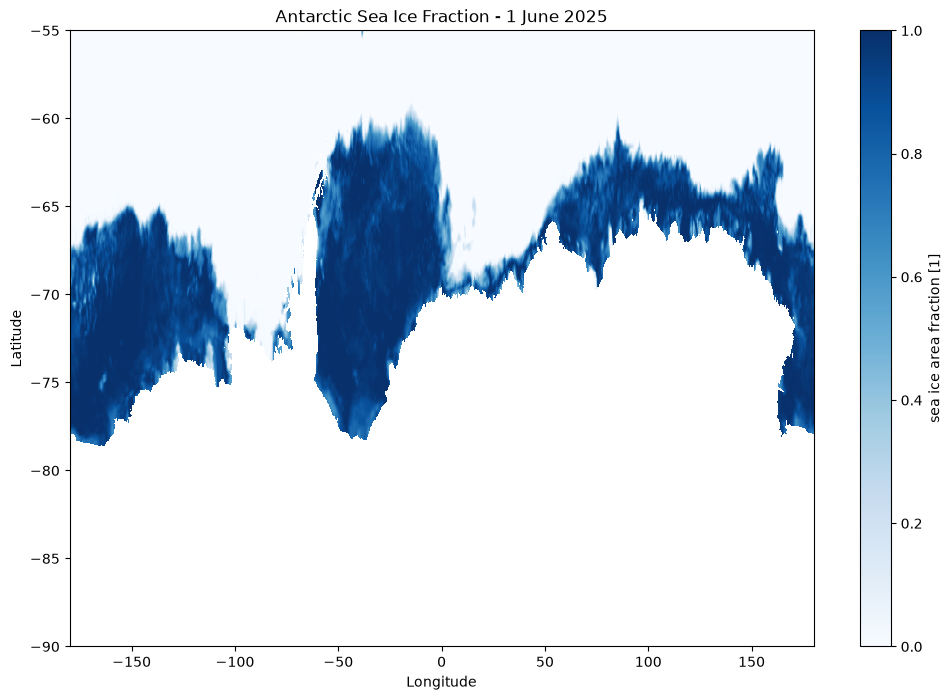

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

antarctic_ds["sea_ice_fraction"].isel(time=0).plot(
    cmap="Blues"
)

plt.title("Antarctic Sea Ice Fraction - 1 June 2025")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [13]:
ice_values = antarctic_ds["sea_ice_fraction"].values

print("Shape:", ice_values.shape)

print("\nNumber of NaN values:")
print(np.isnan(ice_values).sum())

print("\nNumber of valid values:")
print(np.isfinite(ice_values).sum())

print("\nMean sea ice fraction:")
print(np.nanmean(ice_values))

Shape: (1, 700, 7200)

Number of NaN values:
2658544

Number of valid values:
2381456

Mean sea ice fraction:
0.35297465


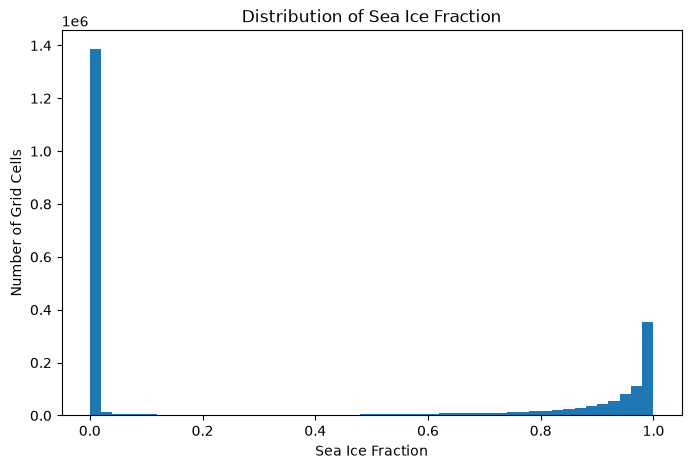

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(
    ice_values.flatten(),
    bins=50
)

plt.title("Distribution of Sea Ice Fraction")
plt.xlabel("Sea Ice Fraction")
plt.ylabel("Number of Grid Cells")

plt.show()

In [15]:
# Find all 5 daily NetCDF files
nc_files = sorted(extract_path.glob("*.nc"))

print("Number of files:", len(nc_files))

for file in nc_files:
    print(file.name)

Number of files: 5
20250601120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20250602120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20250603120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20250604120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20250605120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc


In [16]:
# Open all five daily datasets as one time series

ds5 = xr.open_mfdataset(
    nc_files,
    combine="by_coords"
)

print(ds5)

<xarray.Dataset> Size: 4GB
Dimensions:                (time: 5, lat: 3600, lon: 7200)
Coordinates:
  * time                   (time) datetime64[ns] 40B 2025-06-01T12:00:00 ... ...
  * lat                    (lat) float32 14kB -89.97 -89.92 ... 89.93 89.98
  * lon                    (lon) float32 29kB -180.0 -179.9 ... 179.9 180.0
Data variables:
    analysed_st            (time, lat, lon) float32 518MB dask.array<chunksize=(1, 1800, 3600), meta=np.ndarray>
    analysis_error_st      (time, lat, lon) float32 518MB dask.array<chunksize=(1, 1800, 3600), meta=np.ndarray>
    mask                   (time, lat, lon) float32 518MB dask.array<chunksize=(1, 1800, 3600), meta=np.ndarray>
    sea_ice_fraction       (time, lat, lon) float32 518MB dask.array<chunksize=(1, 1800, 3600), meta=np.ndarray>
    analysed_sst           (time, lat, lon) float32 518MB dask.array<chunksize=(1, 1800, 3600), meta=np.ndarray>
    sea_ice_fraction_flag  (time, lat, lon) float32 518MB dask.array<chunksize=(1, 1800

In [17]:
antarctic5 = ds5.sel(
    lat=slice(-90, -55)
)

print(antarctic5.sizes)

Frozen({'time': 5, 'lat': 700, 'lon': 7200})


In [18]:
module1_5 = antarctic5[
    [
        "analysed_sst",
        "sea_ice_fraction"
    ]
]

print(module1_5)

<xarray.Dataset> Size: 202MB
Dimensions:           (time: 5, lat: 700, lon: 7200)
Coordinates:
  * time              (time) datetime64[ns] 40B 2025-06-01T12:00:00 ... 2025-...
  * lat               (lat) float32 3kB -89.97 -89.92 -89.88 ... -55.07 -55.02
  * lon               (lon) float32 29kB -180.0 -179.9 -179.9 ... 179.9 180.0
Data variables:
    analysed_sst      (time, lat, lon) float32 101MB dask.array<chunksize=(1, 700, 3600), meta=np.ndarray>
    sea_ice_fraction  (time, lat, lon) float32 101MB dask.array<chunksize=(1, 700, 3600), meta=np.ndarray>
Attributes: (12/48)
    Conventions:                CF-1.4, Unidata Observation Dataset v1.0
    title:                      Global Sea and Ice Surface Temperature, L4, 5...
    summary:                    DMI Sea and Ice Surface Temperature analysis ...
    references:                 Høyer, J. L. and She, J., Optimal interpolati...
    institution:                Danish Meteorological Institute, DMI
    history:                    

In [19]:
module1_5 = module1_5.assign(
    sst_celsius=module1_5["analysed_sst"] - 273.15
)

print(module1_5["sst_celsius"])

<xarray.DataArray 'sst_celsius' (time: 5, lat: 700, lon: 7200)> Size: 101MB
dask.array<sub, shape=(5, 700, 7200), dtype=float32, chunksize=(1, 700, 3600), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 40B 2025-06-01T12:00:00 ... 2025-06-05T12:...
  * lat      (lat) float32 3kB -89.97 -89.92 -89.88 ... -55.12 -55.07 -55.02
  * lon      (lon) float32 29kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Attributes:
    standard_name:  sea_surface_temperature
    long_name:      analysed sea and under-ice surface temperature
    units:          kelvin
    comment:        The under-ice SST is the freezing point temperature TS, c...
    source:         AASTI v2 SST/IST, ESA CCI SST and C3S SST L2P products
    valid_range:    [-6000  4500]


In [20]:
print("SST range (°C):")

print(
    "Minimum:",
    float(module1_5["sst_celsius"].min(skipna=True))
)

print(
    "Maximum:",
    float(module1_5["sst_celsius"].max(skipna=True))
)

print("\nSea ice fraction range:")

print(
    "Minimum:",
    float(module1_5["sea_ice_fraction"].min(skipna=True))
)

print(
    "Maximum:",
    float(module1_5["sea_ice_fraction"].max(skipna=True))
)

SST range (°C):
Minimum: -1.910003662109375
Maximum: 9.29998779296875

Sea ice fraction range:
Minimum: 0.0
Maximum: 1.0


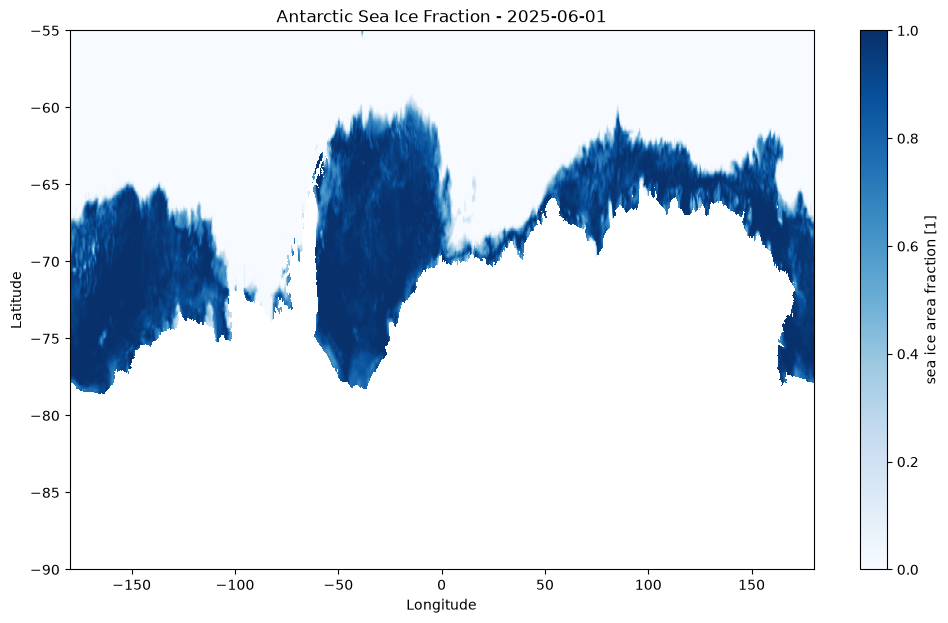

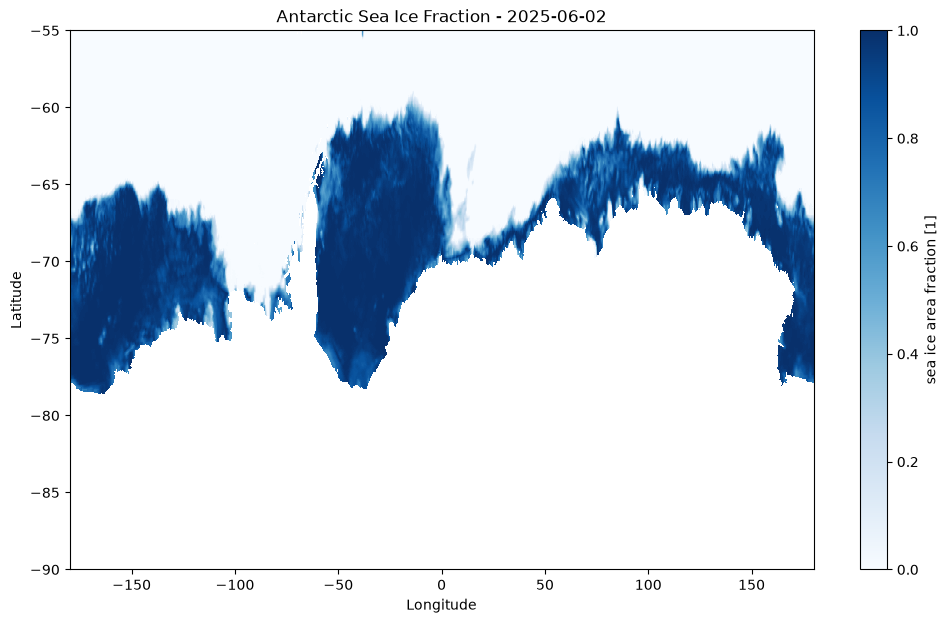

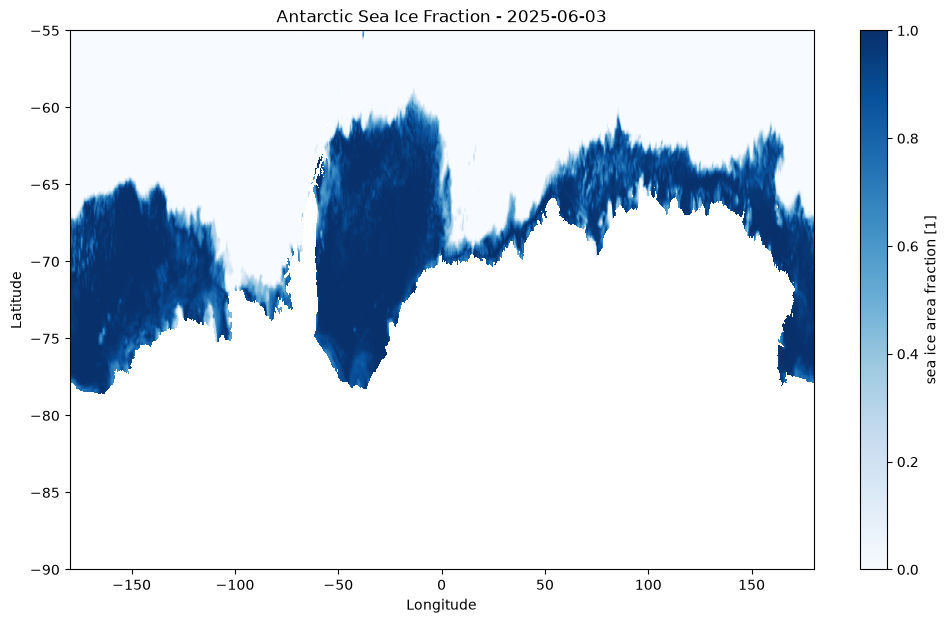

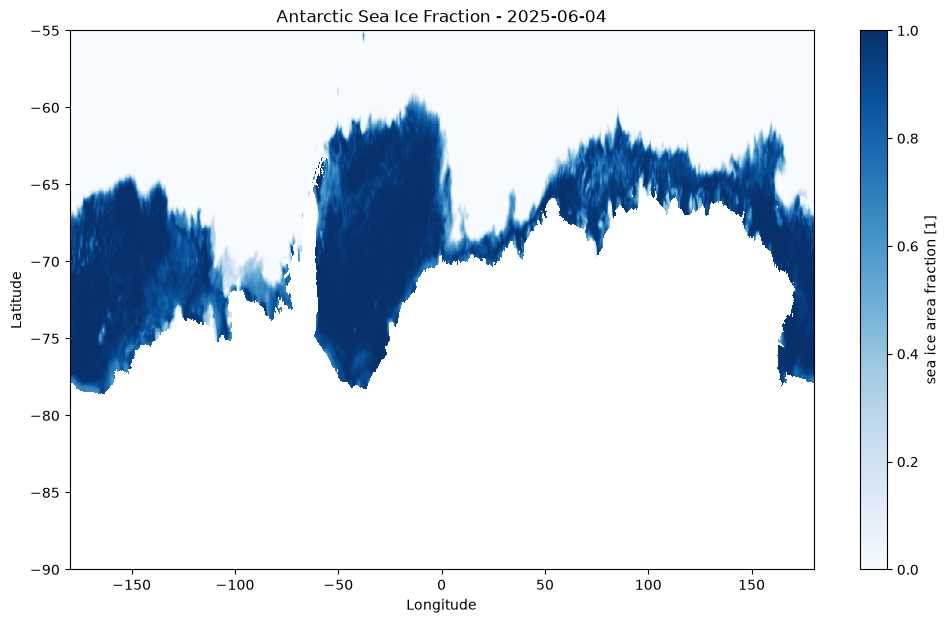

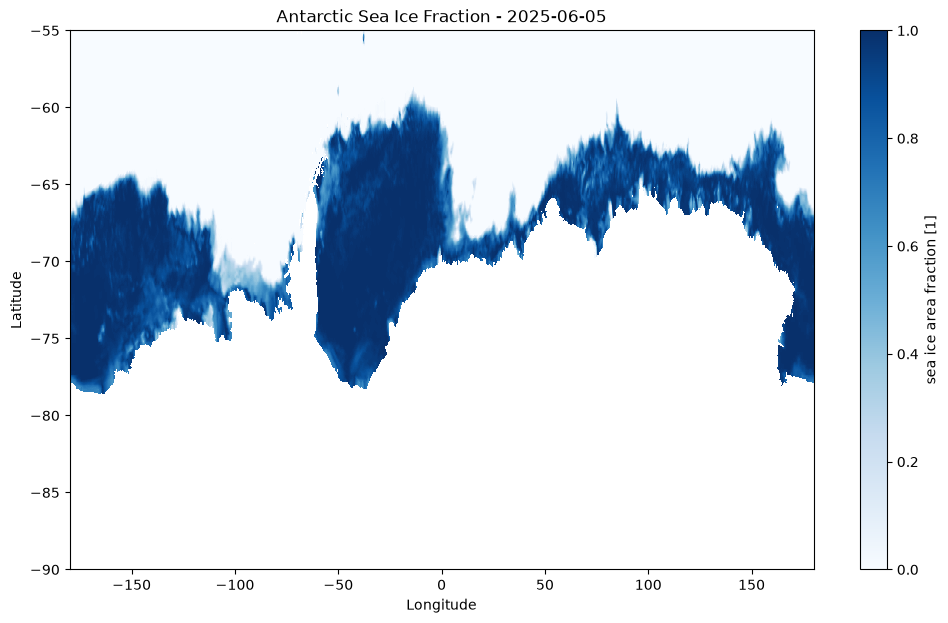

In [21]:
for i in range(5):

    date = pd.to_datetime(
        module1_5.time.values[i]
    ).strftime("%Y-%m-%d")

    plt.figure(figsize=(12, 7))

    module1_5["sea_ice_fraction"].isel(
        time=i
    ).plot(
        cmap="Blues",
        vmin=0,
        vmax=1
    )

    plt.title(
        f"Antarctic Sea Ice Fraction - {date}"
    )

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")

    plt.show()

In [22]:
import cdsapi

print("CDS API imported successfully.")

CDS API imported successfully.


In [23]:
import cdsapi

client = cdsapi.Client()

print("CDS API connection configured successfully.")

CDS API connection configured successfully.


In [24]:
# import cdsapi
# from pathlib import Path

# # Output folder
# sic_dir = Path("../data/raw/sic_d0")
# sic_dir.mkdir(parents=True, exist_ok=True)

# dataset = "satellite-sea-ice-concentration"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",
#     "year": ["2025"],
#     "month": ["06"],
#     "day": ["01", "02", "03", "04", "05"],
#     "version": "3_0"
# }

# target_file = sic_dir / "sic_2025-06-01_to_2025-06-05.nc"

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("Download completed.")
# print("File:", target_file)
# print(
#     "Size:",
#     round(target_file.stat().st_size / (1024**2), 2),
#     "MB"
# )

In [25]:
from pathlib import Path

sic_file = Path("../data/raw/sic_d0/sic_2025-06-01_to_2025-06-05.nc")

print("Exists:", sic_file.exists())

if sic_file.exists():
    size_mb = sic_file.stat().st_size / (1024 * 1024)
    print("Size:", round(size_mb, 2), "MB")

    with open(sic_file, "rb") as f:
        print("First bytes:", f.read(20))

Exists: True
Size: 5.27 MB
First bytes: b'PK\x03\x04\x14\x00\x00\x00\x08\x00M\x83"]\xfd\xfe`\xb7i\xd9'


In [26]:
import zipfile
from pathlib import Path

sic_file = Path("../data/raw/sic_d0/sic_2025-06-01_to_2025-06-05.nc")

with zipfile.ZipFile(sic_file, "r") as zip_ref:
    print("Files inside the downloaded archive:")
    
    for name in zip_ref.namelist():
        print(name)

Files inside the downloaded archive:
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506011200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506021200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506031200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506041200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506051200.nc


In [27]:
import zipfile
from pathlib import Path

# Downloaded archive
zip_file = Path("../data/raw/sic_d0/sic_2025-06-01_to_2025-06-05.nc")

# Folder where extracted NetCDF files will go
extract_folder = Path("../data/raw/sic_d0/extracted")

# Create the folder if it doesn't exist
extract_folder.mkdir(parents=True, exist_ok=True)

# Extract all files
with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("Extraction completed!")
print("\nExtracted files:")

for file in extract_folder.glob("*.nc"):
    print(file.name, "-", round(file.stat().st_size / (1024 * 1024), 2), "MB")

Extraction completed!

Extracted files:
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506011200.nc - 1.05 MB
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506021200.nc - 1.05 MB
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506031200.nc - 1.06 MB
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506041200.nc - 1.05 MB
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506051200.nc - 1.06 MB


In [28]:
import xarray as xr
from pathlib import Path

extract_folder = Path("../data/raw/sic_d0/extracted")

# Get the first NetCDF file
nc_files = sorted(extract_folder.glob("*.nc"))

print("Number of NetCDF files:", len(nc_files))
print("First file:", nc_files[0].name)

# Open it
sic_ds = xr.open_dataset(nc_files[0])

sic_ds

Number of NetCDF files: 5
First file: ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506011200.nc


<xarray.Dataset> Size: 10MB
Dimensions:                         (time: 1, nv: 2, yc: 432, xc: 432)
Coordinates:
  * time                            (time) datetime64[ns] 8B 2025-06-01T12:00:00
  * yc                              (yc) float64 3kB 5.388e+03 ... -5.388e+03
  * xc                              (xc) float64 3kB -5.388e+03 ... 5.388e+03
    lat                             (yc, xc) float32 746kB ...
    lon                             (yc, xc) float32 746kB ...
Dimensions without coordinates: nv
Data variables:
    Lambert_Azimuthal_Grid          int32 4B ...
    time_bnds                       (time, nv) datetime64[ns] 16B ...
    ice_conc                        (time, yc, xc) float64 1MB ...
    raw_ice_conc_values             (time, yc, xc) float64 1MB ...
    total_standard_uncertainty      (time, yc, xc) float64 1MB ...
    smearing_standard_uncertainty   (time, yc, xc) float64 1MB ...
    algorithm_standard_uncertainty  (time, yc, xc) float64 1MB ...
    status_flag                     (time, yc, xc) float32 746kB ...
Attributes: (12/48)
    keywords:                  GCMDSK:Earth Science > Cryosphere > Sea Ice > ...
    keywords_vocabulary:       GCMDSK:GCMD Science Keywords:https://gcmd.eart...
    geospatial_lat_min:        -90.0
    geospatial_lat_max:        -16.62393
    geospatial_lon_min:        -180.0
    geospatial_lon_max:        180.0
    ...                        ...
    iso_topic_category:        oceans, climatologyMeteorologyAtmosphere
    instrument:                AMSR2
    instrument_vocabulary:     WMO OSCAR Space:https://space.oscar.wmo.int/in...
    platform_vocabulary:       WMO OSCAR Space:https://space.oscar.wmo.int/sa...
    creator_institution:       OSISAF - EUMETSAT
    id:                        abf41612-65b5-49a9-a851-4722a7e84baa

In [29]:
import xarray as xr
from pathlib import Path

# Folder containing extracted NetCDF files
data_folder = Path("../data/raw/sic_d0")

# Get all .nc files
nc_files = sorted(data_folder.glob("*.nc"))

print("Number of NetCDF files:", len(nc_files))

# Display filenames
for file in nc_files:
    print(file.name)

Number of NetCDF files: 1
sic_2025-06-01_to_2025-06-05.nc


In [30]:
import zipfile
import shutil
from pathlib import Path

# Downloaded archive
archive_file = Path("../data/raw/sic_d0/sic_2025-06-01_to_2025-06-05.nc")

# New extraction folder
extract_folder = Path("../data/raw/sic_d0/extracted_nc")

# Remove the folder if it already exists
if extract_folder.exists():
    shutil.rmtree(extract_folder)

# Create fresh folder
extract_folder.mkdir(parents=True, exist_ok=True)

# Extract ZIP archive
with zipfile.ZipFile(archive_file, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("Extraction completed successfully!")
print("\nExtracted files:")

for file in sorted(extract_folder.glob("*.nc")):
    print(file.name)

Extraction completed successfully!

Extracted files:
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506011200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506021200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506031200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506041200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506051200.nc


In [31]:
import xarray as xr
from pathlib import Path

# Folder containing the extracted NetCDF files
data_folder = Path("../data/raw/sic_d0/extracted_nc")

# Get all .nc files
nc_files = sorted(data_folder.glob("*.nc"))

print("Number of NetCDF files:", len(nc_files))

for file in nc_files:
    print(file.name)

Number of NetCDF files: 5
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506011200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506021200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506031200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506041200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506051200.nc


In [32]:
datasets = []

for file in nc_files:
    ds = xr.open_dataset(file)
    datasets.append(ds)

print("Successfully opened:", len(datasets), "datasets")

Successfully opened: 5 datasets


In [33]:
combined_ds = xr.concat(datasets, dim="time")

print(combined_ds)

C:\Users\acer\AppData\Local\Temp\ipykernel_20980\3679097643.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  combined_ds = xr.concat(datasets, dim="time")


<xarray.Dataset> Size: 43MB
Dimensions:                         (time: 5, nv: 2, yc: 432, xc: 432)
Coordinates:
  * time                            (time) datetime64[ns] 40B 2025-06-01T12:0...
  * yc                              (yc) float64 3kB 5.388e+03 ... -5.388e+03
  * xc                              (xc) float64 3kB -5.388e+03 ... 5.388e+03
    lat                             (yc, xc) float32 746kB -16.62 ... -16.62
    lon                             (yc, xc) float32 746kB -45.0 ... 135.0
Dimensions without coordinates: nv
Data variables:
    Lambert_Azimuthal_Grid          (time) int32 20B -2147483647 ... -2147483647
    time_bnds                       (time, nv) datetime64[ns] 80B 2025-06-01 ...
    ice_conc                        (time, yc, xc) float64 7MB nan nan ... nan
    raw_ice_conc_values             (time, yc, xc) float64 7MB nan nan ... nan
    total_standard_uncertainty      (time, yc, xc) float64 7MB nan nan ... nan
    smearing_standard_uncertainty   (time, yc, xc

In [34]:
# Inspect the Sea Ice Concentration variable

ice_conc = combined_ds["ice_conc"]

print(ice_conc)

<xarray.DataArray 'ice_conc' (time: 5, yc: 432, xc: 432)> Size: 7MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [ 0.,  0.,  0., ..., nan, nan, nan],
        [ 0.,  0.,  0., ..., nan, nan, nan],
        [ 0.,  0.,  0., ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [ 0.,  0.,  0., ..., nan, nan, nan],
        [ 0.,  0.,  0., ..., nan, nan, nan],
        [ 0.,  0.,  0., ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [ 0.,  0.,  0., ..., nan, nan, nan],
        [ 0.,  0.,  0., ..., nan, nan, nan],
        [ 0.,  0.,  0., ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan

In [35]:
import numpy as np

print("Shape:", ice_conc.shape)

print("Minimum value:", float(ice_conc.min(skipna=True)))
print("Maximum value:", float(ice_conc.max(skipna=True)))

print("Number of NaN values:", int(ice_conc.isnull().sum()))

print("Total values:", ice_conc.size)

print(
    "Percentage of missing values:",
    round(float(ice_conc.isnull().sum() / ice_conc.size * 100), 2),
    "%"
)

Shape: (5, 432, 432)
Minimum value: 0.0
Maximum value: 100.0
Number of NaN values: 166525
Total values: 933120
Percentage of missing values: 17.85 %


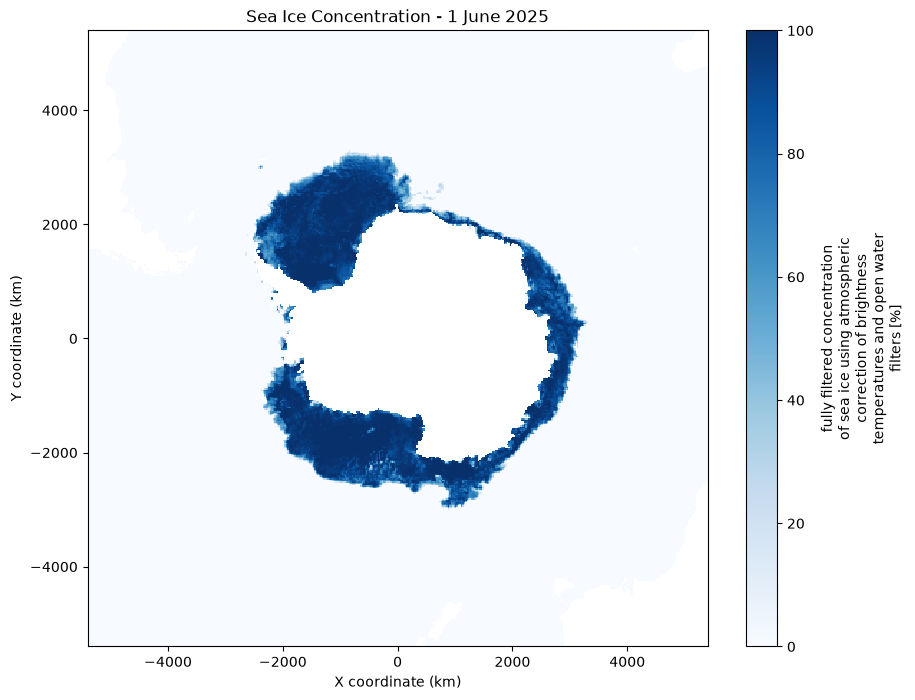

In [36]:
# Sea-ice concentration for the first day
sic_day1 = ice_conc.isel(time=0)

plt.figure(figsize=(10, 8))

sic_day1.plot(
    x="xc",
    y="yc",
    cmap="Blues",
    vmin=0,
    vmax=100
)

plt.title("Sea Ice Concentration - 1 June 2025")
plt.xlabel("X coordinate (km)")
plt.ylabel("Y coordinate (km)")

plt.show()

In [37]:
print("Latitude range:")
print(
    float(combined_ds["lat"].min()),
    "to",
    float(combined_ds["lat"].max())
)

print("\nLongitude range:")
print(
    float(combined_ds["lon"].min()),
    "to",
    float(combined_ds["lon"].max())
)

Latitude range:
-89.84172821044922 to -16.623926162719727

Longitude range:
-179.8670654296875 to 179.8670654296875


In [38]:
print("Time values:")
print(combined_ds.time.values)

Time values:
['2025-06-01T12:00:00.000000000' '2025-06-02T12:00:00.000000000'
 '2025-06-03T12:00:00.000000000' '2025-06-04T12:00:00.000000000'
 '2025-06-05T12:00:00.000000000']


In [39]:
# Create Antarctic/Southern Ocean mask
antarctic_mask = combined_ds["lat"] <= -55

# Apply the mask to sea-ice concentration
sic_antarctic = ice_conc.where(antarctic_mask)

print("Original SIC shape:", ice_conc.shape)
print("Antarctic SIC shape:", sic_antarctic.shape)

print(
    "Valid Antarctic values:",
    int(sic_antarctic.notnull().sum())
)

print(
    "Missing Antarctic values:",
    int(sic_antarctic.isnull().sum())
)

Original SIC shape: (5, 432, 432)
Antarctic SIC shape: (5, 432, 432)
Valid Antarctic values: 259075
Missing Antarctic values: 674045


C:\Users\acer\AppData\Local\Temp\ipykernel_20980\4114674785.py:5: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(


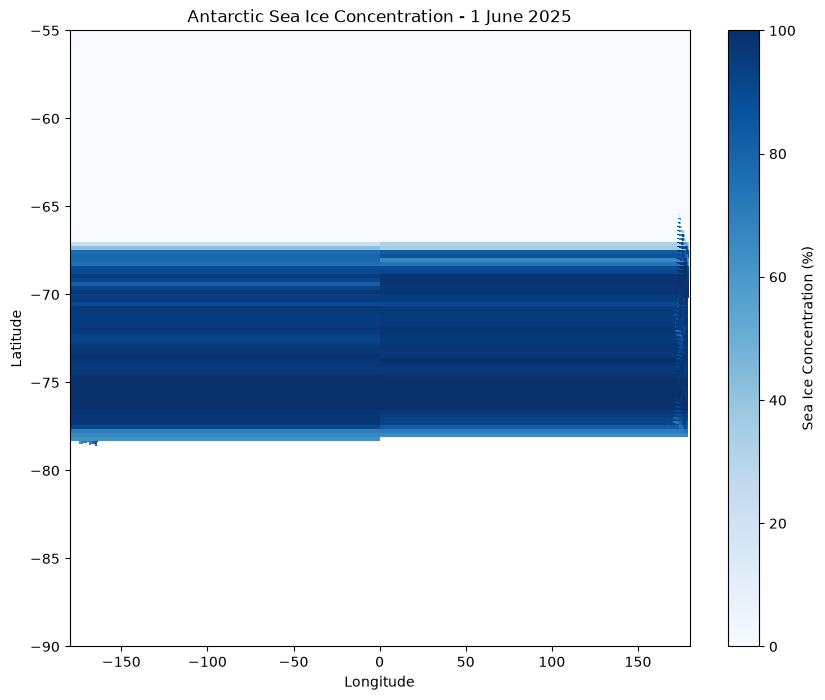

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.pcolormesh(
    combined_ds["lon"],
    combined_ds["lat"],
    sic_antarctic.isel(time=0),
    shading="auto",
    cmap="Blues",
    vmin=0,
    vmax=100
)

plt.colorbar(label="Sea Ice Concentration (%)")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Antarctic Sea Ice Concentration - 1 June 2025")

plt.xlim(-180, 180)
plt.ylim(-90, -55)

plt.show()

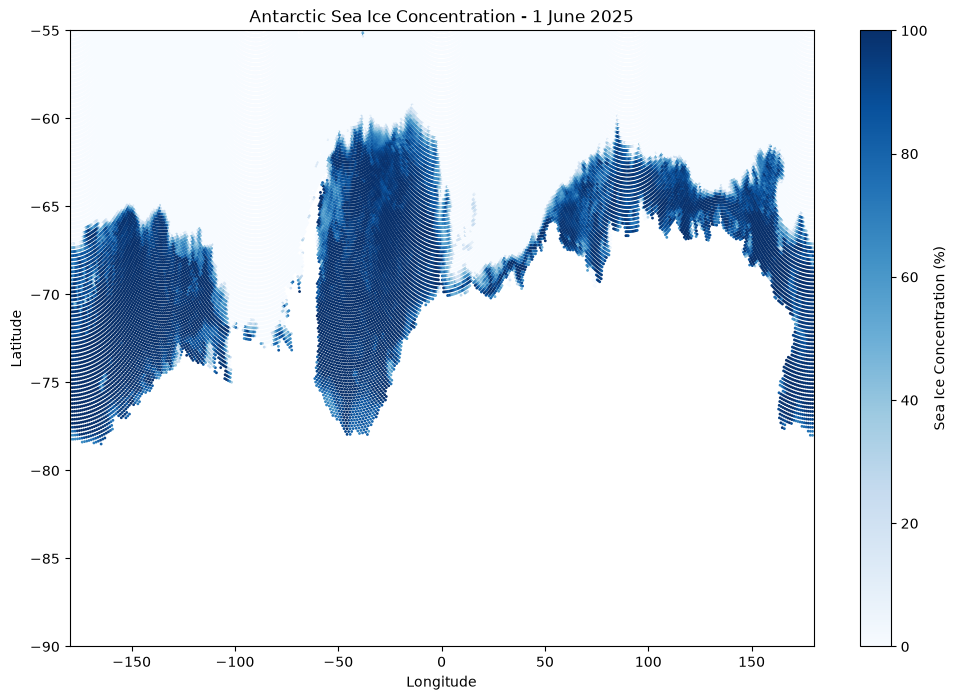

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# First day
sic_day1 = sic_antarctic.isel(time=0)

# Actual geographic coordinates
lat = combined_ds["lat"].values
lon = combined_ds["lon"].values
sic = sic_day1.values

# Keep only valid Antarctic values
valid = np.isfinite(sic) & (lat <= -55)

plt.figure(figsize=(12, 8))

plt.scatter(
    lon[valid],
    lat[valid],
    c=sic[valid],
    s=1,
    cmap="Blues",
    vmin=0,
    vmax=100,
    rasterized=True
)

plt.colorbar(label="Sea Ice Concentration (%)")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Antarctic Sea Ice Concentration - 1 June 2025")

plt.xlim(-180, 180)
plt.ylim(-90, -55)

plt.show()

In [42]:
print("SIC grid dimensions:")
print("yc:", combined_ds.sizes["yc"])
print("xc:", combined_ds.sizes["xc"])

print("\nProjection coordinate ranges:")
print(
    "yc:",
    float(combined_ds["yc"].min()),
    "to",
    float(combined_ds["yc"].max()),
    "km"
)

print(
    "xc:",
    float(combined_ds["xc"].min()),
    "to",
    float(combined_ds["xc"].max()),
    "km"
)

print("\nGeographic coverage:")
print(
    "Latitude:",
    float(combined_ds["lat"].min()),
    "to",
    float(combined_ds["lat"].max())
)

print(
    "Longitude:",
    float(combined_ds["lon"].min()),
    "to",
    float(combined_ds["lon"].max())
)

SIC grid dimensions:
yc: 432
xc: 432

Projection coordinate ranges:
yc: -5387.5 to 5387.5 km
xc: -5387.5 to 5387.5 km

Geographic coverage:
Latitude: -89.84172821044922 to -16.623926162719727
Longitude: -179.8670654296875 to 179.8670654296875


In [43]:
valid_antarctic = np.isfinite(
    ice_conc.isel(time=0).values
) & (
    combined_ds["lat"].values <= -55
)

print(
    "Valid Antarctic grid cells on 1 June:",
    int(valid_antarctic.sum())
)

print(
    "Total SIC grid cells:",
    ice_conc.isel(time=0).size
)

print(
    "Percentage of grid inside usable Antarctic region:",
    round(
        valid_antarctic.sum()
        / ice_conc.isel(time=0).size
        * 100,
        2
    ),
    "%"
)

Valid Antarctic grid cells on 1 June: 51815
Total SIC grid cells: 186624
Percentage of grid inside usable Antarctic region: 27.76 %


In [44]:
# Reopen the existing 5-day SST dataset if needed
import xarray as xr
from pathlib import Path

sst_folder = Path("../data/raw/d0")

sst_files = sorted(sst_folder.glob("*.nc"))

print("Number of SST files:", len(sst_files))

for f in sst_files:
    print(f.name)

Number of SST files: 5
20250601120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20250602120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20250603120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20250604120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20250605120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc


In [45]:
sst_ds = xr.open_mfdataset(
    sst_files,
    combine="by_coords"
)

print(sst_ds.sizes)
print(sst_ds.time.values)

Frozen({'time': 5, 'lat': 3600, 'lon': 7200})
['2025-06-01T12:00:00.000000000' '2025-06-02T12:00:00.000000000'
 '2025-06-03T12:00:00.000000000' '2025-06-04T12:00:00.000000000'
 '2025-06-05T12:00:00.000000000']


In [46]:
sst_celsius = sst_ds["analysed_sst"] - 273.15

print(sst_celsius)

<xarray.DataArray 'analysed_sst' (time: 5, lat: 3600, lon: 7200)> Size: 518MB
dask.array<sub, shape=(5, 3600, 7200), dtype=float32, chunksize=(1, 1800, 3600), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 40B 2025-06-01T12:00:00 ... 2025-06-05T12:...
  * lat      (lat) float32 14kB -89.97 -89.92 -89.88 ... 89.88 89.93 89.98
  * lon      (lon) float32 29kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Attributes:
    standard_name:  sea_surface_temperature
    long_name:      analysed sea and under-ice surface temperature
    units:          kelvin
    comment:        The under-ice SST is the freezing point temperature TS, c...
    source:         AASTI v2 SST/IST, ESA CCI SST and C3S SST L2P products
    valid_range:    [-6000  4500]


In [47]:
# SIC grid coordinates
sic_lat = combined_ds["lat"]
sic_lon = combined_ds["lon"]

# Sample the regular SST grid at the SIC grid locations
sst_on_sic_grid = sst_celsius.sel(
    lat=sic_lat,
    lon=sic_lon,
    method="nearest"
)

print(sst_on_sic_grid)

<xarray.DataArray 'analysed_sst' (time: 5, yc: 432, xc: 432)> Size: 4MB
dask.array<transpose, shape=(5, 432, 432), dtype=float32, chunksize=(1, 432, 432), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 40B 2025-06-01T12:00:00 ... 2025-06-05T12:...
  * yc       (yc) float64 3kB 5.388e+03 5.362e+03 ... -5.362e+03 -5.388e+03
  * xc       (xc) float64 3kB -5.388e+03 -5.362e+03 ... 5.362e+03 5.388e+03
    lon      (yc, xc) float32 746kB -44.98 -44.88 -44.73 ... 135.3 135.1 135.0
    lat      (yc, xc) float32 746kB -16.62 -16.82 -17.02 ... -16.82 -16.62
Attributes:
    standard_name:  sea_surface_temperature
    long_name:      analysed sea and under-ice surface temperature
    units:          kelvin
    comment:        The under-ice SST is the freezing point temperature TS, c...
    source:         AASTI v2 SST/IST, ESA CCI SST and C3S SST L2P products
    valid_range:    [-6000  4500]


In [48]:
# Build the common dataset explicitly on the SIC grid
# This avoids xarray trying to reconcile conflicting coordinate metadata.

module1_data = xr.Dataset(
    coords={
        "time": combined_ds["time"],
        "yc": combined_ds["yc"],
        "xc": combined_ds["xc"],
        "lat": combined_ds["lat"],
        "lon": combined_ds["lon"],
    }
)

# Add SST and SIC using the same time/yc/xc dimensions
module1_data["sst_celsius"] = (
    ("time", "yc", "xc"),
    sst_on_sic_grid.data
)

module1_data["sea_ice_concentration"] = (
    ("time", "yc", "xc"),
    ice_conc.data
)

# Apply our Antarctic/Southern Ocean boundary
module1_data = module1_data.where(
    module1_data["lat"] <= -55
)

print(module1_data)

<xarray.Dataset> Size: 13MB
Dimensions:                (time: 5, yc: 432, xc: 432)
Coordinates:
  * time                   (time) datetime64[ns] 40B 2025-06-01T12:00:00 ... ...
  * yc                     (yc) float64 3kB 5.388e+03 5.362e+03 ... -5.388e+03
  * xc                     (xc) float64 3kB -5.388e+03 -5.362e+03 ... 5.388e+03
    lat                    (yc, xc) float32 746kB -16.62 -16.82 ... -16.62
    lon                    (yc, xc) float32 746kB -45.0 -44.87 ... 135.1 135.0
Data variables:
    sst_celsius            (time, yc, xc) float32 4MB dask.array<chunksize=(1, 432, 432), meta=np.ndarray>
    sea_ice_concentration  (time, yc, xc) float64 7MB nan nan nan ... nan nan


In [49]:
print("Dimensions:")
print(module1_data.sizes)

print("\nVariables:")
print(list(module1_data.data_vars))

print("\nCoordinates:")
print(list(module1_data.coords))

print("\nTime:")
print(module1_data.time.values)

Dimensions:
Frozen({'time': 5, 'yc': 432, 'xc': 432})

Variables:
['sst_celsius', 'sea_ice_concentration']

Coordinates:
['time', 'yc', 'xc', 'lat', 'lon']

Time:
['2025-06-01T12:00:00.000000000' '2025-06-02T12:00:00.000000000'
 '2025-06-03T12:00:00.000000000' '2025-06-04T12:00:00.000000000'
 '2025-06-05T12:00:00.000000000']


In [50]:
# Check where BOTH SST and SIC are available

sst = module1_data["sst_celsius"]
sic = module1_data["sea_ice_concentration"]

paired_valid = np.isfinite(sst) & np.isfinite(sic)

print("Total possible observations:", paired_valid.size)

print(
    "Valid SST + SIC observations:",
    int(paired_valid.sum())
)

print(
    "Missing/invalid paired observations:",
    int((~paired_valid).sum())
)

print(
    "Usable paired percentage:",
    round(
        float(paired_valid.sum() / paired_valid.size * 100),
        2
    ),
    "%"
)

Total possible observations: 933120
Valid SST + SIC observations: 258467
Missing/invalid paired observations: 674653
Usable paired percentage: 27.7 %


In [51]:
print("Daily paired-data statistics")
print("=" * 60)

for i in range(module1_data.sizes["time"]):
    
    date = str(module1_data.time.values[i])[:10]
    
    day_sst = module1_data["sst_celsius"].isel(time=i)
    day_sic = module1_data["sea_ice_concentration"].isel(time=i)
    
    valid = np.isfinite(day_sst) & np.isfinite(day_sic)
    
    print(f"\nDate: {date}")
    print("Valid paired cells:", int(valid.sum()))
    
    if valid.any():
        sst_values = day_sst.values[valid]
        sic_values = day_sic.values[valid]
        
        print(
            "SST range (°C):",
            round(float(sst_values.min()), 2),
            "to",
            round(float(sst_values.max()), 2)
        )
        
        print(
            "SIC range (%):",
            round(float(sic_values.min()), 2),
            "to",
            round(float(sic_values.max()), 2)
        )
        
        print(
            "Mean SST (°C):",
            round(float(sst_values.mean()), 2)
        )
        
        print(
            "Mean SIC (%):",
            round(float(sic_values.mean()), 2)
        )

Daily paired-data statistics

Date: 2025-06-01
Valid paired cells: 51669
SST range (°C): -1.91 to 8.75
SIC range (%): 0.0 to 100.0
Mean SST (°C): 0.21
Mean SIC (%): 28.62

Date: 2025-06-02
Valid paired cells: 51688
SST range (°C): -1.91 to 8.67
SIC range (%): 0.0 to 100.0
Mean SST (°C): 0.2
Mean SIC (%): 29.05

Date: 2025-06-03
Valid paired cells: 51701
SST range (°C): -1.91 to 8.91
SIC range (%): 0.0 to 100.0
Mean SST (°C): 0.2
Mean SIC (%): 29.41

Date: 2025-06-04
Valid paired cells: 51703
SST range (°C): -1.91 to 8.92
SIC range (%): 0.0 to 100.0
Mean SST (°C): 0.2
Mean SIC (%): 29.97

Date: 2025-06-05
Valid paired cells: 51706
SST range (°C): -1.91 to 8.64
SIC range (%): 0.0 to 100.0
Mean SST (°C): 0.19
Mean SIC (%): 30.57


In [52]:
# Create ML-ready paired observations

ml_data = module1_data[
    ["sst_celsius", "sea_ice_concentration"]
].where(
    np.isfinite(module1_data["sst_celsius"]) &
    np.isfinite(module1_data["sea_ice_concentration"])
)

# Convert spatial grid to individual observations
ml_table = ml_data.to_dataframe().reset_index()

# Remove remaining invalid rows
ml_table = ml_table.dropna(
    subset=["sst_celsius", "sea_ice_concentration"]
)

print("ML table shape:", ml_table.shape)

print("\nColumns:")
print(ml_table.columns.tolist())

print("\nFirst 5 rows:")
print(ml_table.head())

ML table shape: (258467, 7)

Columns:
['time', 'yc', 'xc', 'sst_celsius', 'sea_ice_concentration', 'lat', 'lon']

First 5 rows:
                     time      yc     xc  sst_celsius  sea_ice_concentration  \
26991 2025-06-01 12:00:00  3837.5 -212.5    -0.010010                    0.0   
26992 2025-06-01 12:00:00  3837.5 -187.5    -0.010010                    0.0   
26993 2025-06-01 12:00:00  3837.5 -162.5    -0.079987                    0.0   
26994 2025-06-01 12:00:00  3837.5 -137.5    -0.140015                    0.0   
26995 2025-06-01 12:00:00  3837.5 -112.5    -0.220001                    0.0   

             lat       lon  
26991 -55.009514 -3.169493  
26992 -55.021767 -2.797244  
26993 -55.032494 -2.424757  
26994 -55.041687 -2.052065  
26995 -55.049351 -1.679200  


In [54]:
# ============================================
# Recreate m1_table from the existing dataset
# ============================================

m1_table = module1_data.to_dataframe().reset_index()

print("m1_table shape:", m1_table.shape)

print("\nColumns:")
print(m1_table.columns.tolist())

print("\nFirst 5 rows:")
print(m1_table.head())

m1_table shape: (933120, 7)

Columns:
['time', 'yc', 'xc', 'sst_celsius', 'sea_ice_concentration', 'lat', 'lon']

First 5 rows:
                 time      yc      xc  sst_celsius  sea_ice_concentration  \
0 2025-06-01 12:00:00  5387.5 -5387.5          NaN                    NaN   
1 2025-06-01 12:00:00  5387.5 -5362.5          NaN                    NaN   
2 2025-06-01 12:00:00  5387.5 -5337.5          NaN                    NaN   
3 2025-06-01 12:00:00  5387.5 -5312.5          NaN                    NaN   
4 2025-06-01 12:00:00  5387.5 -5287.5          NaN                    NaN   

         lat        lon  
0 -16.623926 -45.000000  
1 -16.822655 -44.866753  
2 -17.020658 -44.732887  
3 -17.217941 -44.598400  
4 -17.414501 -44.463287  


In [55]:
# ============================================
# STEP 1 — Create next-day forecasting dataset
# ============================================

import pandas as pd
import numpy as np

# Work on a copy
forecast_df = m1_table.copy()

# Make sure time is datetime
forecast_df["time"] = pd.to_datetime(forecast_df["time"])

# Sort spatial cells and time chronologically
forecast_df = forecast_df.sort_values(
    ["yc", "xc", "time"]
).reset_index(drop=True)

# --------------------------------------------
# Target = sea-ice concentration on NEXT day
# --------------------------------------------

forecast_df["target_sic"] = (
    forecast_df
    .groupby(["yc", "xc"])["sea_ice_concentration"]
    .shift(-1)
)

# Current SIC is our historical SIC feature
forecast_df["historical_sic"] = forecast_df["sea_ice_concentration"]

# Month feature
forecast_df["month"] = forecast_df["time"].dt.month

# Remove rows where next-day SIC does not exist
forecast_df = forecast_df.dropna(
    subset=[
        "sst_celsius",
        "historical_sic",
        "target_sic",
        "lat",
        "lon"
    ]
).reset_index(drop=True)

print("Forecasting table shape:", forecast_df.shape)

print("\nColumns:")
print(forecast_df.columns.tolist())

print("\nDates available:")
print(forecast_df["time"].drop_duplicates().tolist())

print("\nFirst 5 rows:")
print(
    forecast_df[
        [
            "time",
            "lat",
            "lon",
            "sst_celsius",
            "historical_sic",
            "month",
            "target_sic"
        ]
    ].head()
)

Forecasting table shape: (206761, 10)

Columns:
['time', 'yc', 'xc', 'sst_celsius', 'sea_ice_concentration', 'lat', 'lon', 'target_sic', 'historical_sic', 'month']

Dates available:
[Timestamp('2025-06-01 12:00:00'), Timestamp('2025-06-02 12:00:00'), Timestamp('2025-06-03 12:00:00'), Timestamp('2025-06-04 12:00:00')]

First 5 rows:
                 time        lat         lon  sst_celsius  historical_sic  \
0 2025-06-01 12:00:00 -55.009514 -176.830505     7.220001             0.0   
1 2025-06-02 12:00:00 -55.009514 -176.830505     6.609985             0.0   
2 2025-06-03 12:00:00 -55.009514 -176.830505     6.959991             0.0   
3 2025-06-04 12:00:00 -55.009514 -176.830505     6.970001             0.0   
4 2025-06-01 12:00:00 -55.021767 -177.202759     7.089996             0.0   

   month  target_sic  
0      6         0.0  
1      6         0.0  
2      6         0.0  
3      6         0.0  
4      6         0.0  


In [56]:
# ============================================
# Remove rows with missing SST or sea-ice data
# ============================================

m1_table = m1_table.dropna(
    subset=["sst_celsius", "sea_ice_concentration"]
).copy()

print("Clean ML table shape:", m1_table.shape)

print("\nMissing values:")
print(m1_table[["sst_celsius", "sea_ice_concentration"]].isna().sum())

print("\nFirst 5 clean rows:")
print(
    m1_table[
        [
            "time",
            "lat",
            "lon",
            "sst_celsius",
            "sea_ice_concentration"
        ]
    ].head()
)

Clean ML table shape: (258467, 7)

Missing values:
sst_celsius              0
sea_ice_concentration    0
dtype: int64

First 5 clean rows:
                     time        lat       lon  sst_celsius  \
26991 2025-06-01 12:00:00 -55.009514 -3.169493    -0.010010   
26992 2025-06-01 12:00:00 -55.021767 -2.797244    -0.010010   
26993 2025-06-01 12:00:00 -55.032494 -2.424757    -0.079987   
26994 2025-06-01 12:00:00 -55.041687 -2.052065    -0.140015   
26995 2025-06-01 12:00:00 -55.049351 -1.679200    -0.220001   

       sea_ice_concentration  
26991                    0.0  
26992                    0.0  
26993                    0.0  
26994                    0.0  
26995                    0.0  


In [57]:
# ============================================
# Prepare data for sea-ice forecasting
# ============================================

forecast_df = m1_table.copy()

# Make sure time is datetime
forecast_df["time"] = pd.to_datetime(forecast_df["time"])

# Historical sea-ice concentration
forecast_df["historical_sic"] = forecast_df["sea_ice_concentration"]

# Month as a numerical feature
forecast_df["month"] = forecast_df["time"].dt.month

# Target = sea-ice concentration
forecast_df["target_sic"] = forecast_df["sea_ice_concentration"]

print("Forecasting dataset shape:", forecast_df.shape)

print("\nColumns:")
print(forecast_df.columns.tolist())

print("\nDates:")
print(forecast_df["time"].drop_duplicates().tolist())

print("\nFirst 5 rows:")
print(
    forecast_df[
        [
            "time",
            "lat",
            "lon",
            "sst_celsius",
            "historical_sic",
            "month",
            "target_sic"
        ]
    ].head()
)

Forecasting dataset shape: (258467, 10)

Columns:
['time', 'yc', 'xc', 'sst_celsius', 'sea_ice_concentration', 'lat', 'lon', 'historical_sic', 'month', 'target_sic']

Dates:
[Timestamp('2025-06-01 12:00:00'), Timestamp('2025-06-02 12:00:00'), Timestamp('2025-06-03 12:00:00'), Timestamp('2025-06-04 12:00:00'), Timestamp('2025-06-05 12:00:00')]

First 5 rows:
                     time        lat       lon  sst_celsius  historical_sic  \
26991 2025-06-01 12:00:00 -55.009514 -3.169493    -0.010010             0.0   
26992 2025-06-01 12:00:00 -55.021767 -2.797244    -0.010010             0.0   
26993 2025-06-01 12:00:00 -55.032494 -2.424757    -0.079987             0.0   
26994 2025-06-01 12:00:00 -55.041687 -2.052065    -0.140015             0.0   
26995 2025-06-01 12:00:00 -55.049351 -1.679200    -0.220001             0.0   

       month  target_sic  
26991      6         0.0  
26992      6         0.0  
26993      6         0.0  
26994      6         0.0  
26995      6         0.0  


In [58]:
# ============================================
# Create previous-day sea-ice concentration
# ============================================

forecast_df = forecast_df.sort_values(
    ["lat", "lon", "time"]
).copy()

# Previous day's SIC for the same grid location
forecast_df["historical_sic"] = (
    forecast_df
    .groupby(["lat", "lon"])["sea_ice_concentration"]
    .shift(1)
)

# Target remains today's SIC
forecast_df["target_sic"] = forecast_df["sea_ice_concentration"]

print("Forecasting dataset shape:", forecast_df.shape)

print("\nMissing historical SIC:")
print(forecast_df["historical_sic"].isna().sum())

print("\nExample rows:")
print(
    forecast_df[
        [
            "time",
            "lat",
            "lon",
            "sst_celsius",
            "historical_sic",
            "target_sic"
        ]
    ].head(20)
)

Forecasting dataset shape: (258467, 10)

Missing historical SIC:
51709

Example rows:
                      time        lat         lon  sst_celsius  \
114682 2025-06-01 12:00:00 -78.495102 -164.744888    -1.839996   
301306 2025-06-02 12:00:00 -78.495102 -164.744888    -1.859985   
487930 2025-06-03 12:00:00 -78.495102 -164.744888    -1.880005   
674554 2025-06-04 12:00:00 -78.495102 -164.744888    -1.829987   
861178 2025-06-05 12:00:00 -78.495102 -164.744888    -1.779999   
115117 2025-06-01 12:00:00 -78.433861 -168.254364    -1.750000   
301741 2025-06-02 12:00:00 -78.433861 -168.254364    -1.760010   
488365 2025-06-03 12:00:00 -78.433861 -168.254364    -1.769989   
674989 2025-06-04 12:00:00 -78.433861 -168.254364    -1.709991   
861613 2025-06-05 12:00:00 -78.433861 -168.254364    -1.720001   
115554 2025-06-01 12:00:00 -78.385956 -173.904144    -1.750000   
302178 2025-06-02 12:00:00 -78.385956 -173.904144    -1.750000   
488802 2025-06-03 12:00:00 -78.385956 -173.904144    -1.

In [59]:
# ============================================
# Remove rows without a previous-day SIC
# ============================================

forecast_df = forecast_df.dropna(
    subset=["historical_sic"]
).copy()

print("Dataset shape after removing first-day rows:")
print(forecast_df.shape)

print("\nDates remaining:")
print(sorted(forecast_df["time"].unique()))

print("\nMissing values:")
print(forecast_df[
    [
        "lat",
        "lon",
        "sst_celsius",
        "historical_sic",
        "target_sic"
    ]
].isna().sum())

Dataset shape after removing first-day rows:
(206758, 10)

Dates remaining:
[Timestamp('2025-06-02 12:00:00'), Timestamp('2025-06-03 12:00:00'), Timestamp('2025-06-04 12:00:00'), Timestamp('2025-06-05 12:00:00')]

Missing values:
lat               0
lon               0
sst_celsius       0
historical_sic    0
target_sic        0
dtype: int64


In [60]:
# ============================================
# Prepare features and target for ML
# ============================================

features = [
    "lat",
    "lon",
    "sst_celsius",
    "historical_sic",
    "month"
]

target = "target_sic"

X = forecast_df[features].copy()
y = forecast_df[target].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget statistics:")
print(y.describe())

Feature matrix shape: (206758, 5)
Target shape: (206758,)

Features:
['lat', 'lon', 'sst_celsius', 'historical_sic', 'month']

Target statistics:
count    206758.000000
mean         29.756248
std          42.977511
min           0.000000
25%           0.000000
50%           0.000000
75%          85.870000
max         100.000000
Name: target_sic, dtype: float64


In [61]:
# ============================================
# Time-based Train / Test Split
# ============================================

# Make sure the datetime column is available
forecast_df["time"] = pd.to_datetime(forecast_df["time"])

train_dates = forecast_df["time"].unique()[:-1]
test_date = forecast_df["time"].unique()[-1]

train_mask = forecast_df["time"].isin(train_dates)
test_mask = forecast_df["time"] == test_date

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("Training dates:")
print(train_dates)

print("\nTesting date:")
print(test_date)

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Training dates:
<DatetimeArray>
['2025-06-02 12:00:00', '2025-06-03 12:00:00', '2025-06-04 12:00:00']
Length: 3, dtype: datetime64[ns]

Testing date:
2025-06-05 12:00:00

X_train shape: (155052, 5)
X_test shape: (51706, 5)

y_train shape: (155052,)
y_test shape: (51706,)


In [62]:
# ============================================
# Random Forest Baseline Model
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create the model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

print("Training completed.")

Training Random Forest...
Training completed.


In [63]:
# ============================================
# Evaluate Random Forest on June 5
# ============================================

print("Making predictions on test data...")

y_pred = rf_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n===== RANDOM FOREST RESULTS =====")
print("MAE :", round(mae, 4), "%")
print("RMSE:", round(rmse, 4), "%")
print("R²  :", round(r2, 4))

Making predictions on test data...

===== RANDOM FOREST RESULTS =====
MAE : 0.6938 %
RMSE: 2.9599 %
R²  : 0.9953


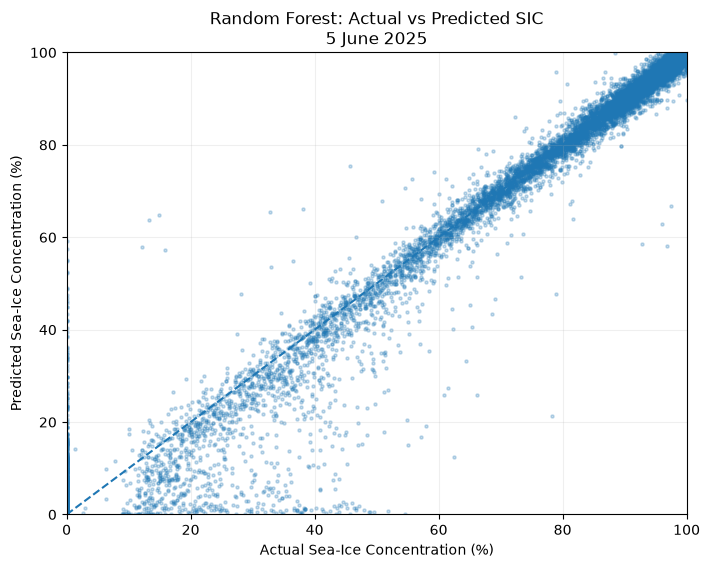

In [64]:
# ============================================
# Actual vs Predicted Sea-Ice Concentration
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    s=5,
    alpha=0.25
)

# Perfect prediction line
plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--"
)

plt.xlabel("Actual Sea-Ice Concentration (%)")
plt.ylabel("Predicted Sea-Ice Concentration (%)")
plt.title("Random Forest: Actual vs Predicted SIC\n5 June 2025")

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.grid(alpha=0.2)
plt.show()

In [65]:
# ============================================
# MODULE 1 — PREDICT SEA-ICE CONCENTRATION
# FOR 5 JUNE 2025
# ============================================

# Start from the forecasting dataframe we already created
test_data = forecast_df[
    forecast_df["time"] == pd.Timestamp("2025-06-05 12:00:00")
].copy()

print("Test data shape:", test_data.shape)
print("Available columns:", test_data.columns.tolist())

# Features used by the trained Random Forest
feature_columns = [
    "lat",
    "lon",
    "sst_celsius",
    "historical_sic",
    "month"
]

# Check that the required features exist
missing_features = [
    col for col in feature_columns
    if col not in test_data.columns
]

print("Missing features:", missing_features)

# Generate predictions
test_data["predicted_sic"] = rf_model.predict(
    test_data[feature_columns]
)

# Keep prediction physically within 0–100%
test_data["predicted_sic"] = np.clip(
    test_data["predicted_sic"],
    0,
    100
)

print("\nPrediction completed.")
print("Prediction range:")
print(
    round(test_data["predicted_sic"].min(), 2),
    "to",
    round(test_data["predicted_sic"].max(), 2),
    "%"
)

print("Number of predicted cells:", len(test_data))

Test data shape: (51706, 10)
Available columns: ['time', 'yc', 'xc', 'sst_celsius', 'sea_ice_concentration', 'lat', 'lon', 'historical_sic', 'month', 'target_sic']
Missing features: []

Prediction completed.
Prediction range:
0.0 to 99.99 %
Number of predicted cells: 51706


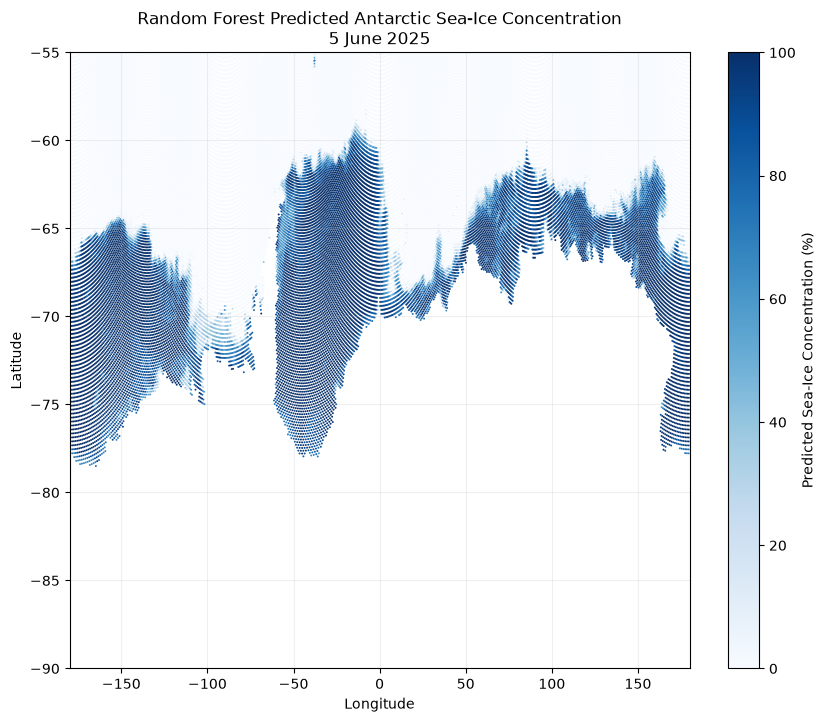

In [66]:
# ============================================
# MODULE 1 — PREDICTED SEA-ICE CONCENTRATION MAP
# 5 JUNE 2025
# ============================================

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    test_data["lon"],
    test_data["lat"],
    c=test_data["predicted_sic"],
    cmap="Blues",
    vmin=0,
    vmax=100,
    s=2,
    linewidths=0
)

plt.colorbar(
    scatter,
    label="Predicted Sea-Ice Concentration (%)"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Random Forest Predicted Antarctic Sea-Ice Concentration\n"
    "5 June 2025"
)

plt.xlim(-180, 180)
plt.ylim(-90, -55)

plt.grid(alpha=0.2)

plt.show()

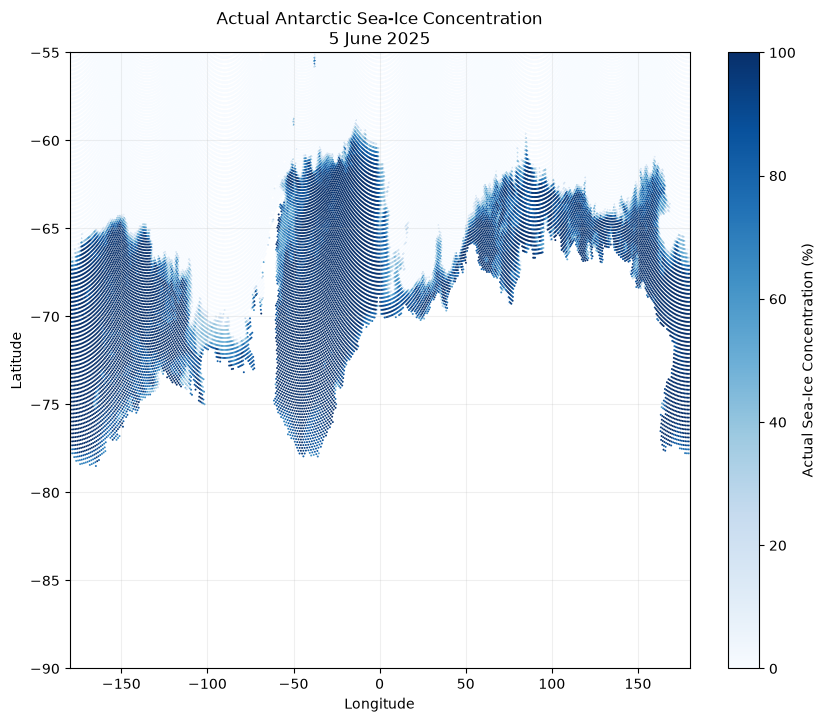

In [67]:
# ============================================
# ACTUAL VS PREDICTED SIC
# ============================================

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    test_data["lon"],
    test_data["lat"],
    c=test_data["target_sic"],
    cmap="Blues",
    vmin=0,
    vmax=100,
    s=2,
    linewidths=0
)

plt.colorbar(
    scatter,
    label="Actual Sea-Ice Concentration (%)"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Actual Antarctic Sea-Ice Concentration\n"
    "5 June 2025"
)

plt.xlim(-180, 180)
plt.ylim(-90, -55)

plt.grid(alpha=0.2)

plt.show()

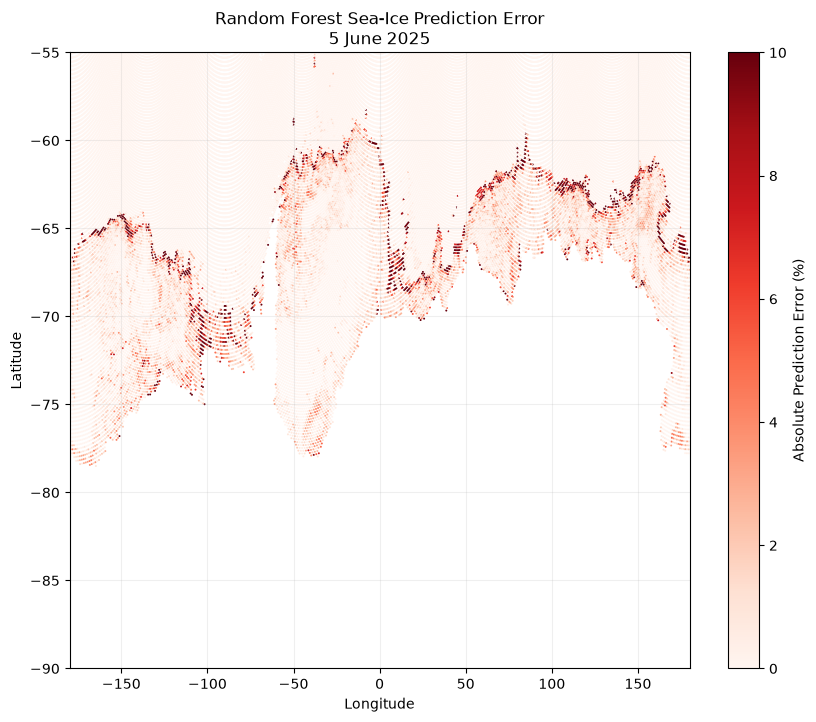

In [68]:
# ============================================
# PREDICTION ERROR MAP
# ============================================

test_data["absolute_error"] = (
    np.abs(
        test_data["target_sic"]
        - test_data["predicted_sic"]
    )
)

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    test_data["lon"],
    test_data["lat"],
    c=test_data["absolute_error"],
    cmap="Reds",
    vmin=0,
    vmax=10,
    s=2,
    linewidths=0
)

plt.colorbar(
    scatter,
    label="Absolute Prediction Error (%)"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Random Forest Sea-Ice Prediction Error\n"
    "5 June 2025"
)

plt.xlim(-180, 180)
plt.ylim(-90, -55)

plt.grid(alpha=0.2)

plt.show()

Feature Importance:
          Feature  Importance
3  historical_sic    0.959546
2     sst_celsius    0.035893
1             lon    0.002634
0             lat    0.001926
4           month    0.000000


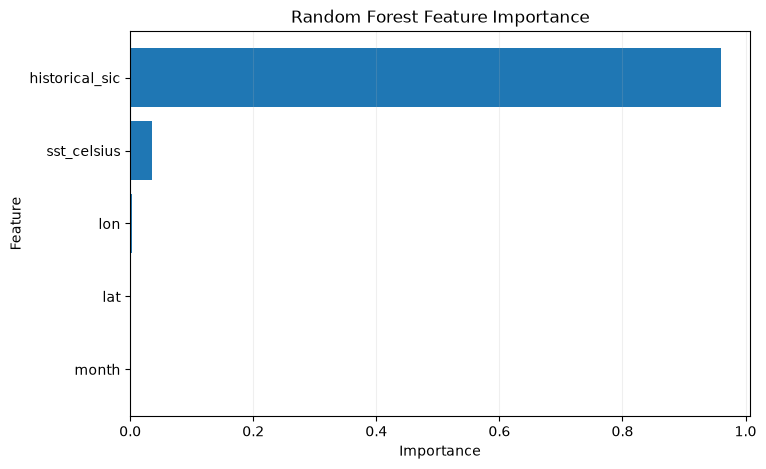

In [69]:
# ============================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print("Feature Importance:")
print(feature_importance)

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.2)

plt.show()

In [70]:
# ============================================
# DETAILED PREDICTION ERROR STATISTICS
# ============================================

errors = test_data["target_sic"] - test_data["predicted_sic"]

print("===== PREDICTION ERROR ANALYSIS =====")

print("Mean Error (Bias):",
      round(errors.mean(), 4), "%")

print("Mean Absolute Error:",
      round(np.abs(errors).mean(), 4), "%")

print("Median Absolute Error:",
      round(np.median(np.abs(errors)), 4), "%")

print("Maximum Absolute Error:",
      round(np.abs(errors).max(), 4), "%")

print("Predictions within ±1%:",
      round((np.abs(errors) <= 1).mean() * 100, 2), "%")

print("Predictions within ±2%:",
      round((np.abs(errors) <= 2).mean() * 100, 2), "%")

print("Predictions within ±5%:",
      round((np.abs(errors) <= 5).mean() * 100, 2), "%")

===== PREDICTION ERROR ANALYSIS =====
Mean Error (Bias): 0.1624 %
Mean Absolute Error: 0.6938 %
Median Absolute Error: 0.0 %
Maximum Absolute Error: 59.1737 %
Predictions within ±1%: 85.85 %
Predictions within ±2%: 92.51 %
Predictions within ±5%: 97.24 %


In [71]:
# ============================================
# SAVE BASELINE RANDOM FOREST MODEL
# ============================================

import joblib
from pathlib import Path

model_dir = Path("../models")
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "module1_random_forest_baseline.joblib"

joblib.dump(rf_model, model_path)

print("Baseline model saved successfully.")
print("Path:", model_path)

Baseline model saved successfully.
Path: ..\models\module1_random_forest_baseline.joblib


In [72]:
# ============================================
# PREPARE DATA FOR TIME-SERIES FORECASTING
# ============================================

import pandas as pd
import numpy as np

# Use the existing Module 1 table
forecast_base = m1_table.copy()

# Make sure time is datetime
forecast_base["time"] = pd.to_datetime(forecast_base["time"])

# Sort by location and time
forecast_base = forecast_base.sort_values(
    ["lat", "lon", "time"]
).reset_index(drop=True)

print("Dataset shape:", forecast_base.shape)

print("\nDates available:")
print(sorted(forecast_base["time"].unique()))

print("\nColumns:")
print(forecast_base.columns.tolist())

Dataset shape: (258467, 7)

Dates available:
[Timestamp('2025-06-01 12:00:00'), Timestamp('2025-06-02 12:00:00'), Timestamp('2025-06-03 12:00:00'), Timestamp('2025-06-04 12:00:00'), Timestamp('2025-06-05 12:00:00')]

Columns:
['time', 'yc', 'xc', 'sst_celsius', 'sea_ice_concentration', 'lat', 'lon']


In [73]:
# ============================================
# CREATE LAG FEATURES
# ============================================

# Keep only the columns needed for forecasting
lag_df = forecast_base[
    ["time", "lat", "lon", "sst_celsius", "sea_ice_concentration"]
].copy()

# Sort by location and time
lag_df = lag_df.sort_values(
    ["lat", "lon", "time"]
).reset_index(drop=True)

# Previous day's SST
lag_df["sst_lag1"] = (
    lag_df.groupby(["lat", "lon"])["sst_celsius"].shift(1)
)

# Previous day's sea-ice concentration
lag_df["sic_lag1"] = (
    lag_df.groupby(["lat", "lon"])["sea_ice_concentration"].shift(1)
)

# Two days before
lag_df["sst_lag2"] = (
    lag_df.groupby(["lat", "lon"])["sst_celsius"].shift(2)
)

lag_df["sic_lag2"] = (
    lag_df.groupby(["lat", "lon"])["sea_ice_concentration"].shift(2)
)

# Target = next day's sea-ice concentration
lag_df["target_sic"] = (
    lag_df.groupby(["lat", "lon"])["sea_ice_concentration"].shift(-1)
)

print("Lag dataset shape:", lag_df.shape)

print("\nColumns:")
print(lag_df.columns.tolist())

print("\nMissing values:")
print(lag_df[
    ["sst_lag1", "sic_lag1", "sst_lag2", "sic_lag2", "target_sic"]
].isna().sum())

print("\nSample:")
print(
    lag_df[
        [
            "time",
            "lat",
            "lon",
            "sst_celsius",
            "sea_ice_concentration",
            "sst_lag1",
            "sic_lag1",
            "target_sic"
        ]
    ].head(10)
)

Lag dataset shape: (258467, 10)

Columns:
['time', 'lat', 'lon', 'sst_celsius', 'sea_ice_concentration', 'sst_lag1', 'sic_lag1', 'sst_lag2', 'sic_lag2', 'target_sic']

Missing values:
sst_lag1       51709
sic_lag1       51709
sst_lag2      103416
sic_lag2      103416
target_sic     51709
dtype: int64

Sample:
                 time        lat         lon  sst_celsius  \
0 2025-06-01 12:00:00 -78.495102 -164.744888    -1.839996   
1 2025-06-02 12:00:00 -78.495102 -164.744888    -1.859985   
2 2025-06-03 12:00:00 -78.495102 -164.744888    -1.880005   
3 2025-06-04 12:00:00 -78.495102 -164.744888    -1.829987   
4 2025-06-05 12:00:00 -78.495102 -164.744888    -1.779999   
5 2025-06-01 12:00:00 -78.433861 -168.254364    -1.750000   
6 2025-06-02 12:00:00 -78.433861 -168.254364    -1.760010   
7 2025-06-03 12:00:00 -78.433861 -168.254364    -1.769989   
8 2025-06-04 12:00:00 -78.433861 -168.254364    -1.709991   
9 2025-06-05 12:00:00 -78.433861 -168.254364    -1.720001   

   sea_ice_concen

In [74]:
# ============================================
# VERIFY LAG / TARGET ALIGNMENT
# ============================================

# Pick one grid location that has complete observations
check_location = (
    lag_df.groupby(["lat", "lon"])
    .size()
    .sort_values(ascending=False)
    .index[0]
)

check = lag_df[
    (lag_df["lat"] == check_location[0]) &
    (lag_df["lon"] == check_location[1])
].sort_values("time")

print("Checking location:")
print("Latitude :", check_location[0])
print("Longitude:", check_location[1])

print("\nTime-series alignment:")
print(
    check[
        [
            "time",
            "sst_celsius",
            "sea_ice_concentration",
            "sst_lag1",
            "sic_lag1",
            "sst_lag2",
            "sic_lag2",
            "target_sic"
        ]
    ].to_string(index=False)
)

Checking location:
Latitude : -55.000324
Longitude: 156.0186

Time-series alignment:
               time  sst_celsius  sea_ice_concentration  sst_lag1  sic_lag1  sst_lag2  sic_lag2  target_sic
2025-06-01 12:00:00     6.100006                    0.0       NaN       NaN       NaN       NaN         0.0
2025-06-02 12:00:00     6.540009                    0.0  6.100006       0.0       NaN       NaN         0.0
2025-06-03 12:00:00     6.890015                    0.0  6.540009       0.0  6.100006       0.0         0.0
2025-06-04 12:00:00     6.619995                    0.0  6.890015       0.0  6.540009       0.0         0.0
2025-06-05 12:00:00     6.399994                    0.0  6.619995       0.0  6.890015       0.0         NaN


In [75]:
# ============================================
# CHECK CURRENT SIC DOWNLOAD CONFIGURATION
# ============================================

print("SIC dataset:")
print("satellite-sea-ice-concentration")

print("\nCurrent SIC dates:")
print(sorted(lag_df["time"].dt.strftime("%Y-%m-%d").unique()))

print("\nNumber of SIC dates:",
      lag_df["time"].dt.normalize().nunique())

print("\nCurrent SIC grid:")
print("Rows per date:", 432)
print("Columns per date:", 432)

print("\nNext step:")
print("Expand SIC history before training the lag model.")

SIC dataset:
satellite-sea-ice-concentration

Current SIC dates:
['2025-06-01', '2025-06-02', '2025-06-03', '2025-06-04', '2025-06-05']

Number of SIC dates: 5

Current SIC grid:
Rows per date: 432
Columns per date: 432

Next step:
Expand SIC history before training the lag model.


In [ ]:
# # ============================================
# # DOWNLOAD 30 DAYS OF ANTARCTIC SEA-ICE DATA
# # ============================================

# import cdsapi
# from pathlib import Path

# # CDS dataset
# dataset = "satellite-sea-ice-concentration"

# # Output folder
# sic_30_dir = Path("../data/raw/sic_30days")
# sic_30_dir.mkdir(parents=True, exist_ok=True)

# # Request: Antarctic + AMSR + daily + ICDR
# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     # June 2025
#     "year": ["2025"],
#     "month": ["06"],

#     # 30 days
#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30"
#     ],

#     "version": "3_0"
# }

# target_file = sic_30_dir / "sic_2025-06-01_to_2025-06-30.zip"

# print("Starting SIC download...")
# print("Output:", target_file)

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\nDownload completed.")
# print("File:", target_file)
# print(
#     "Size:",
#     round(target_file.stat().st_size / (1024 ** 2), 2),
#     "MB"
# )

In [76]:
# ============================================
# EXTRACT 30-DAY SIC DATA
# ============================================

import zipfile
from pathlib import Path

archive_file = Path(
    "../data/raw/sic_30days/sic_2025-06-01_to_2025-06-30.zip"
)

extract_folder = Path("../data/raw/sic_30days/extracted")
extract_folder.mkdir(parents=True, exist_ok=True)

# Extract archive
with zipfile.ZipFile(archive_file, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

# List extracted NetCDF files
nc_files = sorted(extract_folder.glob("*.nc"))

print("Extraction completed.")
print("Number of NetCDF files:", len(nc_files))

print("\nExtracted files:")
for f in nc_files:
    print(f.name)

Extraction completed.
Number of NetCDF files: 30

Extracted files:
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506011200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506021200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506031200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506041200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506051200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506061200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506071200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506081200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506091200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506101200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506111200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506121200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506131200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506141200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506151200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506161200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202506171200.nc
ice_conc_sh_ease2-250_icdr-v3p0-

In [77]:
# ============================================
# COMBINE 30 DAILY SIC NETCDF FILES
# ============================================

import xarray as xr
from pathlib import Path

sic_folder = Path("../data/raw/sic_30days/extracted")

nc_files = sorted(sic_folder.glob("*.nc"))

print("Number of files:", len(nc_files))

# Open all files and combine along time
sic_30_ds = xr.open_mfdataset(
    nc_files,
    combine="by_coords"
)

print("\nCombined SIC dataset:")
print(sic_30_ds)

print("\nTime range:")
print(sic_30_ds.time.values[0], "to", sic_30_ds.time.values[-1])

print("\nDimensions:")
print(sic_30_ds.sizes)

print("\nVariables:")
print(list(sic_30_ds.data_vars))

Number of files: 30


C:\Users\acer\AppData\Local\Temp\ipykernel_20980\3097672805.py:15: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  sic_30_ds = xr.open_mfdataset(



Combined SIC dataset:
<xarray.Dataset> Size: 248MB
Dimensions:                         (time: 30, nv: 2, yc: 432, xc: 432)
Coordinates:
  * time                            (time) datetime64[ns] 240B 2025-06-01T12:...
  * yc                              (yc) float64 3kB 5.388e+03 ... -5.388e+03
  * xc                              (xc) float64 3kB -5.388e+03 ... 5.388e+03
    lat                             (yc, xc) float32 746kB dask.array<chunksize=(432, 432), meta=np.ndarray>
    lon                             (yc, xc) float32 746kB dask.array<chunksize=(432, 432), meta=np.ndarray>
Dimensions without coordinates: nv
Data variables:
    Lambert_Azimuthal_Grid          (time) int32 120B -2147483647 ... -214748...
    time_bnds                       (time, nv) datetime64[ns] 480B dask.array<chunksize=(1, 2), meta=np.ndarray>
    ice_conc                        (time, yc, xc) float64 45MB dask.array<chunksize=(1, 432, 432), meta=np.ndarray>
    raw_ice_conc_values             (time, yc,

In [78]:
# ============================================
# CREATE 30-DAY SIC FORECASTING DATA
# ============================================

import pandas as pd
import numpy as np

# Keep only the main SIC variable
sic30 = sic_30_ds["ice_conc"]

# Convert to DataFrame
sic30_df = sic30.to_dataframe(
    name="sea_ice_concentration"
).reset_index()

# Keep only required columns
sic30_df = sic30_df[
    ["time", "yc", "xc", "sea_ice_concentration"]
]

# Add geographic coordinates
lat_map = sic_30_ds["lat"].to_dataframe(
    name="lat"
).reset_index()

lon_map = sic_30_ds["lon"].to_dataframe(
    name="lon"
).reset_index()

lat_map = lat_map[["yc", "xc", "lat"]]
lon_map = lon_map[["yc", "xc", "lon"]]

sic30_df = sic30_df.merge(
    lat_map,
    on=["yc", "xc"],
    how="left"
)

sic30_df = sic30_df.merge(
    lon_map,
    on=["yc", "xc"],
    how="left"
)

# Sort chronologically for each grid cell
sic30_df = sic30_df.sort_values(
    ["yc", "xc", "time"]
).reset_index(drop=True)

# Month
sic30_df["month"] = sic30_df["time"].dt.month

# Previous-day SIC
sic30_df["sic_lag1"] = (
    sic30_df
    .groupby(["yc", "xc"])["sea_ice_concentration"]
    .shift(1)
)

# Two-days-ago SIC
sic30_df["sic_lag2"] = (
    sic30_df
    .groupby(["yc", "xc"])["sea_ice_concentration"]
    .shift(2)
)

# Next-day SIC = prediction target
sic30_df["target_sic"] = (
    sic30_df
    .groupby(["yc", "xc"])["sea_ice_concentration"]
    .shift(-1)
)

print("30-day forecasting dataset shape:")
print(sic30_df.shape)

print("\nDates:")
print(
    sic30_df["time"]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print("\nColumns:")
print(sic30_df.columns.tolist())

print("\nMissing values:")
print(
    sic30_df[
        [
            "sic_lag1",
            "sic_lag2",
            "target_sic"
        ]
    ].isna().sum()
)

30-day forecasting dataset shape:
(5598720, 12)

Dates:
[Timestamp('2025-06-01 12:00:00'), Timestamp('2025-06-02 12:00:00'), Timestamp('2025-06-03 12:00:00'), Timestamp('2025-06-04 12:00:00'), Timestamp('2025-06-05 12:00:00'), Timestamp('2025-06-06 12:00:00'), Timestamp('2025-06-07 12:00:00'), Timestamp('2025-06-08 12:00:00'), Timestamp('2025-06-09 12:00:00'), Timestamp('2025-06-10 12:00:00'), Timestamp('2025-06-11 12:00:00'), Timestamp('2025-06-12 12:00:00'), Timestamp('2025-06-13 12:00:00'), Timestamp('2025-06-14 12:00:00'), Timestamp('2025-06-15 12:00:00'), Timestamp('2025-06-16 12:00:00'), Timestamp('2025-06-17 12:00:00'), Timestamp('2025-06-18 12:00:00'), Timestamp('2025-06-19 12:00:00'), Timestamp('2025-06-20 12:00:00'), Timestamp('2025-06-21 12:00:00'), Timestamp('2025-06-22 12:00:00'), Timestamp('2025-06-23 12:00:00'), Timestamp('2025-06-24 12:00:00'), Timestamp('2025-06-25 12:00:00'), Timestamp('2025-06-26 12:00:00'), Timestamp('2025-06-27 12:00:00'), Timestamp('2025-06-28 12:

In [79]:
# ============================================
# CLEAN DUPLICATE LAT/LON COLUMNS
# ============================================

print("Columns before cleaning:")
print(sic30_df.columns.tolist())

# Remove duplicated column names
sic30_df = sic30_df.loc[:, ~sic30_df.columns.duplicated()]

print("\nColumns after cleaning:")
print(sic30_df.columns.tolist())

print("\nShape:")
print(sic30_df.shape)

Columns before cleaning:
['time', 'yc', 'xc', 'sea_ice_concentration', 'lat', 'lat', 'lon', 'lon', 'month', 'sic_lag1', 'sic_lag2', 'target_sic']

Columns after cleaning:
['time', 'yc', 'xc', 'sea_ice_concentration', 'lat', 'lon', 'month', 'sic_lag1', 'sic_lag2', 'target_sic']

Shape:
(5598720, 10)


In [80]:
# ============================================
# PREPARE VALID ML OBSERVATIONS
# ============================================

feature_columns = [
    "lat",
    "lon",
    "sea_ice_concentration",
    "sic_lag1",
    "sic_lag2",
    "month"
]

target_column = "target_sic"

ml_df = sic30_df.dropna(
    subset=feature_columns + [target_column]
).copy()

print("Full forecasting dataset:", sic30_df.shape)
print("Valid ML observations:", ml_df.shape)

print("\nDates available:")
print(
    ml_df["time"]
    .dt.strftime("%Y-%m-%d")
    .drop_duplicates()
    .tolist()
)

print("\nMissing values:")
print(
    ml_df[feature_columns + [target_column]]
    .isna()
    .sum()
)

Full forecasting dataset: (5598720, 10)
Valid ML observations: (4139613, 10)

Dates available:
['2025-06-03', '2025-06-04', '2025-06-05', '2025-06-06', '2025-06-07', '2025-06-08', '2025-06-09', '2025-06-10', '2025-06-11', '2025-06-12', '2025-06-13', '2025-06-14', '2025-06-15', '2025-06-16', '2025-06-17', '2025-06-18', '2025-06-19', '2025-06-20', '2025-06-21', '2025-06-22', '2025-06-23', '2025-06-24', '2025-06-25', '2025-06-26', '2025-06-27', '2025-06-28', '2025-06-29']

Missing values:
lat                      0
lon                      0
sea_ice_concentration    0
sic_lag1                 0
sic_lag2                 0
month                    0
target_sic               0
dtype: int64


In [81]:
# ============================================
# CHRONOLOGICAL TRAIN / TEST SPLIT
# ============================================

# Make sure time is datetime
ml_df["time"] = pd.to_datetime(ml_df["time"])

# Features for the improved model
feature_columns = [
    "lat",
    "lon",
    "sea_ice_concentration",
    "sic_lag1",
    "sic_lag2"
]

target_column = "target_sic"

# Training period
train_df = ml_df[
    ml_df["time"] <= "2025-06-27"
].copy()

# Final test period
test_df = ml_df[
    ml_df["time"] >= "2025-06-28"
].copy()

print("Training dates:")
print(sorted(train_df["time"].unique()))

print("\nTesting dates:")
print(sorted(test_df["time"].unique()))

print("\nTraining rows:", len(train_df))
print("Testing rows :", len(test_df))

Training dates:
[Timestamp('2025-06-03 12:00:00'), Timestamp('2025-06-04 12:00:00'), Timestamp('2025-06-05 12:00:00'), Timestamp('2025-06-06 12:00:00'), Timestamp('2025-06-07 12:00:00'), Timestamp('2025-06-08 12:00:00'), Timestamp('2025-06-09 12:00:00'), Timestamp('2025-06-10 12:00:00'), Timestamp('2025-06-11 12:00:00'), Timestamp('2025-06-12 12:00:00'), Timestamp('2025-06-13 12:00:00'), Timestamp('2025-06-14 12:00:00'), Timestamp('2025-06-15 12:00:00'), Timestamp('2025-06-16 12:00:00'), Timestamp('2025-06-17 12:00:00'), Timestamp('2025-06-18 12:00:00'), Timestamp('2025-06-19 12:00:00'), Timestamp('2025-06-20 12:00:00'), Timestamp('2025-06-21 12:00:00'), Timestamp('2025-06-22 12:00:00'), Timestamp('2025-06-23 12:00:00'), Timestamp('2025-06-24 12:00:00'), Timestamp('2025-06-25 12:00:00'), Timestamp('2025-06-26 12:00:00')]

Testing dates:
[Timestamp('2025-06-28 12:00:00'), Timestamp('2025-06-29 12:00:00')]

Training rows: 3679656
Testing rows : 306638


In [82]:
# ============================================
# REDUCE TRAINING SIZE FOR LAPTOP-FRIENDLY ML
# ============================================

# Maximum training samples
MAX_TRAIN_ROWS = 400_000

if len(train_df) > MAX_TRAIN_ROWS:
    train_sample = train_df.sample(
        n=MAX_TRAIN_ROWS,
        random_state=42
    )
else:
    train_sample = train_df.copy()

print("Original training rows:", len(train_df))
print("Training rows used:", len(train_sample))
print("Test rows:", len(test_df))

print("\nTraining date range:")
print(
    train_sample["time"].min(),
    "to",
    train_sample["time"].max()
)

Original training rows: 3679656
Training rows used: 400000
Test rows: 306638

Training date range:
2025-06-03 12:00:00 to 2025-06-26 12:00:00


In [83]:
# ============================================
# CREATE ML MATRICES
# ============================================

X_train = train_sample[feature_columns].astype("float32")
y_train = train_sample[target_column].astype("float32")

X_test = test_df[feature_columns].astype("float32")
y_test = test_df[target_column].astype("float32")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (400000, 5)
y_train: (400000,)
X_test : (306638, 5)
y_test : (306638,)


In [84]:
# ============================================
# IMPROVED RANDOM FOREST — LAG MODEL
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
import time

# Create a laptop-friendly model
lag_rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("Training improved Random Forest...")
start_time = time.time()

lag_rf_model.fit(X_train, y_train)

elapsed = time.time() - start_time

print("Training completed.")
print("Training time:", round(elapsed, 2), "seconds")

Training improved Random Forest...
Training completed.
Training time: 17.98 seconds


In [85]:
# ============================================
# EVALUATE IMPROVED RANDOM FOREST
# ============================================

print("Making predictions...")

y_pred_lag = lag_rf_model.predict(X_test)

# Keep predictions physically valid
y_pred_lag = np.clip(y_pred_lag, 0, 100)

mae_lag = mean_absolute_error(y_test, y_pred_lag)
rmse_lag = np.sqrt(mean_squared_error(y_test, y_pred_lag))
r2_lag = r2_score(y_test, y_pred_lag)

print("\n===== IMPROVED RANDOM FOREST RESULTS =====")
print("MAE :", round(mae_lag, 4), "%")
print("RMSE:", round(rmse_lag, 4), "%")
print("R²  :", round(r2_lag, 4))

Making predictions...

===== IMPROVED RANDOM FOREST RESULTS =====
MAE : 0.6535 %
RMSE: 3.2036 %
R²  : 0.9898


In [86]:
# ============================================
# LAG MODEL — UNSEEN-DAY PREDICTION
# ============================================

# Make predictions for the test period
test_results = test_df[
    ["time", "yc", "xc", "lat", "lon",
     "sea_ice_concentration", "sic_lag1", "sic_lag2",
     "target_sic"]
].copy()

test_results["predicted_sic"] = y_pred_lag

# Select the last available forecast day
forecast_day = test_results["time"].max()

day_results = test_results[
    test_results["time"] == forecast_day
].copy()

print("Forecast day:", forecast_day)
print("Grid cells:", len(day_results))

print("\nActual SIC range:")
print(
    round(day_results["target_sic"].min(), 2),
    "to",
    round(day_results["target_sic"].max(), 2)
)

print("\nPredicted SIC range:")
print(
    round(day_results["predicted_sic"].min(), 2),
    "to",
    round(day_results["predicted_sic"].max(), 2)
)

print("\nDay MAE:")
print(
    round(
        mean_absolute_error(
            day_results["target_sic"],
            day_results["predicted_sic"]
        ),
        4
    ),
    "%"
)

Forecast day: 2025-06-29 12:00:00
Grid cells: 153319

Actual SIC range:
0.0 to 100.0

Predicted SIC range:
0.0 to 99.95

Day MAE:
0.6489 %


Forecast day: 2025-06-29 12:00:00
Rows before aggregation: 153319
Unique grid cells: 153319
Grid: 432 x 432


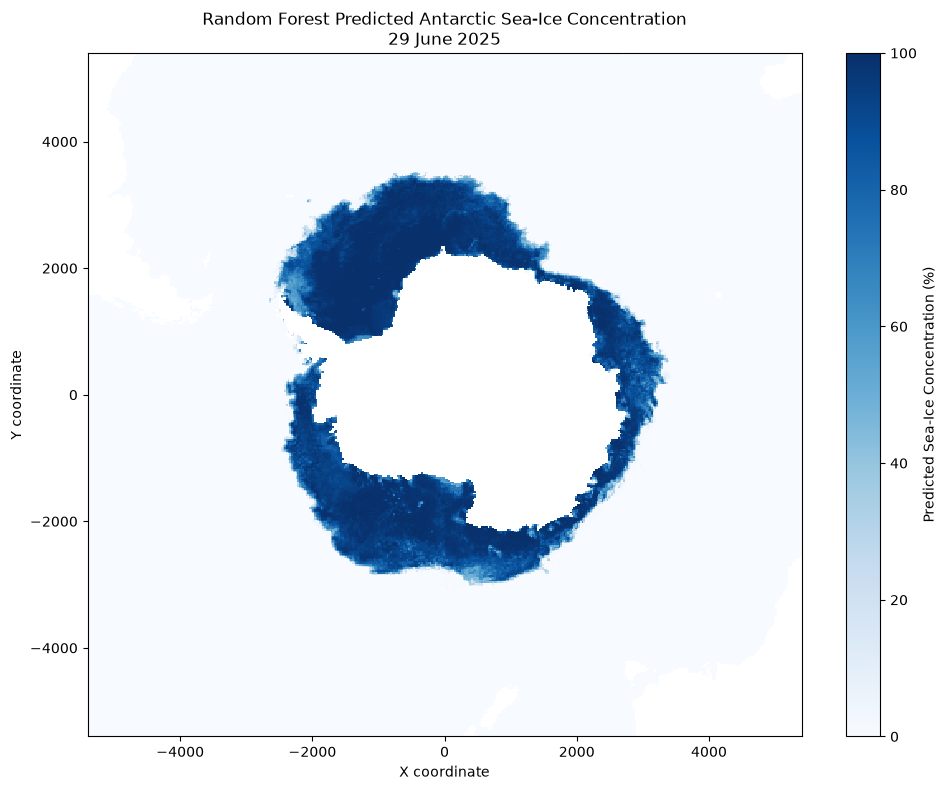

In [87]:
# ============================================
# MEMORY-SAFE PREDICTION MAP
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------
# Select one forecast day
# --------------------------------------------

forecast_day = test_results["time"].max()

day_results = test_results[
    test_results["time"] == forecast_day
].copy()

print("Forecast day:", forecast_day)
print("Rows before aggregation:", len(day_results))

# --------------------------------------------
# Remove duplicate grid cells
# --------------------------------------------

day_results = (
    day_results
    .groupby(["yc", "xc"], as_index=False)
    .agg({
        "predicted_sic": "mean",
        "target_sic": "mean"
    })
)

print("Unique grid cells:", len(day_results))

# --------------------------------------------
# Get original SIC grid coordinates
# --------------------------------------------

yc_values = np.sort(sic_30_ds["yc"].values)
xc_values = np.sort(sic_30_ds["xc"].values)

ny = len(yc_values)
nx = len(xc_values)

print("Grid:", ny, "x", nx)

# --------------------------------------------
# Create fixed-size grids
# --------------------------------------------

pred_grid = np.full(
    (ny, nx),
    np.nan,
    dtype=np.float32
)

actual_grid = np.full(
    (ny, nx),
    np.nan,
    dtype=np.float32
)

yc_to_idx = {
    value: i
    for i, value in enumerate(yc_values)
}

xc_to_idx = {
    value: i
    for i, value in enumerate(xc_values)
}

for row in day_results.itertuples(index=False):

    y_idx = yc_to_idx.get(row.yc)
    x_idx = xc_to_idx.get(row.xc)

    if y_idx is not None and x_idx is not None:
        pred_grid[y_idx, x_idx] = row.predicted_sic
        actual_grid[y_idx, x_idx] = row.target_sic

# --------------------------------------------
# Plot using SIC projection coordinates
# This avoids NaN lat/lon problems
# --------------------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

mesh = ax.pcolormesh(
    xc_values,
    yc_values,
    pred_grid,
    shading="auto",
    cmap="Blues",
    vmin=0,
    vmax=100
)

plt.colorbar(
    mesh,
    ax=ax,
    label="Predicted Sea-Ice Concentration (%)"
)

ax.set_title(
    "Random Forest Predicted Antarctic Sea-Ice Concentration\n"
    + forecast_day.strftime("%d %B %Y")
)

ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")

plt.tight_layout()
plt.show()

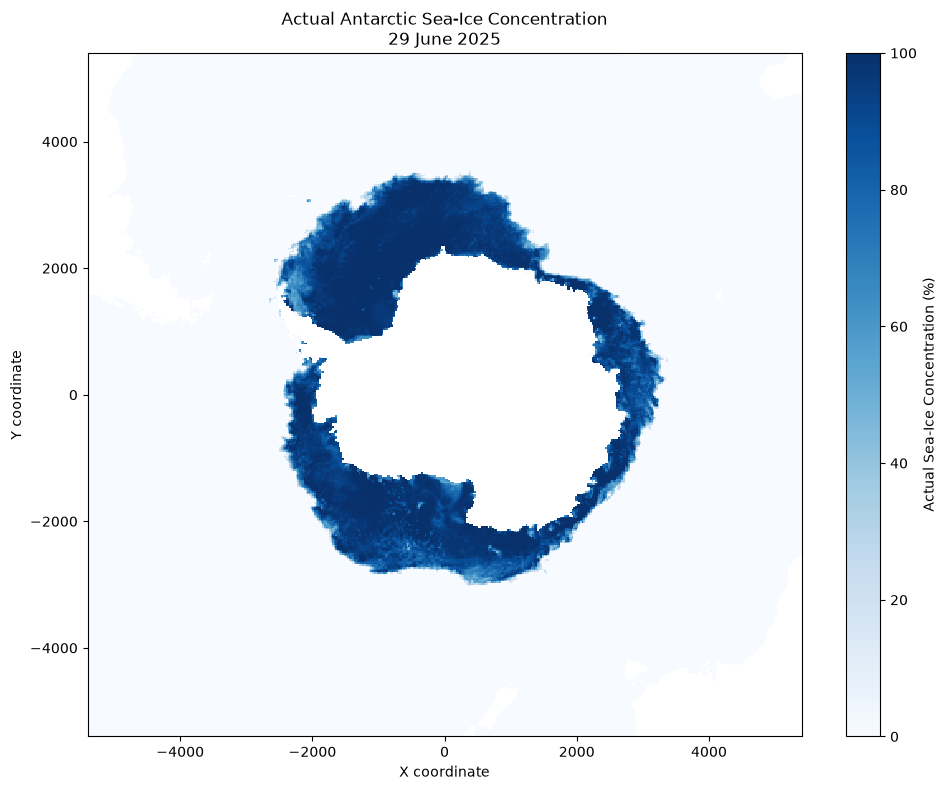

In [88]:
# ============================================
# ACTUAL SIC MAP — SAME FORECAST DAY
# ============================================

fig, ax = plt.subplots(figsize=(10, 8))

mesh = ax.pcolormesh(
    xc_values,
    yc_values,
    actual_grid,
    shading="auto",
    cmap="Blues",
    vmin=0,
    vmax=100
)

plt.colorbar(
    mesh,
    ax=ax,
    label="Actual Sea-Ice Concentration (%)"
)

ax.set_title(
    "Actual Antarctic Sea-Ice Concentration\n"
    + forecast_day.strftime("%d %B %Y")
)

ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")

plt.tight_layout()
plt.show()

Mean absolute error: 0.6489 %
Median absolute error: 0.0 %
Maximum absolute error: 72.4862 %


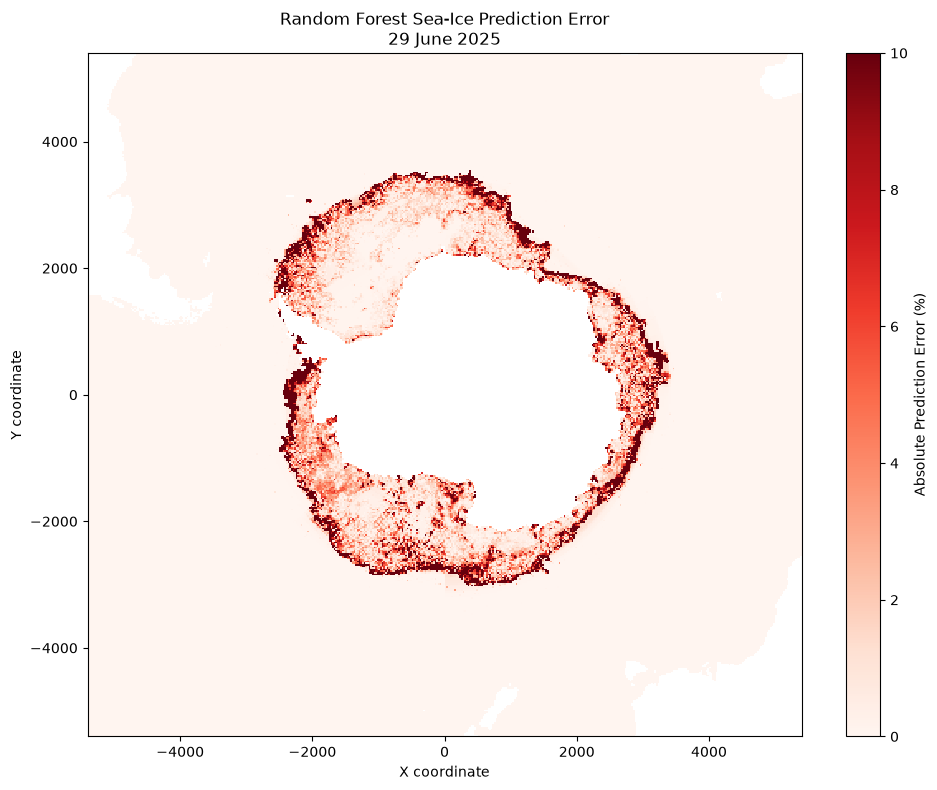

In [89]:
# ============================================
# ABSOLUTE ERROR MAP
# ============================================

error_grid = np.abs(
    actual_grid - pred_grid
)

print("Mean absolute error:",
      round(np.nanmean(error_grid), 4), "%")

print("Median absolute error:",
      round(np.nanmedian(error_grid), 4), "%")

print("Maximum absolute error:",
      round(np.nanmax(error_grid), 4), "%")

fig, ax = plt.subplots(figsize=(10, 8))

mesh = ax.pcolormesh(
    xc_values,
    yc_values,
    error_grid,
    shading="auto",
    cmap="Reds",
    vmin=0,
    vmax=10
)

plt.colorbar(
    mesh,
    ax=ax,
    label="Absolute Prediction Error (%)"
)

ax.set_title(
    "Random Forest Sea-Ice Prediction Error\n"
    + forecast_day.strftime("%d %B %Y")
)

ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")

plt.tight_layout()
plt.show()

In [90]:
# ============================================
# 29 JUNE — DETAILED PREDICTION EVALUATION
# ============================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Remove invalid cells
valid = (
    np.isfinite(day_results["target_sic"].values)
    &
    np.isfinite(day_results["predicted_sic"].values)
)

actual = day_results.loc[valid, "target_sic"].values
predicted = day_results.loc[valid, "predicted_sic"].values

mae_day = mean_absolute_error(actual, predicted)
rmse_day = np.sqrt(mean_squared_error(actual, predicted))
r2_day = r2_score(actual, predicted)

abs_error = np.abs(actual - predicted)

print("==========================================")
print("29 JUNE 2025 — FORECAST PERFORMANCE")
print("==========================================")

print("Valid cells:", len(actual))
print("MAE :", round(mae_day, 4), "%")
print("RMSE:", round(rmse_day, 4), "%")
print("R²  :", round(r2_day, 4))

print("\nError distribution:")
print("Median absolute error:",
      round(np.median(abs_error), 4), "%")

print("90th percentile error:",
      round(np.percentile(abs_error, 90), 4), "%")

print("95th percentile error:",
      round(np.percentile(abs_error, 95), 4), "%")

print("Cells within ±1%:",
      round(np.mean(abs_error <= 1) * 100, 2), "%")

print("Cells within ±2%:",
      round(np.mean(abs_error <= 2) * 100, 2), "%")

print("Cells within ±5%:",
      round(np.mean(abs_error <= 5) * 100, 2), "%")

29 JUNE 2025 — FORECAST PERFORMANCE
Valid cells: 153319
MAE : 0.6489 %
RMSE: 3.2091 %
R²  : 0.9898

Error distribution:
Median absolute error: 0.0 %
90th percentile error: 0.8628 %
95th percentile error: 3.2084 %
Cells within ±1%: 90.51 %
Cells within ±2%: 93.16 %
Cells within ±5%: 96.55 %


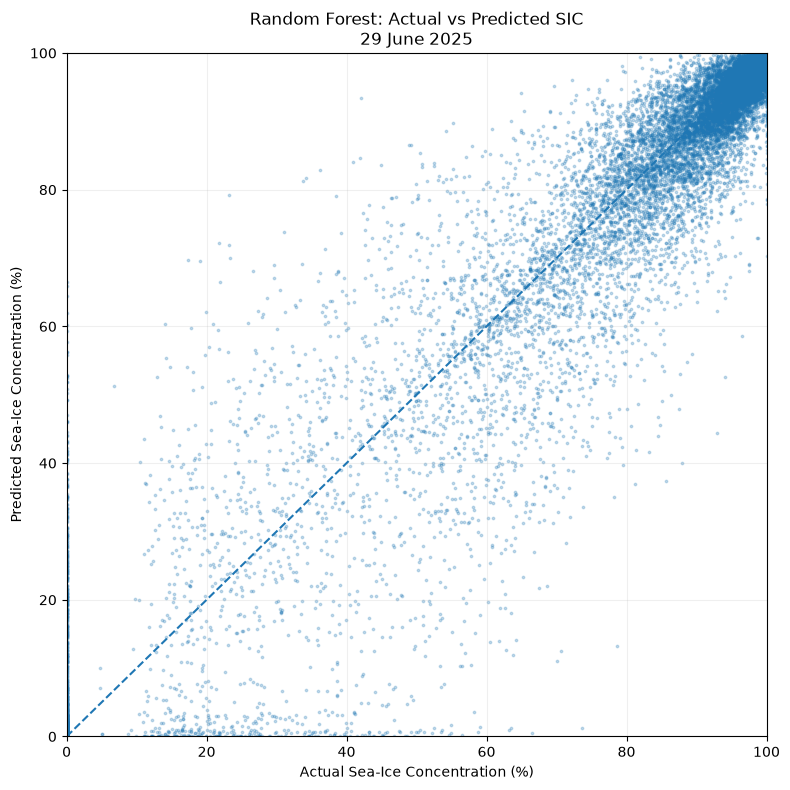

In [91]:
# ============================================
# ACTUAL VS PREDICTED — 29 JUNE
# ============================================

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    actual,
    predicted,
    s=3,
    alpha=0.25
)

ax.plot(
    [0, 100],
    [0, 100],
    linestyle="--"
)

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

ax.set_xlabel("Actual Sea-Ice Concentration (%)")
ax.set_ylabel("Predicted Sea-Ice Concentration (%)")

ax.set_title(
    "Random Forest: Actual vs Predicted SIC\n"
    "29 June 2025"
)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [98]:
# ============================================
# RECOVER 30-DAY FORECASTING DATAFRAME
# ============================================

import pandas as pd
import numpy as np

# ------------------------------------------------
# Convert the 30-day SIC dataset to a DataFrame
# ------------------------------------------------

sic30_df = (
    sic_30_ds[
        ["ice_conc", "lat", "lon"]
    ]
    .to_dataframe()
    .reset_index()
)

print("Raw SIC dataframe:", sic30_df.shape)

# ------------------------------------------------
# Rename SIC variable
# ------------------------------------------------

sic30_df = sic30_df.rename(
    columns={
        "ice_conc": "sea_ice_concentration"
    }
)

# ------------------------------------------------
# Make sure time is datetime
# ------------------------------------------------

sic30_df["time"] = pd.to_datetime(
    sic30_df["time"]
)

# ------------------------------------------------
# Sort by spatial cell and time
# ------------------------------------------------

sic30_df = sic30_df.sort_values(
    ["yc", "xc", "time"]
).reset_index(drop=True)

# ------------------------------------------------
# Historical SIC
# ------------------------------------------------

sic30_df["historical_sic"] = (
    sic30_df["sea_ice_concentration"]
)

# ------------------------------------------------
# Month
# ------------------------------------------------

sic30_df["month"] = (
    sic30_df["time"].dt.month
)

# ------------------------------------------------
# Next-day target
# ------------------------------------------------

sic30_df["target_sic"] = (
    sic30_df
    .groupby(["yc", "xc"])["sea_ice_concentration"]
    .shift(-1)
)

# ------------------------------------------------
# Remove invalid target rows
# ------------------------------------------------

full_forecasting_df = sic30_df.dropna(
    subset=[
        "lat",
        "lon",
        "sea_ice_concentration",
        "historical_sic",
        "target_sic"
    ]
).reset_index(drop=True)

print("\nRecovered forecasting dataframe:")
print(full_forecasting_df.shape)

print("\nDates:")
print(
    sorted(
        full_forecasting_df["time"]
        .drop_duplicates()
        .tolist()
    )
)

print("\nColumns:")
print(full_forecasting_df.columns.tolist())

Raw SIC dataframe: (5598720, 6)

Recovered forecasting dataframe:
(4446251, 9)

Dates:
[Timestamp('2025-06-01 12:00:00'), Timestamp('2025-06-02 12:00:00'), Timestamp('2025-06-03 12:00:00'), Timestamp('2025-06-04 12:00:00'), Timestamp('2025-06-05 12:00:00'), Timestamp('2025-06-06 12:00:00'), Timestamp('2025-06-07 12:00:00'), Timestamp('2025-06-08 12:00:00'), Timestamp('2025-06-09 12:00:00'), Timestamp('2025-06-10 12:00:00'), Timestamp('2025-06-11 12:00:00'), Timestamp('2025-06-12 12:00:00'), Timestamp('2025-06-13 12:00:00'), Timestamp('2025-06-14 12:00:00'), Timestamp('2025-06-15 12:00:00'), Timestamp('2025-06-16 12:00:00'), Timestamp('2025-06-17 12:00:00'), Timestamp('2025-06-18 12:00:00'), Timestamp('2025-06-19 12:00:00'), Timestamp('2025-06-20 12:00:00'), Timestamp('2025-06-21 12:00:00'), Timestamp('2025-06-22 12:00:00'), Timestamp('2025-06-23 12:00:00'), Timestamp('2025-06-24 12:00:00'), Timestamp('2025-06-25 12:00:00'), Timestamp('2025-06-26 12:00:00'), Timestamp('2025-06-27 12:00:

In [99]:
# ============================================
# 30-DAY FAIR BASELINE — TRAIN / TEST SPLIT
# ============================================

# --------------------------------------------
# Define features
# --------------------------------------------

baseline_features = [
    "lat",
    "lon",
    "historical_sic",
    "month"
]

target_column = "target_sic"

# --------------------------------------------
# Training period
# --------------------------------------------

train_start = pd.Timestamp("2025-06-03 12:00:00")
train_end   = pd.Timestamp("2025-06-26 12:00:00")

test_date = pd.Timestamp("2025-06-29 12:00:00")

# --------------------------------------------
# Create splits
# --------------------------------------------

baseline_train = full_forecasting_df[
    (full_forecasting_df["time"] >= train_start) &
    (full_forecasting_df["time"] <= train_end)
].copy()

baseline_test = full_forecasting_df[
    full_forecasting_df["time"] == test_date
].copy()

print("Baseline training rows:", len(baseline_train))
print("Baseline test rows:", len(baseline_test))

print("\nTraining dates:")
print(
    sorted(
        baseline_train["time"]
        .drop_duplicates()
        .tolist()
    )
)

print("\nTesting date:")
print(
    baseline_test["time"]
    .drop_duplicates()
    .tolist()
)

# --------------------------------------------
# Keep only valid ML observations
# --------------------------------------------

baseline_train = baseline_train.dropna(
    subset=baseline_features + [target_column]
).reset_index(drop=True)

baseline_test = baseline_test.dropna(
    subset=baseline_features + [target_column]
).reset_index(drop=True)

print("\nAfter removing invalid rows:")
print("Training:", len(baseline_train))
print("Testing :", len(baseline_test))

# --------------------------------------------
# Sample training data
# Keep memory usage reasonable
# --------------------------------------------

MAX_TRAIN_ROWS = 400_000

if len(baseline_train) > MAX_TRAIN_ROWS:
    baseline_train = baseline_train.sample(
        n=MAX_TRAIN_ROWS,
        random_state=42
    ).reset_index(drop=True)

print("\nFinal training rows:", len(baseline_train))
print("Final testing rows :", len(baseline_test))

Baseline training rows: 3679656
Baseline test rows: 153319

Training dates:
[Timestamp('2025-06-03 12:00:00'), Timestamp('2025-06-04 12:00:00'), Timestamp('2025-06-05 12:00:00'), Timestamp('2025-06-06 12:00:00'), Timestamp('2025-06-07 12:00:00'), Timestamp('2025-06-08 12:00:00'), Timestamp('2025-06-09 12:00:00'), Timestamp('2025-06-10 12:00:00'), Timestamp('2025-06-11 12:00:00'), Timestamp('2025-06-12 12:00:00'), Timestamp('2025-06-13 12:00:00'), Timestamp('2025-06-14 12:00:00'), Timestamp('2025-06-15 12:00:00'), Timestamp('2025-06-16 12:00:00'), Timestamp('2025-06-17 12:00:00'), Timestamp('2025-06-18 12:00:00'), Timestamp('2025-06-19 12:00:00'), Timestamp('2025-06-20 12:00:00'), Timestamp('2025-06-21 12:00:00'), Timestamp('2025-06-22 12:00:00'), Timestamp('2025-06-23 12:00:00'), Timestamp('2025-06-24 12:00:00'), Timestamp('2025-06-25 12:00:00'), Timestamp('2025-06-26 12:00:00')]

Testing date:
[Timestamp('2025-06-29 12:00:00')]

After removing invalid rows:
Training: 3679656
Testing :

In [100]:
# ============================================
# TRAIN 30-DAY FAIR BASELINE RANDOM FOREST
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
import time
import joblib
from pathlib import Path

# --------------------------------------------
# Create ML matrices
# --------------------------------------------

X_train_base = (
    baseline_train[baseline_features]
    .astype("float32")
)

y_train_base = (
    baseline_train[target_column]
    .astype("float32")
)

X_test_base = (
    baseline_test[baseline_features]
    .astype("float32")
)

y_test_base = (
    baseline_test[target_column]
    .astype("float32")
)

print("X_train:", X_train_base.shape)
print("y_train:", y_train_base.shape)
print("X_test :", X_test_base.shape)
print("y_test :", y_test_base.shape)

# --------------------------------------------
# Create model
# --------------------------------------------

baseline30_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

# --------------------------------------------
# Train
# --------------------------------------------

print("\nTraining 30-day baseline Random Forest...")

start_time = time.time()

baseline30_model.fit(
    X_train_base,
    y_train_base
)

training_time = time.time() - start_time

print("Training completed.")
print("Training time:", round(training_time, 2), "seconds")

# --------------------------------------------
# Predict
# --------------------------------------------

print("\nMaking predictions...")

baseline30_pred = baseline30_model.predict(
    X_test_base
)

# Keep predictions physically valid
baseline30_pred = np.clip(
    baseline30_pred,
    0,
    100
)

# --------------------------------------------
# Metrics
# --------------------------------------------

baseline30_mae = mean_absolute_error(
    y_test_base,
    baseline30_pred
)

baseline30_rmse = np.sqrt(
    mean_squared_error(
        y_test_base,
        baseline30_pred
    )
)

baseline30_r2 = r2_score(
    y_test_base,
    baseline30_pred
)

baseline30_error = np.abs(
    y_test_base.to_numpy() -
    baseline30_pred
)

print("\n==========================================")
print("30-DAY BASELINE RANDOM FOREST")
print("==========================================")

print("Test date: 29 June 2025")
print("Valid cells:", len(y_test_base))

print("MAE :", round(baseline30_mae, 4), "%")
print("RMSE:", round(baseline30_rmse, 4), "%")
print("R²  :", round(baseline30_r2, 4))

print("\nError distribution:")

print(
    "Within ±1%:",
    round(
        np.mean(baseline30_error <= 1) * 100,
        2
    ),
    "%"
)

print(
    "Within ±2%:",
    round(
        np.mean(baseline30_error <= 2) * 100,
        2
    ),
    "%"
)

print(
    "Within ±5%:",
    round(
        np.mean(baseline30_error <= 5) * 100,
        2
    ),
    "%"
)

# --------------------------------------------
# Save the fair baseline
# --------------------------------------------

models_folder = Path("../models")
models_folder.mkdir(
    parents=True,
    exist_ok=True
)

baseline30_path = (
    models_folder /
    "module1_30day_baseline_random_forest.joblib"
)

joblib.dump(
    baseline30_model,
    baseline30_path
)

print("\nBaseline model saved:")
print(baseline30_path)

X_train: (400000, 4)
y_train: (400000,)
X_test : (153319, 4)
y_test : (153319,)

Training 30-day baseline Random Forest...
Training completed.
Training time: 14.58 seconds

Making predictions...

30-DAY BASELINE RANDOM FOREST
Test date: 29 June 2025
Valid cells: 153319
MAE : 0.6696 %
RMSE: 3.3257 %
R²  : 0.9891

Error distribution:
Within ±1%: 90.51 %
Within ±2%: 93.02 %
Within ±5%: 96.39 %

Baseline model saved:
..\models\module1_30day_baseline_random_forest.joblib


===== LAG MODEL FEATURE IMPORTANCE =====
                 Feature  Importance
0  sea_ice_concentration    0.993677
1                    lon    0.001914
2                    lat    0.001738
3               sic_lag2    0.001363
4               sic_lag1    0.001308


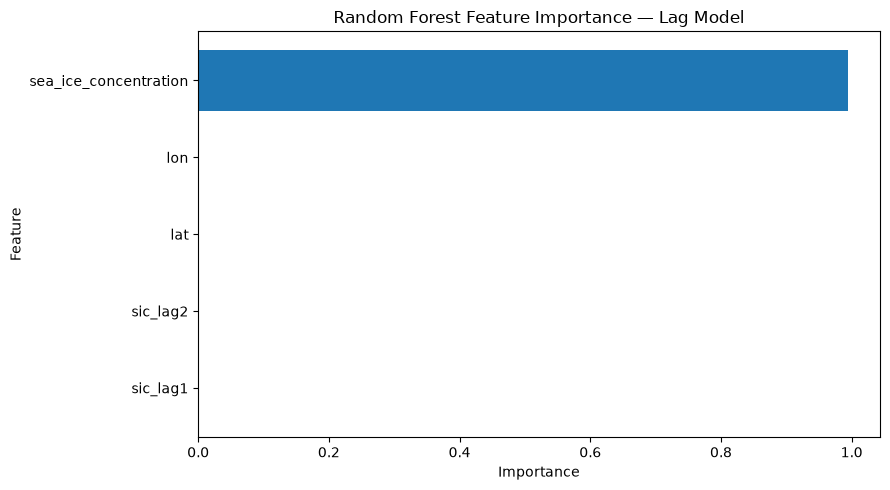

In [107]:
# ============================================
# LAG MODEL — FEATURE IMPORTANCE
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# Exact features used to train lag_rf_model
lag_features = [
    "lat",
    "lon",
    "sea_ice_concentration",
    "sic_lag1",
    "sic_lag2"
]

importance_df = pd.DataFrame({
    "Feature": lag_features,
    "Importance": lag_rf_model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("===== LAG MODEL FEATURE IMPORTANCE =====")
print(importance_df)

plt.figure(figsize=(9, 5))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance — Lag Model")

plt.tight_layout()
plt.show()

In [108]:
# ============================================
# FINAL BASELINE vs LAG MODEL COMPARISON
# ============================================

import pandas as pd

comparison = pd.DataFrame({
    "Metric": [
        "MAE (%)",
        "RMSE (%)",
        "R²",
        "Within ±1%",
        "Within ±2%",
        "Within ±5%"
    ],
    "30-Day Baseline RF": [
        baseline30_mae,
        baseline30_rmse,
        baseline30_r2,
        np.mean(baseline30_error <= 1) * 100,
        np.mean(baseline30_error <= 2) * 100,
        np.mean(baseline30_error <= 5) * 100
    ],
    "Lag RF": [
        0.6489,
        3.2091,
        0.9898,
        90.51,
        93.16,
        96.55
    ]
})

comparison["Improvement"] = (
    comparison["Lag RF"] -
    comparison["30-Day Baseline RF"]
)

print("============================================")
print("FINAL MODULE 1 MODEL COMPARISON")
print("============================================")

print(
    comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

FINAL MODULE 1 MODEL COMPARISON
    Metric  30-Day Baseline RF  Lag RF  Improvement
   MAE (%)              0.6696  0.6489      -0.0207
  RMSE (%)              3.3257  3.2091      -0.1166
        R²              0.9891  0.9898       0.0007
Within ±1%             90.5067 90.5100       0.0033
Within ±2%             93.0159 93.1600       0.1441
Within ±5%             96.3853 96.5500       0.1647


In [112]:
# ============================================
# REBUILD 30-DAY LAG DATA FOR FINAL PREDICTION
# ============================================

import pandas as pd
import numpy as np

# Work from the recovered 30-day SIC dataframe
lag30_df = full_forecasting_df.copy()

lag30_df["time"] = pd.to_datetime(lag30_df["time"])

# Sort spatial cells chronologically
lag30_df = lag30_df.sort_values(
    ["yc", "xc", "time"]
).reset_index(drop=True)

# --------------------------------------------
# Create previous-day SIC features
# --------------------------------------------

lag30_df["sic_lag1"] = (
    lag30_df
    .groupby(["yc", "xc"])["sea_ice_concentration"]
    .shift(1)
)

lag30_df["sic_lag2"] = (
    lag30_df
    .groupby(["yc", "xc"])["sea_ice_concentration"]
    .shift(2)
)

# --------------------------------------------
# Keep only rows usable by lag model
# --------------------------------------------

lag30_df = lag30_df.dropna(
    subset=[
        "lat",
        "lon",
        "sea_ice_concentration",
        "sic_lag1",
        "sic_lag2",
        "target_sic"
    ]
).reset_index(drop=True)

print("30-day lag dataframe:", lag30_df.shape)

print("\nDates available:")
print(
    sorted(
        lag30_df["time"]
        .drop_duplicates()
        .tolist()
    )
)

# --------------------------------------------
# Check 29 June
# --------------------------------------------

june29 = lag30_df[
    lag30_df["time"] == pd.Timestamp("2025-06-29 12:00:00")
].copy()

print("\n29-June rows:", len(june29))

print("\n29-June columns:")
print(june29.columns.tolist())

print("\n29-June sample:")
print(
    june29[
        [
            "time",
            "lat",
            "lon",
            "sea_ice_concentration",
            "sic_lag1",
            "sic_lag2",
            "target_sic"
        ]
    ].head()
)

30-day lag dataframe: (4139613, 11)

Dates available:
[Timestamp('2025-06-03 12:00:00'), Timestamp('2025-06-04 12:00:00'), Timestamp('2025-06-05 12:00:00'), Timestamp('2025-06-06 12:00:00'), Timestamp('2025-06-07 12:00:00'), Timestamp('2025-06-08 12:00:00'), Timestamp('2025-06-09 12:00:00'), Timestamp('2025-06-10 12:00:00'), Timestamp('2025-06-11 12:00:00'), Timestamp('2025-06-12 12:00:00'), Timestamp('2025-06-13 12:00:00'), Timestamp('2025-06-14 12:00:00'), Timestamp('2025-06-15 12:00:00'), Timestamp('2025-06-16 12:00:00'), Timestamp('2025-06-17 12:00:00'), Timestamp('2025-06-18 12:00:00'), Timestamp('2025-06-19 12:00:00'), Timestamp('2025-06-20 12:00:00'), Timestamp('2025-06-21 12:00:00'), Timestamp('2025-06-22 12:00:00'), Timestamp('2025-06-23 12:00:00'), Timestamp('2025-06-24 12:00:00'), Timestamp('2025-06-25 12:00:00'), Timestamp('2025-06-26 12:00:00'), Timestamp('2025-06-27 12:00:00'), Timestamp('2025-06-28 12:00:00'), Timestamp('2025-06-29 12:00:00')]

29-June rows: 153319

29-J

In [113]:
# ============================================
# LAG MODEL — 29 JUNE → 30 JUNE PREDICTION
# ============================================

import numpy as np
import pandas as pd

forecast_date = pd.Timestamp("2025-06-29 12:00:00")

day_df = lag30_df[
    lag30_df["time"] == forecast_date
].copy()

print("Forecast date:", forecast_date)
print("Rows before cleaning:", len(day_df))

# Exact features used to train lag_rf_model
lag_features = [
    "lat",
    "lon",
    "sea_ice_concentration",
    "sic_lag1",
    "sic_lag2"
]

# Remove any invalid rows
day_df = day_df.dropna(
    subset=lag_features + ["target_sic", "yc", "xc"]
).copy()

# One row per SIC grid cell
day_df = (
    day_df
    .groupby(["yc", "xc"], as_index=False)
    .agg({
        "lat": "mean",
        "lon": "mean",
        "sea_ice_concentration": "mean",
        "sic_lag1": "mean",
        "sic_lag2": "mean",
        "target_sic": "mean"
    })
)

print("Unique grid cells:", len(day_df))

# --------------------------------------------
# Predict 30 June SIC
# --------------------------------------------

X_day = day_df[lag_features].astype("float32")

day_df["predicted_sic"] = lag_rf_model.predict(X_day)

# Physical SIC range
day_df["predicted_sic"] = np.clip(
    day_df["predicted_sic"],
    0,
    100
)

# Error
day_df["absolute_error"] = np.abs(
    day_df["target_sic"] -
    day_df["predicted_sic"]
)

print("\nPrediction complete.")

print(
    "Predicted SIC range:",
    round(day_df["predicted_sic"].min(), 2),
    "to",
    round(day_df["predicted_sic"].max(), 2),
    "%"
)

print(
    "Actual 30-June SIC range:",
    round(day_df["target_sic"].min(), 2),
    "to",
    round(day_df["target_sic"].max(), 2),
    "%"
)

print(
    "Mean absolute error:",
    round(day_df["absolute_error"].mean(), 4),
    "%"
)

Forecast date: 2025-06-29 12:00:00
Rows before cleaning: 153319
Unique grid cells: 153319

Prediction complete.
Predicted SIC range: 0.0 to 99.95 %
Actual 30-June SIC range: 0.0 to 100.0 %
Mean absolute error: 0.6489 %


In [114]:
# ============================================
# CREATE 432 × 432 PREDICTION / ACTUAL GRIDS
# ============================================

yc_values = np.sort(
    sic_30_ds["yc"].values
)

xc_values = np.sort(
    sic_30_ds["xc"].values
)

ny = len(yc_values)
nx = len(xc_values)

print("Grid:", ny, "×", nx)

pred_grid = np.full(
    (ny, nx),
    np.nan,
    dtype=np.float32
)

actual_grid = np.full(
    (ny, nx),
    np.nan,
    dtype=np.float32
)

error_grid = np.full(
    (ny, nx),
    np.nan,
    dtype=np.float32
)

yc_to_idx = {
    float(v): i
    for i, v in enumerate(yc_values)
}

xc_to_idx = {
    float(v): i
    for i, v in enumerate(xc_values)
}

for row in day_df.itertuples(index=False):

    y_idx = yc_to_idx.get(float(row.yc))
    x_idx = xc_to_idx.get(float(row.xc))

    if y_idx is not None and x_idx is not None:

        pred_grid[y_idx, x_idx] = row.predicted_sic
        actual_grid[y_idx, x_idx] = row.target_sic
        error_grid[y_idx, x_idx] = row.absolute_error

print("Grids created successfully.")

Grid: 432 × 432
Grids created successfully.


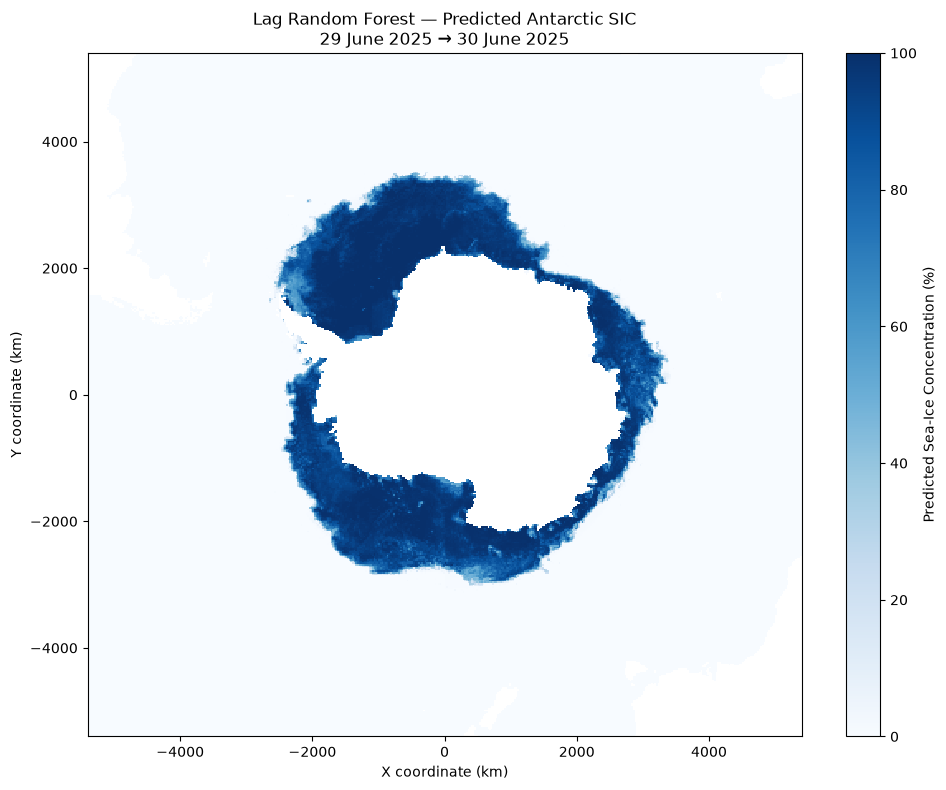

In [115]:
# ============================================
# PREDICTED 30-JUNE SIC MAP
# ============================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

mesh = ax.pcolormesh(
    xc_values,
    yc_values,
    pred_grid,
    shading="auto",
    cmap="Blues",
    vmin=0,
    vmax=100
)

plt.colorbar(
    mesh,
    ax=ax,
    label="Predicted Sea-Ice Concentration (%)"
)

ax.set_title(
    "Lag Random Forest — Predicted Antarctic SIC\n"
    "29 June 2025 → 30 June 2025"
)

ax.set_xlabel("X coordinate (km)")
ax.set_ylabel("Y coordinate (km)")

plt.tight_layout()
plt.show()

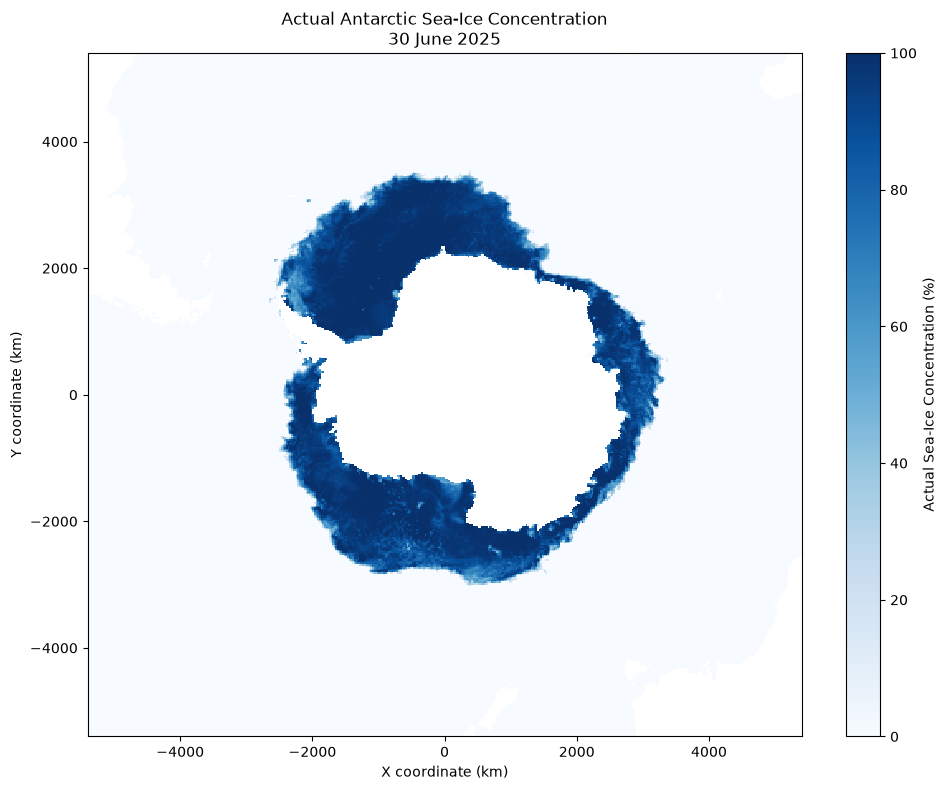

In [116]:
# ============================================
# ACTUAL 30-JUNE SIC MAP
# ============================================

fig, ax = plt.subplots(figsize=(10, 8))

mesh = ax.pcolormesh(
    xc_values,
    yc_values,
    actual_grid,
    shading="auto",
    cmap="Blues",
    vmin=0,
    vmax=100
)

plt.colorbar(
    mesh,
    ax=ax,
    label="Actual Sea-Ice Concentration (%)"
)

ax.set_title(
    "Actual Antarctic Sea-Ice Concentration\n"
    "30 June 2025"
)

ax.set_xlabel("X coordinate (km)")
ax.set_ylabel("Y coordinate (km)")

plt.tight_layout()
plt.show()

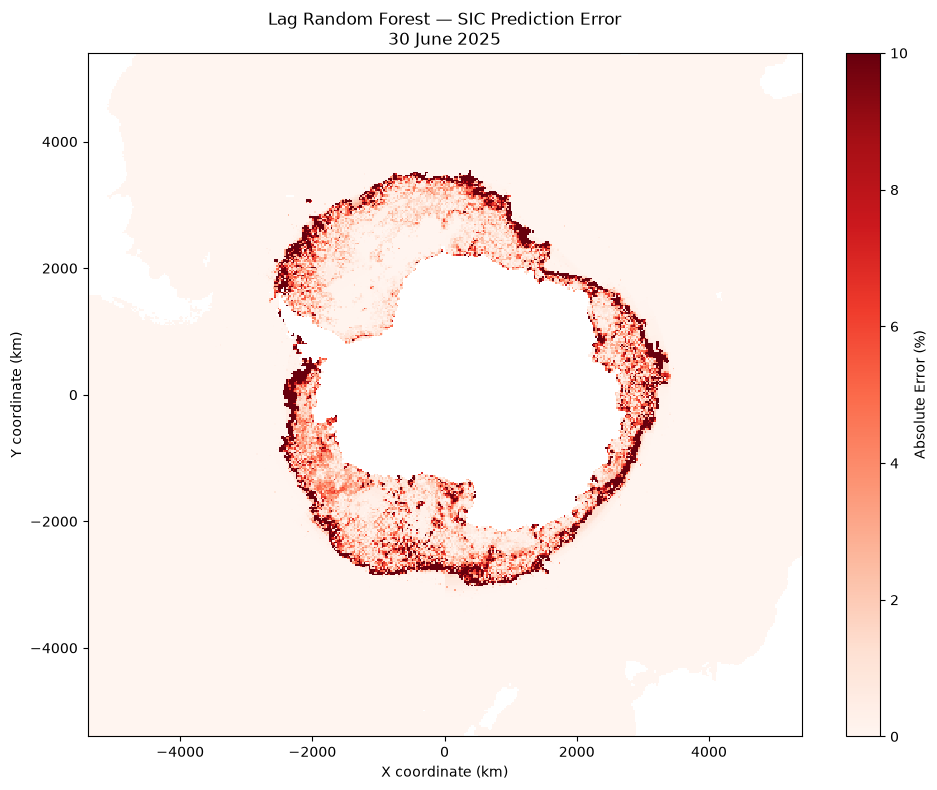

In [117]:
# ============================================
# 30-JUNE PREDICTION ERROR MAP
# ============================================

fig, ax = plt.subplots(figsize=(10, 8))

mesh = ax.pcolormesh(
    xc_values,
    yc_values,
    error_grid,
    shading="auto",
    cmap="Reds",
    vmin=0,
    vmax=10
)

plt.colorbar(
    mesh,
    ax=ax,
    label="Absolute Error (%)"
)

ax.set_title(
    "Lag Random Forest — SIC Prediction Error\n"
    "30 June 2025"
)

ax.set_xlabel("X coordinate (km)")
ax.set_ylabel("Y coordinate (km)")

plt.tight_layout()
plt.show()

In [118]:
import joblib
import os

model_path = "../models/module1_30day_lag_random_forest.joblib"

os.makedirs("../models", exist_ok=True)

joblib.dump(lag_rf_model, model_path)

print("Model saved successfully:")
print(model_path)

Model saved successfully:
../models/module1_30day_lag_random_forest.joblib


In [119]:
print("Features used by the model:")
print(lag_rf_model.feature_names_in_)

print("\nModel parameters:")
print(lag_rf_model.get_params())

Features used by the model:
['lat' 'lon' 'sea_ice_concentration' 'sic_lag1' 'sic_lag2']

Model parameters:
{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 15, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [120]:
import cdsapi

client = cdsapi.Client()

print("CDS API connection successful.")

CDS API connection successful.


In [121]:
from pathlib import Path

sst_dir = Path("../data/raw/d0")

sst_files = sorted(sst_dir.glob("*.nc"))

print("Existing SST NetCDF files:", len(sst_files))

for f in sst_files:
    print(f.name)

Existing SST NetCDF files: 5
20250601120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20250602120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20250603120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20250604120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20250605120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc


In [122]:
import xarray as xr
from pathlib import Path

sst_dir = Path("../data/raw/d0")
first_sst = sorted(sst_dir.glob("*.nc"))[0]

ds_test = xr.open_dataset(first_sst)

print(ds_test)
print("\nVariables:")
print(list(ds_test.data_vars))

print("\nDimensions:")
print(ds_test.dims)

<xarray.Dataset> Size: 726MB
Dimensions:                (time: 1, lat: 3600, lon: 7200)
Coordinates:
  * time                   (time) datetime64[ns] 8B 2025-06-01T12:00:00
  * lat                    (lat) float32 14kB -89.97 -89.92 ... 89.93 89.98
  * lon                    (lon) float32 29kB -180.0 -179.9 ... 179.9 180.0
Data variables:
    analysed_st            (time, lat, lon) float32 104MB ...
    analysis_error_st      (time, lat, lon) float32 104MB ...
    mask                   (time, lat, lon) float32 104MB ...
    sea_ice_fraction       (time, lat, lon) float32 104MB ...
    analysed_sst           (time, lat, lon) float32 104MB ...
    sea_ice_fraction_flag  (time, lat, lon) float32 104MB ...
    analysis_error_sst     (time, lat, lon) float32 104MB ...
Attributes: (12/48)
    Conventions:                CF-1.4, Unidata Observation Dataset v1.0
    title:                      Global Sea and Ice Surface Temperature, L4, 5...
    summary:                    DMI Sea and Ice Sur

In [125]:
# import cdsapi
# import os

# client = cdsapi.Client()

# sst_dir = "../data/raw/sst_30days"
# os.makedirs(sst_dir, exist_ok=True)

# request = {
#     "variable": "all",
#     "temporal_resolution": ["daily"],
#     "climate_data_record_type": ["icdr"],
#     "year": ["2025"],
#     "month": ["06"],
#     "day": ["06", "07", "08", "09", "10"],
#     "version": "1_0"
# }

# output_file = os.path.join(
#     sst_dir,
#     "sst_2025-06-06_to_2025-06-10.nc"
# )

# client.retrieve(
#     "satellite-ist-sst-global",
#     request,
#     output_file
# )

# print("Download completed:")
# print(output_file)
# print("Size:", round(os.path.getsize(output_file) / (1024**2), 2), "MB")

2026-09-03 16:14:31,157 INFO Request ID is 5e0b6d2a-9f79-4a81-8f87-12c153a2307b
2026-09-03 16:14:31,516 INFO status has been updated to accepted
2026-09-03 16:14:50,950 INFO status has been updated to successful
Recovering from connection error [('Connection broken: IncompleteRead(62228160 bytes read, 167978976 more expected)', IncompleteRead(62228160 bytes read, 167978976 more expected))], attempt 1 of 500
Retrying in 120 seconds
                                                                                         

Download completed:
../data/raw/sst_30days\sst_2025-06-06_to_2025-06-10.nc
Size: 219.54 MB


In [128]:
from pathlib import Path
import zipfile

sst_archive = Path("../data/raw/sst_30days/sst_2025-06-06_to_2025-06-10.nc")
extract_dir = Path("../data/raw/sst_30days/extracted_06_10")

extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(sst_archive, "r") as z:
    members = z.namelist()

    print("Files inside archive:")
    for name in members:
        print(" -", name)

    z.extractall(extract_dir)

print("\nExtraction completed.")
print("Extracted to:", extract_dir)

Files inside archive:
 - 20250606120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
 - 20250607120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
 - 20250608120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
 - 20250609120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
 - 20250610120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc

Extraction completed.
Extracted to: ..\data\raw\sst_30days\extracted_06_10


In [129]:
extracted_files = sorted(extract_dir.rglob("*.nc"))

print("Number of NetCDF files:", len(extracted_files))

for f in extracted_files:
    print(f.name)

Number of NetCDF files: 5
20250606120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20250607120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20250608120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20250609120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20250610120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc


In [130]:
import xarray as xr
from pathlib import Path

old_file = sorted(Path("../data/raw/d0").glob("*.nc"))[0]

new_file = sorted(
    Path("../data/raw/sst_30days/extracted_06_10").glob("*.nc")
)[0]

old_ds = xr.open_dataset(old_file)
new_ds = xr.open_dataset(new_file)

print("OLD SST:", old_file.name)
print("NEW SST:", new_file.name)

print("\nDimensions:")
print("Old:", dict(old_ds.sizes))
print("New:", dict(new_ds.sizes))

print("\nVariables identical:", list(old_ds.data_vars) == list(new_ds.data_vars))

print("\nLatitude identical:",
      old_ds["lat"].equals(new_ds["lat"]))

print("Longitude identical:",
      old_ds["lon"].equals(new_ds["lon"]))

print("\nOld time:", old_ds.time.values)
print("New time:", new_ds.time.values)

OLD SST: 20250601120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
NEW SST: 20250606120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc

Dimensions:
Old: {'time': 1, 'lat': 3600, 'lon': 7200}
New: {'time': 1, 'lat': 3600, 'lon': 7200}

Variables identical: True

Latitude identical: True
Longitude identical: True

Old time: ['2025-06-01T12:00:00.000000000']
New time: ['2025-06-06T12:00:00.000000000']


In [131]:
# import cdsapi
# import os

# client = cdsapi.Client()

# sst_dir = "../data/raw/sst_30days"
# os.makedirs(sst_dir, exist_ok=True)

# request = {
#     "variable": "all",
#     "temporal_resolution": ["daily"],
#     "climate_data_record_type": ["icdr"],
#     "year": ["2025"],
#     "month": ["06"],
#     "day": ["11", "12", "13", "14", "15"],
#     "version": "1_0"
# }

# output_file = os.path.join(
#     sst_dir,
#     "sst_2025-06-11_to_2025-06-15.nc"
# )

# client.retrieve(
#     "satellite-ist-sst-global",
#     request,
#     output_file
# )

# print("Download completed:")
# print(output_file)
# print(
#     "Size:",
#     round(os.path.getsize(output_file) / (1024**2), 2),
#     "MB"
# )

2026-09-03 16:26:18,466 INFO Request ID is a53ddb9a-9720-4aca-ab0b-d062cade9a02
2026-09-03 16:26:18,942 INFO status has been updated to accepted
2026-09-03 16:26:33,995 INFO status has been updated to running
2026-09-03 16:26:54,940 INFO status has been updated to successful
                                                                                         

Download completed:
../data/raw/sst_30days\sst_2025-06-11_to_2025-06-15.nc
Size: 218.21 MB


In [132]:
# import cdsapi
# import os

# client = cdsapi.Client()

# sst_dir = "../data/raw/sst_30days"
# os.makedirs(sst_dir, exist_ok=True)

# request = {
#     "variable": "all",
#     "temporal_resolution": ["daily"],
#     "climate_data_record_type": ["icdr"],
#     "year": ["2025"],
#     "month": ["06"],
#     "day": ["16", "17", "18", "19", "20"],
#     "version": "1_0"
# }

# output_file = os.path.join(
#     sst_dir,
#     "sst_2025-06-16_to_2025-06-20.nc"
# )

# client.retrieve(
#     "satellite-ist-sst-global",
#     request,
#     output_file
# )

# print("Download completed:")
# print(output_file)
# print(
#     "Size:",
#     round(os.path.getsize(output_file) / (1024**2), 2),
#     "MB"
# )

2026-09-03 16:29:51,170 INFO Request ID is 7770eb04-da1b-4797-ad82-b7fc618874ea
2026-09-03 16:29:51,465 INFO status has been updated to accepted
2026-09-03 16:30:06,781 INFO status has been updated to running
2026-09-03 16:30:26,463 INFO status has been updated to successful
                                                                                         

Download completed:
../data/raw/sst_30days\sst_2025-06-16_to_2025-06-20.nc
Size: 218.54 MB


In [133]:
# import cdsapi
# import os

# client = cdsapi.Client()

# sst_dir = "../data/raw/sst_30days"
# os.makedirs(sst_dir, exist_ok=True)

# request = {
#     "variable": "all",
#     "temporal_resolution": ["daily"],
#     "climate_data_record_type": ["icdr"],
#     "year": ["2025"],
#     "month": ["06"],
#     "day": ["21", "22", "23", "24", "25"],
#     "version": "1_0"
# }

# output_file = os.path.join(
#     sst_dir,
#     "sst_2025-06-21_to_2025-06-25.nc"
# )

# client.retrieve(
#     "satellite-ist-sst-global",
#     request,
#     output_file
# )

# print("Download completed:")
# print(output_file)
# print(
#     "Size:",
#     round(os.path.getsize(output_file) / (1024**2), 2),
#     "MB"
# )

2026-09-03 16:32:18,512 INFO Request ID is 2e7815fe-60b0-49fe-9398-15c8366d176d
2026-09-03 16:32:18,785 INFO status has been updated to accepted
2026-09-03 16:32:34,298 INFO status has been updated to running
2026-09-03 16:33:11,478 INFO status has been updated to successful
                                                                                        

Download completed:
../data/raw/sst_30days\sst_2025-06-21_to_2025-06-25.nc
Size: 219.06 MB


In [134]:
# import cdsapi
# import os

# client = cdsapi.Client()

# sst_dir = "../data/raw/sst_30days"
# os.makedirs(sst_dir, exist_ok=True)

# request = {
#     "variable": "all",
#     "temporal_resolution": ["daily"],
#     "climate_data_record_type": ["icdr"],
#     "year": ["2025"],
#     "month": ["06"],
#     "day": ["26", "27", "28", "29", "30"],
#     "version": "1_0"
# }

# output_file = os.path.join(
#     sst_dir,
#     "sst_2025-06-26_to_2025-06-30.nc"
# )

# client.retrieve(
#     "satellite-ist-sst-global",
#     request,
#     output_file
# )

# print("Download completed:")
# print(output_file)
# print(
#     "Size:",
#     round(os.path.getsize(output_file) / (1024**2), 2),
#     "MB"
# )

2026-09-03 16:35:13,762 INFO Request ID is 3e6073df-8143-48db-b766-a8c69edc2532
2026-09-03 16:35:15,734 INFO status has been updated to accepted
2026-09-03 16:35:30,776 INFO status has been updated to running
2026-09-03 16:35:50,454 INFO status has been updated to successful
Recovering from connection error [('Connection broken: IncompleteRead(117128640 bytes read, 112965022 more expected)', IncompleteRead(117128640 bytes read, 112965022 more expected))], attempt 1 of 500
Retrying in 120 seconds
                                                                                        

Download completed:
../data/raw/sst_30days\sst_2025-06-26_to_2025-06-30.nc
Size: 219.43 MB


In [135]:
from pathlib import Path
import zipfile

sst_base = Path("../data/raw/sst_30days")

batches = [
    ("sst_2025-06-11_to_2025-06-15.nc", "extracted_11_15"),
    ("sst_2025-06-16_to_2025-06-20.nc", "extracted_16_20"),
    ("sst_2025-06-21_to_2025-06-25.nc", "extracted_21_25"),
    ("sst_2025-06-26_to_2025-06-30.nc", "extracted_26_30"),
]

for archive_name, folder_name in batches:
    archive = sst_base / archive_name
    extract_dir = sst_base / folder_name
    extract_dir.mkdir(parents=True, exist_ok=True)

    print(f"\nProcessing: {archive_name}")

    with zipfile.ZipFile(archive, "r") as z:
        z.extractall(extract_dir)

    files = sorted(extract_dir.glob("*.nc"))
    print(f"Extracted NetCDF files: {len(files)}")

print("\nAll remaining SST batches extracted.")


Processing: sst_2025-06-11_to_2025-06-15.nc
Extracted NetCDF files: 5

Processing: sst_2025-06-16_to_2025-06-20.nc
Extracted NetCDF files: 5

Processing: sst_2025-06-21_to_2025-06-25.nc
Extracted NetCDF files: 5

Processing: sst_2025-06-26_to_2025-06-30.nc
Extracted NetCDF files: 5

All remaining SST batches extracted.


In [136]:
from pathlib import Path

all_sst_files = []

# June 1–5
all_sst_files.extend(sorted(Path("../data/raw/d0").glob("*.nc")))

# June 6–30
for folder in [
    "extracted_06_10",
    "extracted_11_15",
    "extracted_16_20",
    "extracted_21_25",
    "extracted_26_30",
]:
    all_sst_files.extend(
        sorted(Path("../data/raw/sst_30days", folder).glob("*.nc"))
    )

print("Total SST daily files:", len(all_sst_files))

print("\nFirst:", all_sst_files[0].name)
print("Last :", all_sst_files[-1].name)

Total SST daily files: 30

First: 20250601120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
Last : 20250630120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc


In [137]:
from pathlib import Path
import pandas as pd

sst_files = []

# June 1–5
sst_files.extend(
    sorted(Path("../data/raw/d0").glob("*.nc"))
)

# June 6–30
for folder in [
    "extracted_06_10",
    "extracted_11_15",
    "extracted_16_20",
    "extracted_21_25",
    "extracted_26_30",
]:
    sst_files.extend(
        sorted(
            Path("../data/raw/sst_30days", folder).glob("*.nc")
        )
    )

sst_files = sorted(sst_files)

print("Total SST files:", len(sst_files))
print("\nDates:")

for f in sst_files:
    ds_tmp = __import__("xarray").open_dataset(f)
    date = pd.Timestamp(ds_tmp.time.values[0])
    ds_tmp.close()
    print(date.date())

Total SST files: 30

Dates:
2025-06-01
2025-06-02
2025-06-03
2025-06-04
2025-06-05
2025-06-06
2025-06-07
2025-06-08
2025-06-09
2025-06-10
2025-06-11
2025-06-12
2025-06-13
2025-06-14
2025-06-15
2025-06-16
2025-06-17
2025-06-18
2025-06-19
2025-06-20
2025-06-21
2025-06-22
2025-06-23
2025-06-24
2025-06-25
2025-06-26
2025-06-27
2025-06-28
2025-06-29
2025-06-30


In [138]:
import xarray as xr
import numpy as np

# Existing June 1 SST file
sst_ds = xr.open_dataset(sst_files[0])

# Existing SIC grid
sic_lat = sic_30_ds["lat"]
sic_lon = sic_30_ds["lon"]

# Convert SST from Kelvin to Celsius
sst_celsius = sst_ds["analysed_sst"] - 273.15

print("SST grid:", sst_celsius.shape)
print("SIC grid:", sic_lat.shape)

# Sample SST onto the SIC grid
sst_on_sic_grid = sst_celsius.sel(
    lat=sic_lat,
    lon=sic_lon,
    method="nearest"
)

print("\nAligned SST shape:", sst_on_sic_grid.shape)

print(
    "SST range on SIC grid:",
    float(sst_on_sic_grid.min()),
    "to",
    float(sst_on_sic_grid.max()),
    "°C"
)

SST grid: (1, 3600, 7200)
SIC grid: (432, 432)

Aligned SST shape: (1, 432, 432)
SST range on SIC grid: -1.910003662109375 to 27.94000244140625 °C


In [139]:
import xarray as xr
import numpy as np
from pathlib import Path

# Use the existing 30-day SIC dataset as the master grid
sic_lat = sic_30_ds["lat"]
sic_lon = sic_30_ds["lon"]

sst_daily = []

print("Processing 30 SST files...")

for i, file in enumerate(sst_files, start=1):

    ds = xr.open_dataset(file)

    # SST in Kelvin -> Celsius
    sst = ds["analysed_sst"] - 273.15

    # Sample global SST onto the 432x432 SIC grid
    sst_aligned = sst.sel(
        lat=sic_lat,
        lon=sic_lon,
        method="nearest"
    )

    # Remove the single time dimension
    sst_aligned = sst_aligned.squeeze("time")

    # Store only the resulting 432x432 array
    sst_daily.append(sst_aligned.values.astype("float32"))

    print(f"{i:02d}/30 processed: {Path(file).name[:8]}")

    ds.close()

# Stack into (time, yc, xc)
sst_array = np.stack(sst_daily, axis=0)

print("\nCompleted.")
print("SST array shape:", sst_array.shape)
print("Memory used by SST array:",
      round(sst_array.nbytes / (1024**2), 2), "MB")

Processing 30 SST files...
01/30 processed: 20250601
02/30 processed: 20250602
03/30 processed: 20250603
04/30 processed: 20250604
05/30 processed: 20250605
06/30 processed: 20250606
07/30 processed: 20250607
08/30 processed: 20250608
09/30 processed: 20250609
10/30 processed: 20250610
11/30 processed: 20250611
12/30 processed: 20250612
13/30 processed: 20250613
14/30 processed: 20250614
15/30 processed: 20250615
16/30 processed: 20250616
17/30 processed: 20250617
18/30 processed: 20250618
19/30 processed: 20250619
20/30 processed: 20250620
21/30 processed: 20250621
22/30 processed: 20250622
23/30 processed: 20250623
24/30 processed: 20250624
25/30 processed: 20250625
26/30 processed: 20250626
27/30 processed: 20250627
28/30 processed: 20250628
29/30 processed: 20250629
30/30 processed: 20250630

Completed.
SST array shape: (30, 432, 432)
Memory used by SST array: 21.36 MB


In [140]:
import numpy as np
import pandas as pd
import xarray as xr

sst_times = pd.to_datetime(sic_30_ds["time"].values)

print("Number of SST days:", len(sst_times))
print("First SST date:", sst_times[0])
print("Last SST date:", sst_times[-1])

print("\nSST array shape:", sst_array.shape)

print("\nSIC dates:")
print(pd.to_datetime(sic_30_ds["time"].values))

# Basic sanity check
assert sst_array.shape[0] == len(sst_times)
assert sst_array.shape[1:] == (432, 432)

print("\n✓ SST and SIC dimensions are compatible.")

Number of SST days: 30
First SST date: 2025-06-01 12:00:00
Last SST date: 2025-06-30 12:00:00

SST array shape: (30, 432, 432)

SIC dates:
DatetimeIndex(['2025-06-01 12:00:00', '2025-06-02 12:00:00',
               '2025-06-03 12:00:00', '2025-06-04 12:00:00',
               '2025-06-05 12:00:00', '2025-06-06 12:00:00',
               '2025-06-07 12:00:00', '2025-06-08 12:00:00',
               '2025-06-09 12:00:00', '2025-06-10 12:00:00',
               '2025-06-11 12:00:00', '2025-06-12 12:00:00',
               '2025-06-13 12:00:00', '2025-06-14 12:00:00',
               '2025-06-15 12:00:00', '2025-06-16 12:00:00',
               '2025-06-17 12:00:00', '2025-06-18 12:00:00',
               '2025-06-19 12:00:00', '2025-06-20 12:00:00',
               '2025-06-21 12:00:00', '2025-06-22 12:00:00',
               '2025-06-23 12:00:00', '2025-06-24 12:00:00',
               '2025-06-25 12:00:00', '2025-06-26 12:00:00',
               '2025-06-27 12:00:00', '2025-06-28 12:00:00',
       

In [141]:
import xarray as xr
import numpy as np

# Build dataset using the existing SIC grid
module1_30_data = xr.Dataset(
    coords={
        "time": sic_30_ds["time"],
        "yc": sic_30_ds["yc"],
        "xc": sic_30_ds["xc"],
        "lat": sic_30_ds["lat"],
        "lon": sic_30_ds["lon"],
    }
)

# Add SIC
module1_30_data["sea_ice_concentration"] = (
    ("time", "yc", "xc"),
    sic_30_ds["ice_conc"].values.astype("float32")
)

# Add SST sampled onto SIC grid
module1_30_data["sst_celsius"] = (
    ("time", "yc", "xc"),
    sst_array
)

# Keep only Antarctic/Southern Ocean region
module1_30_data = module1_30_data.where(
    module1_30_data["lat"] <= -55
)

print(module1_30_data)

print("\nVariables:")
print(list(module1_30_data.data_vars))

<xarray.Dataset> Size: 46MB
Dimensions:                (time: 30, yc: 432, xc: 432)
Coordinates:
  * time                   (time) datetime64[ns] 240B 2025-06-01T12:00:00 ......
  * yc                     (yc) float64 3kB 5.388e+03 5.362e+03 ... -5.388e+03
  * xc                     (xc) float64 3kB -5.388e+03 -5.362e+03 ... 5.388e+03
    lat                    (yc, xc) float32 746kB dask.array<chunksize=(432, 432), meta=np.ndarray>
    lon                    (yc, xc) float32 746kB dask.array<chunksize=(432, 432), meta=np.ndarray>
Data variables:
    sea_ice_concentration  (time, yc, xc) float32 22MB dask.array<chunksize=(30, 432, 432), meta=np.ndarray>
    sst_celsius            (time, yc, xc) float32 22MB dask.array<chunksize=(30, 432, 432), meta=np.ndarray>

Variables:
['sea_ice_concentration', 'sst_celsius']


In [142]:
# Work on the compact Module 1 dataset
ml_ds = module1_30_data.copy()

# SIC history
ml_ds["sic_lag1"] = (
    ml_ds["sea_ice_concentration"]
    .shift(time=1)
)

ml_ds["sic_lag2"] = (
    ml_ds["sea_ice_concentration"]
    .shift(time=2)
)

# Next-day target
ml_ds["target_sic"] = (
    ml_ds["sea_ice_concentration"]
    .shift(time=-1)
)

print(ml_ds)
print("\nVariables:")
print(list(ml_ds.data_vars))

<xarray.Dataset> Size: 113MB
Dimensions:                (time: 30, yc: 432, xc: 432)
Coordinates:
  * time                   (time) datetime64[ns] 240B 2025-06-01T12:00:00 ......
  * yc                     (yc) float64 3kB 5.388e+03 5.362e+03 ... -5.388e+03
  * xc                     (xc) float64 3kB -5.388e+03 -5.362e+03 ... 5.388e+03
    lat                    (yc, xc) float32 746kB dask.array<chunksize=(432, 432), meta=np.ndarray>
    lon                    (yc, xc) float32 746kB dask.array<chunksize=(432, 432), meta=np.ndarray>
Data variables:
    sea_ice_concentration  (time, yc, xc) float32 22MB dask.array<chunksize=(30, 432, 432), meta=np.ndarray>
    sst_celsius            (time, yc, xc) float32 22MB dask.array<chunksize=(30, 432, 432), meta=np.ndarray>
    sic_lag1               (time, yc, xc) float32 22MB dask.array<chunksize=(30, 432, 432), meta=np.ndarray>
    sic_lag2               (time, yc, xc) float32 22MB dask.array<chunksize=(30, 432, 432), meta=np.ndarray>
    target

In [143]:
import pandas as pd

# Convert the compact xarray dataset to a dataframe
ml_df = ml_ds.to_dataframe().reset_index()

print("Initial shape:", ml_df.shape)

# Keep only rows where every feature and the next-day target exists
feature_columns = [
    "lat",
    "lon",
    "sea_ice_concentration",
    "sic_lag1",
    "sic_lag2",
    "sst_celsius"
]

ml_df = ml_df.dropna(
    subset=feature_columns + ["target_sic"]
).copy()

print("After removing invalid rows:", ml_df.shape)

# Show the usable forecasting dates
print("\nDate range:")
print("First:", ml_df["time"].min())
print("Last :", ml_df["time"].max())

print("\nRows per date:")
print(
    ml_df.groupby("time").size().to_string()
)

Initial shape: (5598720, 10)
After removing invalid rows: (1395901, 10)

Date range:
First: 2025-06-03 12:00:00
Last : 2025-06-29 12:00:00

Rows per date:
time
2025-06-03 12:00:00    51701
2025-06-04 12:00:00    51703
2025-06-05 12:00:00    51706
2025-06-06 12:00:00    51703
2025-06-07 12:00:00    51703
2025-06-08 12:00:00    51697
2025-06-09 12:00:00    51702
2025-06-10 12:00:00    51698
2025-06-11 12:00:00    51694
2025-06-12 12:00:00    51702
2025-06-13 12:00:00    51702
2025-06-14 12:00:00    51705
2025-06-15 12:00:00    51703
2025-06-16 12:00:00    51703
2025-06-17 12:00:00    51697
2025-06-18 12:00:00    51693
2025-06-19 12:00:00    51694
2025-06-20 12:00:00    51692
2025-06-21 12:00:00    51696
2025-06-22 12:00:00    51703
2025-06-23 12:00:00    51702
2025-06-24 12:00:00    51702
2025-06-25 12:00:00    51702
2025-06-26 12:00:00    51701
2025-06-27 12:00:00    51701
2025-06-28 12:00:00    51700
2025-06-29 12:00:00    51696


In [144]:
print("SST statistics:")
print(ml_df["sst_celsius"].describe())

print("\nCurrent SIC statistics:")
print(ml_df["sea_ice_concentration"].describe())

print("\nTarget SIC statistics:")
print(ml_df["target_sic"].describe())

print("\nSST missing values:", ml_df["sst_celsius"].isna().sum())
print("SIC missing values:", ml_df["sea_ice_concentration"].isna().sum())
print("Target missing values:", ml_df["target_sic"].isna().sum())

SST statistics:
count    1.395901e+06
mean     7.996705e-02
std      2.250012e+00
min     -1.910004e+00
25%     -1.820007e+00
50%     -7.000122e-01
75%      1.250000e+00
max      8.920013e+00
Name: sst_celsius, dtype: float64

Current SIC statistics:
count    1.395901e+06
mean     3.329888e+01
std      4.404535e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      9.084000e+01
max      1.000000e+02
Name: sea_ice_concentration, dtype: float64

Target SIC statistics:
count    1.395901e+06
mean     3.360143e+01
std      4.413952e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      9.116000e+01
max      1.000000e+02
Name: target_sic, dtype: float64

SST missing values: 0
SIC missing values: 0
Target missing values: 0


In [145]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features for the SST-enhanced model
sst_features = [
    "lat",
    "lon",
    "sea_ice_concentration",
    "sic_lag1",
    "sic_lag2",
    "sst_celsius"
]

# Chronological split
train_cutoff = pd.Timestamp("2025-06-26 12:00:00")

train_df = ml_df[ml_df["time"] <= train_cutoff].copy()
test_df = ml_df[ml_df["time"] > train_cutoff].copy()

print("Training rows:", len(train_df))
print("Testing rows :", len(test_df))

print("\nTraining dates:",
      train_df["time"].min().date(),
      "to",
      train_df["time"].max().date())

print("Testing dates:",
      test_df["time"].min().date(),
      "to",
      test_df["time"].max().date())

# To keep laptop RAM manageable, sample the training data
train_sample = train_df.sample(
    n=min(400_000, len(train_df)),
    random_state=42
)

X_train_sst = train_sample[sst_features].astype("float32")
y_train_sst = train_sample["target_sic"].astype("float32")

X_test_sst = test_df[sst_features].astype("float32")
y_test_sst = test_df["target_sic"].astype("float32")

print("\nTraining sample:", X_train_sst.shape)
print("Test set:", X_test_sst.shape)

# Train model
sst_rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("\nTraining SST-enhanced Random Forest...")

sst_rf_model.fit(X_train_sst, y_train_sst)

print("Training complete.")

# Predictions
y_pred_sst = sst_rf_model.predict(X_test_sst)

# Keep predictions within physical SIC bounds
y_pred_sst = np.clip(y_pred_sst, 0, 100)

# Evaluation
sst_mae = mean_absolute_error(y_test_sst, y_pred_sst)
sst_rmse = np.sqrt(mean_squared_error(y_test_sst, y_pred_sst))
sst_r2 = r2_score(y_test_sst, y_pred_sst)

print("\nSST-enhanced model results:")
print(f"MAE  : {sst_mae:.4f}%")
print(f"RMSE : {sst_rmse:.4f}%")
print(f"R²   : {sst_r2:.4f}")

Training rows: 1240804
Testing rows : 155097

Training dates: 2025-06-03 to 2025-06-26
Testing dates: 2025-06-27 to 2025-06-29

Training sample: (400000, 6)
Test set: (155097, 6)

Training SST-enhanced Random Forest...
Training complete.

SST-enhanced model results:
MAE  : 1.9382%
RMSE : 5.3581%
R²   : 0.9859


In [146]:
# Fair comparison: same train/test rows and same model settings

comparison_features = [
    "lat",
    "lon",
    "sea_ice_concentration",
    "sic_lag1",
    "sic_lag2"
]

sst_features = comparison_features + ["sst_celsius"]

# Same chronological split used for SST model
train_cutoff = pd.Timestamp("2025-06-26 12:00:00")

train_df_cmp = ml_df[ml_df["time"] <= train_cutoff].copy()
test_df_cmp = ml_df[ml_df["time"] > train_cutoff].copy()

# IMPORTANT:
# Create ONE fixed random sample so both models see exactly
# the same training observations.
train_sample_cmp = train_df_cmp.sample(
    n=min(400_000, len(train_df_cmp)),
    random_state=42
)

X_train_base_cmp = train_sample_cmp[comparison_features].astype("float32")
X_train_sst_cmp = train_sample_cmp[sst_features].astype("float32")

y_train_cmp = train_sample_cmp["target_sic"].astype("float32")

X_test_base_cmp = test_df_cmp[comparison_features].astype("float32")
X_test_sst_cmp = test_df_cmp[sst_features].astype("float32")

y_test_cmp = test_df_cmp["target_sic"].astype("float32")

print("Training rows:", len(train_sample_cmp))
print("Testing rows :", len(test_df_cmp))

print("\nTest dates:")
print(
    test_df_cmp.groupby("time").size().to_string()
)

# ---------------------------
# SIC-only model
# ---------------------------
base_cmp_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("\nTraining SIC-only comparison model...")
base_cmp_model.fit(X_train_base_cmp, y_train_cmp)

base_pred_cmp = np.clip(
    base_cmp_model.predict(X_test_base_cmp),
    0,
    100
)

base_mae_cmp = mean_absolute_error(y_test_cmp, base_pred_cmp)
base_rmse_cmp = np.sqrt(
    mean_squared_error(y_test_cmp, base_pred_cmp)
)
base_r2_cmp = r2_score(y_test_cmp, base_pred_cmp)

# ---------------------------
# SST-enhanced model
# ---------------------------
sst_cmp_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("\nTraining SST-enhanced comparison model...")
sst_cmp_model.fit(X_train_sst_cmp, y_train_cmp)

sst_pred_cmp = np.clip(
    sst_cmp_model.predict(X_test_sst_cmp),
    0,
    100
)

sst_mae_cmp = mean_absolute_error(y_test_cmp, sst_pred_cmp)
sst_rmse_cmp = np.sqrt(
    mean_squared_error(y_test_cmp, sst_pred_cmp)
)
sst_r2_cmp = r2_score(y_test_cmp, sst_pred_cmp)

print("\n========== FAIR COMPARISON ==========")

print("\nSIC-only:")
print(f"MAE  : {base_mae_cmp:.4f}%")
print(f"RMSE : {base_rmse_cmp:.4f}%")
print(f"R²   : {base_r2_cmp:.4f}")

print("\nSST-enhanced:")
print(f"MAE  : {sst_mae_cmp:.4f}%")
print(f"RMSE : {sst_rmse_cmp:.4f}%")
print(f"R²   : {sst_r2_cmp:.4f}")

print("\nDifference (SST - SIC-only):")
print(f"MAE  : {sst_mae_cmp - base_mae_cmp:+.4f}%")
print(f"RMSE : {sst_rmse_cmp - base_rmse_cmp:+.4f}")
print(f"R²   : {sst_r2_cmp - base_r2_cmp:+.4f}")

Training rows: 400000
Testing rows : 155097

Test dates:
time
2025-06-27 12:00:00    51701
2025-06-28 12:00:00    51700
2025-06-29 12:00:00    51696

Training SIC-only comparison model...

Training SST-enhanced comparison model...

========== FAIR COMPARISON ==========

SIC-only:
MAE  : 1.8930%
RMSE : 5.4019%
R²   : 0.9857

SST-enhanced:
MAE  : 1.9382%
RMSE : 5.3581%
R²   : 0.9859

Difference (SST - SIC-only):
MAE  : +0.0452%
RMSE : -0.0438
R²   : +0.0002


In [147]:
import pandas as pd

feature_importance_sst = pd.DataFrame({
    "feature": sst_features,
    "importance": sst_cmp_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(feature_importance_sst.to_string(index=False))

              feature  importance
sea_ice_concentration    0.992422
                  lon    0.001842
                  lat    0.001681
          sst_celsius    0.001410
             sic_lag2    0.001342
             sic_lag1    0.001304


In [148]:
# Percentage change from SIC-only -> SST-enhanced

mae_change_pct = (
    (sst_mae_cmp - base_mae_cmp)
    / base_mae_cmp
) * 100

rmse_change_pct = (
    (sst_rmse_cmp - base_rmse_cmp)
    / base_rmse_cmp
) * 100

r2_change_pct = (
    (sst_r2_cmp - base_r2_cmp)
    / abs(base_r2_cmp)
) * 100

# Accuracy within practical SIC error thresholds
thresholds = [1, 2, 5]

print("========== SST IMPACT ==========")

print(f"MAE change : {mae_change_pct:+.2f}%")
print(f"RMSE change: {rmse_change_pct:+.2f}%")
print(f"R² change  : {r2_change_pct:+.4f}%")

print("\nAccuracy within error threshold:")

for threshold in thresholds:
    base_acc = np.mean(
        np.abs(y_test_cmp.values - base_pred_cmp) <= threshold
    ) * 100

    sst_acc = np.mean(
        np.abs(y_test_cmp.values - sst_pred_cmp) <= threshold
    ) * 100

    print(
        f"±{threshold}% SIC -> "
        f"SIC-only: {base_acc:.2f}% | "
        f"SST-enhanced: {sst_acc:.2f}%"
    )

========== SST IMPACT ==========
MAE change : +2.39%
RMSE change: -0.81%
R² change  : +0.0234%

Accuracy within error threshold:
±1% SIC -> SIC-only: 72.24% | SST-enhanced: 69.96%
±2% SIC -> SIC-only: 79.80% | SST-enhanced: 78.44%
±5% SIC -> SIC-only: 89.64% | SST-enhanced: 89.47%


In [149]:
import joblib
import os
import json

os.makedirs("../models", exist_ok=True)

# Save SST-enhanced model
sst_model_path = "../models/module1_30day_sst_random_forest.joblib"
joblib.dump(sst_cmp_model, sst_model_path)

# Save model metadata
sst_metadata = {
    "model": "RandomForestRegressor",
    "dataset_period": "2025-06-01 to 2025-06-30",
    "forecast_horizon": "next_day",
    "region": "latitude <= -55",
    "features": sst_features,
    "target": "target_sic",
    "n_estimators": 100,
    "max_depth": 15,
    "min_samples_leaf": 2,
    "random_state": 42,
    "training_sample_size": 400000,
    "train_period": "2025-06-03 to 2025-06-26",
    "test_period": "2025-06-27 to 2025-06-29",
    "results": {
        "MAE": float(sst_mae_cmp),
        "RMSE": float(sst_rmse_cmp),
        "R2": float(sst_r2_cmp)
    },
    "note": "SST-enhanced comparison model; SIC-only model remains primary MVP baseline."
}

metadata_path = "../models/module1_30day_sst_random_forest_metadata.json"

with open(metadata_path, "w") as f:
    json.dump(sst_metadata, f, indent=4)

print("SST model saved:")
print(sst_model_path)

print("\nMetadata saved:")
print(metadata_path)

SST model saved:
../models/module1_30day_sst_random_forest.joblib

Metadata saved:
../models/module1_30day_sst_random_forest_metadata.json


In [150]:
print("========== STANDARDIZED MODULE 1 BENCHMARK ==========")

print("\nSIC-only lag model")
print(f"MAE  : {base_mae_cmp:.4f}%")
print(f"RMSE : {base_rmse_cmp:.4f}%")
print(f"R²   : {base_r2_cmp:.4f}")

print("\nSIC + SST model")
print(f"MAE  : {sst_mae_cmp:.4f}%")
print(f"RMSE : {sst_rmse_cmp:.4f}%")
print(f"R²   : {sst_r2_cmp:.4f}")

print("\nRecommended MVP model: SIC-only lag model")

========== STANDARDIZED MODULE 1 BENCHMARK ==========

SIC-only lag model
MAE  : 1.8930%
RMSE : 5.4019%
R²   : 0.9857

SIC + SST model
MAE  : 1.9382%
RMSE : 5.3581%
R²   : 0.9859

Recommended MVP model: SIC-only lag model


In [151]:
import joblib
import json
import os

os.makedirs("../models", exist_ok=True)

# Primary Module 1 MVP model
mvp_model_path = "../models/module1_30day_mvp_random_forest.joblib"

joblib.dump(
    base_cmp_model,
    mvp_model_path
)

# Metadata
mvp_metadata = {
    "module": "Module 1 - Sea Ice Concentration Prediction",
    "model_type": "RandomForestRegressor",
    "dataset_period": "2025-06-01 to 2025-06-30",
    "forecast_horizon": "next_day",
    "region": "latitude <= -55",
    "features": comparison_features,
    "target": "target_sic",
    "parameters": {
        "n_estimators": 100,
        "max_depth": 15,
        "min_samples_leaf": 2,
        "random_state": 42,
        "n_jobs": -1
    },
    "training": {
        "period": "2025-06-03 to 2025-06-26",
        "sample_size": 400000
    },
    "evaluation": {
        "period": "2025-06-27 to 2025-06-29",
        "MAE_percent": float(base_mae_cmp),
        "RMSE_percent": float(base_rmse_cmp),
        "R2": float(base_r2_cmp)
    },
    "status": "primary MVP model",
    "note": "SST was evaluated separately and did not improve MAE on the standardized benchmark."
}

mvp_metadata_path = "../models/module1_30day_mvp_random_forest_metadata.json"

with open(mvp_metadata_path, "w") as f:
    json.dump(mvp_metadata, f, indent=4)

print("MVP model saved:")
print(mvp_model_path)

print("\nMVP metadata saved:")
print(mvp_metadata_path)

MVP model saved:
../models/module1_30day_mvp_random_forest.joblib

MVP metadata saved:
../models/module1_30day_mvp_random_forest_metadata.json


In [153]:
# Final Module 1 MVP prediction: June 29 -> June 30

import joblib
import numpy as np
import pandas as pd

# Load the saved primary MVP model
mvp_model = joblib.load(
    "../models/module1_30day_mvp_random_forest.joblib"
)

forecast_date = pd.Timestamp("2025-06-29 12:00:00")

day_df = ml_df[
    ml_df["time"] == forecast_date
].copy()

print("Forecast date:", forecast_date)
print("Rows:", len(day_df))

# Features used by the primary MVP
mvp_features = [
    "lat",
    "lon",
    "sea_ice_concentration",
    "sic_lag1",
    "sic_lag2"
]

day_df = day_df.dropna(
    subset=mvp_features + ["target_sic"]
).copy()

# Predict
X_day = day_df[mvp_features].astype("float32")

day_df["predicted_sic"] = np.clip(
    mvp_model.predict(X_day),
    0,
    100
)

day_df["absolute_error"] = (
    day_df["target_sic"] -
    day_df["predicted_sic"]
).abs()

print("\nPrediction complete.")

print(
    "Predicted SIC range:",
    f"{day_df['predicted_sic'].min():.2f} to "
    f"{day_df['predicted_sic'].max():.2f}%"
)

print(
    "Actual SIC range:",
    f"{day_df['target_sic'].min():.2f} to "
    f"{day_df['target_sic'].max():.2f}%"
)

print(
    "MAE:",
    f"{day_df['absolute_error'].mean():.4f}%"
)

Forecast date: 2025-06-29 12:00:00
Rows: 51696

Prediction complete.
Predicted SIC range: 0.00 to 99.95%
Actual SIC range: 0.00 to 100.00%
MAE: 1.8999%


Maps reconstructed:
Shape: (432, 432)
Predicted valid cells: 51696
Actual valid cells: 51696


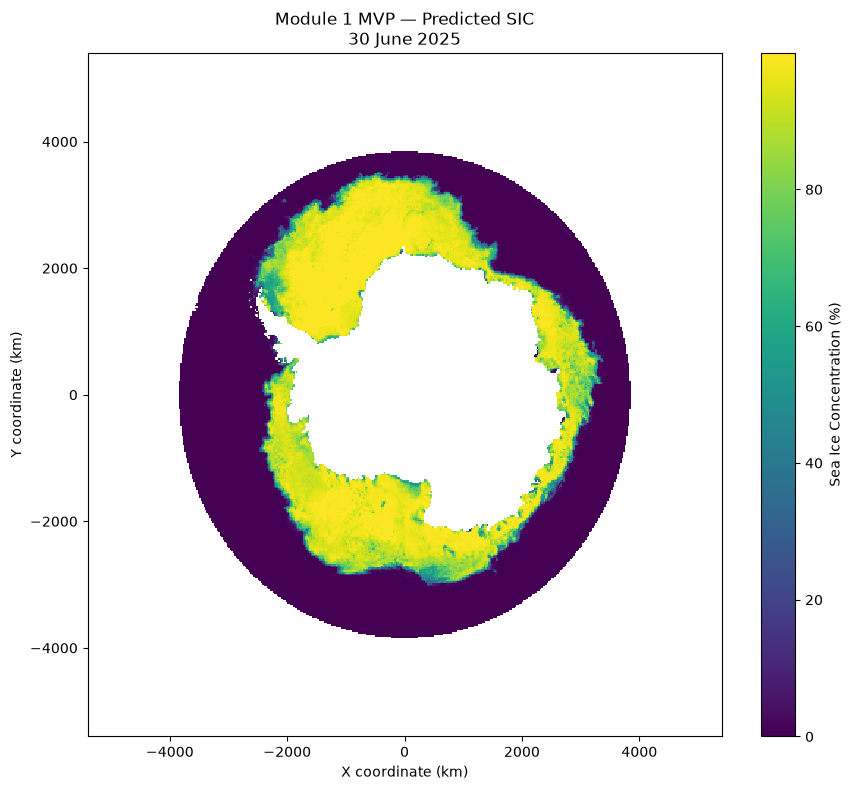

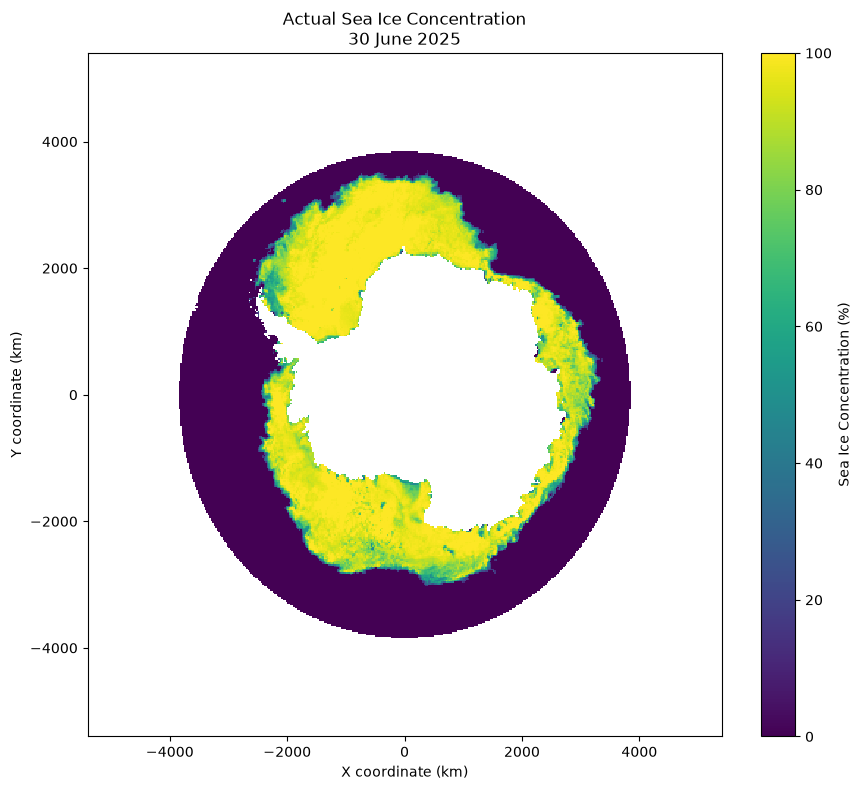

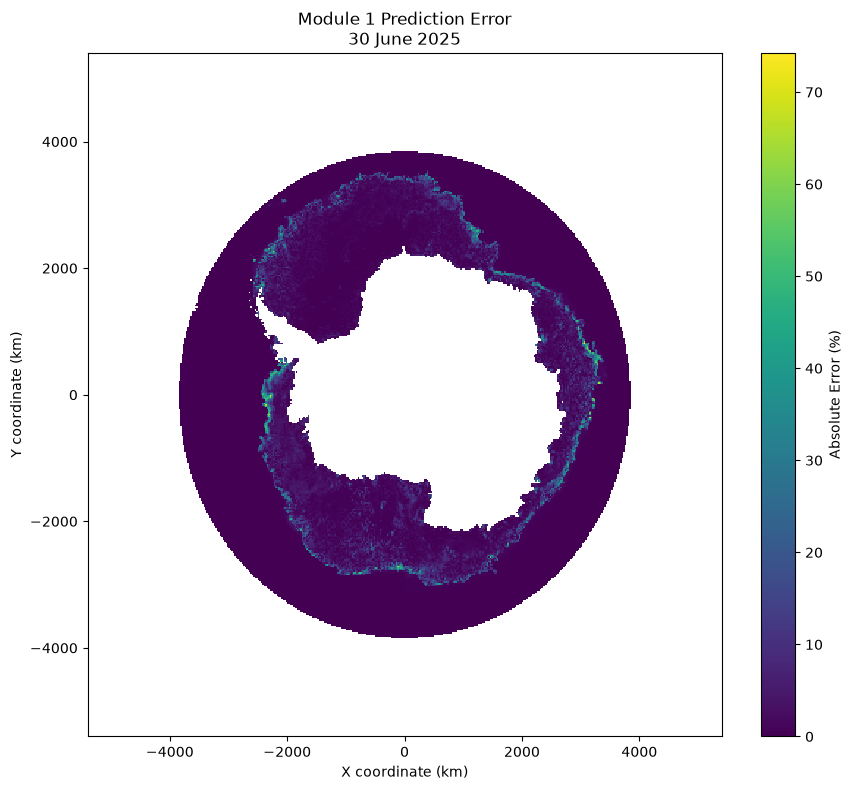

In [154]:
import numpy as np
import matplotlib.pyplot as plt

# Native SIC grid
yc_values = sic_30_ds["yc"].values
xc_values = sic_30_ds["xc"].values

# Create 432 x 432 arrays
predicted_map = np.full(
    (len(yc_values), len(xc_values)),
    np.nan,
    dtype="float32"
)

actual_map = np.full_like(predicted_map, np.nan)
error_map = np.full_like(predicted_map, np.nan)

# Map each prediction back to its native grid position
yc_index = {value: i for i, value in enumerate(yc_values)}
xc_index = {value: i for i, value in enumerate(xc_values)}

for row in day_df.itertuples(index=False):
    i = yc_index[row.yc]
    j = xc_index[row.xc]

    predicted_map[i, j] = row.predicted_sic
    actual_map[i, j] = row.target_sic
    error_map[i, j] = row.absolute_error

print("Maps reconstructed:")
print("Shape:", predicted_map.shape)
print("Predicted valid cells:", np.sum(~np.isnan(predicted_map)))
print("Actual valid cells:", np.sum(~np.isnan(actual_map)))

# -----------------------------
# 1. Predicted SIC
# -----------------------------
plt.figure(figsize=(9, 8))

plt.pcolormesh(
    xc_values,
    yc_values,
    predicted_map,
    shading="auto"
)

plt.colorbar(label="Sea Ice Concentration (%)")
plt.xlabel("X coordinate (km)")
plt.ylabel("Y coordinate (km)")
plt.title("Module 1 MVP — Predicted SIC\n30 June 2025")

plt.tight_layout()
plt.show()


# -----------------------------
# 2. Actual SIC
# -----------------------------
plt.figure(figsize=(9, 8))

plt.pcolormesh(
    xc_values,
    yc_values,
    actual_map,
    shading="auto"
)

plt.colorbar(label="Sea Ice Concentration (%)")
plt.xlabel("X coordinate (km)")
plt.ylabel("Y coordinate (km)")
plt.title("Actual Sea Ice Concentration\n30 June 2025")

plt.tight_layout()
plt.show()


# -----------------------------
# 3. Absolute error
# -----------------------------
plt.figure(figsize=(9, 8))

plt.pcolormesh(
    xc_values,
    yc_values,
    error_map,
    shading="auto"
)

plt.colorbar(label="Absolute Error (%)")
plt.xlabel("X coordinate (km)")
plt.ylabel("Y coordinate (km)")
plt.title("Module 1 Prediction Error\n30 June 2025")

plt.tight_layout()
plt.show()

In [155]:
import numpy as np
import json
import os

os.makedirs("../models/module1_outputs", exist_ok=True)

# Save compact 432x432 prediction outputs
np.savez_compressed(
    "../models/module1_outputs/module1_mvp_30june2025_prediction.npz",
    predicted_sic=predicted_map,
    actual_sic=actual_map,
    absolute_error=error_map,
    yc=yc_values,
    xc=xc_values
)

# Save evaluation metrics
final_metrics = {
    "forecast_input_date": "2025-06-29",
    "prediction_date": "2025-06-30",
    "model": "module1_30day_mvp_random_forest",
    "features": [
        "lat",
        "lon",
        "sea_ice_concentration",
        "sic_lag1",
        "sic_lag2"
    ],
    "predicted_sic_min": float(np.nanmin(predicted_map)),
    "predicted_sic_max": float(np.nanmax(predicted_map)),
    "actual_sic_min": float(np.nanmin(actual_map)),
    "actual_sic_max": float(np.nanmax(actual_map)),
    "MAE_percent": float(np.nanmean(error_map)),
    "valid_cells": int(np.sum(~np.isnan(predicted_map)))
}

metrics_path = (
    "../models/module1_outputs/"
    "module1_mvp_30june2025_metrics.json"
)

with open(metrics_path, "w") as f:
    json.dump(final_metrics, f, indent=4)

print("Prediction output saved:")
print("../models/module1_outputs/module1_mvp_30june2025_prediction.npz")

print("\nMetrics saved:")
print(metrics_path)

print("\nFinal MAE:", final_metrics["MAE_percent"], "%")

Prediction output saved:
../models/module1_outputs/module1_mvp_30june2025_prediction.npz

Metrics saved:
../models/module1_outputs/module1_mvp_30june2025_metrics.json

Final MAE: 1.8998826742172241 %


In [156]:
import joblib
import numpy as np
import pandas as pd

# Load model from disk
loaded_mvp = joblib.load(
    "../models/module1_30day_mvp_random_forest.joblib"
)

print("Model loaded successfully.")
print("Number of features:", loaded_mvp.n_features_in_)
print("Features:", list(loaded_mvp.feature_names_in_))

# Use the saved model for the same June 29 prediction
X_reload = day_df[mvp_features].astype("float32")

reload_prediction = np.clip(
    loaded_mvp.predict(X_reload),
    0,
    100
)

reload_mae = np.mean(
    np.abs(day_df["target_sic"].values - reload_prediction)
)

print("\nReloaded-model prediction complete.")
print(f"MAE: {reload_mae:.4f}%")

# Confirm predictions are identical to the previous run
same_predictions = np.allclose(
    day_df["predicted_sic"].values,
    reload_prediction
)

print("Predictions identical:", same_predictions)

Model loaded successfully.
Number of features: 5
Features: ['lat', 'lon', 'sea_ice_concentration', 'sic_lag1', 'sic_lag2']

Reloaded-model prediction complete.
MAE: 1.8999%
Predictions identical: True


In [157]:
from pathlib import Path

model_dir = Path("../models")

print("Files in models directory:\n")

for f in sorted(model_dir.rglob("*")):
    if f.is_file():
        print(f)

Files in models directory:

..\models\module1_30day_baseline_random_forest.joblib
..\models\module1_30day_lag_random_forest.joblib
..\models\module1_30day_mvp_random_forest.joblib
..\models\module1_30day_mvp_random_forest_metadata.json
..\models\module1_30day_sst_random_forest.joblib
..\models\module1_30day_sst_random_forest_metadata.json
..\models\module1_outputs\module1_mvp_30june2025_metrics.json
..\models\module1_outputs\module1_mvp_30june2025_prediction.npz
..\models\module1_random_forest_baseline.joblib


In [158]:
import joblib
import numpy as np
import pandas as pd

# Load the finalized MVP model
mvp_model = joblib.load(
    "../models/module1_30day_mvp_random_forest.joblib"
)

MVP_FEATURES = [
    "lat",
    "lon",
    "sea_ice_concentration",
    "sic_lag1",
    "sic_lag2"
]


def predict_next_day_sic(
    input_df: pd.DataFrame,
    model=mvp_model
) -> pd.DataFrame:
    """
    Predict next-day sea-ice concentration.

    Required columns:
        lat
        lon
        sea_ice_concentration
        sic_lag1
        sic_lag2

    Returns:
        Copy of input dataframe with predicted_sic column.
    """

    missing = [
        col for col in MVP_FEATURES
        if col not in input_df.columns
    ]

    if missing:
        raise ValueError(
            f"Missing required features: {missing}"
        )

    result = input_df.copy()

    X = result[MVP_FEATURES].astype("float32")

    predictions = model.predict(X)

    result["predicted_sic"] = np.clip(
        predictions,
        0,
        100
    )

    return result


# Test the inference function using the June 29 data
inference_test = predict_next_day_sic(day_df)

print("Inference function test successful.")
print("Input rows :", len(inference_test))
print("Output columns:")
print(list(inference_test.columns))

print("\nPredicted SIC range:")
print(
    f"{inference_test['predicted_sic'].min():.2f}% "
    f"to "
    f"{inference_test['predicted_sic'].max():.2f}%"
)

print("\nFirst 5 predictions:")
print(
    inference_test[
        MVP_FEATURES + ["predicted_sic"]
    ].head()
)

Inference function test successful.
Input rows : 51696
Output columns:
['time', 'yc', 'xc', 'sea_ice_concentration', 'sst_celsius', 'lat', 'lon', 'sic_lag1', 'sic_lag2', 'target_sic', 'predicted_sic', 'absolute_error']

Predicted SIC range:
0.00% to 99.95%

First 5 predictions:
               lat       lon  sea_ice_concentration  sic_lag1  sic_lag2  \
5252463 -55.009514 -3.169493                    0.0       0.0       0.0   
5252464 -55.021767 -2.797244                    0.0       0.0       0.0   
5252465 -55.032494 -2.424757                    0.0       0.0       0.0   
5252466 -55.041687 -2.052065                    0.0       0.0       0.0   
5252467 -55.049351 -1.679200                    0.0       0.0       0.0   

         predicted_sic  
5252463            0.0  
5252464            0.0  
5252465            0.0  
5252466            0.0  
5252467            0.0  


In [159]:
from pathlib import Path

# Create src directory
src_dir = Path("../src")
src_dir.mkdir(parents=True, exist_ok=True)

module_code = '''
import joblib
import numpy as np
import pandas as pd
from pathlib import Path


MODEL_PATH = (
    Path(__file__).resolve().parent.parent
    / "models"
    / "module1_30day_mvp_random_forest.joblib"
)

FEATURES = [
    "lat",
    "lon",
    "sea_ice_concentration",
    "sic_lag1",
    "sic_lag2",
]


def load_model():
    """Load the trained Module 1 MVP Random Forest."""
    return joblib.load(MODEL_PATH)


def predict_next_day_sic(
    input_df: pd.DataFrame,
    model=None
) -> pd.DataFrame:
    """
    Predict next-day sea-ice concentration.

    Required columns:
        lat
        lon
        sea_ice_concentration
        sic_lag1
        sic_lag2
    """

    missing = [
        column for column in FEATURES
        if column not in input_df.columns
    ]

    if missing:
        raise ValueError(
            f"Missing required features: {missing}"
        )

    if model is None:
        model = load_model()

    result = input_df.copy()

    if result[FEATURES].isna().any().any():
        raise ValueError(
            "Input contains missing values in required features."
        )

    X = result[FEATURES].astype("float32")

    predictions = model.predict(X)

    result["predicted_sic"] = np.clip(
        predictions,
        0,
        100
    )

    return result
'''

module_path = src_dir / "module1_predict.py"
module_path.write_text(module_code, encoding="utf-8")

print("Module 1 inference module created:")
print(module_path)

Module 1 inference module created:
..\src\module1_predict.py


In [160]:
import sys

if "../src" not in sys.path:
    sys.path.insert(0, "../src")

from module1_predict import predict_next_day_sic

deployment_test = predict_next_day_sic(day_df)

print("Deployment module test successful.")
print("Rows:", len(deployment_test))

print(
    "Predicted SIC range:",
    f"{deployment_test['predicted_sic'].min():.2f}% "
    f"to "
    f"{deployment_test['predicted_sic'].max():.2f}%"
)

Deployment module test successful.
Rows: 51696
Predicted SIC range: 0.00% to 99.95%


In [161]:
from pathlib import Path
import sys
import pandas as pd

# Make src importable
src_path = Path("../src").resolve()

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from module1_predict import load_model, predict_next_day_sic, FEATURES


# -----------------------------
# 1. Check model file
# -----------------------------
model_path = (
    Path("../models")
    / "module1_30day_mvp_random_forest.joblib"
)

assert model_path.exists(), (
    f"Model not found: {model_path}"
)

print("✓ Model file exists")


# -----------------------------
# 2. Load model
# -----------------------------
model = load_model()

print("✓ Model loaded")
print("Features:", list(model.feature_names_in_))


# -----------------------------
# 3. Check expected features
# -----------------------------
assert list(model.feature_names_in_) == FEATURES

print("✓ Feature configuration matches")


# -----------------------------
# 4. Run prediction
# -----------------------------
test_input = day_df[
    [
        "lat",
        "lon",
        "sea_ice_concentration",
        "sic_lag1",
        "sic_lag2"
    ]
].copy()

test_output = predict_next_day_sic(
    test_input,
    model=model
)

print("✓ Prediction generated")
print("Rows:", len(test_output))


# -----------------------------
# 5. Validate predictions
# -----------------------------
assert test_output["predicted_sic"].notna().all()

assert (
    test_output["predicted_sic"].between(0, 100).all()
)

print("✓ Predictions are valid")
print(
    f"Prediction range: "
    f"{test_output['predicted_sic'].min():.2f}% "
    f"to "
    f"{test_output['predicted_sic'].max():.2f}%"
)

print("\nMODULE 1 SELF-TEST PASSED ✅")

✓ Model file exists
✓ Model loaded
Features: ['lat', 'lon', 'sea_ice_concentration', 'sic_lag1', 'sic_lag2']
✓ Feature configuration matches
✓ Prediction generated
Rows: 51696
✓ Predictions are valid
Prediction range: 0.00% to 99.95%

MODULE 1 SELF-TEST PASSED ✅


In [162]:
from pathlib import Path
import json

summary_path = Path("../models/module1_summary.json")

module1_summary = {
    "module": "Module 1 - Sea Ice Concentration Prediction",
    "status": "MVP complete",

    "data": {
        "sic_period": "2025-06-01 to 2025-06-30",
        "sst_period": "2025-06-01 to 2025-06-30",
        "working_region": "latitude <= -55 degrees",
        "master_grid": "SIC native 432 x 432 Lambert Azimuthal grid",
        "forecast_horizon": "1 day"
    },

    "primary_model": {
        "type": "RandomForestRegressor",
        "file": "../models/module1_30day_mvp_random_forest.joblib",
        "features": [
            "lat",
            "lon",
            "sea_ice_concentration",
            "sic_lag1",
            "sic_lag2"
        ],
        "target": "next_day_sea_ice_concentration",
        "parameters": {
            "n_estimators": 100,
            "max_depth": 15,
            "min_samples_leaf": 2,
            "random_state": 42,
            "n_jobs": -1
        }
    },

    "training": {
        "period": "2025-06-03 to 2025-06-26",
        "sample_size": 400000
    },

    "standardized_evaluation": {
        "period": "2025-06-27 to 2025-06-29",
        "MAE_percent": 1.8930,
        "RMSE_percent": 5.4019,
        "R2": 0.9857
    },

    "final_example_prediction": {
        "input_date": "2025-06-29",
        "prediction_date": "2025-06-30",
        "MAE_percent": 1.8999
    },

    "sst_experiment": {
        "file": "../models/module1_30day_sst_random_forest.joblib",
        "features": [
            "lat",
            "lon",
            "sea_ice_concentration",
            "sic_lag1",
            "sic_lag2",
            "sst_celsius"
        ],
        "MAE_percent": 1.9382,
        "RMSE_percent": 5.3581,
        "R2": 0.9859,
        "conclusion": "SST did not improve MAE on the standardized June test period."
    },

    "inference": {
        "python_module": "../src/module1_predict.py",
        "self_test": "passed"
    },

    "outputs": {
        "prediction": "../models/module1_outputs/module1_mvp_30june2025_prediction.npz",
        "metrics": "../models/module1_outputs/module1_mvp_30june2025_metrics.json"
    }
}

with open(summary_path, "w") as f:
    json.dump(module1_summary, f, indent=4)

print("Module 1 summary created:")
print(summary_path)

print("\nStatus:", module1_summary["status"])
print("Primary model:", module1_summary["primary_model"]["file"])
print("Evaluation MAE:", module1_summary["standardized_evaluation"]["MAE_percent"], "%")

Module 1 summary created:
..\models\module1_summary.json

Status: MVP complete
Primary model: ../models/module1_30day_mvp_random_forest.joblib
Evaluation MAE: 1.893 %


In [163]:
import numpy as np
import pandas as pd

# Prototype, configurable SIC screening thresholds
SIC_THRESHOLDS = {
    "low_max": 15.0,
    "moderate_max": 40.0,
    "high_max": 70.0
}


def classify_sic_risk(sic_values):
    """
    Convert predicted SIC (%) into configurable risk classes.

    Codes:
        0 = LOW
        1 = MODERATE
        2 = HIGH
        3 = SEVERE
    """

    sic_values = np.asarray(sic_values)

    risk = np.full(
        sic_values.shape,
        -1,
        dtype=np.int8
    )

    valid = ~np.isnan(sic_values)

    risk[valid & (sic_values < SIC_THRESHOLDS["low_max"])] = 0

    risk[
        valid
        & (sic_values >= SIC_THRESHOLDS["low_max"])
        & (sic_values < SIC_THRESHOLDS["moderate_max"])
    ] = 1

    risk[
        valid
        & (sic_values >= SIC_THRESHOLDS["moderate_max"])
        & (sic_values < SIC_THRESHOLDS["high_max"])
    ] = 2

    risk[
        valid
        & (sic_values >= SIC_THRESHOLDS["high_max"])
        & (sic_values <= 100)
    ] = 3

    return risk


# Apply to the final June 30 prediction
day_df["risk_code"] = classify_sic_risk(
    day_df["predicted_sic"].values
)

risk_labels = {
    0: "LOW",
    1: "MODERATE",
    2: "HIGH",
    3: "SEVERE"
}

day_df["risk_class"] = (
    day_df["risk_code"]
    .map(risk_labels)
)

print("Risk classification complete.\n")

print(
    day_df["risk_class"]
    .value_counts()
    .reindex(
        ["LOW", "MODERATE", "HIGH", "SEVERE"],
        fill_value=0
    )
)

print("\nRisk percentages:")
print(
    (
        day_df["risk_class"]
        .value_counts(normalize=True)
        .reindex(
            ["LOW", "MODERATE", "HIGH", "SEVERE"],
            fill_value=0
        )
        * 100
    ).round(2)
)

Risk classification complete.

risk_class
LOW         30014
MODERATE      808
HIGH         1738
SEVERE      19136
Name: count, dtype: int64

Risk percentages:
risk_class
LOW         58.06
MODERATE     1.56
HIGH         3.36
SEVERE      37.02
Name: proportion, dtype: float64


Risk map shape: (432, 432)
Valid risk cells: 51696


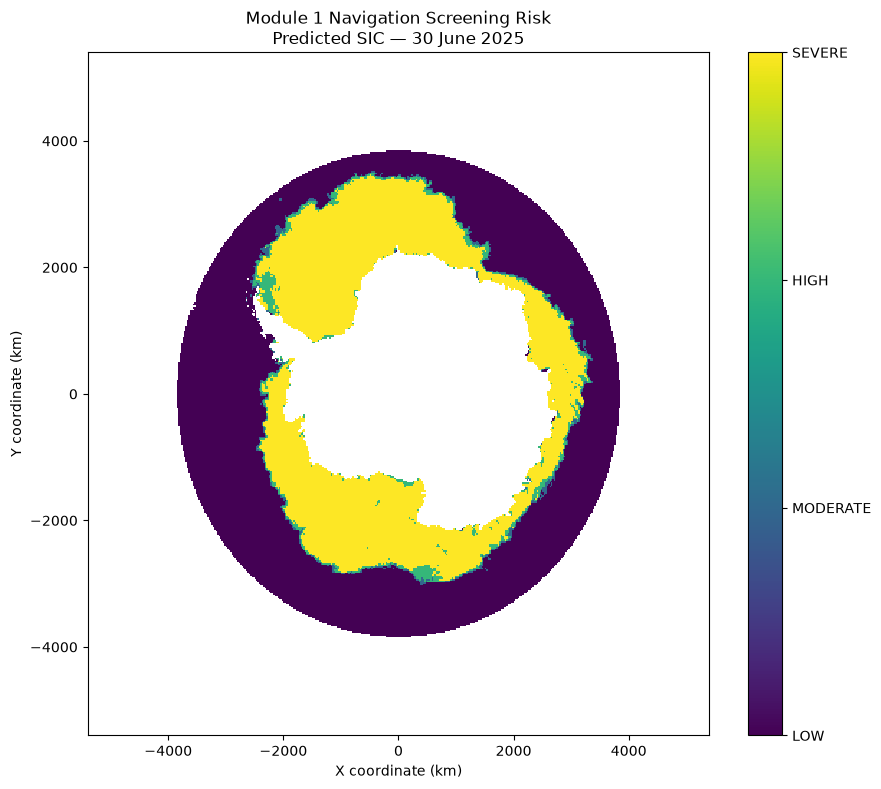

In [164]:
import numpy as np
import matplotlib.pyplot as plt

# Create native 432 x 432 risk grid
risk_map = np.full(
    (len(yc_values), len(xc_values)),
    np.nan,
    dtype="float32"
)

# Reuse the native grid indices
for row in day_df.itertuples(index=False):
    i = yc_index[row.yc]
    j = xc_index[row.xc]

    risk_map[i, j] = row.risk_code

print("Risk map shape:", risk_map.shape)
print(
    "Valid risk cells:",
    np.sum(~np.isnan(risk_map))
)

# Plot
plt.figure(figsize=(9, 8))

masked_risk = np.ma.masked_invalid(risk_map)

plt.pcolormesh(
    xc_values,
    yc_values,
    masked_risk,
    shading="auto",
    vmin=0,
    vmax=3
)

cbar = plt.colorbar(
    ticks=[0, 1, 2, 3]
)

cbar.ax.set_yticklabels(
    ["LOW", "MODERATE", "HIGH", "SEVERE"]
)

plt.xlabel("X coordinate (km)")
plt.ylabel("Y coordinate (km)")
plt.title(
    "Module 1 Navigation Screening Risk\n"
    "Predicted SIC — 30 June 2025"
)

plt.tight_layout()
plt.show()

In [165]:
from pathlib import Path

src_dir = Path("../src")
src_dir.mkdir(parents=True, exist_ok=True)

risk_code = '''
import numpy as np


# Prototype SIC screening thresholds.
# These are configurable and are NOT vessel-safety limits.
SIC_THRESHOLDS = {
    "low_max": 15.0,
    "moderate_max": 40.0,
    "high_max": 70.0,
}


RISK_LABELS = {
    0: "LOW",
    1: "MODERATE",
    2: "HIGH",
    3: "SEVERE",
}


def classify_sic_risk(sic_values):
    """
    Convert sea-ice concentration (%) to screening risk codes.

    Codes:
        0 = LOW
        1 = MODERATE
        2 = HIGH
        3 = SEVERE
       -1 = invalid / missing
    """

    sic_values = np.asarray(sic_values, dtype="float32")

    risk = np.full(
        sic_values.shape,
        -1,
        dtype=np.int8
    )

    valid = (
        np.isfinite(sic_values)
        & (sic_values >= 0)
        & (sic_values <= 100)
    )

    risk[
        valid & (sic_values < SIC_THRESHOLDS["low_max"])
    ] = 0

    risk[
        valid
        & (sic_values >= SIC_THRESHOLDS["low_max"])
        & (sic_values < SIC_THRESHOLDS["moderate_max"])
    ] = 1

    risk[
        valid
        & (sic_values >= SIC_THRESHOLDS["moderate_max"])
        & (sic_values < SIC_THRESHOLDS["high_max"])
    ] = 2

    risk[
        valid
        & (sic_values >= SIC_THRESHOLDS["high_max"])
        & (sic_values <= 100)
    ] = 3

    return risk


def risk_labels():
    """Return the mapping from risk code to label."""
    return RISK_LABELS.copy()
'''

risk_path = src_dir / "module1_risk.py"
risk_path.write_text(risk_code, encoding="utf-8")

print("Risk engine created:")
print(risk_path)

Risk engine created:
..\src\module1_risk.py


In [166]:
import sys
from pathlib import Path

src_path = Path("../src").resolve()

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from module1_risk import classify_sic_risk, risk_labels

deployment_risk = classify_sic_risk(
    day_df["predicted_sic"].values
)

print("External risk module test successful.")

print("\nRisk codes:")
unique, counts = np.unique(
    deployment_risk,
    return_counts=True
)

for code, count in zip(unique, counts):
    label = risk_labels().get(
        int(code),
        "INVALID"
    )
    print(f"{int(code)} = {label}: {count}")

External risk module test successful.

Risk codes:
0 = LOW: 30014
1 = MODERATE: 808
2 = HIGH: 1738
3 = SEVERE: 19136


In [167]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np

# Make src importable
src_path = Path("../src").resolve()

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from module1_predict import load_model, predict_next_day_sic
from module1_risk import classify_sic_risk, risk_labels


def run_module1(input_df):
    """
    Complete Module 1 inference pipeline.

    Input columns:
        lat
        lon
        sea_ice_concentration
        sic_lag1
        sic_lag2

    Returns:
        Input dataframe with:
        predicted_sic
        risk_code
        risk_class
    """

    required_columns = [
        "lat",
        "lon",
        "sea_ice_concentration",
        "sic_lag1",
        "sic_lag2"
    ]

    missing = [
        col for col in required_columns
        if col not in input_df.columns
    ]

    if missing:
        raise ValueError(
            f"Missing required columns: {missing}"
        )

    # Load production MVP model
    model = load_model()

    # Predict next-day SIC
    result = predict_next_day_sic(
        input_df,
        model=model
    )

    # Convert predicted SIC to risk
    result["risk_code"] = classify_sic_risk(
        result["predicted_sic"].values
    )

    labels = risk_labels()

    result["risk_class"] = (
        result["risk_code"]
        .map(labels)
    )

    return result


# ---------------------------------
# Test complete Module 1 pipeline
# ---------------------------------

module1_test = run_module1(day_df)

print("MODULE 1 COMPLETE PIPELINE TEST\n")

print("Rows:", len(module1_test))

print(
    "\nPredicted SIC range:",
    f"{module1_test['predicted_sic'].min():.2f}% "
    f"to "
    f"{module1_test['predicted_sic'].max():.2f}%"
)

print("\nRisk distribution:")

print(
    module1_test["risk_class"]
    .value_counts()
    .reindex(
        ["LOW", "MODERATE", "HIGH", "SEVERE"],
        fill_value=0
    )
)

print("\nFirst 5 results:")

print(
    module1_test[
        [
            "lat",
            "lon",
            "predicted_sic",
            "risk_code",
            "risk_class"
        ]
    ].head()
)

MODULE 1 COMPLETE PIPELINE TEST

Rows: 51696

Predicted SIC range: 0.00% to 99.95%

Risk distribution:
risk_class
LOW         30014
MODERATE      808
HIGH         1738
SEVERE      19136
Name: count, dtype: int64

First 5 results:
               lat       lon  predicted_sic  risk_code risk_class
5252463 -55.009514 -3.169493            0.0          0        LOW
5252464 -55.021767 -2.797244            0.0          0        LOW
5252465 -55.032494 -2.424757            0.0          0        LOW
5252466 -55.041687 -2.052065            0.0          0        LOW
5252467 -55.049351 -1.679200            0.0          0        LOW


In [168]:
from pathlib import Path

module_path = Path("../src/module1_predict.py")

existing_code = module_path.read_text(encoding="utf-8")

spatial_code = r'''

def create_spatial_output(result_df, yc_values, xc_values):
    """
    Convert Module 1 dataframe output into native grid arrays.

    Returns a dictionary containing:
        predicted_sic
        risk_code
        latitude
        longitude
        yc
        xc
    """

    import numpy as np

    yc_values = np.asarray(yc_values)
    xc_values = np.asarray(xc_values)

    predicted_sic = np.full(
        (len(yc_values), len(xc_values)),
        np.nan,
        dtype=np.float32
    )

    risk_code = np.full(
        (len(yc_values), len(xc_values)),
        -1,
        dtype=np.int8
    )

    latitude = np.full(
        (len(yc_values), len(xc_values)),
        np.nan,
        dtype=np.float32
    )

    longitude = np.full(
        (len(yc_values), len(xc_values)),
        np.nan,
        dtype=np.float32
    )

    yc_index = {
        value: i
        for i, value in enumerate(yc_values)
    }

    xc_index = {
        value: i
        for i, value in enumerate(xc_values)
    }

    for row in result_df.itertuples(index=False):

        if row.yc not in yc_index or row.xc not in xc_index:
            continue

        i = yc_index[row.yc]
        j = xc_index[row.xc]

        predicted_sic[i, j] = row.predicted_sic
        risk_code[i, j] = row.risk_code
        latitude[i, j] = row.lat
        longitude[i, j] = row.lon

    return {
        "predicted_sic": predicted_sic,
        "risk_code": risk_code,
        "latitude": latitude,
        "longitude": longitude,
        "yc": yc_values,
        "xc": xc_values,
    }
'''

if "def create_spatial_output" not in existing_code:
    module_path.write_text(
        existing_code + spatial_code,
        encoding="utf-8"
    )

print("Spatial output function added:")
print(module_path)

Spatial output function added:
..\src\module1_predict.py


In [169]:
import importlib
import module1_predict

importlib.reload(module1_predict)

from module1_predict import create_spatial_output

spatial_result = create_spatial_output(
    module1_test,
    yc_values,
    xc_values
)

print("Spatial output created.\n")

for key, value in spatial_result.items():
    if hasattr(value, "shape"):
        print(f"{key}: shape = {value.shape}")
    else:
        print(f"{key}: length = {len(value)}")

Spatial output created.

predicted_sic: shape = (432, 432)
risk_code: shape = (432, 432)
latitude: shape = (432, 432)
longitude: shape = (432, 432)
yc: shape = (432,)
xc: shape = (432,)


In [170]:
from pathlib import Path

pipeline_path = Path("../src/module1_pipeline.py")

pipeline_code = r'''
import numpy as np
import pandas as pd

from module1_predict import (
    load_model,
    predict_next_day_sic,
    create_spatial_output
)

from module1_risk import (
    classify_sic_risk,
    risk_labels
)


def run_module1(input_df, model=None):
    """
    Run the complete Module 1 pipeline.

    Input columns:
        lat
        lon
        sea_ice_concentration
        sic_lag1
        sic_lag2

    Returns:
        DataFrame containing:
        predicted_sic
        risk_code
        risk_class
    """

    if model is None:
        model = load_model()

    result = predict_next_day_sic(
        input_df,
        model=model
    )

    result["risk_code"] = classify_sic_risk(
        result["predicted_sic"].values
    )

    labels = risk_labels()

    result["risk_class"] = (
        result["risk_code"].map(labels)
    )

    return result


def run_module1_spatial(
    input_df,
    yc_values,
    xc_values,
    model=None
):
    """
    Run Module 1 and return native spatial grid outputs.

    Returns:
        {
            "predicted_sic": 432x432 array,
            "risk_code": 432x432 array,
            "latitude": 432x432 array,
            "longitude": 432x432 array,
            "yc": 1D grid,
            "xc": 1D grid
        }
    """

    result = run_module1(
        input_df,
        model=model
    )

    return create_spatial_output(
        result,
        yc_values,
        xc_values
    )
'''

pipeline_path.write_text(
    pipeline_code,
    encoding="utf-8"
)

print("Standalone Module 1 pipeline created:")
print(pipeline_path)

Standalone Module 1 pipeline created:
..\src\module1_pipeline.py


In [171]:
import sys
import importlib
from pathlib import Path

src_path = Path("../src").resolve()

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import module1_pipeline
importlib.reload(module1_pipeline)

from module1_pipeline import (
    run_module1,
    run_module1_spatial
)

# DataFrame pipeline test
pipeline_output = run_module1(day_df)

print("DataFrame pipeline:")
print("Rows:", len(pipeline_output))
print(
    "Predicted SIC:",
    f"{pipeline_output['predicted_sic'].min():.2f}% "
    f"to {pipeline_output['predicted_sic'].max():.2f}%"
)

print("\nRisk distribution:")
print(
    pipeline_output["risk_class"]
    .value_counts()
    .reindex(
        ["LOW", "MODERATE", "HIGH", "SEVERE"],
        fill_value=0
    )
)

# Spatial pipeline test
spatial_output = run_module1_spatial(
    day_df,
    yc_values,
    xc_values
)

print("\nSpatial pipeline:")
print("Predicted SIC:", spatial_output["predicted_sic"].shape)
print("Risk code:", spatial_output["risk_code"].shape)
print("Latitude:", spatial_output["latitude"].shape)
print("Longitude:", spatial_output["longitude"].shape)

assert spatial_output["predicted_sic"].shape == (432, 432)
assert spatial_output["risk_code"].shape == (432, 432)

print("\nMODULE 1 STANDALONE PIPELINE PASSED ✅")

DataFrame pipeline:
Rows: 51696
Predicted SIC: 0.00% to 99.95%

Risk distribution:
risk_class
LOW         30014
MODERATE      808
HIGH         1738
SEVERE      19136
Name: count, dtype: int64

Spatial pipeline:
Predicted SIC: (432, 432)
Risk code: (432, 432)
Latitude: (432, 432)
Longitude: (432, 432)

MODULE 1 STANDALONE PIPELINE PASSED ✅


In [172]:
from pathlib import Path

cost_path = Path("../src/module1_cost.py")

cost_code = r'''
import numpy as np


# Prototype navigation cost weights.
# These are tunable algorithmic parameters,
# not vessel-safety limits.
RISK_COSTS = {
    0: 1.0,        # LOW
    1: 5.0,        # MODERATE
    2: 20.0,       # HIGH
    3: 100.0,      # SEVERE
    -1: 1e6        # INVALID / unavailable
}


def create_navigation_cost(
    predicted_sic,
    risk_code=None
):
    """
    Convert predicted SIC into a navigation cost surface.

    If risk_code is supplied, risk-class costs are used.
    Otherwise a continuous SIC-based cost is generated.

    Returns:
        float32 numpy array
    """

    predicted_sic = np.asarray(
        predicted_sic,
        dtype="float32"
    )

    if risk_code is not None:

        risk_code = np.asarray(
            risk_code,
            dtype=np.int8
        )

        if predicted_sic.shape != risk_code.shape:
            raise ValueError(
                "predicted_sic and risk_code "
                "must have the same shape."
            )

        cost = np.full(
            predicted_sic.shape,
            RISK_COSTS[-1],
            dtype="float32"
        )

        for code, value in RISK_COSTS.items():

            if code == -1:
                continue

            cost[risk_code == code] = value

        return cost

    # Fallback continuous cost from SIC.
    valid = (
        np.isfinite(predicted_sic)
        & (predicted_sic >= 0)
        & (predicted_sic <= 100)
    )

    cost = np.full(
        predicted_sic.shape,
        RISK_COSTS[-1],
        dtype="float32"
    )

    # Smoothly increase cost with ice concentration.
    sic_fraction = predicted_sic[valid] / 100.0

    cost[valid] = (
        1.0
        + 20.0 * sic_fraction**2
    )

    return cost
'''

cost_path.write_text(
    cost_code,
    encoding="utf-8"
)

print("Navigation cost module created:")
print(cost_path)

Navigation cost module created:
..\src\module1_cost.py


In [173]:
import sys
import importlib
from pathlib import Path
import numpy as np

src_path = Path("../src").resolve()

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import module1_cost

importlib.reload(module1_cost)

from module1_cost import (
    create_navigation_cost,
    RISK_COSTS
)

navigation_cost = create_navigation_cost(
    spatial_output["predicted_sic"],
    spatial_output["risk_code"]
)

print("Navigation cost surface created.")

print("\nShape:", navigation_cost.shape)

print(
    "Minimum cost:",
    np.nanmin(navigation_cost)
)

print(
    "Maximum cost:",
    np.nanmax(navigation_cost)
)

print("\nCost distribution:")

unique_costs, cost_counts = np.unique(
    navigation_cost,
    return_counts=True
)

for cost, count in zip(unique_costs, cost_counts):
    print(
        f"{cost:g} -> {count} cells"
    )

assert navigation_cost.shape == (432, 432)

print("\nMODULE 1 NAVIGATION COST TEST PASSED ✅")

Navigation cost surface created.

Shape: (432, 432)
Minimum cost: 1.0
Maximum cost: 1e+06

Cost distribution:
1 -> 30014 cells
5 -> 808 cells
20 -> 1738 cells
100 -> 19136 cells
1e+06 -> 134928 cells

MODULE 1 NAVIGATION COST TEST PASSED ✅


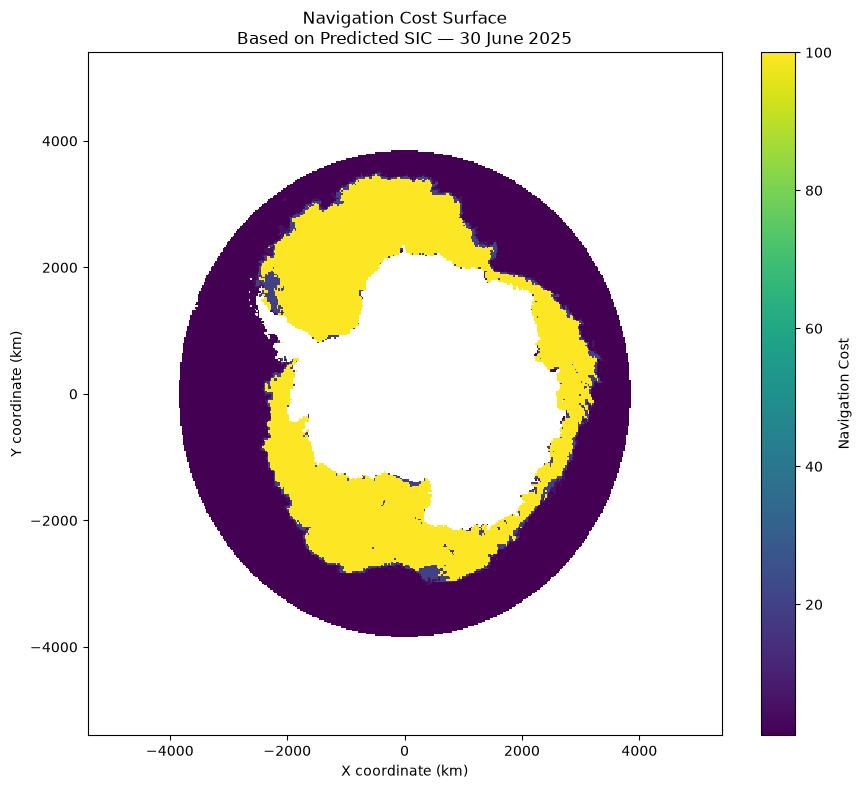

In [174]:
import matplotlib.pyplot as plt
import numpy as np

display_cost = navigation_cost.copy()

# Hide cells outside the valid Antarctic working region
display_cost[display_cost >= 1e6] = np.nan

plt.figure(figsize=(9, 8))

plt.pcolormesh(
    xc_values,
    yc_values,
    display_cost,
    shading="auto"
)

plt.colorbar(label="Navigation Cost")

plt.xlabel("X coordinate (km)")
plt.ylabel("Y coordinate (km)")
plt.title(
    "Navigation Cost Surface\n"
    "Based on Predicted SIC — 30 June 2025"
)

plt.tight_layout()
plt.show()

In [175]:
from pathlib import Path

route_path = Path("../src/module1_route.py")

route_code = r'''
import heapq
import math
import numpy as np


def _heuristic(a, b):
    """Euclidean distance between two grid cells."""
    return math.hypot(
        a[0] - b[0],
        a[1] - b[1]
    )


def find_least_cost_route(
    cost_surface,
    start,
    goal,
    blocked_cost=1e5
):
    """
    Find a least-cost route through a 2D navigation surface.

    Parameters
    ----------
    cost_surface : 2D numpy array
        Navigation cost for each grid cell.

    start : tuple
        (row, column)

    goal : tuple
        (row, column)

    blocked_cost : float
        Cells with cost >= this value are treated as blocked.

    Returns
    -------
    path : list of (row, column)
        Ordered route from start to goal.

    total_cost : float
        Accumulated route cost.
    """

    cost_surface = np.asarray(
        cost_surface,
        dtype="float32"
    )

    rows, cols = cost_surface.shape

    sr, sc = start
    gr, gc = goal

    if not (
        0 <= sr < rows
        and 0 <= sc < cols
        and 0 <= gr < rows
        and 0 <= gc < cols
    ):
        raise ValueError("Start or goal is outside the grid.")

    if (
        not np.isfinite(cost_surface[sr, sc])
        or cost_surface[sr, sc] >= blocked_cost
    ):
        raise ValueError("Start cell is blocked or invalid.")

    if (
        not np.isfinite(cost_surface[gr, gc])
        or cost_surface[gr, gc] >= blocked_cost
    ):
        raise ValueError("Goal cell is blocked or invalid.")

    # 8-connected neighbourhood
    neighbours = [
        (-1, -1), (-1, 0), (-1, 1),
        (0, -1),           (0, 1),
        (1, -1),  (1, 0),  (1, 1)
    ]

    open_heap = []

    heapq.heappush(
        open_heap,
        (0.0, start)
    )

    g_score = {
        start: 0.0
    }

    came_from = {}

    while open_heap:

        _, current = heapq.heappop(open_heap)

        if current == goal:
            # Reconstruct route
            path = [current]

            while current in came_from:
                current = came_from[current]
                path.append(current)

            path.reverse()

            return path, g_score[goal]

        r, c = current

        for dr, dc in neighbours:

            nr = r + dr
            nc = c + dc

            if not (
                0 <= nr < rows
                and 0 <= nc < cols
            ):
                continue

            neighbour_cost = cost_surface[nr, nc]

            if (
                not np.isfinite(neighbour_cost)
                or neighbour_cost >= blocked_cost
            ):
                continue

            # Diagonal movement is slightly longer
            distance = math.sqrt(2) if dr != 0 and dc != 0 else 1.0

            step_cost = (
                0.5 * (
                    float(cost_surface[r, c])
                    + float(neighbour_cost)
                )
                * distance
            )

            tentative_g = (
                g_score[current]
                + step_cost
            )

            neighbour = (nr, nc)

            if (
                neighbour not in g_score
                or tentative_g < g_score[neighbour]
            ):
                came_from[neighbour] = current
                g_score[neighbour] = tentative_g

                f_score = (
                    tentative_g
                    + _heuristic(neighbour, goal)
                )

                heapq.heappush(
                    open_heap,
                    (f_score, neighbour)
                )

    raise RuntimeError(
        "No navigable route exists between start and goal."
    )
'''

route_path.write_text(
    route_code,
    encoding="utf-8"
)

print("Route engine created:")
print(route_path)

Route engine created:
..\src\module1_route.py


In [176]:
import sys
import importlib
from pathlib import Path
import numpy as np

src_path = Path("../src").resolve()

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import module1_route
importlib.reload(module1_route)

from module1_route import find_least_cost_route


# -----------------------------
# Find valid LOW-risk cells
# -----------------------------
low_cells = np.argwhere(
    (
        spatial_output["risk_code"] == 0
    )
    & np.isfinite(navigation_cost)
)

print("Available LOW-risk cells:", len(low_cells))

if len(low_cells) < 2:
    raise ValueError(
        "Not enough LOW-risk cells for route test."
    )


# Choose two cells far apart.
# We use minimum and maximum x-coordinate.
leftmost = low_cells[
    np.argmin(
        low_cells[:, 1]
    )
]

rightmost = low_cells[
    np.argmax(
        low_cells[:, 1]
    )
]

start = tuple(leftmost)
goal = tuple(rightmost)

print("\nStart grid cell:", start)
print("Goal grid cell :", goal)


# -----------------------------
# Run A*
# -----------------------------
route, total_cost = find_least_cost_route(
    navigation_cost,
    start,
    goal
)

print("\nRoute found successfully.")
print("Number of grid cells:", len(route))
print("Total route cost:", round(total_cost, 2))


# -----------------------------
# Convert route to coordinates
# -----------------------------
route_rows = np.array(
    [cell[0] for cell in route]
)

route_cols = np.array(
    [cell[1] for cell in route]
)

route_x = xc_values[route_cols]
route_y = yc_values[route_rows]

route_lat = spatial_output["latitude"][
    route_rows,
    route_cols
]

route_lon = spatial_output["longitude"][
    route_rows,
    route_cols
]

print("\nStart coordinate:")
print(
    "lat =", route_lat[0],
    "lon =", route_lon[0]
)

print("\nGoal coordinate:")
print(
    "lat =", route_lat[-1],
    "lon =", route_lon[-1]
)

Available LOW-risk cells: 30014

Start grid cell: (np.int64(207), np.int64(62))
Goal grid cell : (np.int64(207), np.int64(369))

Route found successfully.
Number of grid cells: 345
Total route cost: 438.85

Start coordinate:
lat = -55.009514 lon = -86.830505

Goal coordinate:
lat = -55.009514 lon = 86.830505


========== ROUTE ANALYSIS ==========
Route cells: 345
Predicted SIC along route: 0.00% to 13.99%
Mean predicted SIC: 0.85%

Risk encountered along route:
LOW      :  345 cells (100.00%)
MODERATE :    0 cells (0.00%)
HIGH     :    0 cells (0.00%)
SEVERE   :    0 cells (0.00%)


C:\Users\acer\AppData\Local\Temp\ipykernel_20980\4172428469.py:105: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


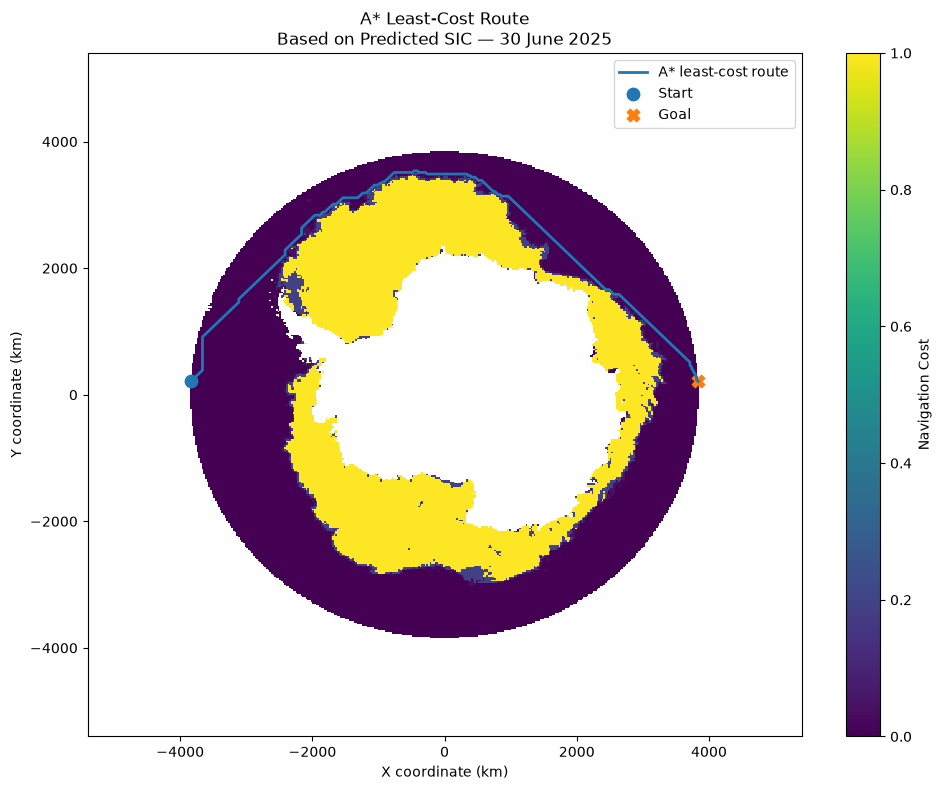

In [177]:
import matplotlib.pyplot as plt
import numpy as np

# Convert route to arrays
route_rows = np.array([p[0] for p in route])
route_cols = np.array([p[1] for p in route])

route_x = xc_values[route_cols]
route_y = yc_values[route_rows]

route_sic = spatial_output["predicted_sic"][
    route_rows,
    route_cols
]

route_risk = spatial_output["risk_code"][
    route_rows,
    route_cols
]

# Route statistics
valid_sic = route_sic[np.isfinite(route_sic)]

print("========== ROUTE ANALYSIS ==========")
print("Route cells:", len(route))

print(
    f"Predicted SIC along route: "
    f"{np.nanmin(valid_sic):.2f}% "
    f"to {np.nanmax(valid_sic):.2f}%"
)

print(
    f"Mean predicted SIC: "
    f"{np.nanmean(valid_sic):.2f}%"
)

# Count route cells by risk
print("\nRisk encountered along route:")

for code, label in {
    0: "LOW",
    1: "MODERATE",
    2: "HIGH",
    3: "SEVERE"
}.items():

    count = np.sum(route_risk == code)

    print(
        f"{label:9s}: "
        f"{count:4d} cells "
        f"({100 * count / len(route):.2f}%)"
    )


# -----------------------------
# Plot cost surface + route
# -----------------------------
display_cost = navigation_cost.copy()
display_cost[display_cost >= 1e6] = np.nan

plt.figure(figsize=(10, 8))

plt.pcolormesh(
    xc_values,
    yc_values,
    display_cost,
    shading="auto"
)

plt.plot(
    route_x,
    route_y,
    linewidth=2,
    label="A* least-cost route"
)

plt.scatter(
    route_x[0],
    route_y[0],
    s=80,
    marker="o",
    label="Start"
)

plt.scatter(
    route_x[-1],
    route_y[-1],
    s=80,
    marker="X",
    label="Goal"
)

plt.colorbar(label="Navigation Cost")

plt.xlabel("X coordinate (km)")
plt.ylabel("Y coordinate (km)")
plt.title(
    "A* Least-Cost Route\n"
    "Based on Predicted SIC — 30 June 2025"
)

plt.legend()
plt.tight_layout()
plt.show()

In [178]:
import numpy as np

# --------------------------------
# Route distance
# --------------------------------

# Route coordinates in km
route_x = xc_values[route_cols]
route_y = yc_values[route_rows]

# Distance between consecutive route cells
dx = np.diff(route_x)
dy = np.diff(route_y)

segment_distances = np.sqrt(
    dx**2 + dy**2
)

route_distance_km = np.sum(segment_distances)


# --------------------------------
# Straight-line distance
# --------------------------------

straight_dx = route_x[-1] - route_x[0]
straight_dy = route_y[-1] - route_y[0]

straight_distance_km = np.sqrt(
    straight_dx**2 + straight_dy**2
)


# --------------------------------
# Detour factor
# --------------------------------

detour_factor = (
    route_distance_km /
    straight_distance_km
)


# --------------------------------
# Print results
# --------------------------------

print("========== ROUTE DISTANCE ANALYSIS ==========")

print(
    f"Route distance:        "
    f"{route_distance_km:.2f} km"
)

print(
    f"Straight-line distance:"
    f" {straight_distance_km:.2f} km"
)

print(
    f"Detour factor:         "
    f"{detour_factor:.3f}x"
)

print(
    f"Extra distance:        "
    f"{route_distance_km - straight_distance_km:.2f} km"
)

========== ROUTE DISTANCE ANALYSIS ==========
Route distance:        10971.37 km
Straight-line distance: 7675.00 km
Detour factor:         1.429x
Extra distance:        3296.37 km


In [179]:
print("SIC dataset variables:")
print(list(sic_30_ds.data_vars))

print("\nVariable details:")

for name in sic_30_ds.data_vars:
    var = sic_30_ds[name]

    print(f"\n{name}")
    print("  dimensions:", var.dims)
    print("  dtype:", var.dtype)
    print("  units:", var.attrs.get("units"))
    print("  long_name:", var.attrs.get("long_name"))

SIC dataset variables:
['Lambert_Azimuthal_Grid', 'time_bnds', 'ice_conc', 'raw_ice_conc_values', 'total_standard_uncertainty', 'smearing_standard_uncertainty', 'algorithm_standard_uncertainty', 'status_flag']

Variable details:

Lambert_Azimuthal_Grid
  dimensions: ('time',)
  dtype: int32
  units: None
  long_name: None

time_bnds
  dimensions: ('time', 'nv')
  dtype: datetime64[ns]
  units: None
  long_name: None

ice_conc
  dimensions: ('time', 'yc', 'xc')
  dtype: float64
  units: %
  long_name: fully filtered concentration of sea ice using atmospheric correction of brightness temperatures and open water filters

raw_ice_conc_values
  dimensions: ('time', 'yc', 'xc')
  dtype: float64
  units: %
  long_name: sea ice concentration estimates as retrieved by the algorithm, and that were edited away by the various filters

total_standard_uncertainty
  dimensions: ('time', 'yc', 'xc')
  dtype: float64
  units: %
  long_name: total uncertainty (one standard deviation) of concentration of

In [180]:
import numpy as np
import pandas as pd

# June 30 status flag and SIC
status_30 = sic_30_ds["status_flag"].isel(
    time=-1
).values

sic_30 = sic_30_ds["ice_conc"].isel(
    time=-1
).values

# Unique status flag values
unique_flags, flag_counts = np.unique(
    status_30[np.isfinite(status_30)],
    return_counts=True
)

print("Unique status_flag values on 30 June:")
for flag, count in zip(unique_flags, flag_counts):
    print(f"{int(flag):>4} -> {count:>7} cells")

print("\nTotal cells:", status_30.size)

# Compare status with missing SIC
missing_sic = np.isnan(sic_30)

print("\nMissing ice_conc cells:", missing_sic.sum())

print("\nStatus flags among missing SIC cells:")

missing_flags, missing_counts = np.unique(
    status_30[missing_sic & np.isfinite(status_30)],
    return_counts=True
)

for flag, count in zip(missing_flags, missing_counts):
    print(f"{int(flag):>4} -> {count:>7} cells")

Unique status_flag values on 30 June:
   0 ->   21908 cells
   1 ->   33305 cells
   4 ->   17475 cells
   8 ->     116 cells
  20 ->      45 cells
 128 ->  113775 cells

Total cells: 186624

Missing ice_conc cells: 33305

Status flags among missing SIC cells:
   1 ->   33305 cells


In [181]:
import numpy as np

status_30 = sic_30_ds["status_flag"].isel(time=-1).values
sic_30 = sic_30_ds["ice_conc"].isel(time=-1).values

print("========== FLAG / SIC ANALYSIS ==========")

for flag in [0, 1, 4, 8, 20, 128]:

    mask = (
        status_30 == flag
    )

    count = np.sum(mask)

    if count == 0:
        continue

    values = sic_30[mask]

    valid_values = values[
        np.isfinite(values)
    ]

    print(f"\nFlag {flag}")
    print("Cells:", count)

    if len(valid_values) > 0:
        print(
            "SIC range:",
            float(np.min(valid_values)),
            "to",
            float(np.max(valid_values))
        )

        print(
            "Mean SIC:",
            float(np.mean(valid_values))
        )

    print(
        "Missing SIC:",
        np.sum(~np.isfinite(values))
    )

========== FLAG / SIC ANALYSIS ==========

Flag 0
Cells: 21908
SIC range: 8.82 to 100.0
Mean SIC: 88.89401907978821
Missing SIC: 0

Flag 1
Cells: 33305
Missing SIC: 33305

Flag 4
Cells: 17475
SIC range: 0.0 to 0.0
Mean SIC: 0.0
Missing SIC: 0

Flag 8
Cells: 116
SIC range: 0.0 to 81.08
Mean SIC: 14.374655172413794
Missing SIC: 0

Flag 20
Cells: 45
SIC range: 0.0 to 0.0
Mean SIC: 0.0
Missing SIC: 0

Flag 128
Cells: 113775
SIC range: 0.0 to 0.0
Mean SIC: 0.0
Missing SIC: 0


In [182]:
# Inspect geographic extent of valid LOW-risk cells

low_mask = (
    (spatial_output["risk_code"] == 0)
    & np.isfinite(spatial_output["latitude"])
    & np.isfinite(spatial_output["longitude"])
)

low_rows, low_cols = np.where(low_mask)

low_lats = spatial_output["latitude"][low_rows, low_cols]
low_lons = spatial_output["longitude"][low_rows, low_cols]

print("========== LOW-RISK SPATIAL EXTENT ==========")

print(
    f"Latitude:  {np.min(low_lats):.2f} "
    f"to {np.max(low_lats):.2f}"
)

print(
    f"Longitude: {np.min(low_lons):.2f} "
    f"to {np.max(low_lons):.2f}"
)

# Print a few representative LOW-risk cells
print("\nSample LOW-risk locations:")

sample_indices = np.linspace(
    0,
    len(low_rows) - 1,
    10,
    dtype=int
)

for idx in sample_indices:
    r = low_rows[idx]
    c = low_cols[idx]

    print(
        f"lat={spatial_output['latitude'][r,c]:.2f}, "
        f"lon={spatial_output['longitude'][r,c]:.2f}"
    )

========== LOW-RISK SPATIAL EXTENT ==========
Latitude:  -71.20 to -55.00
Longitude: -179.81 to 179.81

Sample LOW-risk locations:
lat=-55.01, lon=-3.17
lat=-61.95, lon=18.58
lat=-60.91, lon=50.05
lat=-60.49, lon=71.43
lat=-59.97, lon=88.92
lat=-58.21, lon=104.68
lat=-58.60, lon=121.11
lat=-61.73, lon=-146.76
lat=-55.18, lon=145.12
lat=-55.01, lon=176.83


In [183]:
import numpy as np

# Coordinates of LOW-risk cells
low_rows, low_cols = np.where(low_mask)

low_lat = spatial_output["latitude"][low_rows, low_cols]
low_lon = spatial_output["longitude"][low_rows, low_cols]

# Choose a central reference point
ref_lat = -60.0
ref_lon = 50.0

# Find a LOW-risk cell near the reference
dist_ref = (
    (low_lat - ref_lat)**2
    + (low_lon - ref_lon)**2
)

ref_idx = np.argmin(dist_ref)

start = (
    int(low_rows[ref_idx]),
    int(low_cols[ref_idx])
)

# Choose a second LOW-risk cell roughly 20–30 degrees
# eastward from the reference location
candidate_mask = (
    (low_lon > ref_lon + 15)
    & (low_lon < ref_lon + 30)
    & (low_lat > -68)
    & (low_lat < -55)
)

candidate_rows = low_rows[candidate_mask]
candidate_cols = low_cols[candidate_mask]

if len(candidate_rows) == 0:
    raise ValueError("Could not find a suitable second LOW-risk point.")

# Pick one reasonably close to the same latitude
candidate_lats = low_lat[candidate_mask]
candidate_lons = low_lon[candidate_mask]

lat_difference = np.abs(candidate_lats - low_lat[ref_idx])
goal_idx = np.argmin(lat_difference)

goal = (
    int(candidate_rows[goal_idx]),
    int(candidate_cols[goal_idx])
)

print("Selected route endpoints:\n")

print(
    "START:",
    f"lat={spatial_output['latitude'][start]:.2f},",
    f"lon={spatial_output['longitude'][start]:.2f}"
)

print(
    "GOAL :",
    f"lat={spatial_output['latitude'][goal]:.2f},",
    f"lon={spatial_output['longitude'][goal]:.2f}"
)


# -----------------------------
# Run A*
# -----------------------------

route2, total_cost2 = find_least_cost_route(
    navigation_cost,
    start,
    goal
)

print("\nRoute found.")
print("Route cells:", len(route2))
print("Total cost:", round(total_cost2, 2))


# -----------------------------
# Route statistics
# -----------------------------

route2_rows = np.array([p[0] for p in route2])
route2_cols = np.array([p[1] for p in route2])

route2_sic = spatial_output["predicted_sic"][
    route2_rows,
    route2_cols
]

route2_risk = spatial_output["risk_code"][
    route2_rows,
    route2_cols
]

print(
    f"\nMean predicted SIC: "
    f"{np.nanmean(route2_sic):.2f}%"
)

print(
    f"Maximum predicted SIC: "
    f"{np.nanmax(route2_sic):.2f}%"
)

print("\nRisk exposure:")

for code, label in {
    0: "LOW",
    1: "MODERATE",
    2: "HIGH",
    3: "SEVERE"
}.items():

    count = np.sum(route2_risk == code)

    print(
        f"{label:9s}: "
        f"{count:4d} cells "
        f"({100 * count / len(route2):.2f}%)"
    )

Selected route endpoints:

START: lat=-59.93, lon=49.89
GOAL : lat=-59.93, lon=68.56

Route found.
Route cells: 38
Total cost: 46.11

Mean predicted SIC: 0.01%
Maximum predicted SIC: 0.04%

Risk exposure:
LOW      :   38 cells (100.00%)
MODERATE :    0 cells (0.00%)
HIGH     :    0 cells (0.00%)
SEVERE   :    0 cells (0.00%)


In [184]:
# Route 2 physical distance

route2_x = xc_values[route2_cols]
route2_y = yc_values[route2_rows]

# Distance between consecutive grid cells
dx2 = np.diff(route2_x)
dy2 = np.diff(route2_y)

segment_distances2 = np.sqrt(
    dx2**2 + dy2**2
)

route2_distance_km = np.sum(segment_distances2)

# Straight-line distance
straight_dx2 = route2_x[-1] - route2_x[0]
straight_dy2 = route2_y[-1] - route2_y[0]

straight2_distance_km = np.sqrt(
    straight_dx2**2 + straight_dy2**2
)

detour2 = (
    route2_distance_km /
    straight2_distance_km
)

print("========== REALISTIC ROUTE DISTANCE ==========")

print(
    f"Route distance:         {route2_distance_km:.2f} km"
)

print(
    f"Straight-line distance: {straight2_distance_km:.2f} km"
)

print(
    f"Detour factor:          {detour2:.3f}x"
)

print(
    f"Extra distance:         "
    f"{route2_distance_km - straight2_distance_km:.2f} km"
)

========== REALISTIC ROUTE DISTANCE ==========
Route distance:         1152.82 km
Straight-line distance: 1076.16 km
Detour factor:          1.071x
Extra distance:         76.66 km


In [185]:
import numpy as np

# Route coordinates
route2_x = xc_values[route2_cols]
route2_y = yc_values[route2_rows]

route2_lat = spatial_output["latitude"][
    route2_rows,
    route2_cols
]

route2_lon = spatial_output["longitude"][
    route2_rows,
    route2_cols
]

route2_sic = spatial_output["predicted_sic"][
    route2_rows,
    route2_cols
]

route2_risk = spatial_output["risk_code"][
    route2_rows,
    route2_cols
]

# Risk exposure percentages
risk_exposure = {}

for code, label in {
    0: "LOW",
    1: "MODERATE",
    2: "HIGH",
    3: "SEVERE"
}.items():

    count = int(np.sum(route2_risk == code))

    risk_exposure[label] = {
        "cells": count,
        "percentage": round(
            100 * count / len(route2),
            2
        )
    }


# Backend-ready route object
route_result = {
    "status": "success",

    "start": {
        "latitude": float(route2_lat[0]),
        "longitude": float(route2_lon[0])
    },

    "destination": {
        "latitude": float(route2_lat[-1]),
        "longitude": float(route2_lon[-1])
    },

    "route": {
        "grid_cells": int(len(route2)),
        "distance_km": round(float(route2_distance_km), 2),
        "straight_line_distance_km": round(
            float(straight2_distance_km),
            2
        ),
        "detour_factor": round(
            float(detour2),
            3
        ),
        "extra_distance_km": round(
            float(
                route2_distance_km
                - straight2_distance_km
            ),
            2
        ),
        "total_navigation_cost": round(
            float(total_cost2),
            2
        )
    },

    "ice_exposure": {
        "mean_predicted_sic_percent": round(
            float(np.nanmean(route2_sic)),
            2
        ),
        "max_predicted_sic_percent": round(
            float(np.nanmax(route2_sic)),
            2
        ),
        "risk_exposure": risk_exposure
    },

    "coordinates": [
        {
            "latitude": float(lat),
            "longitude": float(lon)
        }
        for lat, lon in zip(
            route2_lat,
            route2_lon
        )
    ]
}

print("========== BACKEND ROUTE RESULT ==========")

print("Status:", route_result["status"])

print("\nStart:")
print(route_result["start"])

print("\nDestination:")
print(route_result["destination"])

print("\nRoute:")
print(route_result["route"])

print("\nIce exposure:")
print(route_result["ice_exposure"])

========== BACKEND ROUTE RESULT ==========
Status: success

Start:
{'latitude': -59.92581558227539, 'longitude': 49.890403747558594}

Destination:
{'latitude': -59.93281936645508, 'longitude': 68.55944061279297}

Route:
{'grid_cells': 38, 'distance_km': 1152.82, 'straight_line_distance_km': 1076.16, 'detour_factor': 1.071, 'extra_distance_km': 76.66, 'total_navigation_cost': 46.11}

Ice exposure:
{'mean_predicted_sic_percent': 0.01, 'max_predicted_sic_percent': 0.04, 'risk_exposure': {'LOW': {'cells': 38, 'percentage': 100.0}, 'MODERATE': {'cells': 0, 'percentage': 0.0}, 'HIGH': {'cells': 0, 'percentage': 0.0}, 'SEVERE': {'cells': 0, 'percentage': 0.0}}}


In [186]:
from pathlib import Path

route_path = Path("../src/module1_route.py")

existing_code = route_path.read_text(encoding="utf-8")

route_result_code = r'''


def build_route_result(
    route,
    total_cost,
    spatial_output,
    xc_values
):
    """
    Package an A* route into a backend-friendly result.

    Parameters
    ----------
    route : list of (row, col)
        Ordered A* route cells.

    total_cost : float
        Total navigation cost.

    spatial_output : dict
        Module 1 spatial output.

    xc_values : array
        Native projected X coordinates in km.

    Returns
    -------
    dict
        JSON-friendly route result.
    """

    import numpy as np

    route_rows = np.asarray(
        [p[0] for p in route],
        dtype=int
    )

    route_cols = np.asarray(
        [p[1] for p in route],
        dtype=int
    )

    route_x = np.asarray(xc_values)[route_cols]
    route_y = np.asarray(
        spatial_output["yc"]
    )[route_rows]

    route_lat = spatial_output["latitude"][
        route_rows,
        route_cols
    ]

    route_lon = spatial_output["longitude"][
        route_rows,
        route_cols
    ]

    route_sic = spatial_output["predicted_sic"][
        route_rows,
        route_cols
    ]

    route_risk = spatial_output["risk_code"][
        route_rows,
        route_cols
    ]

    # Physical route distance
    dx = np.diff(route_x)
    dy = np.diff(route_y)

    route_distance_km = float(
        np.sum(np.sqrt(dx**2 + dy**2))
    )

    # Straight-line distance
    straight_dx = route_x[-1] - route_x[0]
    straight_dy = route_y[-1] - route_y[0]

    straight_line_km = float(
        np.sqrt(
            straight_dx**2
            + straight_dy**2
        )
    )

    if straight_line_km > 0:
        detour_factor = (
            route_distance_km
            / straight_line_km
        )
    else:
        detour_factor = 1.0

    # Risk exposure
    risk_exposure = {}

    labels = {
        0: "LOW",
        1: "MODERATE",
        2: "HIGH",
        3: "SEVERE"
    }

    for code, label in labels.items():

        count = int(
            np.sum(route_risk == code)
        )

        risk_exposure[label] = {
            "cells": count,
            "percentage": round(
                100.0 * count / len(route),
                2
            )
        }

    valid_sic = route_sic[
        np.isfinite(route_sic)
    ]

    return {
        "status": "success",

        "start": {
            "latitude": float(route_lat[0]),
            "longitude": float(route_lon[0])
        },

        "destination": {
            "latitude": float(route_lat[-1]),
            "longitude": float(route_lon[-1])
        },

        "route": {
            "grid_cells": int(len(route)),
            "distance_km": round(
                route_distance_km,
                2
            ),
            "straight_line_distance_km": round(
                straight_line_km,
                2
            ),
            "detour_factor": round(
                detour_factor,
                3
            ),
            "extra_distance_km": round(
                route_distance_km
                - straight_line_km,
                2
            ),
            "total_navigation_cost": round(
                float(total_cost),
                2
            )
        },

        "ice_exposure": {
            "mean_predicted_sic_percent": round(
                float(np.nanmean(valid_sic)),
                2
            ),
            "max_predicted_sic_percent": round(
                float(np.nanmax(valid_sic)),
                2
            ),
            "risk_exposure": risk_exposure
        },

        "coordinates": [
            {
                "latitude": float(lat),
                "longitude": float(lon)
            }
            for lat, lon in zip(
                route_lat,
                route_lon
            )
        ]
    }
'''

if "def build_route_result" not in existing_code:
    route_path.write_text(
        existing_code + route_result_code,
        encoding="utf-8"
    )

print("Reusable route-result function added:")
print(route_path)

Reusable route-result function added:
..\src\module1_route.py


In [187]:
import sys
import importlib
from pathlib import Path

src_path = Path("../src").resolve()

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import module1_route
importlib.reload(module1_route)

from module1_route import build_route_result

route_result_2 = build_route_result(
    route2,
    total_cost2,
    spatial_output,
    xc_values
)

print("Reusable route-result test successful.\n")

print("Status:", route_result_2["status"])

print("\nRoute:")
print(route_result_2["route"])

print("\nIce exposure:")
print(route_result_2["ice_exposure"])

print("\nNumber of coordinates:",
      len(route_result_2["coordinates"]))

Reusable route-result test successful.

Status: success

Route:
{'grid_cells': 38, 'distance_km': 1152.82, 'straight_line_distance_km': 1076.16, 'detour_factor': 1.071, 'extra_distance_km': 76.66, 'total_navigation_cost': 46.11}

Ice exposure:
{'mean_predicted_sic_percent': 0.01, 'max_predicted_sic_percent': 0.04, 'risk_exposure': {'LOW': {'cells': 38, 'percentage': 100.0}, 'MODERATE': {'cells': 0, 'percentage': 0.0}, 'HIGH': {'cells': 0, 'percentage': 0.0}, 'SEVERE': {'cells': 0, 'percentage': 0.0}}}

Number of coordinates: 38


In [188]:
from pathlib import Path

route_path = Path("../src/module1_route.py")

existing_code = route_path.read_text(encoding="utf-8")

coord_code = r'''


def geographic_to_grid(
    latitude,
    longitude,
    spatial_output
):
    """
    Find the nearest valid Module 1 grid cell to a
    requested geographic coordinate.

    Parameters
    ----------
    latitude : float
    longitude : float
    spatial_output : dict
        Module 1 spatial output containing 2D latitude/longitude.

    Returns
    -------
    tuple
        (row, column)
    """

    import numpy as np

    lat_grid = np.asarray(
        spatial_output["latitude"],
        dtype="float32"
    )

    lon_grid = np.asarray(
        spatial_output["longitude"],
        dtype="float32"
    )

    valid = (
        np.isfinite(lat_grid)
        & np.isfinite(lon_grid)
    )

    if not np.any(valid):
        raise ValueError(
            "No valid geographic grid cells available."
        )

    # Simple geographic nearest-neighbour search.
    # This is appropriate for the 432x432 MVP grid.
    distance_squared = (
        (lat_grid - float(latitude)) ** 2
        + (lon_grid - float(longitude)) ** 2
    )

    distance_squared[~valid] = np.inf

    flat_index = np.argmin(distance_squared)

    row, column = np.unravel_index(
        flat_index,
        lat_grid.shape
    )

    return int(row), int(column)
'''

if "def geographic_to_grid" not in existing_code:
    route_path.write_text(
        existing_code + coord_code,
        encoding="utf-8"
    )

print("Geographic-to-grid function added:")
print(route_path)

Geographic-to-grid function added:
..\src\module1_route.py


In [189]:
import sys
import importlib
from pathlib import Path

src_path = Path("../src").resolve()

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import module1_route
importlib.reload(module1_route)

from module1_route import geographic_to_grid

start_lat = -59.93
start_lon = 49.89

goal_lat = -59.93
goal_lon = 68.56

start_grid = geographic_to_grid(
    start_lat,
    start_lon,
    spatial_output
)

goal_grid = geographic_to_grid(
    goal_lat,
    goal_lon,
    spatial_output
)

print("Coordinate → grid conversion successful.")

print("\nRequested start:")
print(start_lat, start_lon)

print("Mapped start grid:")
print(start_grid)

print("\nRequested goal:")
print(goal_lat, goal_lon)

print("Mapped goal grid:")
print(goal_grid)

print("\nMapped start coordinate:")
print(
    spatial_output["latitude"][start_grid],
    spatial_output["longitude"][start_grid]
)

print("\nMapped goal coordinate:")
print(
    spatial_output["latitude"][goal_grid],
    spatial_output["longitude"][goal_grid]
)

Coordinate → grid conversion successful.

Requested start:
-59.93 49.89
Mapped start grid:
(130, 317)

Requested goal:
-59.93 68.56
Mapped goal grid:
(167, 339)

Mapped start coordinate:
-59.925816 49.890404

Mapped goal coordinate:
-59.93282 68.55944


In [190]:
from pathlib import Path

route_path = Path("../src/module1_route.py")

existing_code = route_path.read_text(encoding="utf-8")

plan_route_code = r'''


def plan_route(
    start_lat,
    start_lon,
    goal_lat,
    goal_lon,
    navigation_cost,
    spatial_output,
    blocked_cost=1e5
):
    """
    Plan an ice-aware least-cost route between two
    geographic coordinates.

    Parameters
    ----------
    start_lat, start_lon : float
        Starting geographic coordinate.

    goal_lat, goal_lon : float
        Destination geographic coordinate.

    navigation_cost : 2D array
        Navigation cost surface.

    spatial_output : dict
        Module 1 spatial output.

    blocked_cost : float
        Cost at or above this value is treated as blocked.

    Returns
    -------
    dict
        Backend-ready route result.
    """

    # Convert geographic coordinates to grid cells
    start_grid = geographic_to_grid(
        start_lat,
        start_lon,
        spatial_output
    )

    goal_grid = geographic_to_grid(
        goal_lat,
        goal_lon,
        spatial_output
    )

    # Calculate route
    route, total_cost = find_least_cost_route(
        navigation_cost,
        start_grid,
        goal_grid,
        blocked_cost=blocked_cost
    )

    # Package result
    result = build_route_result(
        route,
        total_cost,
        spatial_output,
        spatial_output["xc"]
    )

    # Preserve the user's requested endpoints
    result["requested_start"] = {
        "latitude": float(start_lat),
        "longitude": float(start_lon)
    }

    result["requested_destination"] = {
        "latitude": float(goal_lat),
        "longitude": float(goal_lon)
    }

    result["grid_start"] = {
        "row": int(start_grid[0]),
        "column": int(start_grid[1])
    }

    result["grid_goal"] = {
        "row": int(goal_grid[0]),
        "column": int(goal_grid[1])
    }

    return result
'''

if "def plan_route" not in existing_code:
    route_path.write_text(
        existing_code + plan_route_code,
        encoding="utf-8"
    )

print("plan_route() added:")
print(route_path)

plan_route() added:
..\src\module1_route.py


In [191]:
import sys
import importlib
from pathlib import Path

src_path = Path("../src").resolve()

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import module1_route
importlib.reload(module1_route)

from module1_route import plan_route

planned_route = plan_route(
    start_lat=-59.93,
    start_lon=49.89,
    goal_lat=-59.93,
    goal_lon=68.56,
    navigation_cost=navigation_cost,
    spatial_output=spatial_output
)

print("========== PLAN_ROUTE TEST ==========")

print("\nStatus:")
print(planned_route["status"])

print("\nRequested start:")
print(planned_route["requested_start"])

print("Mapped start:")
print(planned_route["grid_start"])

print("\nRequested destination:")
print(planned_route["requested_destination"])

print("Mapped destination:")
print(planned_route["grid_goal"])

print("\nRoute:")
print(planned_route["route"])

print("\nIce exposure:")
print(planned_route["ice_exposure"])

print("\nCoordinate count:")
print(len(planned_route["coordinates"]))

========== PLAN_ROUTE TEST ==========

Status:
success

Requested start:
{'latitude': -59.93, 'longitude': 49.89}
Mapped start:
{'row': 130, 'column': 317}

Requested destination:
{'latitude': -59.93, 'longitude': 68.56}
Mapped destination:
{'row': 167, 'column': 339}

Route:
{'grid_cells': 38, 'distance_km': 1152.82, 'straight_line_distance_km': 1076.16, 'detour_factor': 1.071, 'extra_distance_km': 76.66, 'total_navigation_cost': 46.11}

Ice exposure:
{'mean_predicted_sic_percent': 0.01, 'max_predicted_sic_percent': 0.04, 'risk_exposure': {'LOW': {'cells': 38, 'percentage': 100.0}, 'MODERATE': {'cells': 0, 'percentage': 0.0}, 'HIGH': {'cells': 0, 'percentage': 0.0}, 'SEVERE': {'cells': 0, 'percentage': 0.0}}}

Coordinate count:
38


In [195]:
from pathlib import Path

api_path = Path("../src/api.py")

api_code = r'''
from typing import Dict, Any

import numpy as np
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel

from module1_route import plan_route


app = FastAPI(
    title="Antarctic Navigation API",
    description="Prototype Module 1 sea-ice-aware route planning API",
    version="0.1.0"
)


# --------------------------------------------------
# Request model
# --------------------------------------------------

class RouteRequest(BaseModel):
    start_latitude: float
    start_longitude: float
    destination_latitude: float
    destination_longitude: float


# --------------------------------------------------
# Runtime state
# --------------------------------------------------

# These will be initialized by the notebook/server setup.
NAVIGATION_COST = None
SPATIAL_OUTPUT = None


def initialize_navigation(
    navigation_cost,
    spatial_output
):
    """
    Initialize the navigation grids used by the API.
    """

    global NAVIGATION_COST
    global SPATIAL_OUTPUT

    NAVIGATION_COST = np.asarray(
        navigation_cost,
        dtype="float32"
    )

    SPATIAL_OUTPUT = spatial_output


# --------------------------------------------------
# Health check
# --------------------------------------------------

@app.get("/health")
def health():
    """
    Basic API health check.
    """

    return {
        "status": "ok",
        "module": "module1"
    }


# --------------------------------------------------
# Route endpoint
# --------------------------------------------------

@app.post("/route")
def route(request: RouteRequest) -> Dict[str, Any]:
    """
    Calculate an ice-aware route between two
    geographic coordinates.
    """

    if (
        NAVIGATION_COST is None
        or SPATIAL_OUTPUT is None
    ):
        raise HTTPException(
            status_code=503,
            detail="Navigation data has not been initialized."
        )

    try:

        result = plan_route(
            start_lat=request.start_latitude,
            start_lon=request.start_longitude,
            goal_lat=request.destination_latitude,
            goal_lon=request.destination_longitude,
            navigation_cost=NAVIGATION_COST,
            spatial_output=SPATIAL_OUTPUT
        )

        return result

    except ValueError as exc:

        raise HTTPException(
            status_code=400,
            detail=str(exc)
        )

    except RuntimeError as exc:

        raise HTTPException(
            status_code=422,
            detail=str(exc)
        )
'''

api_path.write_text(
    api_code,
    encoding="utf-8"
)

print("FastAPI module created:")
print(api_path)

FastAPI module created:
..\src\api.py


In [196]:
import sys
import importlib
from pathlib import Path

src_path = Path("../src").resolve()

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import api

importlib.reload(api)

api.initialize_navigation(
    navigation_cost=navigation_cost,
    spatial_output=spatial_output
)

print("API navigation data initialized.")

print("Navigation cost shape:",
      api.NAVIGATION_COST.shape)

print("Spatial grid:",
      api.SPATIAL_OUTPUT["predicted_sic"].shape)

API navigation data initialized.
Navigation cost shape: (432, 432)
Spatial grid: (432, 432)


In [197]:
from fastapi.testclient import TestClient

client = TestClient(api.app)

# -------------------------
# Health check
# -------------------------

health_response = client.get("/health")

print("Health endpoint:")
print("Status:", health_response.status_code)
print("Response:", health_response.json())


# -------------------------
# Route request
# -------------------------

route_request = {
    "start_latitude": -59.93,
    "start_longitude": 49.89,
    "destination_latitude": -59.93,
    "destination_longitude": 68.56
}

route_response = client.post(
    "/route",
    json=route_request
)

print("\nRoute endpoint:")
print("Status:", route_response.status_code)

route_api_result = route_response.json()

print("\nRoute:")
print(route_api_result["route"])

print("\nIce exposure:")
print(route_api_result["ice_exposure"])

print("\nCoordinates returned:",
      len(route_api_result["coordinates"]))

Health endpoint:
Status: 200
Response: {'status': 'ok', 'module': 'module1'}

Route endpoint:
Status: 200

Route:
{'grid_cells': 38, 'distance_km': 1152.82, 'straight_line_distance_km': 1076.16, 'detour_factor': 1.071, 'extra_distance_km': 76.66, 'total_navigation_cost': 46.11}

Ice exposure:
{'mean_predicted_sic_percent': 0.01, 'max_predicted_sic_percent': 0.04, 'risk_exposure': {'LOW': {'cells': 38, 'percentage': 100.0}, 'MODERATE': {'cells': 0, 'percentage': 0.0}, 'HIGH': {'cells': 0, 'percentage': 0.0}, 'SEVERE': {'cells': 0, 'percentage': 0.0}}}

Coordinates returned: 38


C:\Users\acer\anaconda3\envs\project_antarctica\Lib\site-packages\fastapi\testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


In [198]:
# Step 44 — API validation tests

# 1. Missing navigation data
# Create a fresh app reference and temporarily remove the grid.
original_cost = api.NAVIGATION_COST
original_spatial = api.SPATIAL_OUTPUT

api.NAVIGATION_COST = None
api.SPATIAL_OUTPUT = None

response_uninitialized = client.post(
    "/route",
    json={
        "start_latitude": -59.93,
        "start_longitude": 49.89,
        "destination_latitude": -59.93,
        "destination_longitude": 68.56
    }
)

print("Uninitialized API test:")
print("Status:", response_uninitialized.status_code)
print("Response:", response_uninitialized.json())

# Restore runtime data
api.NAVIGATION_COST = original_cost
api.SPATIAL_OUTPUT = original_spatial


# 2. Malformed request
response_bad_request = client.post(
    "/route",
    json={
        "start_latitude": -59.93
    }
)

print("\nMalformed request test:")
print("Status:", response_bad_request.status_code)
print("Response:", response_bad_request.json())


# 3. Valid request again
response_valid = client.post(
    "/route",
    json={
        "start_latitude": -59.93,
        "start_longitude": 49.89,
        "destination_latitude": -59.93,
        "destination_longitude": 68.56
    }
)

print("\nValid request after restoration:")
print("Status:", response_valid.status_code)

assert response_uninitialized.status_code == 503
assert response_bad_request.status_code == 422
assert response_valid.status_code == 200

print("\nAPI ERROR-HANDLING TESTS PASSED ✅")

Uninitialized API test:
Status: 503
Response: {'detail': 'Navigation data has not been initialized.'}

Malformed request test:
Status: 422
Response: {'detail': [{'type': 'missing', 'loc': ['body', 'start_longitude'], 'msg': 'Field required', 'input': {'start_latitude': -59.93}}, {'type': 'missing', 'loc': ['body', 'destination_latitude'], 'msg': 'Field required', 'input': {'start_latitude': -59.93}}, {'type': 'missing', 'loc': ['body', 'destination_longitude'], 'msg': 'Field required', 'input': {'start_latitude': -59.93}}]}

Valid request after restoration:
Status: 200

API ERROR-HANDLING TESTS PASSED ✅


In [199]:
import numpy as np
from pathlib import Path

runtime_dir = Path("../models/module1_outputs")
runtime_dir.mkdir(parents=True, exist_ok=True)

runtime_path = runtime_dir / "module1_navigation_runtime.npz"

np.savez_compressed(
    runtime_path,
    predicted_sic=spatial_output["predicted_sic"].astype("float32"),
    risk_code=spatial_output["risk_code"].astype("int8"),
    latitude=spatial_output["latitude"].astype("float32"),
    longitude=spatial_output["longitude"].astype("float32"),
    yc=spatial_output["yc"].astype("float64"),
    xc=spatial_output["xc"].astype("float64"),
    navigation_cost=navigation_cost.astype("float32")
)

print("Runtime artifact saved:")
print(runtime_path)

print(
    "File size (MB):",
    round(runtime_path.stat().st_size / (1024**2), 2)
)

Runtime artifact saved:
..\models\module1_outputs\module1_navigation_runtime.npz
File size (MB): 0.37


In [200]:
from pathlib import Path

api_path = Path("../src/api.py")

api_code = r'''
from typing import Dict, Any

import numpy as np
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel

from module1_route import plan_route


app = FastAPI(
    title="Antarctic Navigation API",
    description="Prototype Module 1 sea-ice-aware route planning API",
    version="0.1.0"
)


class RouteRequest(BaseModel):
    start_latitude: float
    start_longitude: float
    destination_latitude: float
    destination_longitude: float


# --------------------------------------------------
# Runtime data
# --------------------------------------------------

BASE_DIR = (
    Path(__file__).resolve().parent.parent
)

RUNTIME_PATH = (
    BASE_DIR
    / "models"
    / "module1_outputs"
    / "module1_navigation_runtime.npz"
)


def load_navigation_runtime():
    """
    Load the saved Module 1 spatial runtime artifact.
    """

    if not RUNTIME_PATH.exists():
        raise FileNotFoundError(
            f"Runtime artifact not found: {RUNTIME_PATH}"
        )

    data = np.load(
        RUNTIME_PATH,
        allow_pickle=False
    )

    spatial_output = {
        "predicted_sic": data["predicted_sic"],
        "risk_code": data["risk_code"],
        "latitude": data["latitude"],
        "longitude": data["longitude"],
        "yc": data["yc"],
        "xc": data["xc"],
    }

    navigation_cost = data["navigation_cost"]

    return navigation_cost, spatial_output


# Automatically load runtime data when API starts
try:
    NAVIGATION_COST, SPATIAL_OUTPUT = load_navigation_runtime()
    RUNTIME_LOADED = True
    RUNTIME_ERROR = None
except Exception as exc:
    NAVIGATION_COST = None
    SPATIAL_OUTPUT = None
    RUNTIME_LOADED = False
    RUNTIME_ERROR = str(exc)


# --------------------------------------------------
# Health
# --------------------------------------------------

@app.get("/health")
def health():
    return {
        "status": "ok" if RUNTIME_LOADED else "degraded",
        "module": "module1",
        "runtime_loaded": RUNTIME_LOADED
    }


# --------------------------------------------------
# Route
# --------------------------------------------------

@app.post("/route")
def route(request: RouteRequest) -> Dict[str, Any]:

    if not RUNTIME_LOADED:
        raise HTTPException(
            status_code=503,
            detail=f"Navigation runtime unavailable: {RUNTIME_ERROR}"
        )

    try:

        result = plan_route(
            start_lat=request.start_latitude,
            start_lon=request.start_longitude,
            goal_lat=request.destination_latitude,
            goal_lon=request.destination_longitude,
            navigation_cost=NAVIGATION_COST,
            spatial_output=SPATIAL_OUTPUT
        )

        return result

    except ValueError as exc:

        raise HTTPException(
            status_code=400,
            detail=str(exc)
        )

    except RuntimeError as exc:

        raise HTTPException(
            status_code=422,
            detail=str(exc)
        )
'''

# Add missing Path import
api_code = "from pathlib import Path\n" + api_code

api_path.write_text(
    api_code,
    encoding="utf-8"
)

print("API updated:")
print(api_path)

API updated:
..\src\api.py


In [201]:
import sys
import importlib
from pathlib import Path

src_path = Path("../src").resolve()

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import api
importlib.reload(api)

print("Runtime loaded:", api.RUNTIME_LOADED)

if api.RUNTIME_ERROR:
    print("Runtime error:", api.RUNTIME_ERROR)

print(
    "Navigation cost:",
    api.NAVIGATION_COST.shape
    if api.NAVIGATION_COST is not None
    else None
)

print(
    "Predicted SIC grid:",
    api.SPATIAL_OUTPUT["predicted_sic"].shape
    if api.SPATIAL_OUTPUT is not None
    else None
)

from fastapi.testclient import TestClient

client = TestClient(api.app)

health = client.get("/health")

print("\nHealth response:")
print(health.status_code)
print(health.json())

assert api.RUNTIME_LOADED
assert health.status_code == 200
assert health.json()["runtime_loaded"] is True

print("\nSELF-CONTAINED API TEST PASSED ✅")

Runtime loaded: True
Navigation cost: (432, 432)
Predicted SIC grid: (432, 432)

Health response:
200
{'status': 'ok', 'module': 'module1', 'runtime_loaded': True}

SELF-CONTAINED API TEST PASSED ✅


In [202]:
from pathlib import Path

init_file = Path("../src/__init__.py")

if not init_file.exists():
    init_file.write_text("", encoding="utf-8")

print("src package initialized:")
print(init_file)

src package initialized:
..\src\__init__.py


In [203]:
from pathlib import Path

api_path = Path("../src/api.py")

text = api_path.read_text(encoding="utf-8")

text = text.replace(
    "from module1_route import plan_route",
    "from .module1_route import plan_route"
)

api_path.write_text(text, encoding="utf-8")

print("api.py import fixed.")

api.py import fixed.


In [204]:
import sys
from pathlib import Path

project_root = Path("..").resolve()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import src.api as api

print("API imported successfully.")
print("Runtime loaded:", api.RUNTIME_LOADED)
print("Navigation grid:", api.NAVIGATION_COST.shape)

API imported successfully.
Runtime loaded: True
Navigation grid: (432, 432)


In [205]:
from pathlib import Path

route_path = Path("../src/module1_route.py")

text = route_path.read_text(encoding="utf-8")

old_block = '''        "coordinates": [
            {
                "latitude": float(lat),
                "longitude": float(lon)
            }
            for lat, lon in zip(
                route_lat,
                route_lon
            )
        ]
'''

new_block = '''        "coordinates": [
            {
                "latitude": float(lat),
                "longitude": float(lon)
            }
            for lat, lon in zip(
                route_lat,
                route_lon
            )
        ],

        "geometry": {
            "type": "LineString",
            "coordinates": [
                [
                    float(lon),
                    float(lat)
                ]
                for lat, lon in zip(
                    route_lat,
                    route_lon
                )
            ]
        }
'''

if old_block in text:
    text = text.replace(old_block, new_block)
else:
    raise RuntimeError(
        "Expected coordinates block was not found."
    )

route_path.write_text(
    text,
    encoding="utf-8"
)

print("GeoJSON geometry added to route result.")

GeoJSON geometry added to route result.


In [206]:
import sys
import importlib
from pathlib import Path

src_path = Path("../src").resolve()

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import module1_route
importlib.reload(module1_route)

from module1_route import plan_route

geo_route_test = plan_route(
    start_lat=-59.93,
    start_lon=49.89,
    goal_lat=-59.93,
    goal_lon=68.56,
    navigation_cost=navigation_cost,
    spatial_output=spatial_output
)

print("GeoJSON test successful.")

print("\nGeometry type:")
print(geo_route_test["geometry"]["type"])

print("\nNumber of route coordinates:")
print(len(geo_route_test["geometry"]["coordinates"]))

print("\nFirst coordinate:")
print(geo_route_test["geometry"]["coordinates"][0])

print("\nLast coordinate:")
print(geo_route_test["geometry"]["coordinates"][-1])

GeoJSON test successful.

Geometry type:
LineString

Number of route coordinates:
38

First coordinate:
[49.890403747558594, -59.92581558227539]

Last coordinate:
[68.55944061279297, -59.93281936645508]


In [207]:
from pathlib import Path

api_path = Path("../src/api.py")
text = api_path.read_text(encoding="utf-8")

# Add CORS import
text = text.replace(
    "from fastapi import FastAPI, HTTPException",
    "from fastapi import FastAPI, HTTPException\n"
    "from fastapi.middleware.cors import CORSMiddleware"
)

# Add CORS middleware after app creation
marker = '''app = FastAPI(
    title="Antarctic Navigation API",
    description="Prototype Module 1 sea-ice-aware route planning API",
    version="0.1.0"
)
'''

cors_block = marker + '''

app.add_middleware(
    CORSMiddleware,
    allow_origins=[
        "http://127.0.0.1:5500",
        "http://localhost:5500"
    ],
    allow_credentials=False,
    allow_methods=["GET", "POST"],
    allow_headers=["*"],
)
'''

if "CORSMiddleware" not in text:
    text = text.replace(marker, cors_block)

api_path.write_text(text, encoding="utf-8")

print("CORS configuration added to api.py")

CORS configuration added to api.py


In [208]:
from pathlib import Path

frontend_dir = Path("../frontend")
frontend_dir.mkdir(parents=True, exist_ok=True)

html = r'''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Antarctic Navigation</title>

    <link
        rel="stylesheet"
        href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"
    />

    <style>
        body {
            margin: 0;
            font-family: Arial, sans-serif;
        }

        #map {
            height: 100vh;
            width: 100%;
        }

        #panel {
            position: absolute;
            top: 20px;
            left: 20px;
            z-index: 1000;
            background: white;
            padding: 16px;
            border-radius: 10px;
            box-shadow: 0 2px 10px rgba(0,0,0,0.25);
            width: 300px;
        }

        input {
            width: 100%;
            box-sizing: border-box;
            margin: 5px 0 10px;
            padding: 8px;
        }

        button {
            width: 100%;
            padding: 10px;
            cursor: pointer;
        }

        #result {
            margin-top: 12px;
            font-size: 14px;
            line-height: 1.5;
        }
    </style>
</head>

<body>

<div id="panel">

    <h2>Antarctic Navigation</h2>

    <label>Start Latitude</label>
    <input id="startLat" value="-59.93">

    <label>Start Longitude</label>
    <input id="startLon" value="49.89">

    <label>Destination Latitude</label>
    <input id="goalLat" value="-59.93">

    <label>Destination Longitude</label>
    <input id="goalLon" value="68.56">

    <button onclick="calculateRoute()">
        Calculate Route
    </button>

    <div id="result">
        Enter coordinates and calculate a route.
    </div>

</div>

<div id="map"></div>

<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>

<script>

    const map = L.map("map").setView(
        [-70, 0],
        3
    );

    L.tileLayer(
        "https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png",
        {
            attribution: "&copy; OpenStreetMap contributors"
        }
    ).addTo(map);

    let routeLine = null;
    let startMarker = null;
    let goalMarker = null;


    async function calculateRoute() {

        const startLat = Number(
            document.getElementById("startLat").value
        );

        const startLon = Number(
            document.getElementById("startLon").value
        );

        const goalLat = Number(
            document.getElementById("goalLat").value
        );

        const goalLon = Number(
            document.getElementById("goalLon").value
        );


        document.getElementById("result").innerHTML =
            "Calculating route...";


        try {

            const response = await fetch(
                "http://127.0.0.1:8000/route",
                {
                    method: "POST",

                    headers: {
                        "Content-Type": "application/json"
                    },

                    body: JSON.stringify({
                        start_latitude: startLat,
                        start_longitude: startLon,
                        destination_latitude: goalLat,
                        destination_longitude: goalLon
                    })
                }
            );


            const data = await response.json();


            if (!response.ok) {
                throw new Error(
                    data.detail || "Route request failed."
                );
            }


            // Remove previous route
            if (routeLine) {
                map.removeLayer(routeLine);
            }

            if (startMarker) {
                map.removeLayer(startMarker);
            }

            if (goalMarker) {
                map.removeLayer(goalMarker);
            }


            // GeoJSON LineString
            const coordinates =
                data.geometry.coordinates.map(
                    point => [point[1], point[0]]
                );


            routeLine = L.polyline(
                coordinates,
                {
                    weight: 5
                }
            ).addTo(map);


            startMarker = L.marker(
                coordinates[0]
            ).addTo(map);

            startMarker.bindPopup(
                "Start"
            );


            goalMarker = L.marker(
                coordinates[
                    coordinates.length - 1
                ]
            ).addTo(map);

            goalMarker.bindPopup(
                "Destination"
            );


            map.fitBounds(
                routeLine.getBounds(),
                {
                    padding: [40, 40]
                }
            );


            const route = data.route;
            const ice = data.ice_exposure;


            document.getElementById("result").innerHTML = `

                <b>Route found</b><br><br>

                Distance:
                ${route.distance_km} km<br>

                Straight-line:
                ${route.straight_line_distance_km} km<br>

                Detour:
                ${route.detour_factor}x<br>

                Extra distance:
                ${route.extra_distance_km} km<br><br>

                Mean SIC:
                ${ice.mean_predicted_sic_percent}%<br>

                Maximum SIC:
                ${ice.max_predicted_sic_percent}%<br><br>

                Risk:
                ${ice.risk_exposure.LOW.percentage}%
                LOW
            `;

        }

        catch (error) {

            document.getElementById("result").innerHTML =
                `<b>Error:</b> ${error.message}`;

        }
    }

</script>

</body>
</html>
'''

frontend_path = frontend_dir / "index.html"
frontend_path.write_text(html, encoding="utf-8")

print("Frontend created:")
print(frontend_path)

Frontend created:
..\frontend\index.html


In [209]:
from pathlib import Path

api_path = Path("../src/api.py")

text = api_path.read_text(encoding="utf-8")

# Ensure CORS import exists
if "from fastapi.middleware.cors import CORSMiddleware" not in text:
    text = text.replace(
        "from fastapi import FastAPI, HTTPException",
        "from fastapi import FastAPI, HTTPException\n"
        "from fastapi.middleware.cors import CORSMiddleware"
    )

# Ensure CORS middleware exists
if "app.add_middleware(\n    CORSMiddleware" not in text:
    marker = '''app = FastAPI(
    title="Antarctic Navigation API",
    description="Prototype Module 1 sea-ice-aware route planning API",
    version="0.1.0"
)
'''

    cors_block = marker + '''

app.add_middleware(
    CORSMiddleware,
    allow_origins=[
        "http://127.0.0.1:5500",
        "http://localhost:5500"
    ],
    allow_credentials=False,
    allow_methods=["*"],
    allow_headers=["*"],
)
'''

    if marker not in text:
        raise RuntimeError(
            "FastAPI app definition was not found."
        )

    text = text.replace(marker, cors_block)

api_path.write_text(text, encoding="utf-8")

print("CORS configuration fixed in:")
print(api_path)

# Verify
print("\nCORS middleware present:",
      "CORSMiddleware" in text)

print(
    "allow_methods present:",
    'allow_methods=["*"]' in text
)

CORS configuration fixed in:
..\src\api.py

CORS middleware present: True
allow_methods present: True


In [210]:
from pathlib import Path

api_path = Path("../src/api.py")
text = api_path.read_text(encoding="utf-8")

start = text.find("from fastapi")
end = text.find("# --------------------------------------------------\n# Runtime data")

print(text[start:end])

from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel

from .module1_route import plan_route


app = FastAPI(
    title="Antarctic Navigation API",
    description="Prototype Module 1 sea-ice-aware route planning API",
    version="0.1.0"
)


app.add_middleware(
    CORSMiddleware,
    allow_origins=[
        "http://127.0.0.1:5500",
        "http://localhost:5500"
    ],
    allow_credentials=False,
    allow_methods=["*"],
    allow_headers=["*"],
)


class RouteRequest(BaseModel):
    start_latitude: float
    start_longitude: float
    destination_latitude: float
    destination_longitude: float





In [211]:
from pathlib import Path

api_path = Path("../src/api.py")
text = api_path.read_text(encoding="utf-8")

# Add a lightweight precomputed risk grid before the health endpoint.
marker = "# --------------------------------------------------\n# Health\n# --------------------------------------------------"

risk_grid_code = r'''# --------------------------------------------------
# Lightweight map grid
# --------------------------------------------------

# Downsample the native 432x432 grid by 4.
# This produces a 108x108 visualization grid and
# keeps browser/network load small.

GRID_STEP = 4

MAP_GRID = {
    "latitude": SPATIAL_OUTPUT["latitude"][::GRID_STEP, ::GRID_STEP],
    "longitude": SPATIAL_OUTPUT["longitude"][::GRID_STEP, ::GRID_STEP],
    "predicted_sic": SPATIAL_OUTPUT["predicted_sic"][::GRID_STEP, ::GRID_STEP],
    "risk_code": SPATIAL_OUTPUT["risk_code"][::GRID_STEP, ::GRID_STEP],
}


@app.get("/risk-grid")
def risk_grid():

    points = []

    lat = MAP_GRID["latitude"]
    lon = MAP_GRID["longitude"]
    sic = MAP_GRID["predicted_sic"]
    risk = MAP_GRID["risk_code"]

    rows, cols = lat.shape

    for i in range(rows):
        for j in range(cols):

            if (
                not np.isfinite(lat[i, j])
                or not np.isfinite(lon[i, j])
                or not np.isfinite(sic[i, j])
            ):
                continue

            code = int(risk[i, j])

            if code < 0:
                continue

            points.append({
                "latitude": float(lat[i, j]),
                "longitude": float(lon[i, j]),
                "sic": float(sic[i, j]),
                "risk_code": code
            })

    return {
        "status": "success",
        "grid_step": GRID_STEP,
        "points": points
    }


'''

if "@app.get(\"/risk-grid\")" not in text:

    if marker not in text:
        raise RuntimeError(
            "Health endpoint marker not found."
        )

    text = text.replace(
        marker,
        risk_grid_code + marker
    )

api_path.write_text(
    text,
    encoding="utf-8"
)

print("Risk-grid endpoint added:")
print(api_path)

Risk-grid endpoint added:
..\src\api.py


In [212]:
import sys
import importlib
from pathlib import Path

project_root = Path("..").resolve()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import src.api as api

importlib.reload(api)

from fastapi.testclient import TestClient

client = TestClient(api.app)

response = client.get("/risk-grid")

print("Status:", response.status_code)

data = response.json()

print("Grid step:", data["grid_step"])
print("Number of points:", len(data["points"]))

print("\nFirst point:")
print(data["points"][0])

assert response.status_code == 200
assert len(data["points"]) > 0

print("\nRISK-GRID API TEST PASSED ✅")

Status: 200
Grid step: 4
Number of points: 3239

First point:
{'latitude': -55.10918426513672, 'longitude': -8.817195892333984, 'sic': 0.0008805991965346038, 'risk_code': 0}

RISK-GRID API TEST PASSED ✅


In [213]:
from pathlib import Path

frontend_path = Path("../frontend/index.html")

html = r'''<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">
    <meta name="viewport"
          content="width=device-width, initial-scale=1.0">

    <title>Antarctic Navigation</title>

    <link
        rel="stylesheet"
        href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"
    />

    <style>

        body {
            margin: 0;
            font-family: Arial, sans-serif;
        }

        #map {
            height: 100vh;
            width: 100%;
        }

        #panel {
            position: absolute;
            top: 20px;
            left: 20px;
            z-index: 1000;

            background: white;
            padding: 16px;

            border-radius: 10px;

            box-shadow:
                0 2px 10px rgba(0,0,0,0.25);

            width: 310px;
        }

        input {
            width: 100%;
            box-sizing: border-box;

            margin: 5px 0 10px;
            padding: 8px;
        }

        button {
            width: 100%;
            padding: 10px;

            cursor: pointer;
        }

        #result {
            margin-top: 12px;
            font-size: 14px;
            line-height: 1.5;
        }

        #legend {
            margin-top: 12px;
            font-size: 13px;
        }

        .legend-row {
            margin: 4px 0;
        }

        .legend-box {
            display: inline-block;

            width: 14px;
            height: 14px;

            margin-right: 6px;

            vertical-align: middle;
        }

    </style>

</head>

<body>


<div id="panel">

    <h2>Antarctic Navigation</h2>


    <label>Start Latitude</label>
    <input id="startLat" value="-59.93">


    <label>Start Longitude</label>
    <input id="startLon" value="49.89">


    <label>Destination Latitude</label>
    <input id="goalLat" value="-59.93">


    <label>Destination Longitude</label>
    <input id="goalLon" value="68.56">


    <button onclick="calculateRoute()">
        Calculate Route
    </button>


    <div id="result">
        Loading sea-ice risk data...
    </div>


    <div id="legend">

        <b>Predicted SIC Risk</b>

        <div class="legend-row">
            <span class="legend-box"
                  style="background:#2ca25f"></span>
            LOW
        </div>

        <div class="legend-row">
            <span class="legend-box"
                  style="background:#f1c40f"></span>
            MODERATE
        </div>

        <div class="legend-row">
            <span class="legend-box"
                  style="background:#e67e22"></span>
            HIGH
        </div>

        <div class="legend-row">
            <span class="legend-box"
                  style="background:#d73027"></span>
            SEVERE
        </div>

    </div>

</div>


<div id="map"></div>


<script
    src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js">
</script>


<script>

const API_URL =
    "http://127.0.0.1:8000";


const map = L.map("map").setView(
    [-70, 0],
    3
);


L.tileLayer(
    "https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png",
    {
        attribution:
            "&copy; OpenStreetMap contributors"
    }
).addTo(map);


// Canvas renderer improves performance for
// several thousand risk points.
const canvasRenderer =
    L.canvas({ padding: 0.5 });


let riskLayer = null;
let routeLine = null;
let startMarker = null;
let goalMarker = null;


// ------------------------------------------
// Risk color
// ------------------------------------------

function riskColor(code) {

    if (code === 0)
        return "#2ca25f";

    if (code === 1)
        return "#f1c40f";

    if (code === 2)
        return "#e67e22";

    if (code === 3)
        return "#d73027";

    return "#808080";
}


// ------------------------------------------
// Load predicted SIC / risk grid
// ------------------------------------------

async function loadRiskGrid() {

    try {

        const response = await fetch(
            API_URL + "/risk-grid"
        );

        if (!response.ok) {
            throw new Error(
                "Risk-grid request failed."
            );
        }

        const data =
            await response.json();


        riskLayer =
            L.layerGroup();


        data.points.forEach(point => {

            const circle =
                L.circleMarker(
                    [
                        point.latitude,
                        point.longitude
                    ],
                    {
                        renderer: canvasRenderer,

                        radius: 4,

                        stroke: false,

                        fillColor:
                            riskColor(
                                point.risk_code
                            ),

                        fillOpacity: 0.75
                    }
                );


            circle.bindPopup(
                `
                <b>Sea-Ice Prediction</b><br>
                SIC:
                ${point.sic.toFixed(2)}%<br>
                Risk:
                ${riskLabel(
                    point.risk_code
                )}
                `
            );


            riskLayer.addLayer(
                circle
            );

        });


        riskLayer.addTo(map);


        console.log(
            "Risk points:",
            data.points.length
        );


        document.getElementById(
            "result"
        ).innerHTML =
            `
            <b>Sea-ice prediction loaded</b><br>
            ${data.points.length}
            visualization points available.
            `;

    }

    catch (error) {

        console.error(error);

        document.getElementById(
            "result"
        ).innerHTML =
            `
            <b>Risk-layer error:</b>
            ${error.message}
            `;

    }
}


// ------------------------------------------
// Risk labels
// ------------------------------------------

function riskLabel(code) {

    if (code === 0)
        return "LOW";

    if (code === 1)
        return "MODERATE";

    if (code === 2)
        return "HIGH";

    if (code === 3)
        return "SEVERE";

    return "INVALID";
}


// ------------------------------------------
// Route calculation
// ------------------------------------------

async function calculateRoute() {

    const startLat =
        Number(
            document.getElementById(
                "startLat"
            ).value
        );

    const startLon =
        Number(
            document.getElementById(
                "startLon"
            ).value
        );

    const goalLat =
        Number(
            document.getElementById(
                "goalLat"
            ).value
        );

    const goalLon =
        Number(
            document.getElementById(
                "goalLon"
            ).value
        );


    document.getElementById(
        "result"
    ).innerHTML =
        "Calculating route...";


    try {

        const response =
            await fetch(
                API_URL + "/route",
                {
                    method: "POST",

                    headers: {
                        "Content-Type":
                            "application/json"
                    },

                    body: JSON.stringify({

                        start_latitude:
                            startLat,

                        start_longitude:
                            startLon,

                        destination_latitude:
                            goalLat,

                        destination_longitude:
                            goalLon

                    })
                }
            );


        const data =
            await response.json();


        if (!response.ok) {

            throw new Error(
                data.detail ||
                "Route request failed."
            );

        }


        // Remove old route
        if (routeLine)
            map.removeLayer(routeLine);

        if (startMarker)
            map.removeLayer(startMarker);

        if (goalMarker)
            map.removeLayer(goalMarker);


        // GeoJSON coordinates are:
        // [longitude, latitude]

        const coordinates =
            data.geometry.coordinates.map(
                point => [
                    point[1],
                    point[0]
                ]
            );


        routeLine =
            L.polyline(
                coordinates,
                {
                    color: "#0066ff",
                    weight: 5,
                    opacity: 0.9
                }
            ).addTo(map);


        startMarker =
            L.marker(
                coordinates[0]
            ).addTo(map);


        startMarker.bindPopup(
            "<b>Start</b>"
        );


        goalMarker =
            L.marker(
                coordinates[
                    coordinates.length - 1
                ]
            ).addTo(map);


        goalMarker.bindPopup(
            "<b>Destination</b>"
        );


        map.fitBounds(
            routeLine.getBounds(),
            {
                padding: [40, 40]
            }
        );


        const route =
            data.route;

        const ice =
            data.ice_exposure;


        document.getElementById(
            "result"
        ).innerHTML = `

            <b>Ice-aware route found</b><br><br>

            Distance:
            ${route.distance_km} km<br>

            Straight-line:
            ${route.straight_line_distance_km} km<br>

            Detour:
            ${route.detour_factor}x<br>

            Extra distance:
            ${route.extra_distance_km} km<br><br>

            Mean SIC:
            ${ice.mean_predicted_sic_percent}%<br>

            Maximum SIC:
            ${ice.max_predicted_sic_percent}%<br><br>

            Risk:
            ${ice.risk_exposure.LOW.percentage}%
            LOW

        `;

    }

    catch (error) {

        document.getElementById(
            "result"
        ).innerHTML =
            `<b>Error:</b> ${error.message}`;

    }
}


// Load risk layer immediately
loadRiskGrid();

</script>

</body>

</html>
'''

frontend_path.write_text(
    html,
    encoding="utf-8"
)

print("Frontend updated:")
print(frontend_path)

Frontend updated:
..\frontend\index.html


In [214]:
from pathlib import Path

frontend_path = Path("../frontend/index.html")

html = r'''<!DOCTYPE html>
<html lang="en">

<head>

<meta charset="UTF-8">
<meta name="viewport"
      content="width=device-width, initial-scale=1.0">

<title>Antarctic Navigation</title>

<link
    rel="stylesheet"
    href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"
/>

<style>

body {
    margin: 0;
    font-family: Arial, sans-serif;
}

#map {
    width: 100%;
    height: 100vh;
}

#panel {
    position: absolute;
    top: 20px;
    left: 20px;

    z-index: 1000;

    width: 320px;

    background: white;

    padding: 16px;

    border-radius: 10px;

    box-shadow:
        0 2px 12px rgba(0,0,0,0.25);
}

h2 {
    margin-top: 0;
}

input {
    width: 100%;
    box-sizing: border-box;

    padding: 8px;

    margin:
        4px 0 10px;
}

button {
    width: 100%;

    padding: 9px;

    margin-top: 5px;

    cursor: pointer;
}

#selectionStatus {
    margin-top: 10px;

    font-size: 13px;

    font-weight: bold;
}

#result {
    margin-top: 14px;

    font-size: 14px;

    line-height: 1.5;
}

#legend {
    margin-top: 14px;

    font-size: 13px;
}

.legend-row {
    margin: 4px 0;
}

.legend-box {
    width: 14px;
    height: 14px;

    display: inline-block;

    margin-right: 6px;

    vertical-align: middle;
}

</style>

</head>


<body>


<div id="panel">

<h2>Antarctic Navigation</h2>


<label>Start Latitude</label>

<input
    id="startLat"
    value="-59.93"
/>


<label>Start Longitude</label>

<input
    id="startLon"
    value="49.89"
/>


<button onclick="enableStartSelection()">
    📍 Set Start From Map
</button>


<label>Destination Latitude</label>

<input
    id="goalLat"
    value="-59.93"
/>


<label>Destination Longitude</label>

<input
    id="goalLon"
    value="68.56"
/>


<button onclick="enableGoalSelection()">
    🎯 Set Destination From Map
</button>


<div id="selectionStatus">
    Select coordinates manually or from the map.
</div>


<button onclick="calculateRoute()">
    Calculate Route
</button>


<div id="result">
    Loading sea-ice risk data...
</div>


<div id="legend">

<b>Predicted SIC Risk</b>

<div class="legend-row">
<span class="legend-box"
      style="background:#2ca25f"></span>
LOW
</div>

<div class="legend-row">
<span class="legend-box"
      style="background:#f1c40f"></span>
MODERATE
</div>

<div class="legend-row">
<span class="legend-box"
      style="background:#e67e22"></span>
HIGH
</div>

<div class="legend-row">
<span class="legend-box"
      style="background:#d73027"></span>
SEVERE
</div>

</div>

</div>


<div id="map"></div>


<script
src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js">
</script>


<script>

const API_URL =
    "http://127.0.0.1:8000";


const map =
    L.map("map").setView(
        [-70, 0],
        3
    );


L.tileLayer(
    "https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png",
    {
        attribution:
            "&copy; OpenStreetMap contributors"
    }
).addTo(map);


const canvasRenderer =
    L.canvas({
        padding: 0.5
    });


let riskLayer = null;

let routeLine = null;

let startMarker = null;

let goalMarker = null;

let selectionMode = null;


// ----------------------------------------
// Risk colours
// ----------------------------------------

function riskColor(code) {

    if (code === 0)
        return "#2ca25f";

    if (code === 1)
        return "#f1c40f";

    if (code === 2)
        return "#e67e22";

    if (code === 3)
        return "#d73027";

    return "#808080";
}


// ----------------------------------------
// Risk labels
// ----------------------------------------

function riskLabel(code) {

    if (code === 0)
        return "LOW";

    if (code === 1)
        return "MODERATE";

    if (code === 2)
        return "HIGH";

    if (code === 3)
        return "SEVERE";

    return "INVALID";
}


// ----------------------------------------
// Load risk grid
// ----------------------------------------

async function loadRiskGrid() {

    try {

        const response =
            await fetch(
                API_URL + "/risk-grid"
            );


        if (!response.ok) {

            throw new Error(
                "Risk-grid request failed."
            );

        }


        const data =
            await response.json();


        riskLayer =
            L.layerGroup();


        data.points.forEach(
            point => {

                const circle =
                    L.circleMarker(
                        [
                            point.latitude,
                            point.longitude
                        ],
                        {
                            renderer:
                                canvasRenderer,

                            radius: 4,

                            stroke: false,

                            fillColor:
                                riskColor(
                                    point.risk_code
                                ),

                            fillOpacity: 0.75
                        }
                    );


                circle.bindPopup(
                    `
                    <b>Sea-Ice Prediction</b><br>
                    SIC:
                    ${point.sic.toFixed(2)}%<br>
                    Risk:
                    ${riskLabel(
                        point.risk_code
                    )}
                    `
                );


                riskLayer.addLayer(
                    circle
                );

            }
        );


        riskLayer.addTo(map);


        document.getElementById(
            "result"
        ).innerHTML =
            `
            <b>Sea-ice prediction loaded</b><br>
            ${data.points.length}
            visualization points available.
            `;

    }

    catch(error) {

        console.error(error);

        document.getElementById(
            "result"
        ).innerHTML =
            `<b>Risk-layer error:</b>
             ${error.message}`;

    }
}


// ----------------------------------------
// Enable start selection
// ----------------------------------------

function enableStartSelection() {

    selectionMode = "start";

    document.getElementById(
        "selectionStatus"
    ).innerHTML =
        "Click the map to select the START location.";

}


// ----------------------------------------
// Enable goal selection
// ----------------------------------------

function enableGoalSelection() {

    selectionMode = "goal";

    document.getElementById(
        "selectionStatus"
    ).innerHTML =
        "Click the map to select the DESTINATION.";


}


// ----------------------------------------
// Map click
// ----------------------------------------

map.on(
    "click",
    function(event) {

        if (!selectionMode)
            return;


        const lat =
            event.latlng.lat;

        const lon =
            event.latlng.lng;


        if (selectionMode === "start") {

            document.getElementById(
                "startLat"
            ).value =
                lat.toFixed(4);


            document.getElementById(
                "startLon"
            ).value =
                lon.toFixed(4);


            if (startMarker)
                map.removeLayer(
                    startMarker
                );


            startMarker =
                L.marker(
                    [
                        lat,
                        lon
                    ]
                )
                .addTo(map)
                .bindPopup(
                    "Selected Start"
                )
                .openPopup();


            selectionMode = null;


            document.getElementById(
                "selectionStatus"
            ).innerHTML =
                "Start location selected.";

        }


        else if (
            selectionMode === "goal"
        ) {

            document.getElementById(
                "goalLat"
            ).value =
                lat.toFixed(4);


            document.getElementById(
                "goalLon"
            ).value =
                lon.toFixed(4);


            if (goalMarker)
                map.removeLayer(
                    goalMarker
                );


            goalMarker =
                L.marker(
                    [
                        lat,
                        lon
                    ]
                )
                .addTo(map)
                .bindPopup(
                    "Selected Destination"
                )
                .openPopup();


            selectionMode = null;


            document.getElementById(
                "selectionStatus"
            ).innerHTML =
                "Destination selected.";

        }

    }
);


// ----------------------------------------
// Calculate route
// ----------------------------------------

async function calculateRoute() {

    const startLat =
        Number(
            document.getElementById(
                "startLat"
            ).value
        );


    const startLon =
        Number(
            document.getElementById(
                "startLon"
            ).value
        );


    const goalLat =
        Number(
            document.getElementById(
                "goalLat"
            ).value
        );


    const goalLon =
        Number(
            document.getElementById(
                "goalLon"
            ).value
        );


    document.getElementById(
        "result"
    ).innerHTML =
        "Calculating route...";


    try {

        const response =
            await fetch(
                API_URL + "/route",
                {
                    method: "POST",

                    headers: {
                        "Content-Type":
                            "application/json"
                    },

                    body: JSON.stringify({

                        start_latitude:
                            startLat,

                        start_longitude:
                            startLon,

                        destination_latitude:
                            goalLat,

                        destination_longitude:
                            goalLon

                    })
                }
            );


        const data =
            await response.json();


        if (!response.ok) {

            throw new Error(
                data.detail ||
                "Route request failed."
            );

        }


        if (routeLine)
            map.removeLayer(
                routeLine
            );


        if (startMarker)
            map.removeLayer(
                startMarker
            );


        if (goalMarker)
            map.removeLayer(
                goalMarker
            );


        const coordinates =
            data.geometry.coordinates.map(
                point => [
                    point[1],
                    point[0]
                ]
            );


        routeLine =
            L.polyline(
                coordinates,
                {
                    color: "#0066ff",
                    weight: 5,
                    opacity: 0.95
                }
            )
            .addTo(map);


        startMarker =
            L.marker(
                coordinates[0]
            )
            .addTo(map)
            .bindPopup(
                "<b>Start</b>"
            );


        goalMarker =
            L.marker(
                coordinates[
                    coordinates.length - 1
                ]
            )
            .addTo(map)
            .bindPopup(
                "<b>Destination</b>"
            );


        map.fitBounds(
            routeLine.getBounds(),
            {
                padding: [40, 40]
            }
        );


        const route =
            data.route;

        const ice =
            data.ice_exposure;


        document.getElementById(
            "result"
        ).innerHTML = `

        <b>Ice-aware route found</b><br><br>

        Distance:
        ${route.distance_km} km<br>

        Straight-line:
        ${route.straight_line_distance_km} km<br>

        Detour:
        ${route.detour_factor}x<br>

        Extra distance:
        ${route.extra_distance_km} km<br><br>

        Mean SIC:
        ${ice.mean_predicted_sic_percent}%<br>

        Maximum SIC:
        ${ice.max_predicted_sic_percent}%<br><br>

        Risk:
        ${ice.risk_exposure.LOW.percentage}%
        LOW

        `;

    }

    catch(error) {

        document.getElementById(
            "result"
        ).innerHTML =
            `<b>Error:</b>
             ${error.message}`;

    }
}


// Start loading risk data
loadRiskGrid();

</script>

</body>

</html>
'''

frontend_path.write_text(
    html,
    encoding="utf-8"
)

print("Interactive map frontend updated:")
print(frontend_path)

Interactive map frontend updated:
..\frontend\index.html


In [215]:
from pathlib import Path

frontend_path = Path("../frontend/index.html")

html = r'''<!DOCTYPE html>
<html lang="en">

<head>

<meta charset="UTF-8">
<meta name="viewport"
      content="width=device-width, initial-scale=1.0">

<title>Antarctic Navigation</title>

<link
    rel="stylesheet"
    href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"
/>

<style>

body {
    margin: 0;
    font-family: Arial, sans-serif;
}

#map {
    width: 100%;
    height: 100vh;
}

#panel {
    position: absolute;
    top: 20px;
    left: 20px;
    z-index: 1000;

    width: 330px;

    background: white;
    padding: 16px;

    border-radius: 10px;

    box-shadow: 0 2px 12px rgba(0,0,0,0.25);
}

h2 {
    margin-top: 0;
}

input {
    width: 100%;
    box-sizing: border-box;
    padding: 8px;
    margin: 4px 0 10px;
}

button {
    width: 100%;
    padding: 9px;
    margin-top: 5px;
    cursor: pointer;
}

.mode-buttons {
    display: flex;
    gap: 6px;
    margin-top: 10px;
}

.mode-buttons button {
    margin: 0;
}

.active-mode {
    font-weight: bold;
}

#selectionStatus {
    margin-top: 10px;
    font-size: 13px;
    font-weight: bold;
}

#result {
    margin-top: 14px;
    font-size: 14px;
    line-height: 1.5;
}

#legend {
    margin-top: 14px;
    font-size: 13px;
}

.legend-row {
    margin: 4px 0;
}

.legend-box {
    width: 14px;
    height: 14px;
    display: inline-block;
    margin-right: 6px;
    vertical-align: middle;
}

</style>

</head>

<body>

<div id="panel">

<h2>Antarctic Navigation</h2>

<label>Start Latitude</label>
<input id="startLat" value="-59.93">

<label>Start Longitude</label>
<input id="startLon" value="49.89">

<button onclick="enableStartSelection()">
📍 Set Start From Map
</button>

<label>Destination Latitude</label>
<input id="goalLat" value="-59.93">

<label>Destination Longitude</label>
<input id="goalLon" value="68.56">

<button onclick="enableGoalSelection()">
🎯 Set Destination From Map
</button>

<div id="selectionStatus">
Select coordinates manually or from the map.
</div>

<button onclick="calculateRoute()">
Calculate Route
</button>

<div class="mode-buttons">

<button
    id="sicButton"
    onclick="showSIC()"
    class="active-mode">
    Predicted SIC
</button>

<button
    id="riskButton"
    onclick="showRisk()">
    Risk Level
</button>

</div>

<div id="result">
Loading prediction...
</div>

<div id="legend">

<b id="legendTitle">Predicted SIC</b>

<div id="sicLegend">

<div class="legend-row">
0% → Open Water
</div>

<div class="legend-row">
100% → Highest Ice
</div>

</div>

<div id="riskLegend" style="display:none;">

<div class="legend-row">
<span class="legend-box"
      style="background:#2ca25f"></span>
LOW
</div>

<div class="legend-row">
<span class="legend-box"
      style="background:#f1c40f"></span>
MODERATE
</div>

<div class="legend-row">
<span class="legend-box"
      style="background:#e67e22"></span>
HIGH
</div>

<div class="legend-row">
<span class="legend-box"
      style="background:#d73027"></span>
SEVERE
</div>

</div>

</div>

</div>

<div id="map"></div>

<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>

<script src="https://unpkg.com/leaflet.heat/dist/leaflet-heat.js"></script>

<script>

const API_URL = "http://127.0.0.1:8000";

const map = L.map("map").setView(
    [-70, 0],
    3
);

L.tileLayer(
    "https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png",
    {
        attribution:
            "&copy; OpenStreetMap contributors"
    }
).addTo(map);


const canvasRenderer =
    L.canvas({ padding: 0.5 });


let sicHeatLayer = null;
let riskLayer = null;

let routeLine = null;
let startMarker = null;
let goalMarker = null;

let selectionMode = null;


// ------------------------------------------------
// Risk colour
// ------------------------------------------------

function riskColor(code) {

    if (code === 0)
        return "#2ca25f";

    if (code === 1)
        return "#f1c40f";

    if (code === 2)
        return "#e67e22";

    if (code === 3)
        return "#d73027";

    return "#808080";
}


function riskLabel(code) {

    if (code === 0)
        return "LOW";

    if (code === 1)
        return "MODERATE";

    if (code === 2)
        return "HIGH";

    if (code === 3)
        return "SEVERE";

    return "INVALID";
}


// ------------------------------------------------
// Load risk grid
// ------------------------------------------------

async function loadRiskGrid() {

    try {

        const response =
            await fetch(
                API_URL + "/risk-grid"
            );

        if (!response.ok)
            throw new Error(
                "Risk-grid request failed."
            );

        const data =
            await response.json();


        // ----------------------------------------
        // Continuous SIC heatmap
        // ----------------------------------------

        const heatPoints =
            data.points.map(
                point => [
                    point.latitude,
                    point.longitude,
                    Math.max(
                        0.01,
                        point.sic / 100
                    )
                ]
            );


        sicHeatLayer =
            L.heatLayer(
                heatPoints,
                {
                    radius: 22,
                    blur: 18,
                    maxZoom: 6,
                    minOpacity: 0.25
                }
            );


        sicHeatLayer.addTo(map);


        // ----------------------------------------
        // Risk layer
        // ----------------------------------------

        riskLayer =
            L.layerGroup();


        data.points.forEach(
            point => {

                const circle =
                    L.circleMarker(
                        [
                            point.latitude,
                            point.longitude
                        ],
                        {
                            renderer:
                                canvasRenderer,

                            radius: 5,

                            stroke: false,

                            fillColor:
                                riskColor(
                                    point.risk_code
                                ),

                            fillOpacity: 0.78
                        }
                    );


                circle.bindPopup(
                    `
                    <b>Sea-Ice Prediction</b><br>
                    SIC:
                    ${point.sic.toFixed(2)}%<br>
                    Risk:
                    ${riskLabel(
                        point.risk_code
                    )}
                    `
                );


                riskLayer.addLayer(circle);

            }
        );


        document.getElementById(
            "result"
        ).innerHTML =
            `
            <b>Prediction loaded</b><br>
            ${data.points.length}
            spatial cells available.
            `;


    } catch(error) {

        console.error(error);

        document.getElementById(
            "result"
        ).innerHTML =
            `<b>Prediction error:</b>
             ${error.message}`;

    }
}


// ------------------------------------------------
// Display modes
// ------------------------------------------------

function showSIC() {

    if (riskLayer &&
        map.hasLayer(riskLayer)) {

        map.removeLayer(riskLayer);
    }


    if (sicHeatLayer &&
        !map.hasLayer(sicHeatLayer)) {

        sicHeatLayer.addTo(map);
    }


    document.getElementById(
        "sicButton"
    ).classList.add(
        "active-mode"
    );

    document.getElementById(
        "riskButton"
    ).classList.remove(
        "active-mode"
    );


    document.getElementById(
        "legendTitle"
    ).innerText =
        "Predicted SIC";

    document.getElementById(
        "sicLegend"
    ).style.display =
        "block";

    document.getElementById(
        "riskLegend"
    ).style.display =
        "none";
}


function showRisk() {

    if (sicHeatLayer &&
        map.hasLayer(sicHeatLayer)) {

        map.removeLayer(sicHeatLayer);
    }


    if (riskLayer &&
        !map.hasLayer(riskLayer)) {

        riskLayer.addTo(map);
    }


    document.getElementById(
        "riskButton"
    ).classList.add(
        "active-mode"
    );

    document.getElementById(
        "sicButton"
    ).classList.remove(
        "active-mode"
    );


    document.getElementById(
        "legendTitle"
    ).innerText =
        "Predicted SIC Risk";

    document.getElementById(
        "sicLegend"
    ).style.display =
        "none";

    document.getElementById(
        "riskLegend"
    ).style.display =
        "block";
}


// ------------------------------------------------
// Map selection
// ------------------------------------------------

function enableStartSelection() {

    selectionMode = "start";

    document.getElementById(
        "selectionStatus"
    ).innerText =
        "Click the map to select START.";
}


function enableGoalSelection() {

    selectionMode = "goal";

    document.getElementById(
        "selectionStatus"
    ).innerText =
        "Click the map to select DESTINATION.";
}


map.on(
    "click",
    function(event) {

        if (!selectionMode)
            return;


        const lat =
            event.latlng.lat;

        const lon =
            event.latlng.lng;


        if (selectionMode === "start") {

            document.getElementById(
                "startLat"
            ).value =
                lat.toFixed(4);

            document.getElementById(
                "startLon"
            ).value =
                lon.toFixed(4);


            if (startMarker)
                map.removeLayer(
                    startMarker
                );


            startMarker =
                L.marker(
                    [lat, lon]
                )
                .addTo(map)
                .bindPopup(
                    "Selected Start"
                )
                .openPopup();


            selectionMode = null;

            document.getElementById(
                "selectionStatus"
            ).innerText =
                "Start selected.";

        }


        if (selectionMode === "goal") {

            document.getElementById(
                "goalLat"
            ).value =
                lat.toFixed(4);

            document.getElementById(
                "goalLon"
            ).value =
                lon.toFixed(4);


            if (goalMarker)
                map.removeLayer(
                    goalMarker
                );


            goalMarker =
                L.marker(
                    [lat, lon]
                )
                .addTo(map)
                .bindPopup(
                    "Selected Destination"
                )
                .openPopup();


            selectionMode = null;

            document.getElementById(
                "selectionStatus"
            ).innerText =
                "Destination selected.";

        }

    }
);


// ------------------------------------------------
// Route
// ------------------------------------------------

async function calculateRoute() {

    const startLat =
        Number(
            document.getElementById(
                "startLat"
            ).value
        );

    const startLon =
        Number(
            document.getElementById(
                "startLon"
            ).value
        );

    const goalLat =
        Number(
            document.getElementById(
                "goalLat"
            ).value
        );

    const goalLon =
        Number(
            document.getElementById(
                "goalLon"
            ).value
        );


    document.getElementById(
        "result"
    ).innerHTML =
        "Calculating route...";


    try {

        const response =
            await fetch(
                API_URL + "/route",
                {
                    method: "POST",

                    headers: {
                        "Content-Type":
                            "application/json"
                    },

                    body: JSON.stringify({

                        start_latitude:
                            startLat,

                        start_longitude:
                            startLon,

                        destination_latitude:
                            goalLat,

                        destination_longitude:
                            goalLon

                    })
                }
            );


        const data =
            await response.json();


        if (!response.ok)
            throw new Error(
                data.detail ||
                "Route request failed."
            );


        if (routeLine)
            map.removeLayer(routeLine);

        if (startMarker)
            map.removeLayer(startMarker);

        if (goalMarker)
            map.removeLayer(goalMarker);


        const coordinates =
            data.geometry.coordinates.map(
                point => [
                    point[1],
                    point[0]
                ]
            );


        routeLine =
            L.polyline(
                coordinates,
                {
                    color: "#0066ff",
                    weight: 5,
                    opacity: 0.95
                }
            ).addTo(map);


        startMarker =
            L.marker(
                coordinates[0]
            ).addTo(map)
            .bindPopup(
                "<b>Start</b>"
            );


        goalMarker =
            L.marker(
                coordinates[
                    coordinates.length - 1
                ]
            ).addTo(map)
            .bindPopup(
                "<b>Destination</b>"
            );


        map.fitBounds(
            routeLine.getBounds(),
            {
                padding: [40, 40]
            }
        );


        const route =
            data.route;

        const ice =
            data.ice_exposure;


        document.getElementById(
            "result"
        ).innerHTML = `

        <b>Ice-aware route found</b><br><br>

        Distance:
        ${route.distance_km} km<br>

        Straight-line:
        ${route.straight_line_distance_km} km<br>

        Detour:
        ${route.detour_factor}x<br>

        Extra distance:
        ${route.extra_distance_km} km<br><br>

        Mean SIC:
        ${ice.mean_predicted_sic_percent}%<br>

        Maximum SIC:
        ${ice.max_predicted_sic_percent}%<br><br>

        Risk:
        ${ice.risk_exposure.LOW.percentage}%
        LOW

        `;


        // Route stays visually on top
        routeLine.bringToFront();

    }

    catch(error) {

        document.getElementById(
            "result"
        ).innerHTML =
            `<b>Error:</b>
             ${error.message}`;

    }
}


// Initial load
loadRiskGrid();

</script>

</body>

</html>
'''

frontend_path.write_text(
    html,
    encoding="utf-8"
)

print("Frontend heatmap version created:")
print(frontend_path)

Frontend heatmap version created:
..\frontend\index.html


In [216]:
import numpy as np
from pathlib import Path

runtime_dir = Path("../models/module1_outputs")
runtime_dir.mkdir(parents=True, exist_ok=True)

sic_runtime_path = (
    runtime_dir / "module1_sic_history_runtime.npz"
)

sic_history = (
    sic_30_ds["ice_conc"]
    .values
    .astype("float32")
)

sic_dates = (
    sic_30_ds["time"]
    .values
)

np.savez_compressed(
    sic_runtime_path,
    sic_history=sic_history,
    dates=sic_dates,
    latitude=spatial_output["latitude"].astype("float32"),
    longitude=spatial_output["longitude"].astype("float32"),
    yc=spatial_output["yc"].astype("float64"),
    xc=spatial_output["xc"].astype("float64")
)

print("SIC history runtime saved:")
print(sic_runtime_path)

print(
    "SIC history shape:",
    sic_history.shape
)

print(
    "File size (MB):",
    round(
        sic_runtime_path.stat().st_size
        / (1024**2),
        2
    )
)

SIC history runtime saved:
..\models\module1_outputs\module1_sic_history_runtime.npz
SIC history shape: (30, 432, 432)
File size (MB): 1.66


In [217]:
import numpy as np
from pathlib import Path

runtime_path = Path(
    "../models/module1_outputs/"
    "module1_sic_history_runtime.npz"
)

runtime = np.load(
    runtime_path,
    allow_pickle=False
)

print("Runtime loaded successfully.")

print("SIC shape:", runtime["sic_history"].shape)
print("Dates:", len(runtime["dates"]))

print(
    "First date:",
    runtime["dates"][0]
)

print(
    "Last date:",
    runtime["dates"][-1]
)

print(
    "Latitude shape:",
    runtime["latitude"].shape
)

print(
    "Longitude shape:",
    runtime["longitude"].shape
)

assert runtime["sic_history"].shape == (30, 432, 432)
assert len(runtime["dates"]) == 30

print("\nSIC HISTORY RUNTIME TEST PASSED ✅")

Runtime loaded successfully.
SIC shape: (30, 432, 432)
Dates: 30
First date: 2025-06-01T12:00:00.000000000
Last date: 2025-06-30T12:00:00.000000000
Latitude shape: (432, 432)
Longitude shape: (432, 432)

SIC HISTORY RUNTIME TEST PASSED ✅


In [218]:
from pathlib import Path

forecast_path = Path("../src/module1_forecast.py")

forecast_code = r'''
from pathlib import Path

import numpy as np
import pandas as pd


BASE_DIR = Path(__file__).resolve().parent.parent

MODEL_PATH = (
    BASE_DIR
    / "models"
    / "module1_30day_mvp_random_forest.joblib"
)

RUNTIME_PATH = (
    BASE_DIR
    / "models"
    / "module1_outputs"
    / "module1_sic_history_runtime.npz"
)


FEATURES = [
    "lat",
    "lon",
    "sea_ice_concentration",
    "sic_lag1",
    "sic_lag2",
]


def load_forecast_runtime():
    """
    Load the compact SIC history and spatial grid.
    """

    if not RUNTIME_PATH.exists():
        raise FileNotFoundError(
            f"SIC runtime not found: {RUNTIME_PATH}"
        )

    data = np.load(
        RUNTIME_PATH,
        allow_pickle=False
    )

    return {
        "sic_history": data["sic_history"],
        "dates": pd.to_datetime(data["dates"]),
        "latitude": data["latitude"],
        "longitude": data["longitude"],
        "yc": data["yc"],
        "xc": data["xc"],
    }


def load_forecast_model():
    """
    Load the trained Module 1 MVP model.
    """

    if not MODEL_PATH.exists():
        raise FileNotFoundError(
            f"Model not found: {MODEL_PATH}"
        )

    import joblib

    return joblib.load(MODEL_PATH)


def forecast_sic(forecast_date):
    """
    Predict next-day SIC using the selected date's
    current SIC and the previous two days.

    Returns
    -------
    dict
        Contains dataframe output plus spatial arrays.
    """

    runtime = load_forecast_runtime()
    model = load_forecast_model()

    forecast_date = pd.Timestamp(
        forecast_date
    )

    dates = runtime["dates"]

    # Locate requested date
    matches = np.where(
        dates == forecast_date
    )[0]

    if len(matches) == 0:
        raise ValueError(
            "Forecast date is not available. "
            "Available dates: "
            f"{dates[0].date()} to {dates[-1].date()}."
        )

    idx = int(matches[0])

    if idx < 2:
        raise ValueError(
            "At least two previous SIC days are "
            "required for forecasting."
        )

    # Current and lagged SIC
    current_sic = runtime["sic_history"][idx]
    sic_lag1 = runtime["sic_history"][idx - 1]
    sic_lag2 = runtime["sic_history"][idx - 2]

    lat = runtime["latitude"]
    lon = runtime["longitude"]

    valid = (
        np.isfinite(lat)
        & np.isfinite(lon)
        & np.isfinite(current_sic)
        & np.isfinite(sic_lag1)
        & np.isfinite(sic_lag2)
    )

    rows, cols = np.where(valid)

    input_df = pd.DataFrame({
        "lat": lat[valid].astype("float32"),
        "lon": lon[valid].astype("float32"),
        "sea_ice_concentration": current_sic[valid].astype("float32"),
        "sic_lag1": sic_lag1[valid].astype("float32"),
        "sic_lag2": sic_lag2[valid].astype("float32"),
    })

    X = input_df[FEATURES]

    predictions = np.clip(
        model.predict(X),
        0,
        100
    ).astype("float32")

    input_df["predicted_sic"] = predictions

    # Reconstruct spatial prediction grid
    predicted_map = np.full(
        current_sic.shape,
        np.nan,
        dtype="float32"
    )

    predicted_map[rows, cols] = predictions

    return {
        "forecast_date": forecast_date,
        "prediction_date": forecast_date + pd.Timedelta(days=1),
        "dataframe": input_df,
        "predicted_sic": predicted_map,
        "latitude": lat,
        "longitude": lon,
        "yc": runtime["yc"],
        "xc": runtime["xc"],
    }
'''

forecast_path.write_text(
    forecast_code,
    encoding="utf-8"
)

print("Forecast engine created:")
print(forecast_path)

Forecast engine created:
..\src\module1_forecast.py


In [219]:
import sys
import importlib
from pathlib import Path

src_path = Path("../src").resolve()

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import module1_forecast
importlib.reload(module1_forecast)

from module1_forecast import forecast_sic

forecast_test = forecast_sic(
    "2025-06-29 12:00:00"
)

print("========== FORECAST ENGINE TEST ==========")

print(
    "Forecast date:",
    forecast_test["forecast_date"]
)

print(
    "Prediction date:",
    forecast_test["prediction_date"]
)

print(
    "Valid prediction cells:",
    len(forecast_test["dataframe"])
)

print(
    "Predicted SIC range:",
    f"{forecast_test['dataframe']['predicted_sic'].min():.2f}% "
    f"to "
    f"{forecast_test['dataframe']['predicted_sic'].max():.2f}%"
)

print(
    "Prediction grid:",
    forecast_test["predicted_sic"].shape
)

print("\nFORECAST ENGINE TEST PASSED ✅")

========== FORECAST ENGINE TEST ==========
Forecast date: 2025-06-29 12:00:00
Prediction date: 2025-06-30 12:00:00
Valid prediction cells: 51696
Predicted SIC range: 0.00% to 99.95%
Prediction grid: (432, 432)

FORECAST ENGINE TEST PASSED ✅


In [220]:
from pathlib import Path

api_path = Path("../src/api.py")
text = api_path.read_text(encoding="utf-8")

# Add forecast import
import_line = "from .module1_route import plan_route\n"

if "from .module1_forecast import forecast_sic" not in text:
    text = text.replace(
        import_line,
        import_line + "from .module1_forecast import forecast_sic\n"
    )

# Add forecast request model
model_marker = '''class RouteRequest(BaseModel):
    start_latitude: float
    start_longitude: float
    destination_latitude: float
    destination_longitude: float
'''

forecast_model = model_marker + '''

class ForecastRequest(BaseModel):
    forecast_date: str
'''

if "class ForecastRequest" not in text:
    text = text.replace(
        model_marker,
        forecast_model
    )

# Add endpoint before the route endpoint
route_marker = '''# --------------------------------------------------
# Route
# --------------------------------------------------

@app.post("/route")
'''

forecast_endpoint = '''# --------------------------------------------------
# Forecast
# --------------------------------------------------

@app.post("/forecast")
def forecast(request: ForecastRequest) -> Dict[str, Any]:
    """
    Generate a next-day SIC prediction for a selected date.
    """

    try:

        result = forecast_sic(
            request.forecast_date
        )

        predicted = result["predicted_sic"]

        valid = np.isfinite(predicted)

        return {
            "status": "success",
            "forecast_date": str(
                result["forecast_date"]
            ),
            "prediction_date": str(
                result["prediction_date"]
            ),
            "valid_cells": int(
                np.sum(valid)
            ),
            "predicted_sic": {
                "min_percent": round(
                    float(np.nanmin(predicted)),
                    2
                ),
                "max_percent": round(
                    float(np.nanmax(predicted)),
                    2
                ),
                "mean_percent": round(
                    float(np.nanmean(predicted)),
                    2
                )
            },
            "grid": {
                "rows": int(predicted.shape[0]),
                "columns": int(predicted.shape[1])
            }
        }

    except ValueError as exc:

        raise HTTPException(
            status_code=400,
            detail=str(exc)
        )

    except FileNotFoundError as exc:

        raise HTTPException(
            status_code=503,
            detail=str(exc)
        )


# --------------------------------------------------
# Route
# --------------------------------------------------

@app.post("/route")
'''

if '@app.post("/forecast")' not in text:
    if route_marker not in text:
        raise RuntimeError(
            "Route endpoint marker not found."
        )

    text = text.replace(
        route_marker,
        forecast_endpoint
    )

api_path.write_text(
    text,
    encoding="utf-8"
)

print("Forecast endpoint added to:")
print(api_path)

Forecast endpoint added to:
..\src\api.py


In [221]:
import sys
import importlib
from pathlib import Path

project_root = Path("..").resolve()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import src.api as api
importlib.reload(api)

from fastapi.testclient import TestClient

client = TestClient(api.app)

response = client.post(
    "/forecast",
    json={
        "forecast_date": "2025-06-29 12:00:00"
    }
)

print("Status:", response.status_code)

data = response.json()

print("\nForecast response:")
print(data)

assert response.status_code == 200
assert data["forecast_date"].startswith("2025-06-29")
assert data["prediction_date"].startswith("2025-06-30")
assert data["valid_cells"] == 51696

print("\nFORECAST API TEST PASSED ✅")

Status: 200

Forecast response:
{'status': 'success', 'forecast_date': '2025-06-29 12:00:00', 'prediction_date': '2025-06-30 12:00:00', 'valid_cells': 51696, 'predicted_sic': {'min_percent': 0.0, 'max_percent': 99.95, 'mean_percent': 37.19}, 'grid': {'rows': 432, 'columns': 432}}

FORECAST API TEST PASSED ✅


In [222]:
from pathlib import Path

api_path = Path("../src/api.py")
text = api_path.read_text(encoding="utf-8")

# Add risk classifier import
forecast_import = (
    "from .module1_forecast import forecast_sic\n"
)

if "from .module1_risk import classify_sic_risk" not in text:
    text = text.replace(
        forecast_import,
        forecast_import
        + "from .module1_risk import classify_sic_risk\n"
    )


# Insert endpoint before Route endpoint
route_marker = '''# --------------------------------------------------
# Route
# --------------------------------------------------

@app.post("/route")
'''

forecast_grid_endpoint = r'''# --------------------------------------------------
# Forecast grid
# --------------------------------------------------

@app.post("/forecast-grid")
def forecast_grid(
    request: ForecastRequest
) -> Dict[str, Any]:
    """
    Generate a predicted SIC/risk visualization grid
    for a selected forecast date.
    """

    try:

        result = forecast_sic(
            request.forecast_date
        )

        predicted = result["predicted_sic"]

        risk_code = classify_sic_risk(
            predicted
        )

        # Downsample for browser visualization
        step = 4

        points = []

        lat = result["latitude"][::step, ::step]
        lon = result["longitude"][::step, ::step]
        sic = predicted[::step, ::step]
        risk = risk_code[::step, ::step]

        rows, cols = lat.shape

        for i in range(rows):
            for j in range(cols):

                if (
                    not np.isfinite(lat[i, j])
                    or not np.isfinite(lon[i, j])
                    or not np.isfinite(sic[i, j])
                    or risk[i, j] < 0
                ):
                    continue

                points.append({
                    "latitude": float(lat[i, j]),
                    "longitude": float(lon[i, j]),
                    "sic": float(sic[i, j]),
                    "risk_code": int(risk[i, j])
                })

        return {
            "status": "success",
            "forecast_date": str(
                result["forecast_date"]
            ),
            "prediction_date": str(
                result["prediction_date"]
            ),
            "grid_step": step,
            "valid_cells": int(
                np.sum(
                    np.isfinite(predicted)
                )
            ),
            "predicted_sic": {
                "min_percent": round(
                    float(np.nanmin(predicted)),
                    2
                ),
                "max_percent": round(
                    float(np.nanmax(predicted)),
                    2
                ),
                "mean_percent": round(
                    float(np.nanmean(predicted)),
                    2
                )
            },
            "points": points
        }

    except ValueError as exc:

        raise HTTPException(
            status_code=400,
            detail=str(exc)
        )

    except FileNotFoundError as exc:

        raise HTTPException(
            status_code=503,
            detail=str(exc)
        )


# --------------------------------------------------
# Route
# --------------------------------------------------

@app.post("/route")
'''

if '@app.post("/forecast-grid")' not in text:

    if route_marker not in text:
        raise RuntimeError(
            "Route endpoint marker not found."
        )

    text = text.replace(
        route_marker,
        forecast_grid_endpoint
    )

api_path.write_text(
    text,
    encoding="utf-8"
)

print("Dynamic forecast-grid endpoint added:")
print(api_path)

Dynamic forecast-grid endpoint added:
..\src\api.py


In [223]:
import sys
import importlib
from pathlib import Path

project_root = Path("..").resolve()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import src.api as api
importlib.reload(api)

from fastapi.testclient import TestClient

client = TestClient(api.app)

response = client.post(
    "/forecast-grid",
    json={
        "forecast_date": "2025-06-29 12:00:00"
    }
)

print("Status:", response.status_code)

data = response.json()

print("\nForecast date:", data["forecast_date"])
print("Prediction date:", data["prediction_date"])
print("Grid step:", data["grid_step"])
print("Valid cells:", data["valid_cells"])

print("\nSIC statistics:")
print(data["predicted_sic"])

print("\nVisualization points:", len(data["points"]))

print("\nFirst point:")
print(data["points"][0])

assert response.status_code == 200
assert data["prediction_date"].startswith("2025-06-30")
assert len(data["points"]) > 0

print("\nFORECAST-GRID API TEST PASSED ✅")

Status: 200

Forecast date: 2025-06-29 12:00:00
Prediction date: 2025-06-30 12:00:00
Grid step: 4
Valid cells: 51696

SIC statistics:
{'min_percent': 0.0, 'max_percent': 99.95, 'mean_percent': 37.19}

Visualization points: 3239

First point:
{'latitude': -55.10918426513672, 'longitude': -8.817195892333984, 'sic': 0.0008805991965346038, 'risk_code': 0}

FORECAST-GRID API TEST PASSED ✅


In [224]:
from pathlib import Path

api_path = Path("../src/api.py")
text = api_path.read_text(encoding="utf-8")

# Add required imports
if "from .module1_forecast import forecast_sic" not in text:
    text = text.replace(
        "from .module1_route import plan_route\n",
        "from .module1_route import plan_route\n"
        "from .module1_forecast import forecast_sic\n"
        "from .module1_risk import classify_sic_risk\n"
        "from .module1_cost import create_navigation_cost\n"
    )

# Replace RouteRequest
old_route_model = '''class RouteRequest(BaseModel):
    start_latitude: float
    start_longitude: float
    destination_latitude: float
    destination_longitude: float
'''

new_route_model = '''class RouteRequest(BaseModel):
    forecast_date: str
    start_latitude: float
    start_longitude: float
    destination_latitude: float
    destination_longitude: float
'''

if old_route_model in text:
    text = text.replace(
        old_route_model,
        new_route_model
    )

# Replace the route endpoint
start_marker = '@app.post("/route")\ndef route('
start_index = text.find(start_marker)

if start_index == -1:
    raise RuntimeError(
        "Route endpoint not found."
    )

# Find endpoint until end of file
route_code = r'''@app.post("/route")
def route(request: RouteRequest) -> Dict[str, Any]:
    """
    Generate a date-specific sea-ice-aware route.
    """

    try:

        # Generate prediction for requested date
        forecast_result = forecast_sic(
            request.forecast_date
        )

        predicted_sic = (
            forecast_result["predicted_sic"]
        )

        # Convert predicted SIC to risk
        risk_code = classify_sic_risk(
            predicted_sic
        )

        # Build navigation cost surface
        navigation_cost = create_navigation_cost(
            predicted_sic,
            risk_code
        )

        # Build spatial output expected by route engine
        spatial_output = {
            "predicted_sic": predicted_sic,
            "risk_code": risk_code,
            "latitude": forecast_result["latitude"],
            "longitude": forecast_result["longitude"],
            "yc": forecast_result["yc"],
            "xc": forecast_result["xc"],
        }

        result = plan_route(
            start_lat=request.start_latitude,
            start_lon=request.start_longitude,
            goal_lat=request.destination_latitude,
            goal_lon=request.destination_longitude,
            navigation_cost=navigation_cost,
            spatial_output=spatial_output
        )

        # Add forecast information
        result["forecast"] = {
            "forecast_date": str(
                forecast_result["forecast_date"]
            ),
            "prediction_date": str(
                forecast_result["prediction_date"]
            )
        }

        return result

    except ValueError as exc:

        raise HTTPException(
            status_code=400,
            detail=str(exc)
        )

    except FileNotFoundError as exc:

        raise HTTPException(
            status_code=503,
            detail=str(exc)
        )

    except RuntimeError as exc:

        raise HTTPException(
            status_code=422,
            detail=str(exc)
        )
'''

text = text[:start_index] + route_code + "\n"

api_path.write_text(
    text,
    encoding="utf-8"
)

print("Date-aware /route endpoint created.")
print(api_path)

Date-aware /route endpoint created.
..\src\api.py


In [227]:
from pathlib import Path

api_path = Path("../src/api.py")

text = api_path.read_text(encoding="utf-8")

# Remove any potentially duplicated imports first
text = text.replace(
    "from .module1_cost import create_navigation_cost\n",
    ""
)

# Add the required imports together
required_imports = (
    "from .module1_route import plan_route\n"
    "from .module1_forecast import forecast_sic\n"
    "from .module1_risk import classify_sic_risk\n"
    "from .module1_cost import create_navigation_cost\n"
)

# Replace the route import line with the complete import block
text = text.replace(
    "from .module1_route import plan_route\n",
    required_imports
)

api_path.write_text(
    text,
    encoding="utf-8"
)

print("Required Module 1 imports fixed.")

Required Module 1 imports fixed.


In [228]:
from pathlib import Path

api_path = Path("../src/api.py")
text = api_path.read_text(encoding="utf-8")

for line in [
    "from .module1_route import plan_route",
    "from .module1_forecast import forecast_sic",
    "from .module1_risk import classify_sic_risk",
    "from .module1_cost import create_navigation_cost",
]:
    print(
        "✓" if line in text else "✗",
        line
    )

✓ from .module1_route import plan_route
✓ from .module1_forecast import forecast_sic
✓ from .module1_risk import classify_sic_risk
✓ from .module1_cost import create_navigation_cost


In [231]:
import sys
import importlib
from pathlib import Path

project_root = Path("..").resolve()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import src.module1_route as route_module

importlib.reload(route_module)

print("Route module:")
print(route_module.__file__)

print("\nplan_route function:")
print(route_module.plan_route)

print("\nTesting plan_route directly...")

direct_result = route_module.plan_route(
    start_lat=-59.93,
    start_lon=49.89,
    goal_lat=-59.93,
    goal_lon=68.56,
    navigation_cost=navigation_cost,
    spatial_output=spatial_output
)

print("\nResult keys:")
print(list(direct_result.keys()))

print("\nGeometry present:",
      "geometry" in direct_result)

if "geometry" in direct_result:
    print(
        "Geometry type:",
        direct_result["geometry"]["type"]
    )

    print(
        "Geometry points:",
        len(
            direct_result["geometry"]["coordinates"]
        )
    )

Route module:
C:\Users\acer\ElShaddAI\src\module1_route.py

plan_route function:
<function plan_route at 0x0000025AB5D54250>

Testing plan_route directly...

Result keys:
['status', 'start', 'destination', 'route', 'ice_exposure', 'coordinates', 'geometry', 'requested_start', 'requested_destination', 'grid_start', 'grid_goal']

Geometry present: True
Geometry type: LineString
Geometry points: 38


In [232]:
from pathlib import Path

frontend_path = Path("../frontend/index.html")
text = frontend_path.read_text(encoding="utf-8")

# Add forecast-date controls before the start-coordinate section
marker = '''<h2>Antarctic Navigation</h2>

<label>Start Latitude</label>
'''

date_controls = '''<h2>Antarctic Navigation</h2>

<label>Forecast Input Date</label>

<select id="forecastDate" onchange="updateForecast()">
    <option value="2025-06-29 12:00:00">
        29 June 2025 → 30 June prediction
    </option>
    <option value="2025-06-28 12:00:00">
        28 June 2025 → 29 June prediction
    </option>
    <option value="2025-06-27 12:00:00">
        27 June 2025 → 28 June prediction
    </option>
    <option value="2025-06-26 12:00:00">
        26 June 2025 → 27 June prediction
    </option>
    <option value="2025-06-25 12:00:00">
        25 June 2025 → 26 June prediction
    </option>
    <option value="2025-06-24 12:00:00">
        24 June 2025 → 25 June prediction
    </option>
    <option value="2025-06-23 12:00:00">
        23 June 2025 → 24 June prediction
    </option>
    <option value="2025-06-22 12:00:00">
        22 June 2025 → 23 June prediction
    </option>
    <option value="2025-06-21 12:00:00">
        21 June 2025 → 22 June prediction
    </option>
    <option value="2025-06-20 12:00:00">
        20 June 2025 → 21 June prediction
    </option>
    <option value="2025-06-19 12:00:00">
        19 June 2025 → 20 June prediction
    </option>
    <option value="2025-06-18 12:00:00">
        18 June 2025 → 19 June prediction
    </option>
    <option value="2025-06-17 12:00:00">
        17 June 2025 → 18 June prediction
    </option>
    <option value="2025-06-16 12:00:00">
        16 June 2025 → 17 June prediction
    </option>
    <option value="2025-06-15 12:00:00">
        15 June 2025 → 16 June prediction
    </option>
    <option value="2025-06-14 12:00:00">
        14 June 2025 → 15 June prediction
    </option>
    <option value="2025-06-13 12:00:00">
        13 June 2025 → 14 June prediction
    </option>
    <option value="2025-06-12 12:00:00">
        12 June 2025 → 13 June prediction
    </option>
    <option value="2025-06-11 12:00:00">
        11 June 2025 → 12 June prediction
    </option>
    <option value="2025-06-10 12:00:00">
        10 June 2025 → 11 June prediction
    </option>
    <option value="2025-06-09 12:00:00">
        9 June 2025 → 10 June prediction
    </option>
    <option value="2025-06-08 12:00:00">
        8 June 2025 → 9 June prediction
    </option>
    <option value="2025-06-07 12:00:00">
        7 June 2025 → 8 June prediction
    </option>
    <option value="2025-06-06 12:00:00">
        6 June 2025 → 7 June prediction
    </option>
    <option value="2025-06-05 12:00:00">
        5 June 2025 → 6 June prediction
    </option>
    <option value="2025-06-04 12:00:00">
        4 June 2025 → 5 June prediction
    </option>
    <option value="2025-06-03 12:00:00">
        3 June 2025 → 4 June prediction
    </option>

<label>Start Latitude</label>
'''

if "id=\"forecastDate\"" not in text:
    if marker not in text:
        raise RuntimeError("Expected frontend marker not found.")

    text = text.replace(
        marker,
        date_controls
    )

# Add function for dynamic forecast-grid
anchor = '''// ------------------------------------------------
// Display modes
// ------------------------------------------------
'''

forecast_function = r'''// ------------------------------------------------
// Dynamic forecast
// ------------------------------------------------

async function updateForecast() {

    const forecastDate =
        document.getElementById(
            "forecastDate"
        ).value;

    document.getElementById(
        "result"
    ).innerHTML =
        "Updating sea-ice prediction...";

    try {

        const response =
            await fetch(
                API_URL + "/forecast-grid",
                {
                    method: "POST",

                    headers: {
                        "Content-Type":
                            "application/json"
                    },

                    body: JSON.stringify({
                        forecast_date:
                            forecastDate
                    })
                }
            );

        const data =
            await response.json();

        if (!response.ok) {
            throw new Error(
                data.detail ||
                "Forecast update failed."
            );
        }

        // Remove existing layers
        if (sicHeatLayer &&
            map.hasLayer(sicHeatLayer)) {
            map.removeLayer(sicHeatLayer);
        }

        if (riskLayer &&
            map.hasLayer(riskLayer)) {
            map.removeLayer(riskLayer);
        }

        // Rebuild SIC heat layer
        const heatPoints =
            data.points.map(
                point => [
                    point.latitude,
                    point.longitude,
                    Math.max(
                        0.01,
                        point.sic / 100
                    )
                ]
            );

        sicHeatLayer =
            L.heatLayer(
                heatPoints,
                {
                    radius: 22,
                    blur: 18,
                    maxZoom: 6,
                    minOpacity: 0.25
                }
            );

        // Rebuild risk layer
        riskLayer =
            L.layerGroup();

        data.points.forEach(
            point => {

                const circle =
                    L.circleMarker(
                        [
                            point.latitude,
                            point.longitude
                        ],
                        {
                            renderer:
                                canvasRenderer,

                            radius: 5,

                            stroke: false,

                            fillColor:
                                riskColor(
                                    point.risk_code
                                ),

                            fillOpacity: 0.78
                        }
                    );

                circle.bindPopup(
                    `
                    <b>Sea-Ice Prediction</b><br>
                    Prediction:
                    ${data.prediction_date}<br>
                    SIC:
                    ${point.sic.toFixed(2)}%<br>
                    Risk:
                    ${riskLabel(
                        point.risk_code
                    )}
                    `
                );

                riskLayer.addLayer(
                    circle
                );
            }
        );

        // Show current display mode
        const showingRisk =
            riskLayerVisible();

        if (showingRisk) {
            riskLayer.addTo(map);
        } else {
            sicHeatLayer.addTo(map);
        }

        document.getElementById(
            "result"
        ).innerHTML = `
            <b>Prediction updated</b><br>
            ${data.forecast_date}
            → ${data.prediction_date}<br>
            Mean SIC:
            ${data.predicted_sic.mean_percent}%<br>
            Maximum SIC:
            ${data.predicted_sic.max_percent}%
        `;

    } catch(error) {

        console.error(error);

        document.getElementById(
            "result"
        ).innerHTML =
            `<b>Forecast error:</b>
             ${error.message}`;

    }
}


function riskLayerVisible() {

    const riskButton =
        document.getElementById(
            "riskButton"
        );

    return riskButton.classList.contains(
        "active-mode"
    );
}


'''

if "async function updateForecast()" not in text:

    if anchor not in text:
        raise RuntimeError(
            "Display mode anchor not found."
        )

    text = text.replace(
        anchor,
        forecast_function + anchor
    )

# Change calculateRoute to include forecast_date
old_body = '''                    body: JSON.stringify({

                        start_latitude:
                            startLat,

                        start_longitude:
                            startLon,

                        destination_latitude:
                            goalLat,

                        destination_longitude:
                            goalLon

                    })
'''

new_body = '''                    body: JSON.stringify({

                        forecast_date:
                            document.getElementById(
                                "forecastDate"
                            ).value,

                        start_latitude:
                            startLat,

                        start_longitude:
                            startLon,

                        destination_latitude:
                            goalLat,

                        destination_longitude:
                            goalLon

                    })
'''

if old_body in text:
    text = text.replace(
        old_body,
        new_body
    )
else:
    print(
        "Warning: route request body pattern "
        "was not found; inspect frontend before testing."
    )

# Initial call should be dynamic instead of the old fixed risk-grid call
old_init = "loadRiskGrid();"

if old_init in text:
    text = text.replace(
        old_init,
        "updateForecast();"
    )

frontend_path.write_text(
    text,
    encoding="utf-8"
)

print("Forecast-date support added to frontend.")
print(frontend_path)

Forecast-date support added to frontend.
..\frontend\index.html


In [233]:
from pathlib import Path

frontend_path = Path("../frontend/index.html")
text = frontend_path.read_text(encoding="utf-8")

old = '''        <b>Ice-aware route found</b><br><br>

        Distance:
        ${route.distance_km} km<br>
'''

new = '''        <b>Ice-aware route found</b><br><br>

        Forecast:
        ${data.forecast.forecast_date}<br>

        Predicted date:
        ${data.forecast.prediction_date}<br><br>

        Distance:
        ${route.distance_km} km<br>
'''

if old not in text:
    raise RuntimeError(
        "Expected route result block was not found."
    )

text = text.replace(old, new)

frontend_path.write_text(
    text,
    encoding="utf-8"
)

print("Forecast date added to route result.")

Forecast date added to route result.


In [234]:
import src.api as api
from fastapi.testclient import TestClient

client = TestClient(api.app)

dates = [
    "2025-06-28 12:00:00",
    "2025-06-29 12:00:00"
]

for date in dates:

    response = client.post(
        "/forecast-grid",
        json={"forecast_date": date}
    )

    data = response.json()

    print(
        f"{date[:10]} → "
        f"{data['prediction_date'][:10]}"
    )

    print(
        "Mean SIC:",
        data["predicted_sic"]["mean_percent"],
        "%"
    )

    print(
        "Max SIC:",
        data["predicted_sic"]["max_percent"],
        "%"
    )

    print(
        "Points:",
        len(data["points"])
    )

    print()

2025-06-28 → 2025-06-29
Mean SIC: 36.83 %
Max SIC: 99.95 %
Points: 3239

2025-06-29 → 2025-06-30
Mean SIC: 37.19 %
Max SIC: 99.95 %
Points: 3239



In [235]:
from pathlib import Path

frontend_path = Path("../frontend/index.html")
text = frontend_path.read_text(encoding="utf-8")

old = '''async function updateForecast() {

    const forecastDate =
        document.getElementById(
            "forecastDate"
        ).value;

    document.getElementById(
        "result"
    ).innerHTML =
        "Updating sea-ice prediction...";
'''

new = '''async function updateForecast() {

    const forecastDate =
        document.getElementById(
            "forecastDate"
        ).value;

    // A route calculated for another forecast date
    // must not remain visible.
    if (routeLine) {
        map.removeLayer(routeLine);
        routeLine = null;
    }

    if (startMarker) {
        map.removeLayer(startMarker);
        startMarker = null;
    }

    if (goalMarker) {
        map.removeLayer(goalMarker);
        goalMarker = null;
    }

    document.getElementById(
        "result"
    ).innerHTML =
        "Updating sea-ice prediction...";
'''

if old not in text:
    raise RuntimeError(
        "updateForecast block not found."
    )

text = text.replace(old, new)

# Make the forecast result explicitly tell the user
# that the route needs recalculation.
old_result = '''        document.getElementById(
            "result"
        ).innerHTML = `
            <b>Prediction updated</b><br>
            ${data.forecast_date}
            → ${data.prediction_date}<br>
            Mean SIC:
            ${data.predicted_sic.mean_percent}%<br>
            Maximum SIC:
            ${data.predicted_sic.max_percent}%
        `;
'''

new_result = '''        document.getElementById(
            "result"
        ).innerHTML = `
            <b>Prediction updated</b><br>
            Forecast:
            ${data.forecast_date}<br>
            Prediction:
            ${data.prediction_date}<br>
            Mean SIC:
            ${data.predicted_sic.mean_percent}%<br>
            Maximum SIC:
            ${data.predicted_sic.max_percent}%<br><br>
            Click <b>Calculate Route</b> to plan
            using this forecast.
        `;
'''

if old_result not in text:
    raise RuntimeError(
        "Prediction result block not found."
    )

text = text.replace(
    old_result,
    new_result
)

frontend_path.write_text(
    text,
    encoding="utf-8"
)

print("Forecast/date-route synchronization updated.")

Forecast/date-route synchronization updated.


In [236]:
import src.api as api
from fastapi.testclient import TestClient

client = TestClient(api.app)

route_dates = [
    "2025-06-28 12:00:00",
    "2025-06-29 12:00:00"
]

for date in route_dates:

    response = client.post(
        "/route",
        json={
            "forecast_date": date,
            "start_latitude": -59.93,
            "start_longitude": 49.89,
            "destination_latitude": -59.93,
            "destination_longitude": 68.56
        }
    )

    data = response.json()

    print("=" * 50)
    print("Forecast:", data["forecast"])
    print("Distance:", data["route"]["distance_km"], "km")
    print("Detour:", data["route"]["detour_factor"], "x")
    print(
        "Mean SIC:",
        data["ice_exposure"]["mean_predicted_sic_percent"],
        "%"
    )
    print(
        "Max SIC:",
        data["ice_exposure"]["max_predicted_sic_percent"],
        "%"
    )

Forecast: {'forecast_date': '2025-06-28 12:00:00', 'prediction_date': '2025-06-29 12:00:00'}
Distance: 1152.82 km
Detour: 1.071 x
Mean SIC: 0.01 %
Max SIC: 0.04 %
Forecast: {'forecast_date': '2025-06-29 12:00:00', 'prediction_date': '2025-06-30 12:00:00'}
Distance: 1152.82 km
Detour: 1.071 x
Mean SIC: 0.01 %
Max SIC: 0.04 %


In [237]:
from pathlib import Path

vessel_path = Path("../src/vessel_profiles.py")

vessel_code = r'''
# Prototype vessel planning profiles.
#
# These weights represent routing preferences only.
# They are NOT operational or safety limits.

VESSEL_PROFILES = {

    "conservative": {
        "low": 1.0,
        "moderate": 10.0,
        "high": 50.0,
        "severe": 500.0
    },

    "standard": {
        "low": 1.0,
        "moderate": 5.0,
        "high": 20.0,
        "severe": 100.0
    },

    "ice_capable": {
        "low": 1.0,
        "moderate": 3.0,
        "high": 8.0,
        "severe": 30.0
    }
}


RISK_CODE_TO_NAME = {
    0: "low",
    1: "moderate",
    2: "high",
    3: "severe"
}


def get_vessel_profile(name):
    """
    Return a copy of a configured vessel planning profile.
    """

    if name not in VESSEL_PROFILES:
        raise ValueError(
            f"Unknown vessel profile: {name}. "
            f"Available profiles: "
            f"{list(VESSEL_PROFILES.keys())}"
        )

    return VESSEL_PROFILES[name].copy()


def create_vessel_cost_surface(
    risk_code,
    vessel_profile="standard"
):
    """
    Convert risk codes into a vessel-specific
    navigation cost surface.

    Code -1 remains blocked.
    """

    import numpy as np

    profile = get_vessel_profile(
        vessel_profile
    )

    risk_code = np.asarray(
        risk_code,
        dtype=np.int8
    )

    cost = np.full(
        risk_code.shape,
        np.inf,
        dtype=np.float32
    )

    for code, name in RISK_CODE_TO_NAME.items():

        cost[
            risk_code == code
        ] = profile[name]

    return cost
'''

vessel_path.write_text(
    vessel_code,
    encoding="utf-8"
)

print("Vessel profile module created:")
print(vessel_path)

Vessel profile module created:
..\src\vessel_profiles.py


In [238]:
import sys
import importlib
from pathlib import Path
import numpy as np

src_path = Path("../src").resolve()

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import vessel_profiles
importlib.reload(vessel_profiles)

from vessel_profiles import (
    create_vessel_cost_surface,
    get_vessel_profile
)

print("Available vessel profiles:")
print(
    list(vessel_profiles.VESSEL_PROFILES.keys())
)

for profile_name in [
    "conservative",
    "standard",
    "ice_capable"
]:

    profile = get_vessel_profile(
        profile_name
    )

    vessel_cost = create_vessel_cost_surface(
        spatial_output["risk_code"],
        profile_name
    )

    print("\n", profile_name)
    print("Profile:", profile)

    print(
        "Cost range:",
        np.nanmin(vessel_cost),
        "to",
        np.nanmax(
            vessel_cost[
                np.isfinite(vessel_cost)
            ]
        )
    )

print("\nVESSEL PROFILE TEST PASSED ✅")

Available vessel profiles:
['conservative', 'standard', 'ice_capable']

 conservative
Profile: {'low': 1.0, 'moderate': 10.0, 'high': 50.0, 'severe': 500.0}
Cost range: 1.0 to 500.0

 standard
Profile: {'low': 1.0, 'moderate': 5.0, 'high': 20.0, 'severe': 100.0}
Cost range: 1.0 to 100.0

 ice_capable
Profile: {'low': 1.0, 'moderate': 3.0, 'high': 8.0, 'severe': 30.0}
Cost range: 1.0 to 30.0

VESSEL PROFILE TEST PASSED ✅


In [239]:
from module1_route import plan_route
from module1_cost import create_navigation_cost

start_lat = -59.93
start_lon = 49.89

goal_lat = -59.93
goal_lon = 68.56

print("========== VESSEL ROUTE COMPARISON ==========\n")

vessel_routes = {}

for profile_name in [
    "conservative",
    "standard",
    "ice_capable"
]:

    vessel_cost = create_vessel_cost_surface(
        spatial_output["risk_code"],
        profile_name
    )

    route_result = plan_route(
        start_lat=start_lat,
        start_lon=start_lon,
        goal_lat=goal_lat,
        goal_lon=goal_lon,
        navigation_cost=vessel_cost,
        spatial_output=spatial_output
    )

    vessel_routes[profile_name] = route_result

    print(
        f"{profile_name.upper()}"
    )

    print(
        "Distance:",
        route_result["route"]["distance_km"],
        "km"
    )

    print(
        "Detour:",
        route_result["route"]["detour_factor"],
        "x"
    )

    print(
        "Total cost:",
        route_result["route"]["total_navigation_cost"]
    )

    print(
        "Mean SIC:",
        route_result["ice_exposure"][
            "mean_predicted_sic_percent"
        ],
        "%"
    )

    print(
        "Maximum SIC:",
        route_result["ice_exposure"][
            "max_predicted_sic_percent"
        ],
        "%"
    )

    print()

========== VESSEL ROUTE COMPARISON ==========

CONSERVATIVE
Distance: 1152.82 km
Detour: 1.071 x
Total cost: 46.11
Mean SIC: 0.01 %
Maximum SIC: 0.04 %

STANDARD
Distance: 1152.82 km
Detour: 1.071 x
Total cost: 46.11
Mean SIC: 0.01 %
Maximum SIC: 0.04 %

ICE_CAPABLE
Distance: 1152.82 km
Detour: 1.071 x
Total cost: 46.11
Mean SIC: 0.01 %
Maximum SIC: 0.04 %



In [240]:
from pathlib import Path

api_path = Path("../src/api.py")
text = api_path.read_text(encoding="utf-8")

# --------------------------------------------------
# 1. Import vessel profile cost function
# --------------------------------------------------

vessel_import = (
    "from .module1_cost import create_navigation_cost\n"
)

new_vessel_import = (
    vessel_import +
    "from .vessel_profiles import create_vessel_cost_surface\n"
)

if "from .vessel_profiles import create_vessel_cost_surface" not in text:
    if vessel_import in text:
        text = text.replace(
            vessel_import,
            new_vessel_import
        )
    else:
        raise RuntimeError(
            "module1_cost import not found."
        )


# --------------------------------------------------
# 2. Update RouteRequest
# --------------------------------------------------

old_model = '''class RouteRequest(BaseModel):
    forecast_date: str
    start_latitude: float
    start_longitude: float
    destination_latitude: float
    destination_longitude: float
'''

new_model = '''class RouteRequest(BaseModel):
    forecast_date: str
    vessel_profile: str = "standard"

    start_latitude: float
    start_longitude: float
    destination_latitude: float
    destination_longitude: float
'''

if old_model not in text:
    raise RuntimeError(
        "Current RouteRequest model not found."
    )

text = text.replace(
    old_model,
    new_model
)


# --------------------------------------------------
# 3. Replace route cost construction
# --------------------------------------------------

old_cost = '''        # Build navigation cost surface
        navigation_cost = create_navigation_cost(
            predicted_sic,
            risk_code
        )
'''

new_cost = '''        # Build vessel-specific navigation cost surface
        navigation_cost = create_vessel_cost_surface(
            risk_code,
            request.vessel_profile
        )
'''

if old_cost not in text:
    raise RuntimeError(
        "Current navigation cost block not found."
    )

text = text.replace(
    old_cost,
    new_cost
)


# --------------------------------------------------
# 4. Add vessel information to response
# --------------------------------------------------

old_return = '''        # Add forecast information
        result["forecast"] = {
            "forecast_date": str(
                forecast_result["forecast_date"]
            ),
            "prediction_date": str(
                forecast_result["prediction_date"]
            )
        }

        return result
'''

new_return = '''        # Add forecast information
        result["forecast"] = {
            "forecast_date": str(
                forecast_result["forecast_date"]
            ),
            "prediction_date": str(
                forecast_result["prediction_date"]
            )
        }

        result["vessel"] = {
            "profile": request.vessel_profile
        }

        return result
'''

if old_return not in text:
    raise RuntimeError(
        "Forecast response block not found."
    )

text = text.replace(
    old_return,
    new_return
)


api_path.write_text(
    text,
    encoding="utf-8"
)

print("Route API updated for vessel profiles.")
print(api_path)

Route API updated for vessel profiles.
..\src\api.py


In [241]:
import sys
import importlib
from pathlib import Path

project_root = Path("..").resolve()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import src.api as api
importlib.reload(api)

from fastapi.testclient import TestClient

client = TestClient(api.app)

profiles = [
    "conservative",
    "standard",
    "ice_capable"
]

print("========== VESSEL PROFILE API TEST ==========")

for profile in profiles:

    response = client.post(
        "/route",
        json={
            "forecast_date": "2025-06-29 12:00:00",
            "vessel_profile": profile,

            "start_latitude": -59.93,
            "start_longitude": 49.89,

            "destination_latitude": -59.93,
            "destination_longitude": 68.56
        }
    )

    print(f"\n{profile.upper()}")

    print("Status:", response.status_code)

    data = response.json()

    if response.status_code != 200:
        print("Error:", data)
        continue

    print(
        "Vessel:",
        data["vessel"]
    )

    print(
        "Distance:",
        data["route"]["distance_km"],
        "km"
    )

    print(
        "Detour:",
        data["route"]["detour_factor"],
        "x"
    )

    print(
        "Total cost:",
        data["route"]["total_navigation_cost"]
    )

    print(
        "Max SIC:",
        data["ice_exposure"][
            "max_predicted_sic_percent"
        ],
        "%"
    )

print("\nVESSEL PROFILE API TEST COMPLETE ✅")

========== VESSEL PROFILE API TEST ==========

CONSERVATIVE
Status: 200
Vessel: {'profile': 'conservative'}
Distance: 1152.82 km
Detour: 1.071 x
Total cost: 46.11
Max SIC: 0.04 %

STANDARD
Status: 200
Vessel: {'profile': 'standard'}
Distance: 1152.82 km
Detour: 1.071 x
Total cost: 46.11
Max SIC: 0.04 %

ICE_CAPABLE
Status: 200
Vessel: {'profile': 'ice_capable'}
Distance: 1152.82 km
Detour: 1.071 x
Total cost: 46.11
Max SIC: 0.04 %

VESSEL PROFILE API TEST COMPLETE ✅


In [242]:
from pathlib import Path

frontend_path = Path("../frontend/index.html")
text = frontend_path.read_text(encoding="utf-8")

# Add selector before the start latitude
marker = '''<label>Start Latitude</label>
'''

vessel_selector = '''<label>Vessel Profile</label>

<select id="vesselProfile">
    <option value="conservative">
        Conservative
    </option>

    <option value="standard" selected>
        Standard
    </option>

    <option value="ice_capable">
        Ice Capable
    </option>
</select>

<label>Start Latitude</label>
'''

if 'id="vesselProfile"' not in text:

    if marker not in text:
        raise RuntimeError(
            "Start Latitude marker not found."
        )

    text = text.replace(
        marker,
        vessel_selector,
        1
    )


# Add vessel profile to route request
old_body = '''                        forecast_date:
                            document.getElementById(
                                "forecastDate"
                            ).value,

                        start_latitude:
                            startLat,
'''

new_body = '''                        forecast_date:
                            document.getElementById(
                                "forecastDate"
                            ).value,

                        vessel_profile:
                            document.getElementById(
                                "vesselProfile"
                            ).value,

                        start_latitude:
                            startLat,
'''

if old_body not in text:
    raise RuntimeError(
        "Route request block not found."
    )

text = text.replace(
    old_body,
    new_body,
    1
)


# Display selected vessel in route result
old_result = '''        <b>Ice-aware route found</b><br><br>

        Forecast:
'''

new_result = '''        <b>Ice-aware route found</b><br><br>

        Vessel:
        ${data.vessel.profile}<br>

        Forecast:
'''

if old_result not in text:
    raise RuntimeError(
        "Route result block not found."
    )

text = text.replace(
    old_result,
    new_result,
    1
)


frontend_path.write_text(
    text,
    encoding="utf-8"
)

print("Vessel profile selector added to frontend.")

Vessel profile selector added to frontend.


In [243]:
from pathlib import Path

frontend_path = Path("../frontend/index.html")
text = frontend_path.read_text(encoding="utf-8")

start_marker = '<label>Vessel Profile</label>'
end_marker = '<label>Start Latitude</label>'

start = text.find(start_marker)
end = text.find(end_marker, start)

if start == -1 or end == -1:
    raise RuntimeError(
        "Could not find the vessel selector block."
    )

new_block = '''<label for="vesselProfile">
    Vessel Profile
</label>

<select
    id="vesselProfile"
    name="vesselProfile"
    style="
        width: 100%;
        box-sizing: border-box;
        padding: 8px;
        margin: 4px 0 10px;
        background: white;
        color: black;
        border: 1px solid #888;
        border-radius: 4px;
        cursor: pointer;
        display: block;
        position: relative;
        z-index: 1002;
    "
>
    <option value="conservative">
        Conservative
    </option>

    <option value="standard" selected>
        Standard
    </option>

    <option value="ice_capable">
        Ice Capable
    </option>
</select>

'''

text = text[:start] + new_block + text[end:]

frontend_path.write_text(
    text,
    encoding="utf-8"
)

print("Vessel selector block repaired.")

Vessel selector block repaired.


In [244]:
from pathlib import Path

text = Path("../frontend/index.html").read_text(
    encoding="utf-8"
)

start = text.find('<label for="vesselProfile">')
end = text.find('<label>Start Latitude</label>', start)

print(text[start:end])

<label for="vesselProfile">
    Vessel Profile
</label>

<select
    id="vesselProfile"
    name="vesselProfile"
    style="
        width: 100%;
        box-sizing: border-box;
        padding: 8px;
        margin: 4px 0 10px;
        background: white;
        color: black;
        border: 1px solid #888;
        border-radius: 4px;
        cursor: pointer;
        display: block;
        position: relative;
        z-index: 1002;
    "
>
    <option value="conservative">
        Conservative
    </option>

    <option value="standard" selected>
        Standard
    </option>

    <option value="ice_capable">
        Ice Capable
    </option>
</select>




In [245]:
from pathlib import Path

# Find the frontend file
candidates = [
    Path("../frontend/index.html"),
    Path("frontend/index.html"),
    Path.cwd() / "frontend/index.html",
]

html_path = next((p.resolve() for p in candidates if p.exists()), None)

print("HTML FILE:", html_path)

if html_path is None:
    print("❌ index.html was not found")
else:
    html = html_path.read_text(encoding="utf-8")

    # Show the section containing the vessel selector
    pos = html.lower().find("vessel")
    
    if pos == -1:
        print("❌ No 'vessel' text found in index.html")
    else:
        print("\n--- HTML AROUND VESSEL SELECTOR ---\n")
        print(html[max(0, pos-500):pos+1500])

HTML FILE: C:\Users\acer\ElShaddAI\frontend\index.html

--- HTML AROUND VESSEL SELECTOR ---

  </option>
    <option value="2025-06-07 12:00:00">
        7 June 2025 → 8 June prediction
    </option>
    <option value="2025-06-06 12:00:00">
        6 June 2025 → 7 June prediction
    </option>
    <option value="2025-06-05 12:00:00">
        5 June 2025 → 6 June prediction
    </option>
    <option value="2025-06-04 12:00:00">
        4 June 2025 → 5 June prediction
    </option>
    <option value="2025-06-03 12:00:00">
        3 June 2025 → 4 June prediction
    </option>

<label for="vesselProfile">
    Vessel Profile
</label>

<select
    id="vesselProfile"
    name="vesselProfile"
    style="
        width: 100%;
        box-sizing: border-box;
        padding: 8px;
        margin: 4px 0 10px;
        background: white;
        color: black;
        border: 1px solid #888;
        border-radius: 4px;
        cursor: pointer;
        display: block;
        position: relative;
     

In [248]:
html = Path(r"C:\Users\acer\ElShaddAI\frontend\index.html").read_text(encoding="utf-8")

start = html.find("Forecast Input Date")
end = html.find('<label for="vesselProfile">')

print(html[start:end + 500])

Forecast Input Date</label>

<select id="forecastDate" onchange="updateForecast()">
    <option value="2025-06-29 12:00:00">
        29 June 2025 → 30 June prediction
    </option>
    <option value="2025-06-28 12:00:00">
        28 June 2025 → 29 June prediction
    </option>
    <option value="2025-06-27 12:00:00">
        27 June 2025 → 28 June prediction
    </option>
    <option value="2025-06-26 12:00:00">
        26 June 2025 → 27 June prediction
    </option>
    <option value="2025-06-25 12:00:00">
        25 June 2025 → 26 June prediction
    </option>
    <option value="2025-06-24 12:00:00">
        24 June 2025 → 25 June prediction
    </option>
    <option value="2025-06-23 12:00:00">
        23 June 2025 → 24 June prediction
    </option>
    <option value="2025-06-22 12:00:00">
        22 June 2025 → 23 June prediction
    </option>
    <option value="2025-06-21 12:00:00">
        21 June 2025 → 22 June prediction
    </option>
    <option value="2025-06-20 12:00:00">
  

In [251]:
from pathlib import Path
import numpy as np

runtime_path = Path("../models/module1_outputs/module1_navigation_runtime.npz")

data = np.load(runtime_path)

predicted_sic = data["predicted_sic"]
risk_code = data["risk_code"]
latitude = data["latitude"]
longitude = data["longitude"]

print("Grid shape:", predicted_sic.shape)
print()

risk_names = {
    0: "LOW",
    1: "MODERATE",
    2: "HIGH",
    3: "SEVERE"
}

# Risk distribution
unique, counts = np.unique(risk_code, return_counts=True)

print("Risk distribution:")
for r, c in zip(unique, counts):
    print(f"  {risk_names.get(int(r), 'UNKNOWN'):9s}: {c:,}")

# Coordinate ranges
print("\nRisk-region coordinate ranges:")

for r in [1, 2, 3]:
    mask = risk_code == r

    if np.any(mask):
        print(f"\n{risk_names[r]}:")
        print(f"  Latitude : {latitude[mask].min():.4f} to {latitude[mask].max():.4f}")
        print(f"  Longitude: {longitude[mask].min():.4f} to {longitude[mask].max():.4f}")
        print(f"  Cells    : {mask.sum():,}")

# Representative HIGH-risk cells
print("\nRepresentative HIGH-risk cells:")

high_idx = np.argwhere(risk_code == 2)

if len(high_idx) > 0:
    sample_idx = np.linspace(
        0, len(high_idx) - 1,
        min(10, len(high_idx)),
        dtype=int
    )

    for idx in sample_idx:
        y, x = high_idx[idx]
        print(
            f"  lat={latitude[y, x]:.4f}, "
            f"lon={longitude[y, x]:.4f}, "
            f"SIC={predicted_sic[y, x]:.2f}%"
        )
else:
    print("  No HIGH-risk cells found.")

# Representative SEVERE-risk cells
print("\nRepresentative SEVERE-risk cells:")

severe_idx = np.argwhere(risk_code == 3)

if len(severe_idx) > 0:
    sample_idx = np.linspace(
        0, len(severe_idx) - 1,
        min(10, len(severe_idx)),
        dtype=int
    )

    for idx in sample_idx:
        y, x = severe_idx[idx]
        print(
            f"  lat={latitude[y, x]:.4f}, "
            f"lon={longitude[y, x]:.4f}, "
            f"SIC={predicted_sic[y, x]:.2f}%"
        )
else:
    print("  No SEVERE-risk cells found.")

data.close()

Grid shape: (432, 432)

Risk distribution:
  UNKNOWN  : 134,928
  LOW      : 30,014
  MODERATE : 808
  HIGH     : 1,738
  SEVERE   : 19,136

Risk-region coordinate ranges:

MODERATE:
  Latitude : -71.5931 to -56.2350
  Longitude: -179.7384 to 179.7407
  Cells    : 808

HIGH:
  Latitude : -78.4339 to -57.8537
  Longitude: -179.4838 to 179.7384
  Cells    : 1,738

SEVERE:
  Latitude : -78.4951 to -58.2601
  Longitude: -179.7360 to 179.7335
  Cells    : 19,136

Representative HIGH-risk cells:
  lat=-58.0290, lon=-7.9575, SIC=56.06%
  lat=-59.2087, lon=-28.3579, SIC=68.01%
  lat=-66.0680, lon=33.4654, SIC=68.87%
  lat=-64.1339, lon=-53.8807, SIC=56.68%
  lat=-75.8325, lon=-54.6734, SIC=63.03%
  lat=-69.3853, lon=-92.1906, SIC=57.65%
  lat=-77.9885, lon=-177.3246, SIC=64.42%
  lat=-64.1199, lon=136.0609, SIC=44.92%
  lat=-65.2829, lon=179.2152, SIC=43.68%
  lat=-62.2651, lon=165.1137, SIC=44.42%

Representative SEVERE-risk cells:
  lat=-58.2601, lon=-8.0142, SIC=72.01%
  lat=-65.2096, lon=-

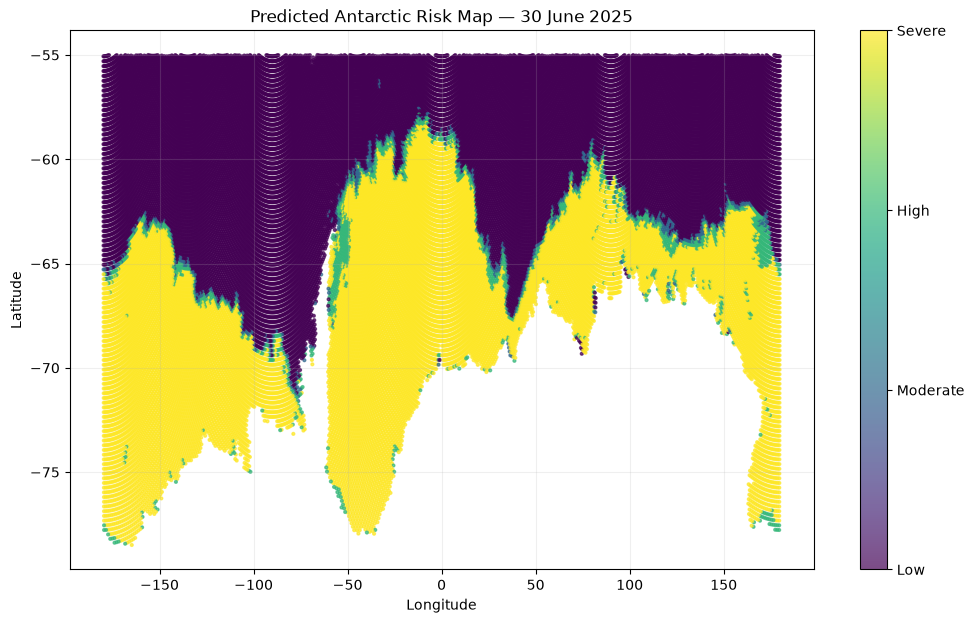

In [252]:
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path

runtime_path = Path("../models/module1_outputs/module1_navigation_runtime.npz")
data = np.load(runtime_path)

risk_code = data["risk_code"]
latitude = data["latitude"]
longitude = data["longitude"]

plt.figure(figsize=(12, 7))

# Plot only valid risk cells
valid = risk_code >= 0

scatter = plt.scatter(
    longitude[valid],
    latitude[valid],
    c=risk_code[valid],
    s=4,
    alpha=0.7
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Predicted Antarctic Risk Map — 30 June 2025")

cbar = plt.colorbar(scatter)
cbar.set_ticks([0, 1, 2, 3])
cbar.set_ticklabels([
    "Low",
    "Moderate",
    "High",
    "Severe"
])

plt.grid(alpha=0.2)
plt.show()

data.close()

In [253]:
from pathlib import Path
import numpy as np
import pandas as pd

runtime_path = Path("../models/module1_outputs/module1_navigation_runtime.npz")
data = np.load(runtime_path)

risk = data["risk_code"]
sic = data["predicted_sic"]
lat = data["latitude"]
lon = data["longitude"]

# Only valid grid cells
valid = risk >= 0

candidates = []

# Scan rows for LOW-risk points separated by higher-risk ice
for y in range(risk.shape[0]):

    valid_x = np.where(valid[y])[0]

    if len(valid_x) < 10:
        continue

    low_x = valid_x[risk[y, valid_x] == 0]

    if len(low_x) < 2:
        continue

    # Try pairs of LOW-risk cells in the same row
    for i in range(len(low_x)):
        x1 = low_x[i]

        # Don't test every possible point; look sufficiently far away
        for x2 in low_x[i + 1::max(1, len(low_x) // 20)]:

            if x2 - x1 < 15:
                continue

            middle = risk[y, x1:x2 + 1]

            high_count = np.sum(middle == 2)
            severe_count = np.sum(middle == 3)
            risky_count = high_count + severe_count

            # We want a meaningful ice barrier
            if risky_count < 10:
                continue

            total = len(middle)
            risky_fraction = risky_count / total

            candidates.append({
                "row": y,
                "x_start": x1,
                "x_goal": x2,
                "start_lat": float(lat[y, x1]),
                "start_lon": float(lon[y, x1]),
                "goal_lat": float(lat[y, x2]),
                "goal_lon": float(lon[y, x2]),
                "start_sic": float(sic[y, x1]),
                "goal_sic": float(sic[y, x2]),
                "high_cells": int(high_count),
                "severe_cells": int(severe_count),
                "risky_fraction": float(risky_fraction),
                "grid_separation": int(x2 - x1)
            })

data.close()

if not candidates:
    print("❌ No suitable challenge corridors found.")
else:
    df = pd.DataFrame(candidates)

    # Prefer corridors with lots of risky ice but still reasonable length
    df["score"] = (
        df["risky_fraction"] * 100
        + np.minimum(df["grid_separation"], 100) * 0.1
    )

    df = df.sort_values("score", ascending=False).head(15)

    print("Top candidate challenge corridors:\n")

    display(
        df[
            [
                "start_lat",
                "start_lon",
                "goal_lat",
                "goal_lon",
                "start_sic",
                "goal_sic",
                "high_cells",
                "severe_cells",
                "risky_fraction",
                "grid_separation"
            ]
        ].reset_index(drop=True)
    )

Top candidate challenge corridors:



,start_lat,start_lon,goal_lat,goal_lon,start_sic,goal_sic,high_cells,severe_cells,risky_fraction,grid_separation
0,-63.071049,-146.643433,-63.197159,147.047028,0.418669,12.634097,6,123,0.984733,130
1,-63.003365,-147.308014,-63.003365,147.308014,0.088520,2.428662,4,124,0.984615,129
2,-59.456406,-35.636547,-63.537479,20.756479,13.258225,8.306740,2,117,0.983471,120
3,-64.226509,-142.477325,-62.762905,138.702209,1.077298,0.578704,5,142,0.980000,149
4,-64.043648,-142.781052,-62.739922,139.372925,0.074855,0.578704,4,142,0.979866,148
5,-63.490299,-143.667389,-63.214664,142.888351,0.070739,1.646825,2,137,0.978873,141
6,-63.439274,-144.348984,-63.030418,143.178131,0.137941,1.693655,9,129,0.978723,140
7,-63.251656,-144.631165,-62.982124,143.849258,0.054823,1.423900,12,125,0.978571,139
8,-63.195217,-145.304840,-62.930058,144.517944,0.135970,1.322023,7,128,0.978261,137
9,-60.067928,-37.000015,-64.045654,23.329552,8.378480,2.036197,6,117,0.976190,125


In [255]:
from pathlib import Path
import inspect
import src.module1_risk as risk_module

print("module1_risk.py location:")
print(Path(risk_module.__file__).resolve())

print("\nFunctions available in module1_risk.py:\n")

for name, obj in inspect.getmembers(risk_module, inspect.isfunction):
    if not name.startswith("_"):
        print(f"  {name}")

print("\n--- Full source ---\n")
print(inspect.getsource(risk_module))

module1_risk.py location:
C:\Users\acer\ElShaddAI\src\module1_risk.py

Functions available in module1_risk.py:

  classify_sic_risk
  risk_labels

--- Full source ---


import numpy as np


# Prototype SIC screening thresholds.
# These are configurable and are NOT vessel-safety limits.
SIC_THRESHOLDS = {
    "low_max": 15.0,
    "moderate_max": 40.0,
    "high_max": 70.0,
}


RISK_LABELS = {
    0: "LOW",
    1: "MODERATE",
    2: "HIGH",
    3: "SEVERE",
}


def classify_sic_risk(sic_values):
    """
    Convert sea-ice concentration (%) to screening risk codes.

    Codes:
        0 = LOW
        1 = MODERATE
        2 = HIGH
        3 = SEVERE
       -1 = invalid / missing
    """

    sic_values = np.asarray(sic_values, dtype="float32")

    risk = np.full(
        sic_values.shape,
        -1,
        dtype=np.int8
    )

    valid = (
        np.isfinite(sic_values)
        & (sic_values >= 0)
        & (sic_values <= 100)
    )

    risk[
        valid & (sic_values < SIC_THRESH

In [258]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd

# Project root
project_root = Path("..").resolve()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.module1_forecast import forecast_sic
from src.module1_risk import classify_sic_risk
from src.vessel_profiles import create_vessel_cost_surface
from src.module1_route import plan_route

# --------------------------------------------------
# Challenge corridor
# --------------------------------------------------

forecast_date = "2025-06-29 12:00:00"

start_lat = -59.121376
start_lon = -31.180239

goal_lat = -62.172924
goal_lon = 18.729527

profiles = [
    "conservative",
    "standard",
    "ice_capable"
]

print("Challenge corridor:")
print(f"  Start:       ({start_lat:.4f}, {start_lon:.4f})")
print(f"  Destination: ({goal_lat:.4f}, {goal_lon:.4f})")
print()

# --------------------------------------------------
# Generate forecast
# --------------------------------------------------

forecast_result = forecast_sic(forecast_date)

predicted_grid = forecast_result["predicted_sic"]

print("Prediction generated successfully.")
print(f"  Forecast date:  {forecast_result['forecast_date'].date()}")
print(f"  Prediction date: {forecast_result['prediction_date'].date()}")
print()

# --------------------------------------------------
# Convert prediction to risk
# --------------------------------------------------

risk_grid = classify_sic_risk(predicted_grid)

# --------------------------------------------------
# Load spatial coordinates
# --------------------------------------------------

runtime_path = Path(
    "../models/module1_outputs/module1_navigation_runtime.npz"
)

runtime = np.load(runtime_path)

latitude = runtime["latitude"]
longitude = runtime["longitude"]

runtime.close()

# --------------------------------------------------
# Test each vessel profile
# --------------------------------------------------

results = []

for profile in profiles:

    print(f"Testing: {profile}")

    cost_surface = create_vessel_cost_surface(
        risk_grid,
        vessel_profile=profile
    )

    try:

        result = plan_route(
            cost_surface=cost_surface,
            latitude=latitude,
            longitude=longitude,
            start_lat=start_lat,
            start_lon=start_lon,
            goal_lat=goal_lat,
            goal_lon=goal_lon
        )

        risk_percentages = result.get(
            "risk_percentages",
            {}
        )

        results.append({
            "vessel": profile,
            "status": "SUCCESS",
            "distance_km": result.get("distance_km"),
            "straight_km": result.get(
                "straight_line_distance_km"
            ),
            "detour": result.get(
                "detour_ratio"
            ),
            "extra_km": result.get(
                "extra_distance_km"
            ),
            "mean_sic": result.get(
                "mean_sic"
            ),
            "max_sic": result.get(
                "max_sic"
            ),
            "low_pct": risk_percentages.get(
                "LOW", 0
            ),
            "moderate_pct": risk_percentages.get(
                "MODERATE", 0
            ),
            "high_pct": risk_percentages.get(
                "HIGH", 0
            ),
            "severe_pct": risk_percentages.get(
                "SEVERE", 0
            ),
            "cost": result.get(
                "total_cost"
            )
        })

    except Exception as e:

        results.append({
            "vessel": profile,
            "status": f"ERROR: {e}"
        })

comparison = pd.DataFrame(results)

print("\n========== VESSEL COMPARISON ==========\n")

display(comparison)

Challenge corridor:
  Start:       (-59.1214, -31.1802)
  Destination: (-62.1729, 18.7295)

Prediction generated successfully.
  Forecast date:  2025-06-29
  Prediction date: 2025-06-30

Testing: conservative
Testing: standard
Testing: ice_capable

========== VESSEL COMPARISON ==========



,vessel,status
0,conservative,ERROR: plan_route() got an unexpected keyword ...
1,standard,ERROR: plan_route() got an unexpected keyword ...
2,ice_capable,ERROR: plan_route() got an unexpected keyword ...


In [262]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd

# --------------------------------------------------
# Imports
# --------------------------------------------------

project_root = Path("..").resolve()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.module1_forecast import forecast_sic
from src.module1_risk import classify_sic_risk
from src.vessel_profiles import create_vessel_cost_surface
from src.module1_route import plan_route


# --------------------------------------------------
# Challenge corridor
# --------------------------------------------------

forecast_date = "2025-06-29 12:00:00"

start_lat = -59.121376
start_lon = -31.180239

goal_lat = -62.172924
goal_lon = 18.729527


# --------------------------------------------------
# Generate forecast
# --------------------------------------------------

forecast = forecast_sic(forecast_date)

predicted_sic = forecast["predicted_sic"]
latitude = forecast["latitude"]
longitude = forecast["longitude"]
yc = forecast["yc"]
xc = forecast["xc"]

print("Prediction generated successfully.")
print(f"Forecast date   : {forecast['forecast_date'].date()}")
print(f"Prediction date : {forecast['prediction_date'].date()}")
print()


# --------------------------------------------------
# Classify risk
# --------------------------------------------------

risk_code = classify_sic_risk(predicted_sic)


# --------------------------------------------------
# Build spatial output expected by plan_route()
# --------------------------------------------------

spatial_output = {
    "predicted_sic": predicted_sic,
    "risk_code": risk_code,
    "latitude": latitude,
    "longitude": longitude,
    "yc": yc,
    "xc": xc,
}


print("Spatial output ready.")
print(f"Grid shape: {predicted_sic.shape}")
print()


# --------------------------------------------------
# Test vessel profiles
# --------------------------------------------------

profiles = [
    "conservative",
    "standard",
    "ice_capable"
]

results = []

for profile in profiles:

    print(f"Testing: {profile}")

    # Vessel-specific cost surface
    navigation_cost = create_vessel_cost_surface(
        risk_code,
        vessel_profile=profile
    )

    try:

        result = plan_route(
            start_lat=start_lat,
            start_lon=start_lon,
            goal_lat=goal_lat,
            goal_lon=goal_lon,
            navigation_cost=navigation_cost,
            spatial_output=spatial_output
        )

        # ------------------------------------------
        # Extract route statistics
        # ------------------------------------------

        risk_percentages = result.get(
            "risk_percentages",
            {}
        )

        results.append({
            "vessel": profile,
            "status": "SUCCESS",

            "distance_km": result.get(
                "distance_km"
            ),

            "straight_km": result.get(
                "straight_line_distance_km"
            ),

            "detour": result.get(
                "detour_ratio"
            ),

            "extra_km": result.get(
                "extra_distance_km"
            ),

            "mean_sic": result.get(
                "mean_sic"
            ),

            "max_sic": result.get(
                "max_sic"
            ),

            "low_pct": risk_percentages.get(
                "LOW", 0
            ),

            "moderate_pct": risk_percentages.get(
                "MODERATE", 0
            ),

            "high_pct": risk_percentages.get(
                "HIGH", 0
            ),

            "severe_pct": risk_percentages.get(
                "SEVERE", 0
            ),

            "cost": result.get(
                "total_cost"
            ),

            "route_cells": len(
                result.get("coordinates", [])
            )
        })

    except Exception as e:

        results.append({
            "vessel": profile,
            "status": f"ERROR: {e}"
        })


# --------------------------------------------------
# Display comparison
# --------------------------------------------------

comparison = pd.DataFrame(results)

print()
print("========== VESSEL COMPARISON ==========")
print()

display(comparison)

Prediction generated successfully.
Forecast date   : 2025-06-29
Prediction date : 2025-06-30

Spatial output ready.
Grid shape: (432, 432)

Testing: conservative
Testing: standard
Testing: ice_capable

========== VESSEL COMPARISON ==========



,vessel,status,distance_km,straight_km,detour,extra_km,mean_sic,max_sic,low_pct,moderate_pct,high_pct,severe_pct,cost,route_cells
0,conservative,SUCCESS,None,None,None,None,None,None,0,0,0,0,None,120
1,standard,SUCCESS,None,None,None,None,None,None,0,0,0,0,None,120
2,ice_capable,SUCCESS,None,None,None,None,None,None,0,0,0,0,None,120


In [263]:
# Show the exact keys and values returned by plan_route()
sample_profile = "standard"

navigation_cost = create_vessel_cost_surface(
    risk_code,
    vessel_profile=sample_profile
)

sample_result = plan_route(
    start_lat=start_lat,
    start_lon=start_lon,
    goal_lat=goal_lat,
    goal_lon=goal_lon,
    navigation_cost=navigation_cost,
    spatial_output=spatial_output
)

print("Keys returned by plan_route():\n")
for key, value in sample_result.items():

    if isinstance(value, (dict, list, tuple)):
        print(f"{key}: {type(value).__name__} "
              f"(length={len(value)})")
    else:
        print(f"{key}: {value}")

Keys returned by plan_route():

status: success
start: dict (length=2)
destination: dict (length=2)
route: dict (length=6)
ice_exposure: dict (length=3)
coordinates: list (length=120)
geometry: dict (length=2)
requested_start: dict (length=2)
requested_destination: dict (length=2)
grid_start: dict (length=2)
grid_goal: dict (length=2)


In [264]:
print("ROUTE:")
for key, value in sample_result["route"].items():
    print(f"  {key}: {value}")

print("\nICE EXPOSURE:")
for key, value in sample_result["ice_exposure"].items():
    print(f"  {key}: {value}")

ROUTE:
  grid_cells: 120
  distance_km: 3420.28
  straight_line_distance_km: 2750.0
  detour_factor: 1.244
  extra_distance_km: 670.28
  total_navigation_cost: 136.81

ICE EXPOSURE:
  mean_predicted_sic_percent: 1.07
  max_predicted_sic_percent: 12.06
  risk_exposure: {'LOW': {'cells': 120, 'percentage': 100.0}, 'MODERATE': {'cells': 0, 'percentage': 0.0}, 'HIGH': {'cells': 0, 'percentage': 0.0}, 'SEVERE': {'cells': 0, 'percentage': 0.0}}


In [265]:
# Re-use:
# forecast, predicted_sic, latitude, longitude, yc, xc,
# risk_code, spatial_output, start_lat, start_lon,
# goal_lat, goal_lon, profiles

results = []

for profile in profiles:

    navigation_cost = create_vessel_cost_surface(
        risk_code,
        vessel_profile=profile
    )

    result = plan_route(
        start_lat=start_lat,
        start_lon=start_lon,
        goal_lat=goal_lat,
        goal_lon=goal_lon,
        navigation_cost=navigation_cost,
        spatial_output=spatial_output
    )

    route = result["route"]
    exposure = result["ice_exposure"]
    risk_exposure = exposure["risk_exposure"]

    results.append({
        "Vessel": profile,
        "Distance (km)": route["distance_km"],
        "Straight (km)": route["straight_line_distance_km"],
        "Detour": route["detour_factor"],
        "Extra (km)": route["extra_distance_km"],
        "Mean SIC (%)": exposure["mean_predicted_sic_percent"],
        "Max SIC (%)": exposure["max_predicted_sic_percent"],
        "LOW (%)": risk_exposure["LOW"]["percentage"],
        "MODERATE (%)": risk_exposure["MODERATE"]["percentage"],
        "HIGH (%)": risk_exposure["HIGH"]["percentage"],
        "SEVERE (%)": risk_exposure["SEVERE"]["percentage"],
        "Navigation Cost": route["total_navigation_cost"],
        "Route Cells": route["grid_cells"]
    })

comparison = pd.DataFrame(results)

display(comparison)

,Vessel,Distance (km),Straight (km),Detour,Extra (km),Mean SIC (%),Max SIC (%),LOW (%),MODERATE (%),HIGH (%),SEVERE (%),Navigation Cost,Route Cells
0,conservative,3420.28,2750.0,1.244,670.28,1.07,12.06,100.0,0.0,0.0,0.0,136.81,120
1,standard,3420.28,2750.0,1.244,670.28,1.07,12.06,100.0,0.0,0.0,0.0,136.81,120
2,ice_capable,3420.28,2750.0,1.244,670.28,1.07,12.06,100.0,0.0,0.0,0.0,136.81,120


In [267]:
import numpy as np
import pandas as pd

# --------------------------------------------------
# Reuse existing Module 1 objects
# --------------------------------------------------
# risk_code
# predicted_sic
# latitude
# longitude
# spatial_output
# create_vessel_cost_surface
# plan_route

rng = np.random.default_rng(42)

# --------------------------------------------------
# 1. Get LOW-risk cells
# --------------------------------------------------

low_cells = np.argwhere(risk_code == 0)

print(f"LOW-risk cells available: {len(low_cells):,}")

# Sample a small number of endpoint candidates
sample_size = min(30, len(low_cells))

chosen = low_cells[
    rng.choice(len(low_cells), sample_size, replace=False)
]

# --------------------------------------------------
# Helper:
# Estimate risk along straight geographic line
# --------------------------------------------------

def nearest_grid_cell(test_lat, test_lon):
    """
    Find nearest grid cell using squared geographic distance.
    Used only for candidate screening.
    """
    d = (
        (latitude - test_lat) ** 2
        + (longitude - test_lon) ** 2
    )

    d[risk_code < 0] = np.inf

    idx = np.unravel_index(
        np.argmin(d),
        d.shape
    )

    return idx


def straight_line_risk_fraction(
    lat1, lon1, lat2, lon2,
    samples=40
):
    """
    Approximate the fraction of points along the
    straight geographic connection that fall into
    HIGH or SEVERE risk.
    """

    lats = np.linspace(lat1, lat2, samples)
    lons = np.linspace(lon1, lon2, samples)

    risky = 0
    valid = 0

    for la, lo in zip(lats, lons):

        y, x = nearest_grid_cell(la, lo)

        r = int(risk_code[y, x])

        if r >= 0:
            valid += 1

            if r >= 2:
                risky += 1

    if valid == 0:
        return 0.0

    return risky / valid


# --------------------------------------------------
# 2. Find promising challenge corridors
# --------------------------------------------------

candidate_pairs = []

for i in range(len(chosen)):

    y1, x1 = chosen[i]

    lat1 = float(latitude[y1, x1])
    lon1 = float(longitude[y1, x1])

    for j in range(i + 1, len(chosen)):

        y2, x2 = chosen[j]

        lat2 = float(latitude[y2, x2])
        lon2 = float(longitude[y2, x2])

        # Avoid awkward dateline-crossing examples
        if abs(lon1 - lon2) > 140:
            continue

        grid_sep = np.sqrt(
            (y2 - y1) ** 2 +
            (x2 - x1) ** 2
        )

        # Require reasonably separated endpoints
        if grid_sep < 70:
            continue

        risky_fraction = straight_line_risk_fraction(
            lat1, lon1,
            lat2, lon2
        )

        # We specifically want straight paths
        # that encounter substantial HIGH/SEVERE ice
        if risky_fraction < 0.30:
            continue

        candidate_pairs.append({
            "start_lat": lat1,
            "start_lon": lon1,
            "goal_lat": lat2,
            "goal_lon": lon2,
            "straight_risky_fraction": risky_fraction,
            "grid_separation": grid_sep
        })


# --------------------------------------------------
# 3. Keep only the best few
# --------------------------------------------------

if not candidate_pairs:

    print("\n❌ No suitable challenge corridors found.")
    print("We will expand the candidate search next.")

else:

    candidates = pd.DataFrame(candidate_pairs)

    candidates = (
        candidates
        .sort_values(
            ["straight_risky_fraction", "grid_separation"],
            ascending=[False, False]
        )
        .head(6)
        .reset_index(drop=True)
    )

    print("\nCandidate challenge corridors:")
    display(candidates)

    # ------------------------------------------------
    # 4. Run A* only on these few candidates
    # ------------------------------------------------

    profiles = [
        "conservative",
        "standard",
        "ice_capable"
    ]

    cost_surfaces = {
        p: create_vessel_cost_surface(
            risk_code,
            vessel_profile=p
        )
        for p in profiles
    }

    route_results = []

    for idx, candidate in candidates.iterrows():

        print(
            f"\nTesting corridor {idx + 1}/{len(candidates)}"
        )

        for profile in profiles:

            try:

                result = plan_route(
                    start_lat=candidate["start_lat"],
                    start_lon=candidate["start_lon"],
                    goal_lat=candidate["goal_lat"],
                    goal_lon=candidate["goal_lon"],
                    navigation_cost=cost_surfaces[profile],
                    spatial_output=spatial_output
                )

                route = result["route"]
                exposure = result["ice_exposure"]

                route_results.append({
                    "corridor": idx + 1,
                    "vessel": profile,
                    "distance_km": route["distance_km"],
                    "detour": route["detour_factor"],
                    "mean_sic": exposure[
                        "mean_predicted_sic_percent"
                    ],
                    "max_sic": exposure[
                        "max_predicted_sic_percent"
                    ],
                    "high_pct": exposure[
                        "risk_exposure"
                    ]["HIGH"]["percentage"],
                    "severe_pct": exposure[
                        "risk_exposure"
                    ]["SEVERE"]["percentage"],
                    "cost": route[
                        "total_navigation_cost"
                    ],
                    "route_cells": route[
                        "grid_cells"
                    ]
                })

            except Exception as e:

                route_results.append({
                    "corridor": idx + 1,
                    "vessel": profile,
                    "error": str(e)
                })

    comparison = pd.DataFrame(route_results)

    print("\n========== ROUTE COMPARISON ==========\n")
    display(comparison)

LOW-risk cells available: 30,014

Candidate challenge corridors:


,start_lat,start_lon,goal_lat,goal_lon,straight_risky_fraction,grid_separation
0,-56.996109,31.775450,-66.409424,-87.534241,0.550,216.614866
1,-57.057400,39.122608,-66.409424,-87.534241,0.525,223.785612
2,-56.991272,48.906815,-66.409424,-87.534241,0.500,232.544619
3,-63.863968,-86.778961,-56.991272,48.906815,0.475,241.962807
4,-63.863968,-86.778961,-57.057400,39.122608,0.425,232.561820
5,-63.863968,-86.778961,-56.996109,31.775450,0.425,224.839943



Testing corridor 1/6

Testing corridor 2/6

Testing corridor 3/6

Testing corridor 4/6

Testing corridor 5/6

Testing corridor 6/6

========== ROUTE COMPARISON ==========



,corridor,vessel,distance_km,detour,mean_sic,max_sic,high_pct,severe_pct,cost,route_cells
0,1,conservative,7345.58,1.356,0.88,12.06,0.0,0.0,293.82,265
1,1,standard,7345.58,1.356,0.88,12.06,0.0,0.0,293.82,265
2,1,ice_capable,7345.58,1.356,0.88,12.06,0.0,0.0,293.82,265
3,2,conservative,7834.49,1.400,0.83,12.06,0.0,0.0,313.38,280
4,2,standard,7834.49,1.400,0.83,12.06,0.0,0.0,313.38,280
5,2,ice_capable,7834.49,1.400,0.83,12.06,0.0,0.0,313.38,280
6,3,conservative,8460.53,1.455,0.75,12.06,0.0,0.0,338.42,298
7,3,standard,8460.53,1.455,0.75,12.06,0.0,0.0,338.42,298
8,3,ice_capable,8460.53,1.455,0.75,12.06,0.0,0.0,338.42,298
9,4,conservative,8524.44,1.409,0.57,12.06,0.0,0.0,340.98,296


In [268]:
import numpy as np
import pandas as pd

from scipy.ndimage import label
from scipy.spatial import cKDTree


# ============================================================
# 1. Identify connected LOW-risk regions
# ============================================================

low_mask = (risk_code == 0)

# 8-connected neighborhood
structure = np.ones((3, 3), dtype=np.int8)

components, n_components = label(
    low_mask,
    structure=structure
)

component_sizes = np.bincount(
    components.ravel()
)

# Ignore background component 0
valid_components = np.where(
    component_sizes >= 20
)[0]

valid_components = valid_components[
    valid_components != 0
]

print(
    f"Connected LOW-risk regions with >=20 cells: "
    f"{len(valid_components)}"
)


# ============================================================
# 2. Sample LOW-risk cells from those regions
# ============================================================

low_positions = np.argwhere(
    low_mask & np.isin(components, valid_components)
)

rng = np.random.default_rng(42)

sample_size = min(150, len(low_positions))

sample_positions = low_positions[
    rng.choice(
        len(low_positions),
        size=sample_size,
        replace=False
    )
]


# ============================================================
# 3. Fast geographic nearest-cell lookup
# ============================================================

valid_positions = np.argwhere(risk_code >= 0)

valid_lat = latitude[
    risk_code >= 0
].astype(float)

valid_lon = longitude[
    risk_code >= 0
].astype(float)

tree = cKDTree(
    np.column_stack([
        valid_lat,
        valid_lon
    ])
)


def nearest_grid_cell(lat_value, lon_value):
    _, idx = tree.query(
        [lat_value, lon_value]
    )
    return tuple(valid_positions[idx])


# ============================================================
# 4. Estimate straight-line risky fraction
# ============================================================

def straight_line_risk_fraction(
    lat1,
    lon1,
    lat2,
    lon2,
    samples=30
):

    test_lats = np.linspace(
        lat1,
        lat2,
        samples
    )

    test_lons = np.linspace(
        lon1,
        lon2,
        samples
    )

    risky = 0
    valid = 0

    for test_lat, test_lon in zip(
        test_lats,
        test_lons
    ):

        y, x = nearest_grid_cell(
            test_lat,
            test_lon
        )

        r = int(risk_code[y, x])

        if r >= 0:

            valid += 1

            if r >= 2:
                risky += 1

    if valid == 0:
        return 0.0

    return risky / valid


# ============================================================
# 5. Find endpoints from different LOW-risk components
# ============================================================

candidate_pairs = []

for i in range(len(sample_positions)):

    y1, x1 = sample_positions[i]

    component_1 = components[y1, x1]

    lat1 = float(latitude[y1, x1])
    lon1 = float(longitude[y1, x1])

    for j in range(i + 1, len(sample_positions)):

        y2, x2 = sample_positions[j]

        component_2 = components[y2, x2]

        # Must be separated LOW-risk regions
        if component_1 == component_2:
            continue

        # Avoid awkward dateline examples
        lon_difference = abs(lon1 - float(longitude[y2, x2]))

        if lon_difference > 140:
            continue

        grid_separation = np.sqrt(
            (y2 - y1) ** 2 +
            (x2 - x1) ** 2
        )

        if grid_separation < 30:
            continue

        if grid_separation > 220:
            continue

        lat2 = float(latitude[y2, x2])
        lon2 = float(longitude[y2, x2])

        risky_fraction = straight_line_risk_fraction(
            lat1,
            lon1,
            lat2,
            lon2
        )

        # We want a genuine ice barrier
        if risky_fraction < 0.20:
            continue

        candidate_pairs.append({
            "start_lat": lat1,
            "start_lon": lon1,
            "goal_lat": lat2,
            "goal_lon": lon2,
            "component_start": int(component_1),
            "component_goal": int(component_2),
            "straight_risky_fraction": risky_fraction,
            "grid_separation": grid_separation
        })


# ============================================================
# 6. Display best candidates
# ============================================================

if not candidate_pairs:

    print("\n❌ No suitable barrier corridors found.")

else:

    candidates = pd.DataFrame(
        candidate_pairs
    )

    candidates = (
        candidates
        .sort_values(
            [
                "straight_risky_fraction",
                "grid_separation"
            ],
            ascending=[False, False]
        )
        .head(8)
        .reset_index(drop=True)
    )

    print("\nPotential ice-barrier corridors:\n")

    display(candidates)

Connected LOW-risk regions with >=20 cells: 1

❌ No suitable barrier corridors found.


In [269]:
from pathlib import Path
import os
import re

# --------------------------------------------------
# Locate our SIC data
# --------------------------------------------------

base = Path("../data/raw").resolve()

print("Raw data directory:")
print(base)
print()

if not base.exists():
    print("❌ Raw data directory does not exist.")
else:

    # Find files/folders related to SIC
    sic_items = []

    for p in base.rglob("*"):
        name = p.name.lower()

        if (
            "sic" in name
            or "sea_ice" in name
            or "sea-ice" in name
        ):
            sic_items.append(p)

    print(f"SIC-related items found: {len(sic_items)}")
    print()

    for p in sic_items[:100]:

        if p.is_file():
            size_mb = p.stat().st_size / (1024 ** 2)
            print(
                f"FILE   {p.relative_to(base)}"
                f"   {size_mb:.2f} MB"
            )

        elif p.is_dir():
            print(
                f"DIR    {p.relative_to(base)}"
            )

Raw data directory:
C:\Users\acer\ElShaddAI\data\raw

SIC-related items found: 4

DIR    sic_30days
DIR    sic_d0
FILE   sic_30days\sic_2025-06-01_to_2025-06-30.zip   31.72 MB
FILE   sic_d0\sic_2025-06-01_to_2025-06-05.nc   5.27 MB


In [277]:
# import cdsapi
# from pathlib import Path

# # ============================================
# # JANUARY 2021 ANTARCTIC SIC
# # Same request structure that successfully
# # downloaded June 2025
# # ============================================

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2021-01_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     # January 2021
#     "year": ["2021"],
#     "month": ["01"],

#     # IMPORTANT: include all days,
#     # exactly as in the working June request
#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting January 2021 SIC download...")
# print("Sensor       : AMSR")
# print("Region       : Southern Hemisphere")
# print("Product      : ICDR")
# print("Version      : 3_0")
# print("Aggregation  : Daily")
# print("Period       : January 2021")
# print()
# print("Output:")
# print(target_file.resolve())
# print()

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")

# size_mb = target_file.stat().st_size / (1024 ** 2)

# print("File:", target_file.resolve())
# print("Size:", round(size_mb, 2), "MB")

Starting January 2021 SIC download...
Sensor       : AMSR
Region       : Southern Hemisphere
Product      : ICDR
Version      : 3_0
Aggregation  : Daily
Period       : January 2021

Output:
C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2021-01_amsr.zip



2026-09-03 19:28:19,867 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 19:28:19,871 INFO Request ID is f4ef15a4-e77c-4e9a-a4ce-9a3307bc163a
2026-09-03 19:28:20,567 INFO status has been updated to accepted
2026-09-03 19:28:30,277 INFO status has been updated to running
2026-09-03 19:29:12,746 INFO status has been updated to successful
                                                                                          


✅ Download completed.
File: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2021-01_amsr.zip
Size: 31.54 MB


In [278]:
from pathlib import Path
import zipfile

zip_file = Path("../data/raw/sic_historical/sic_2021-01_amsr.zip")
extract_dir = Path("../data/raw/sic_historical/january_2021")

extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_file, "r") as z:
    names = z.namelist()

print("Files inside ZIP:", len(names))
print()

for name in names[:20]:
    print(name)

Files inside ZIP: 31

ice_conc_sh_ease2-250_icdr-v3p0-amsr_202101011200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202101021200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202101031200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202101041200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202101051200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202101061200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202101071200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202101081200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202101091200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202101101200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202101111200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202101121200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202101131200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202101141200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202101151200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202101161200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202101171200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202101181200.nc
ice_conc_sh_ease2-250_ic

In [279]:
import xarray as xr
from pathlib import Path

jan_dir = Path("../data/raw/sic_historical/january_2021")

# Extract the ZIP
import zipfile

zip_file = Path("../data/raw/sic_historical/sic_2021-01_amsr.zip")

with zipfile.ZipFile(zip_file, "r") as z:
    z.extractall(jan_dir)

# Open the first day
jan_file = sorted(jan_dir.glob("*.nc"))[0]

print("File:", jan_file.name)

ds_jan = xr.open_dataset(jan_file)

print("\nDimensions:")
print(ds_jan.dims)

print("\nCoordinates:")
print(list(ds_jan.coords))

print("\nVariables:")
print(list(ds_jan.data_vars))

print("\nSea-ice concentration:")
print(ds_jan["ice_conc"])

File: ice_conc_sh_ease2-250_icdr-v3p0-amsr_202101011200.nc

Dimensions:
FrozenMappingWarningOnValuesAccess({'time': 1, 'nv': 2, 'yc': 432, 'xc': 432})

Coordinates:
['time', 'xc', 'yc', 'lat', 'lon']

Variables:
['Lambert_Azimuthal_Grid', 'time_bnds', 'ice_conc', 'raw_ice_conc_values', 'total_standard_uncertainty', 'smearing_standard_uncertainty', 'algorithm_standard_uncertainty', 'status_flag']

Sea-ice concentration:
<xarray.DataArray 'ice_conc' (time: 1, yc: 432, xc: 432)> Size: 1MB
[186624 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 8B 2021-01-01T12:00:00
  * yc       (yc) float64 3kB 5.388e+03 5.362e+03 ... -5.362e+03 -5.388e+03
  * xc       (xc) float64 3kB -5.388e+03 -5.362e+03 ... 5.362e+03 5.388e+03
    lat      (yc, xc) float32 746kB ...
    lon      (yc, xc) float32 746kB ...
Attributes:
    long_name:            fully filtered concentration of sea ice using atmos...
    standard_name:        sea_ice_area_fraction
    units:                %
  

In [280]:
import numpy as np

# January 2021 grid
jan_lat = ds_jan["lat"].values
jan_lon = ds_jan["lon"].values

# Existing June 2025 grid
jun_lat = sic_30_ds["lat"].values
jun_lon = sic_30_ds["lon"].values

print("January grid shape :", jan_lat.shape)
print("June grid shape    :", jun_lat.shape)

print("\nLatitude grids identical:",
      np.allclose(jan_lat, jun_lat, equal_nan=True))

print("Longitude grids identical:",
      np.allclose(jan_lon, jun_lon, equal_nan=True))

print("\nMaximum latitude difference:",
      np.nanmax(np.abs(jan_lat - jun_lat)))

print("Maximum longitude difference:",
      np.nanmax(np.abs(jan_lon - jun_lon)))

January grid shape : (432, 432)
June grid shape    : (432, 432)

Latitude grids identical: True
Longitude grids identical: True

Maximum latitude difference: 0.0
Maximum longitude difference: 0.0


In [281]:
import numpy as np

sic_jan = ds_jan["ice_conc"]

values = sic_jan.values[0]

print("January 1, 2021 SIC statistics")
print("--------------------------------")

valid = values[np.isfinite(values)]

print("Total grid cells :", values.size)
print("Valid cells      :", valid.size)
print("Missing cells    :", np.isnan(values).sum())

print("\nMin SIC           :", np.nanmin(values))
print("Max SIC           :", np.nanmax(values))
print("Mean SIC          :", np.nanmean(values))
print("Median SIC        :", np.nanmedian(values))

print("\nData type         :", values.dtype)
print("Units             :", sic_jan.attrs.get("units"))
print("Valid min         :", sic_jan.attrs.get("valid_min"))
print("Valid max         :", sic_jan.attrs.get("valid_max"))

January 1, 2021 SIC statistics
--------------------------------
Total grid cells : 186624
Valid cells      : 153319
Missing cells    : 33305

Min SIC           : 0.0
Max SIC           : 100.0
Mean SIC          : 4.5846326287022485
Median SIC        : 0.0

Data type         : float64
Units             : %
Valid min         : 0
Valid max         : 10000


In [282]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2021-02_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2021"],
#     "month": ["02"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28"
#     ],

#     "version": "3_0"
# }

# print("Starting February 2021 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting February 2021 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2021-02_amsr.zip


2026-09-03 19:35:35,841 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 19:35:35,843 INFO Request ID is 2741decc-ff74-4ec9-a02d-4e664b7cb381
2026-09-03 19:35:36,212 INFO status has been updated to accepted
2026-09-03 19:35:51,240 INFO status has been updated to running
2026-09-03 19:36:28,508 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 27.8 MB


In [283]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2021-03_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2021"],
#     "month": ["03"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30", "31"
#     ],

#     "version": "3_0"
# }

# print("Starting March 2021 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting March 2021 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2021-03_amsr.zip


2026-09-03 20:10:59,477 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 20:10:59,479 INFO Request ID is fac91307-4d9c-45df-82a2-710b0981a3fe
2026-09-03 20:10:59,758 INFO status has been updated to accepted
2026-09-03 20:11:53,548 INFO status has been updated to running
2026-09-03 20:12:19,541 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 30.29 MB


In [284]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2021-04_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2021"],
#     "month": ["04"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30"
#     ],

#     "version": "3_0"
# }

# print("Starting April 2021 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting April 2021 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2021-04_amsr.zip


2026-09-03 20:13:23,381 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 20:13:23,384 INFO Request ID is dc8dc2fe-a78e-4fcc-a15e-5aaf31d6a98f
2026-09-03 20:13:23,778 INFO status has been updated to accepted
2026-09-03 20:13:39,461 INFO status has been updated to running
2026-09-03 20:14:16,448 INFO status has been updated to accepted
2026-09-03 20:15:22,896 INFO status has been updated to running
2026-09-03 20:16:21,981 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 29.97 MB


In [285]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2021-05_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2021"],
#     "month": ["05"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting May 2021 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting May 2021 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2021-05_amsr.zip


2026-09-03 20:26:12,848 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 20:26:12,851 INFO Request ID is af07dfe8-e06e-49c9-9055-5fd8124aa7ee
2026-09-03 20:26:13,405 INFO status has been updated to accepted
2026-09-03 20:26:28,575 INFO status has been updated to running
2026-09-03 20:27:05,783 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 32.1 MB


In [286]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2021-06_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2021"],
#     "month": ["06"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30"
#     ],

#     "version": "3_0"
# }

# print("Starting June 2021 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting June 2021 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2021-06_amsr.zip


2026-09-03 20:29:18,010 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 20:29:18,011 INFO Request ID is 37107c8a-fba9-4fda-972f-ee8df98d7f6a
2026-09-03 20:29:18,291 INFO status has been updated to accepted
Recovering from connection error [('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))], attempt 1 of 500
Retrying in 120 seconds
2026-09-03 20:32:04,562 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 31.91 MB


In [287]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2021-07_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2021"],
#     "month": ["07"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting July 2021 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting July 2021 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2021-07_amsr.zip


2026-09-03 20:34:01,039 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 20:34:01,041 INFO Request ID is b7d256b9-4b1a-489a-959a-2b57ef9f1d6a
2026-09-03 20:34:01,360 INFO status has been updated to accepted
2026-09-03 20:34:25,356 INFO status has been updated to running
2026-09-03 20:34:37,037 INFO status has been updated to accepted
2026-09-03 20:34:54,630 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 33.57 MB


In [288]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2021-08_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2021"],
#     "month": ["08"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting August 2021 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting August 2021 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2021-08_amsr.zip


2026-09-03 20:36:07,434 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 20:36:07,436 INFO Request ID is 4180dfe5-2329-4cbe-91be-9719b9694258
2026-09-03 20:36:10,328 INFO status has been updated to accepted
2026-09-03 20:37:03,273 INFO status has been updated to running
2026-09-03 20:37:29,245 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 34.18 MB


In [289]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2021-09_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2021"],
#     "month": ["09"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30"
#     ],

#     "version": "3_0"
# }

# print("Starting September 2021 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting September 2021 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2021-09_amsr.zip


2026-09-03 20:38:47,986 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 20:38:47,988 INFO Request ID is 56a5a7d3-7a56-4d0b-9ec2-476f5d1ef39e
2026-09-03 20:38:48,248 INFO status has been updated to accepted
2026-09-03 20:39:03,628 INFO status has been updated to running
2026-09-03 20:39:40,569 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 33.36 MB


In [290]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2021-10_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2021"],
#     "month": ["10"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting October 2021 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting October 2021 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2021-10_amsr.zip


2026-09-03 20:40:04,601 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 20:40:04,603 INFO Request ID is 8d847bca-8cda-406e-adef-f1af4e492f55
2026-09-03 20:40:04,882 INFO status has been updated to accepted
2026-09-03 20:40:17,251 INFO status has been updated to running
2026-09-03 20:40:59,749 INFO status has been updated to successful
                                                                                         


✅ Download completed.
Size: 34.36 MB


In [292]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2021-11_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2021"],
#     "month": ["11"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30"
#     ],

#     "version": "3_0"
# }

# print("Starting November 2021 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting November 2021 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2021-11_amsr.zip


2026-09-03 20:42:16,405 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 20:42:16,407 INFO Request ID is d986fc59-ec51-463c-8810-9523009f16db
2026-09-03 20:42:16,716 INFO status has been updated to accepted
2026-09-03 20:42:31,675 INFO status has been updated to running
2026-09-03 20:42:39,600 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 32.9 MB


In [293]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2021-12_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2021"],
#     "month": ["12"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting December 2021 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting December 2021 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2021-12_amsr.zip


2026-09-03 20:43:07,234 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 20:43:07,237 INFO Request ID is 8bb149db-bacb-4be8-b9db-a12eead32f0f
2026-09-03 20:43:07,523 INFO status has been updated to accepted
2026-09-03 20:43:22,524 INFO status has been updated to running
2026-09-03 20:44:00,386 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 32.87 MB


In [294]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2022-01_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2022"],
#     "month": ["01"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting January 2022 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting January 2022 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2022-01_amsr.zip


2026-09-03 20:44:35,883 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 20:44:35,885 INFO Request ID is 2f0085f2-90d0-4cab-ab9b-72d9ef33f3c8
2026-09-03 20:44:36,243 INFO status has been updated to accepted
2026-09-03 20:44:51,115 INFO status has been updated to running
2026-09-03 20:45:30,148 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 31.37 MB


In [295]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2022-02_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2022"],
#     "month": ["02"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28"
#     ],

#     "version": "3_0"
# }

# print("Starting February 2022 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting February 2022 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2022-02_amsr.zip


2026-09-03 20:45:48,393 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 20:45:48,395 INFO Request ID is cf712b59-3b2c-4e09-9288-b55bfe1dbcb3
2026-09-03 20:45:48,703 INFO status has been updated to accepted
2026-09-03 20:46:11,069 INFO status has been updated to running
2026-09-03 20:47:06,422 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 27.48 MB


In [296]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2022-03_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2022"],
#     "month": ["03"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting March 2022 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting March 2022 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2022-03_amsr.zip


2026-09-03 20:47:24,221 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 20:47:24,224 INFO Request ID is d2235972-9464-44e7-b441-48b25ad9e684
2026-09-03 20:47:25,821 INFO status has been updated to accepted
2026-09-03 20:47:42,064 INFO status has been updated to running
2026-09-03 20:48:19,533 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 29.98 MB


In [297]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2022-04_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2022"],
#     "month": ["04"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30"
#     ],

#     "version": "3_0"
# }

# print("Starting April 2022 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting April 2022 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2022-04_amsr.zip


2026-09-03 20:48:37,087 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 20:48:37,089 INFO Request ID is 079c179b-d0cc-4747-be4f-14a22634784b
2026-09-03 20:48:37,367 INFO status has been updated to accepted
2026-09-03 20:48:52,206 INFO status has been updated to running
2026-09-03 20:49:29,321 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 29.91 MB


In [298]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2022-05_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2022"],
#     "month": ["05"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting May 2022 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting May 2022 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2022-05_amsr.zip


2026-09-03 20:49:42,815 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 20:49:42,818 INFO Request ID is 5656ccb9-f25a-4a60-81cd-a52b6e168fc6
2026-09-03 20:49:43,256 INFO status has been updated to accepted
2026-09-03 20:49:53,179 INFO status has been updated to running
2026-09-03 20:50:35,942 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 31.93 MB


In [299]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2022-06_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2022"],
#     "month": ["06"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30"
#     ],

#     "version": "3_0"
# }

# print("Starting June 2022 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting June 2022 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2022-06_amsr.zip


2026-09-03 20:54:38,160 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 20:54:38,162 INFO Request ID is 6debac40-aba8-44cf-a9b9-7fc21bc46fc7
2026-09-03 20:54:38,460 INFO status has been updated to accepted
2026-09-03 20:54:53,140 INFO status has been updated to running
2026-09-03 20:55:30,065 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 31.84 MB


In [300]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2022-07_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2022"],
#     "month": ["07"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting July 2022 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting July 2022 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2022-07_amsr.zip


2026-09-03 20:55:46,930 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 20:55:46,932 INFO Request ID is 068d3f28-12ab-4125-9b01-4fed061eff85
2026-09-03 20:55:47,399 INFO status has been updated to accepted
2026-09-03 20:56:02,194 INFO status has been updated to running
2026-09-03 20:56:41,010 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 33.55 MB


In [301]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2022-08_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2022"],
#     "month": ["08"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting August 2022 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting August 2022 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2022-08_amsr.zip


2026-09-03 20:56:56,672 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 20:56:56,674 INFO Request ID is 9437de99-be62-428c-94d6-edb317dca1a5
2026-09-03 20:56:57,041 INFO status has been updated to accepted
2026-09-03 20:57:12,049 INFO status has been updated to running
2026-09-03 20:57:49,937 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 34.04 MB


In [302]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2022-09_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2022"],
#     "month": ["09"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30"
#     ],

#     "version": "3_0"
# }

# print("Starting September 2022 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting September 2022 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2022-09_amsr.zip


2026-09-03 20:58:06,127 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 20:58:06,128 INFO Request ID is e9688d39-6ce4-4ee9-83b8-1f2465e88a9c
2026-09-03 20:58:07,839 INFO status has been updated to accepted
2026-09-03 20:58:25,534 INFO status has been updated to running
2026-09-03 20:59:02,610 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 33.33 MB


In [303]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2022-10_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2022"],
#     "month": ["10"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting October 2022 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting October 2022 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2022-10_amsr.zip


2026-09-03 20:59:22,064 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 20:59:22,065 INFO Request ID is 8337a7b6-329b-438e-8eb7-841be2a6344e
2026-09-03 20:59:22,375 INFO status has been updated to accepted
2026-09-03 20:59:37,166 INFO status has been updated to running
2026-09-03 21:00:14,303 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 34.41 MB


In [304]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2022-11_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2022"],
#     "month": ["11"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30"
#     ],

#     "version": "3_0"
# }

# print("Starting November 2022 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting November 2022 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2022-11_amsr.zip


2026-09-03 21:00:55,619 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 21:00:55,621 INFO Request ID is 4551a4a2-6a27-4d3c-9936-8a0a5d65fc16
2026-09-03 21:00:56,044 INFO status has been updated to accepted
2026-09-03 21:01:14,496 INFO status has been updated to running
2026-09-03 21:01:51,456 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 32.91 MB


In [305]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2022-12_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2022"],
#     "month": ["12"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting December 2022 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting December 2022 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2022-12_amsr.zip


2026-09-03 21:02:26,187 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 21:02:26,189 INFO Request ID is 7addf5e0-a838-4ee4-aea9-4ed6a384defc
2026-09-03 21:02:26,482 INFO status has been updated to accepted
2026-09-03 21:02:49,082 INFO status has been updated to running
2026-09-03 21:03:44,089 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 32.83 MB


In [306]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2023-01_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2023"],
#     "month": ["01"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting January 2023 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting January 2023 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2023-01_amsr.zip


2026-09-03 21:03:57,777 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 21:03:57,778 INFO Request ID is 6e0b605b-a7c1-4043-87c5-a5be0fe206f0
2026-09-03 21:03:58,102 INFO status has been updated to accepted
2026-09-03 21:04:14,020 INFO status has been updated to running
2026-09-03 21:05:19,959 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 31.3 MB


In [307]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2023-02_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2023"],
#     "month": ["02"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28"
#     ],

#     "version": "3_0"
# }

# print("Starting February 2023 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting February 2023 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2023-02_amsr.zip


2026-09-03 21:06:10,206 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 21:06:10,209 INFO Request ID is 2052d223-7a35-4538-ac2e-37b4155e569c
2026-09-03 21:06:10,486 INFO status has been updated to accepted
2026-09-03 21:06:29,529 INFO status has been updated to running
2026-09-03 21:07:06,488 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 27.55 MB


In [308]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2023-03_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2023"],
#     "month": ["03"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting March 2023 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting March 2023 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2023-03_amsr.zip


2026-09-03 21:07:26,850 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 21:07:26,852 INFO Request ID is a8664d1a-77c0-4dc7-9d53-3c3141a9c7d9
2026-09-03 21:07:27,238 INFO status has been updated to accepted
2026-09-03 21:07:42,096 INFO status has been updated to running
2026-09-03 21:08:20,916 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 30.01 MB


In [309]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2023-04_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2023"],
#     "month": ["04"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30"
#     ],

#     "version": "3_0"
# }

# print("Starting April 2023 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting April 2023 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2023-04_amsr.zip


2026-09-03 21:09:07,247 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 21:09:07,249 INFO Request ID is 14bbd25a-8b4c-40d7-84b8-ce5fe715a466
2026-09-03 21:09:07,713 INFO status has been updated to accepted
2026-09-03 21:09:23,136 INFO status has been updated to running
2026-09-03 21:10:00,425 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 29.68 MB


In [310]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2023-05_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2023"],
#     "month": ["05"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting May 2023 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting May 2023 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2023-05_amsr.zip


2026-09-03 21:10:58,495 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 21:10:58,497 INFO Request ID is 29d73ff9-82e9-42ed-9f5b-6125f07de5bf
2026-09-03 21:11:00,081 INFO status has been updated to accepted
2026-09-03 21:11:09,714 INFO status has been updated to running
2026-09-03 21:11:34,964 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 31.7 MB


In [311]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2023-06_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2023"],
#     "month": ["06"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30"
#     ],

#     "version": "3_0"
# }

# print("Starting June 2023 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting June 2023 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2023-06_amsr.zip


2026-09-03 21:11:59,699 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 21:11:59,700 INFO Request ID is 1b470dba-8d21-4394-b9aa-f6342becb4cd
2026-09-03 21:12:00,078 INFO status has been updated to accepted
2026-09-03 21:12:11,122 INFO status has been updated to running
2026-09-03 21:12:53,972 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 31.63 MB


In [312]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2023-07_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2023"],
#     "month": ["07"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting July 2023 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting July 2023 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2023-07_amsr.zip


2026-09-03 21:14:40,008 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 21:14:40,010 INFO Request ID is 985e653d-a618-4051-8eaf-e278d67e20be
2026-09-03 21:14:40,538 INFO status has been updated to accepted
2026-09-03 21:14:55,558 INFO status has been updated to running
2026-09-03 21:15:32,908 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 33.51 MB


In [313]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2023-08_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2023"],
#     "month": ["08"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting August 2023 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting August 2023 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2023-08_amsr.zip


2026-09-03 21:16:21,506 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 21:16:21,508 INFO Request ID is ab52e229-6b2d-4427-a318-95e38390e75c
2026-09-03 21:16:24,234 INFO status has been updated to accepted
2026-09-03 21:16:46,794 INFO status has been updated to running
2026-09-03 21:17:16,212 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 33.93 MB


In [314]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2023-09_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2023"],
#     "month": ["09"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30"
#     ],

#     "version": "3_0"
# }

# print("Starting September 2023 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting September 2023 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2023-09_amsr.zip


2026-09-03 21:18:43,913 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 21:18:43,915 INFO Request ID is cbc9aa2a-5b9e-423b-b504-8b90651b1d58
2026-09-03 21:18:44,393 INFO status has been updated to accepted
2026-09-03 21:18:59,389 INFO status has been updated to running
2026-09-03 21:19:37,040 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 33.19 MB


In [315]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2023-10_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2023"],
#     "month": ["10"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting October 2023 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting October 2023 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2023-10_amsr.zip


2026-09-03 21:20:17,803 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 21:20:17,804 INFO Request ID is 51841181-8a00-46fd-93f6-68aa31cdc0ea
2026-09-03 21:20:18,113 INFO status has been updated to accepted
2026-09-03 21:20:41,631 INFO status has been updated to running
2026-09-03 21:21:38,630 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 34.21 MB


In [316]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2023-11_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2023"],
#     "month": ["11"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30"
#     ],

#     "version": "3_0"
# }

# print("Starting November 2023 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting November 2023 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2023-11_amsr.zip


2026-09-03 21:22:09,999 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 21:22:10,001 INFO Request ID is a6f27a30-26b5-4907-a48a-28cb0ddddc35
2026-09-03 21:22:10,275 INFO status has been updated to accepted
2026-09-03 21:22:34,074 INFO status has been updated to running
2026-09-03 21:23:03,115 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 32.73 MB


In [317]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2023-12_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2023"],
#     "month": ["12"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting December 2023 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting December 2023 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2023-12_amsr.zip


2026-09-03 21:24:13,679 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 21:24:13,681 INFO Request ID is 1eaf3fd6-9bdf-4528-b5d1-2d4903bc0697
2026-09-03 21:24:15,674 INFO status has been updated to accepted
2026-09-03 21:24:31,585 INFO status has been updated to running
2026-09-03 21:25:10,414 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 32.68 MB


In [319]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2024-01_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2024"],
#     "month": ["01"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting January 2024 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

In [320]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2024-02_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2024"],
#     "month": ["02"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29"
#     ],

#     "version": "3_0"
# }

# print("Starting February 2024 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting February 2024 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2024-02_amsr.zip


2026-09-03 21:30:18,338 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 21:30:18,340 INFO Request ID is f79f6372-7d0e-4155-8355-89f889c9d010
2026-09-03 21:30:18,877 INFO status has been updated to accepted
2026-09-03 21:30:35,836 INFO status has been updated to running
2026-09-03 21:31:14,881 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 28.56 MB


In [322]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2024-03_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2024"],
#     "month": ["03"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting March 2024 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting March 2024 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2024-03_amsr.zip


2026-09-03 21:37:59,343 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 21:37:59,345 INFO Request ID is 7e558a22-0659-4b7c-b64c-dcebd1aeeedb
2026-09-03 21:37:59,629 INFO status has been updated to accepted
2026-09-03 21:38:14,604 INFO status has been updated to running
2026-09-03 21:38:55,831 INFO status has been updated to successful
Recovering from connection error [('Connection broken: IncompleteRead(12843461 bytes read, 18729507 more expected)', IncompleteRead(12843461 bytes read, 18729507 more expected))], attempt 1 of 500
Retrying in 120 seconds
                                                                                          


✅ Download completed.
Size: 30.11 MB


In [323]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2024-04_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2024"],
#     "month": ["04"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30"
#     ],

#     "version": "3_0"
# }

# print("Starting April 2024 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting April 2024 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2024-04_amsr.zip


2026-09-03 21:46:19,825 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 21:46:19,826 INFO Request ID is 4891eb57-2e91-4894-96f0-398c070e5c86
2026-09-03 21:46:20,247 INFO status has been updated to accepted
2026-09-03 21:46:36,019 INFO status has been updated to running
2026-09-03 21:47:13,228 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 30.01 MB


In [324]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2024-05_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2024"],
#     "month": ["05"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting May 2024 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting May 2024 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2024-05_amsr.zip


2026-09-03 21:49:37,327 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 21:49:37,328 INFO Request ID is 5fb71811-9d2f-416b-ae7a-2bdae6b01b5d
2026-09-03 21:49:37,668 INFO status has been updated to accepted
2026-09-03 21:49:54,569 INFO status has been updated to running
2026-09-03 21:50:31,713 INFO status has been updated to successful
Recovering from connection error [('Connection broken: IncompleteRead(10797056 bytes read, 22807462 more expected)', IncompleteRead(10797056 bytes read, 22807462 more expected))], attempt 1 of 500
Retrying in 120 seconds
Recovering from connection error [('Connection broken: IncompleteRead(17219584 bytes read, 5899174 more expected)', IncompleteRead(17219584 bytes read, 5899174 more expected))], attempt 2 of 500
Retrying in 120 seconds
                                                              


✅ Download completed.
Size: 32.05 MB


In [325]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2024-06_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2024"],
#     "month": ["06"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30"
#     ],

#     "version": "3_0"
# }

# print("Starting June 2024 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting June 2024 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2024-06_amsr.zip


2026-09-03 22:04:32,335 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-03 22:04:32,337 INFO Request ID is fc3a7bff-217f-4626-b6c3-b3930a51af66
2026-09-03 22:04:32,815 INFO status has been updated to accepted
2026-09-03 22:04:48,409 INFO status has been updated to running
2026-09-03 22:05:25,938 INFO status has been updated to successful
Recovering from connection error [('Connection broken: IncompleteRead(2555904 bytes read, 30896114 more expected)', IncompleteRead(2555904 bytes read, 30896114 more expected))], attempt 1 of 500
Retrying in 120 seconds
Recovering from connection error [('Connection broken: IncompleteRead(1949696 bytes read, 29405170 more expected)', IncompleteRead(1949696 bytes read, 29405170 more expected))], attempt 2 of 500
Retrying in 120 seconds
Recovering from connection error [('Connection broken: Incomplet


✅ Download completed.
Size: 31.9 MB


In [1]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2024-07_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2024"],
#     "month": ["07"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting July 2024 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting July 2024 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2024-07_amsr.zip


2026-09-04 09:49:17,637 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-04 09:49:17,639 INFO Request ID is 45077648-826d-44a2-a477-6f7005ed897a
2026-09-04 09:49:18,160 INFO status has been updated to accepted
2026-09-04 09:50:07,768 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 33.49 MB


In [2]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2024-08_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2024"],
#     "month": ["08"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting August 2024 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting August 2024 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2024-08_amsr.zip


2026-09-04 09:51:35,679 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-04 09:51:35,681 INFO Request ID is 65c8e6f6-263e-4021-b720-2da9bf68c15f
2026-09-04 09:51:39,934 INFO status has been updated to accepted
2026-09-04 09:51:53,260 INFO status has been updated to running
2026-09-04 09:52:19,059 INFO status has been updated to successful
                                                              


✅ Download completed.
Size: 34.04 MB


In [3]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2024-09_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2024"],
#     "month": ["09"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30"
#     ],

#     "version": "3_0"
# }

# print("Starting September 2024 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting September 2024 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2024-09_amsr.zip


2026-09-04 09:53:31,240 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-04 09:53:31,244 INFO Request ID is 8dc55988-1b3a-48b2-868f-9cbfc03b77f0
2026-09-04 09:53:34,324 INFO status has been updated to accepted
2026-09-04 09:53:50,349 INFO status has been updated to running
2026-09-04 09:54:33,703 INFO status has been updated to successful
                                                                                         


✅ Download completed.
Size: 33.33 MB


In [4]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2024-10_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2024"],
#     "month": ["10"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting October 2024 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting October 2024 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2024-10_amsr.zip


2026-09-04 09:55:43,700 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-04 09:55:43,702 INFO Request ID is caf5918b-7ade-4328-894d-cf593a57a497
2026-09-04 09:55:44,691 INFO status has been updated to accepted
2026-09-04 09:56:07,981 INFO status has been updated to running
2026-09-04 09:56:16,710 INFO status has been updated to accepted
2026-09-04 09:56:29,192 INFO status has been updated to running
2026-09-04 09:57:13,510 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 33.26 MB


In [5]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2024-11_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2024"],
#     "month": ["11"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30"
#     ],

#     "version": "3_0"
# }

# print("Starting November 2024 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting November 2024 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2024-11_amsr.zip


2026-09-04 09:58:45,394 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-04 09:58:45,396 INFO Request ID is 065a7224-d8cf-4d7f-a099-6a7a0567c258
2026-09-04 09:58:45,828 INFO status has been updated to accepted
2026-09-04 09:59:01,314 INFO status has been updated to running
2026-09-04 09:59:41,682 INFO status has been updated to successful
                                                                                          


✅ Download completed.
Size: 32.78 MB


In [6]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2024-12_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2024"],
#     "month": ["12"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting December 2024 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting December 2024 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2024-12_amsr.zip


2026-09-04 10:02:10,852 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-04 10:02:10,855 INFO Request ID is 9258b084-9ff7-4032-8d47-b3b931b3f49d
2026-09-04 10:02:12,825 INFO status has been updated to accepted
2026-09-04 10:02:25,253 INFO status has been updated to running
2026-09-04 10:03:08,982 INFO status has been updated to successful
Recovering from connection error [HTTPSConnectionPool(host='object-store.os-api.cci2.ecmwf.int', port=443): Max retries exceeded with url: /cci2-prod-cache-3/2026-09-04/42659c9cc199c6660d4c79feb4970e13.zip (Caused by ConnectTimeoutError(<HTTPSConnection(host='object-store.os-api.cci2.ecmwf.int', port=443) at 0x26cdfc52990>, 'Connection to object-store.os-api.cci2.ecmwf.int timed out. (connect timeout=60)'))], attempt 1 of 500
Retrying in 120 seconds
                                                


✅ Download completed.
Size: 32.7 MB


In [ ]:
import cdsapi
from pathlib import Path

dataset = "satellite-sea-ice-concentration"

output_dir = Path("../data/raw/sic_historical")
output_dir.mkdir(parents=True, exist_ok=True)

target_file = output_dir / "sic_2025-04_amsr.zip"

request = {
    "variable": "all",
    "sensor": "amsr",
    "region": ["southern_hemisphere"],
    "cdr_type": ["icdr"],
    "temporal_aggregation": "daily",

    "year": ["2025"],
    "month": ["04"],

    "day": [
        "01", "02", "03", "04", "05",
        "06", "07", "08", "09", "10",
        "11", "12", "13", "14", "15",
        "16", "17", "18", "19", "20",
        "21", "22", "23", "24", "25",
        "26", "27", "28", "29", "30"
    ],

    "version": "3_0"
}

print("Starting April 2025 SIC download...")
print("Output:", target_file.resolve())

client = cdsapi.Client()

client.retrieve(
    dataset,
    request,
    str(target_file)
)

print("\n✅ Download completed.")
print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

In [ ]:
import cdsapi
from pathlib import Path

dataset = "satellite-sea-ice-concentration"

output_dir = Path("../data/raw/sic_historical")
output_dir.mkdir(parents=True, exist_ok=True)

target_file = output_dir / "sic_2025-05_amsr.zip"

request = {
    "variable": "all",
    "sensor": "amsr",
    "region": ["southern_hemisphere"],
    "cdr_type": ["icdr"],
    "temporal_aggregation": "daily",

    "year": ["2025"],
    "month": ["05"],

    "day": [
        "01", "02", "03", "04", "05",
        "06", "07", "08", "09", "10",
        "11", "12", "13", "14", "15",
        "16", "17", "18", "19", "20",
        "21", "22", "23", "24", "25",
        "26", "27", "28", "29", "30",
        "31"
    ],

    "version": "3_0"
}

print("Starting May 2025 SIC download...")
print("Output:", target_file.resolve())

client = cdsapi.Client()

client.retrieve(
    dataset,
    request,
    str(target_file)
)

print("\n✅ Download completed.")
print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

In [ ]:
import cdsapi
from pathlib import Path

dataset = "satellite-sea-ice-concentration"

output_dir = Path("../data/raw/sic_historical")
output_dir.mkdir(parents=True, exist_ok=True)

target_file = output_dir / "sic_2025-07_amsr.zip"

request = {
    "variable": "all",
    "sensor": "amsr",
    "region": ["southern_hemisphere"],
    "cdr_type": ["icdr"],
    "temporal_aggregation": "daily",

    "year": ["2025"],
    "month": ["07"],

    "day": [
        "01", "02", "03", "04", "05",
        "06", "07", "08", "09", "10",
        "11", "12", "13", "14", "15",
        "16", "17", "18", "19", "20",
        "21", "22", "23", "24", "25",
        "26", "27", "28", "29", "30",
        "31"
    ],

    "version": "3_0"
}

print("Starting July 2025 SIC download...")
print("Output:", target_file.resolve())

client = cdsapi.Client()

client.retrieve(
    dataset,
    request,
    str(target_file)
)

print("\n✅ Download completed.")
print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

In [ ]:
import cdsapi
from pathlib import Path

dataset = "satellite-sea-ice-concentration"

output_dir = Path("../data/raw/sic_historical")
output_dir.mkdir(parents=True, exist_ok=True)

target_file = output_dir / "sic_2025-08_amsr.zip"

request = {
    "variable": "all",
    "sensor": "amsr",
    "region": ["southern_hemisphere"],
    "cdr_type": ["icdr"],
    "temporal_aggregation": "daily",

    "year": ["2025"],
    "month": ["08"],

    "day": [
        "01", "02", "03", "04", "05",
        "06", "07", "08", "09", "10",
        "11", "12", "13", "14", "15",
        "16", "17", "18", "19", "20",
        "21", "22", "23", "24", "25",
        "26", "27", "28", "29", "30",
        "31"
    ],

    "version": "3_0"
}

print("Starting August 2025 SIC download...")
print("Output:", target_file.resolve())

client = cdsapi.Client()

client.retrieve(
    dataset,
    request,
    str(target_file)
)

print("\n✅ Download completed.")
print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

In [ ]:
import cdsapi
from pathlib import Path

dataset = "satellite-sea-ice-concentration"

output_dir = Path("../data/raw/sic_historical")
output_dir.mkdir(parents=True, exist_ok=True)

target_file = output_dir / "sic_2025-09_amsr.zip"

request = {
    "variable": "all",
    "sensor": "amsr",
    "region": ["southern_hemisphere"],
    "cdr_type": ["icdr"],
    "temporal_aggregation": "daily",

    "year": ["2025"],
    "month": ["09"],

    "day": [
        "01", "02", "03", "04", "05",
        "06", "07", "08", "09", "10",
        "11", "12", "13", "14", "15",
        "16", "17", "18", "19", "20",
        "21", "22", "23", "24", "25",
        "26", "27", "28", "29", "30"
    ],

    "version": "3_0"
}

print("Starting September 2025 SIC download...")
print("Output:", target_file.resolve())

client = cdsapi.Client()

client.retrieve(
    dataset,
    request,
    str(target_file)
)

print("\n✅ Download completed.")
print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

In [ ]:
import cdsapi
from pathlib import Path

dataset = "satellite-sea-ice-concentration"

output_dir = Path("../data/raw/sic_historical")
output_dir.mkdir(parents=True, exist_ok=True)

target_file = output_dir / "sic_2025-10_amsr.zip"

request = {
    "variable": "all",
    "sensor": "amsr",
    "region": ["southern_hemisphere"],
    "cdr_type": ["icdr"],
    "temporal_aggregation": "daily",

    "year": ["2025"],
    "month": ["10"],

    "day": [
        "01", "02", "03", "04", "05",
        "06", "07", "08", "09", "10",
        "11", "12", "13", "14", "15",
        "16", "17", "18", "19", "20",
        "21", "22", "23", "24", "25",
        "26", "27", "28", "29", "30",
        "31"
    ],

    "version": "3_0"
}

print("Starting October 2025 SIC download...")
print("Output:", target_file.resolve())

client = cdsapi.Client()

client.retrieve(
    dataset,
    request,
    str(target_file)
)

print("\n✅ Download completed.")
print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

In [ ]:
import cdsapi
from pathlib import Path

dataset = "satellite-sea-ice-concentration"

output_dir = Path("../data/raw/sic_historical")
output_dir.mkdir(parents=True, exist_ok=True)

target_file = output_dir / "sic_2025-11_amsr.zip"

request = {
    "variable": "all",
    "sensor": "amsr",
    "region": ["southern_hemisphere"],
    "cdr_type": ["icdr"],
    "temporal_aggregation": "daily",

    "year": ["2025"],
    "month": ["11"],

    "day": [
        "01", "02", "03", "04", "05",
        "06", "07", "08", "09", "10",
        "11", "12", "13", "14", "15",
        "16", "17", "18", "19", "20",
        "21", "22", "23", "24", "25",
        "26", "27", "28", "29", "30"
    ],

    "version": "3_0"
}

print("Starting November 2025 SIC download...")
print("Output:", target_file.resolve())

client = cdsapi.Client()

client.retrieve(
    dataset,
    request,
    str(target_file)
)

print("\n✅ Download completed.")
print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

In [ ]:
import cdsapi
from pathlib import Path

dataset = "satellite-sea-ice-concentration"

output_dir = Path("../data/raw/sic_historical")
output_dir.mkdir(parents=True, exist_ok=True)

target_file = output_dir / "sic_2025-12_amsr.zip"

request = {
    "variable": "all",
    "sensor": "amsr",
    "region": ["southern_hemisphere"],
    "cdr_type": ["icdr"],
    "temporal_aggregation": "daily",

    "year": ["2025"],
    "month": ["12"],

    "day": [
        "01", "02", "03", "04", "05",
        "06", "07", "08", "09", "10",
        "11", "12", "13", "14", "15",
        "16", "17", "18", "19", "20",
        "21", "22", "23", "24", "25",
        "26", "27", "28", "29", "30",
        "31"
    ],

    "version": "3_0"
}

print("Starting December 2025 SIC download...")
print("Output:", target_file.resolve())

client = cdsapi.Client()

client.retrieve(
    dataset,
    request,
    str(target_file)
)

print("\n✅ Download completed.")
print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

In [ ]:
import cdsapi
from pathlib import Path

dataset = "satellite-sea-ice-concentration"

output_dir = Path("../data/raw/sic_historical")
output_dir.mkdir(parents=True, exist_ok=True)

target_file = output_dir / "sic_2026-01_amsr.zip"

request = {
    "variable": "all",
    "sensor": "amsr",
    "region": ["southern_hemisphere"],
    "cdr_type": ["icdr"],
    "temporal_aggregation": "daily",

    "year": ["2026"],
    "month": ["01"],

    "day": [
        "01", "02", "03", "04", "05",
        "06", "07", "08", "09", "10",
        "11", "12", "13", "14", "15",
        "16", "17", "18", "19", "20",
        "21", "22", "23", "24", "25",
        "26", "27", "28", "29", "30",
        "31"
    ],

    "version": "3_0"
}

print("Starting January 2026 SIC download...")
print("Output:", target_file.resolve())

client = cdsapi.Client()

client.retrieve(
    dataset,
    request,
    str(target_file)
)

print("\n✅ Download completed.")
print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

In [ ]:
import cdsapi
from pathlib import Path

dataset = "satellite-sea-ice-concentration"

output_dir = Path("../data/raw/sic_historical")
output_dir.mkdir(parents=True, exist_ok=True)

target_file = output_dir / "sic_2026-02_amsr.zip"

request = {
    "variable": "all",
    "sensor": "amsr",
    "region": ["southern_hemisphere"],
    "cdr_type": ["icdr"],
    "temporal_aggregation": "daily",

    "year": ["2026"],
    "month": ["02"],

    "day": [
        "01", "02", "03", "04", "05",
        "06", "07", "08", "09", "10",
        "11", "12", "13", "14", "15",
        "16", "17", "18", "19", "20",
        "21", "22", "23", "24", "25",
        "26", "27", "28"
    ],

    "version": "3_0"
}

print("Starting February 2026 SIC download...")
print("Output:", target_file.resolve())

client = cdsapi.Client()

client.retrieve(
    dataset,
    request,
    str(target_file)
)

print("\n✅ Download completed.")
print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

In [ ]:
import cdsapi
from pathlib import Path

dataset = "satellite-sea-ice-concentration"

output_dir = Path("../data/raw/sic_historical")
output_dir.mkdir(parents=True, exist_ok=True)

target_file = output_dir / "sic_2026-03_amsr.zip"

request = {
    "variable": "all",
    "sensor": "amsr",
    "region": ["southern_hemisphere"],
    "cdr_type": ["icdr"],
    "temporal_aggregation": "daily",

    "year": ["2026"],
    "month": ["03"],

    "day": [
        "01", "02", "03", "04", "05",
        "06", "07", "08", "09", "10",
        "11", "12", "13", "14", "15",
        "16", "17", "18", "19", "20",
        "21", "22", "23", "24", "25",
        "26", "27", "28", "29", "30",
        "31"
    ],

    "version": "3_0"
}

print("Starting March 2026 SIC download...")
print("Output:", target_file.resolve())

client = cdsapi.Client()

client.retrieve(
    dataset,
    request,
    str(target_file)
)

print("\n✅ Download completed.")
print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

In [ ]:
import cdsapi
from pathlib import Path

dataset = "satellite-sea-ice-concentration"

output_dir = Path("../data/raw/sic_historical")
output_dir.mkdir(parents=True, exist_ok=True)

target_file = output_dir / "sic_2026-04_amsr.zip"

request = {
    "variable": "all",
    "sensor": "amsr",
    "region": ["southern_hemisphere"],
    "cdr_type": ["icdr"],
    "temporal_aggregation": "daily",

    "year": ["2026"],
    "month": ["04"],

    "day": [
        "01", "02", "03", "04", "05",
        "06", "07", "08", "09", "10",
        "11", "12", "13", "14", "15",
        "16", "17", "18", "19", "20",
        "21", "22", "23", "24", "25",
        "26", "27", "28", "29", "30"
    ],

    "version": "3_0"
}

print("Starting April 2026 SIC download...")
print("Output:", target_file.resolve())

client = cdsapi.Client()

client.retrieve(
    dataset,
    request,
    str(target_file)
)

print("\n✅ Download completed.")
print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

In [ ]:
import cdsapi
from pathlib import Path

dataset = "satellite-sea-ice-concentration"

output_dir = Path("../data/raw/sic_historical")
output_dir.mkdir(parents=True, exist_ok=True)

target_file = output_dir / "sic_2026-05_amsr.zip"

request = {
    "variable": "all",
    "sensor": "amsr",
    "region": ["southern_hemisphere"],
    "cdr_type": ["icdr"],
    "temporal_aggregation": "daily",

    "year": ["2026"],
    "month": ["05"],

    "day": [
        "01", "02", "03", "04", "05",
        "06", "07", "08", "09", "10",
        "11", "12", "13", "14", "15",
        "16", "17", "18", "19", "20",
        "21", "22", "23", "24", "25",
        "26", "27", "28", "29", "30",
        "31"
    ],

    "version": "3_0"
}

print("Starting May 2026 SIC download...")
print("Output:", target_file.resolve())

client = cdsapi.Client()

client.retrieve(
    dataset,
    request,
    str(target_file)
)

print("\n✅ Download completed.")
print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

In [ ]:
import cdsapi
from pathlib import Path

dataset = "satellite-sea-ice-concentration"

output_dir = Path("../data/raw/sic_historical")
output_dir.mkdir(parents=True, exist_ok=True)

target_file = output_dir / "sic_2026-06_amsr.zip"

request = {
    "variable": "all",
    "sensor": "amsr",
    "region": ["southern_hemisphere"],
    "cdr_type": ["icdr"],
    "temporal_aggregation": "daily",

    "year": ["2026"],
    "month": ["06"],

    "day": [
        "01", "02", "03", "04", "05",
        "06", "07", "08", "09", "10",
        "11", "12", "13", "14", "15",
        "16", "17", "18", "19", "20",
        "21", "22", "23", "24", "25",
        "26", "27", "28", "29", "30"
    ],

    "version": "3_0"
}

print("Starting June 2026 SIC download...")
print("Output:", target_file.resolve())

client = cdsapi.Client()

client.retrieve(
    dataset,
    request,
    str(target_file)
)

print("\n✅ Download completed.")
print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

In [ ]:
import cdsapi
from pathlib import Path

dataset = "satellite-sea-ice-concentration"

output_dir = Path("../data/raw/sic_historical")
output_dir.mkdir(parents=True, exist_ok=True)

target_file = output_dir / "sic_2026-07_amsr.zip"

request = {
    "variable": "all",
    "sensor": "amsr",
    "region": ["southern_hemisphere"],
    "cdr_type": ["icdr"],
    "temporal_aggregation": "daily",

    "year": ["2026"],
    "month": ["07"],

    "day": [
        "01", "02", "03", "04", "05",
        "06", "07", "08", "09", "10",
        "11", "12", "13", "14", "15",
        "16", "17", "18", "19", "20",
        "21", "22", "23", "24", "25",
        "26", "27", "28", "29", "30",
        "31"
    ],

    "version": "3_0"
}

print("Starting July 2026 SIC download...")
print("Output:", target_file.resolve())

client = cdsapi.Client()

client.retrieve(
    dataset,
    request,
    str(target_file)
)

print("\n✅ Download completed.")
print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

In [2]:
from pathlib import Path
import re

project_root = Path(r"C:\Users\acer\ElShaddAI")
historical_dir = project_root / "data" / "raw" / "sic_historical"

pattern = re.compile(r"sic_(\d{4})-(\d{2})_amsr\.zip")

available = {}

for f in historical_dir.glob("sic_*.zip"):
    match = pattern.match(f.name)

    if match:
        year = int(match.group(1))
        month = int(match.group(2))

        available.setdefault(year, []).append(month)

print("AVAILABLE SIC DATA")
print("=" * 40)

for year in sorted(available):
    months = sorted(available[year])

    print(
        f"{year}: "
        f"{len(months):2d} months available "
        f"-> {', '.join(f'{m:02d}' for m in months)}"
    )

print("\nTotal ZIP files:", sum(len(v) for v in available.values()))

AVAILABLE SIC DATA
2021: 12 months available -> 01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12
2022: 12 months available -> 01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12
2023: 12 months available -> 01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12
2024: 12 months available -> 01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12
2025:  3 months available -> 01, 03, 06

Total ZIP files: 51


In [3]:
# ============================================
# MODULE 1 — BUILD HISTORICAL SIC DATASET
# Jan 2021 → Dec 2024
# ============================================

import numpy as np
import xarray as xr
from pathlib import Path
import zipfile
import re
import tempfile
import shutil
import gc

# --------------------------------------------------
# Paths
# --------------------------------------------------

project_root = Path(r"C:\Users\acer\ElShaddAI")

historical_dir = (
    project_root
    / "data"
    / "raw"
    / "sic_historical"
)

processed_dir = (
    project_root
    / "data"
    / "processed"
)

processed_dir.mkdir(parents=True, exist_ok=True)

output_file = (
    processed_dir
    / "sic_2021_2024_daily.npz"
)

# --------------------------------------------------
# Find Jan 2021 → Dec 2024 ZIP files
# --------------------------------------------------

pattern = re.compile(
    r"sic_(202[1-4])-(\d{2})_amsr\.zip"
)

zip_files = []

for f in historical_dir.glob("sic_*.zip"):

    match = pattern.fullmatch(f.name)

    if match:
        year = int(match.group(1))
        month = int(match.group(2))

        zip_files.append(
            (year, month, f)
        )

zip_files.sort(
    key=lambda x: (x[0], x[1])
)

print("Historical files selected:")
print("--------------------------------")

for year, month, f in zip_files:
    print(f"{year}-{month:02d} : {f.name}")

print("\nTotal monthly files:", len(zip_files))

if len(zip_files) != 48:
    raise ValueError(
        f"Expected 48 monthly files "
        f"for 2021-2024, found {len(zip_files)}."
    )

# --------------------------------------------------
# Temporary extraction directory
# --------------------------------------------------

temp_dir = Path(
    tempfile.mkdtemp(
        prefix="sic_history_"
    )
)

print("\nTemporary directory:")
print(temp_dir)

# --------------------------------------------------
# Storage
# --------------------------------------------------

dates = []
sic_daily = []

latitude = None
longitude = None
yc = None
xc = None

# --------------------------------------------------
# Process each month
# --------------------------------------------------

for file_number, (year, month, zip_path) in enumerate(
    zip_files,
    start=1
):

    print(
        f"\n[{file_number}/48] "
        f"Processing {year}-{month:02d}..."
    )

    month_dir = (
        temp_dir
        / f"{year}_{month:02d}"
    )

    month_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    # Extract ZIP
    with zipfile.ZipFile(zip_path, "r") as z:
        nc_files = [
            name
            for name in z.namelist()
            if name.endswith(".nc")
        ]

        z.extractall(month_dir)

    nc_paths = sorted(
        month_dir.rglob("*.nc")
    )

    print(
        "  NetCDF files:",
        len(nc_paths)
    )

    # --------------------------------------------------
    # Read each day
    # --------------------------------------------------

    for nc_path in nc_paths:

        with xr.open_dataset(
            nc_path
        ) as ds:

            # ------------------------------
            # Spatial grid
            # ------------------------------

            current_yc = np.asarray(
                ds["yc"].values
            )

            current_xc = np.asarray(
                ds["xc"].values
            )

            current_lat = np.asarray(
                ds["lat"].values,
                dtype=np.float32
            )

            current_lon = np.asarray(
                ds["lon"].values,
                dtype=np.float32
            )

            # ------------------------------
            # First file establishes grid
            # ------------------------------

            if latitude is None:

                latitude = current_lat
                longitude = current_lon

                yc = current_yc
                xc = current_xc

                print(
                    "  Grid established:",
                    latitude.shape
                )

            else:

                # Verify same spatial grid
                if not np.allclose(
                    latitude,
                    current_lat,
                    equal_nan=True
                ):
                    raise ValueError(
                        f"Latitude grid mismatch: "
                        f"{nc_path.name}"
                    )

                if not np.allclose(
                    longitude,
                    current_lon,
                    equal_nan=True
                ):
                    raise ValueError(
                        f"Longitude grid mismatch: "
                        f"{nc_path.name}"
                    )

            # ------------------------------
            # SIC
            # ------------------------------

            sic = np.asarray(
                ds["ice_conc"].values
            )

            # Remove time dimension
            if sic.ndim == 3:
                sic = sic[0]

            sic = sic.astype(
                np.float32
            )

            # ------------------------------
            # Convert missing/invalid values
            # ------------------------------

            invalid = (
                ~np.isfinite(sic)
                | (sic < 0)
                | (sic > 100)
            )

            sic[invalid] = np.nan

            # ------------------------------
            # Date
            # ------------------------------

            date = np.datetime64(
                ds["time"].values[0],
                "D"
            )

            dates.append(date)
            sic_daily.append(sic)

    # Clean extracted month
    shutil.rmtree(
        month_dir,
        ignore_errors=True
    )

    gc.collect()

# --------------------------------------------------
# Final arrays
# --------------------------------------------------

dates = np.asarray(
    dates,
    dtype="datetime64[D]"
)

sic_daily = np.stack(
    sic_daily
).astype(
    np.float32
)

# --------------------------------------------------
# Sort chronologically
# --------------------------------------------------

order = np.argsort(dates)

dates = dates[order]
sic_daily = sic_daily[order]

# --------------------------------------------------
# Validation
# --------------------------------------------------

print("\n============================================")
print("HISTORICAL DATASET COMPLETE")
print("============================================")

print(
    "Days:",
    len(dates)
)

print(
    "Grid:",
    sic_daily.shape[1:]
)

print(
    "Date range:",
    dates[0],
    "→",
    dates[-1]
)

print(
    "Expected approximately:",
    "1461 days"
)

print(
    "Latitude shape:",
    latitude.shape
)

print(
    "Longitude shape:",
    longitude.shape
)

print(
    "Missing SIC values:",
    np.isnan(sic_daily).sum()
)

# --------------------------------------------------
# Save
# --------------------------------------------------

np.savez_compressed(
    output_file,
    dates=dates,
    sic_daily=sic_daily,
    latitude=latitude,
    longitude=longitude,
    yc=yc,
    xc=xc
)

print("\nSaved:")
print(output_file)

print(
    "File size:",
    round(
        output_file.stat().st_size
        / (1024 ** 2),
        2
    ),
    "MB"
)

# --------------------------------------------------
# Cleanup
# --------------------------------------------------

shutil.rmtree(
    temp_dir,
    ignore_errors=True
)

gc.collect()

print("\n✅ Historical SIC dataset ready.")

Historical files selected:
--------------------------------
2021-01 : sic_2021-01_amsr.zip
2021-02 : sic_2021-02_amsr.zip
2021-03 : sic_2021-03_amsr.zip
2021-04 : sic_2021-04_amsr.zip
2021-05 : sic_2021-05_amsr.zip
2021-06 : sic_2021-06_amsr.zip
2021-07 : sic_2021-07_amsr.zip
2021-08 : sic_2021-08_amsr.zip
2021-09 : sic_2021-09_amsr.zip
2021-10 : sic_2021-10_amsr.zip
2021-11 : sic_2021-11_amsr.zip
2021-12 : sic_2021-12_amsr.zip
2022-01 : sic_2022-01_amsr.zip
2022-02 : sic_2022-02_amsr.zip
2022-03 : sic_2022-03_amsr.zip
2022-04 : sic_2022-04_amsr.zip
2022-05 : sic_2022-05_amsr.zip
2022-06 : sic_2022-06_amsr.zip
2022-07 : sic_2022-07_amsr.zip
2022-08 : sic_2022-08_amsr.zip
2022-09 : sic_2022-09_amsr.zip
2022-10 : sic_2022-10_amsr.zip
2022-11 : sic_2022-11_amsr.zip
2022-12 : sic_2022-12_amsr.zip
2023-01 : sic_2023-01_amsr.zip
2023-02 : sic_2023-02_amsr.zip
2023-03 : sic_2023-03_amsr.zip
2023-04 : sic_2023-04_amsr.zip
2023-05 : sic_2023-05_amsr.zip
2023-06 : sic_2023-06_amsr.zip
2023-07 : 

In [4]:
# ============================================
# MODULE 1 — CHECK HISTORICAL DATE CONTINUITY
# ============================================

import numpy as np
from pathlib import Path

project_root = Path(r"C:\Users\acer\ElShaddAI")

processed_file = (
    project_root
    / "data"
    / "processed"
    / "sic_2021_2024_daily.npz"
)

data = np.load(processed_file)

dates = data["dates"]

print("Number of dates:", len(dates))
print("First date:", dates[0])
print("Last date :", dates[-1])

# Find gaps larger than one day
date_diffs = np.diff(dates).astype("timedelta64[D]").astype(int)

gap_indices = np.where(date_diffs != 1)[0]

print("\nDate continuity check")
print("---------------------")

if len(gap_indices) == 0:
    print("✅ No date gaps found.")
else:
    print("⚠️ Date gaps found:", len(gap_indices))

    for i in gap_indices:
        print(
            f"Gap after {dates[i]} "
            f"→ before {dates[i+1]} "
            f"({date_diffs[i]} days)"
        )

# Compare against the complete expected calendar
expected_dates = np.arange(
    np.datetime64("2021-01-01"),
    np.datetime64("2025-01-01"),
    np.timedelta64(1, "D")
)

missing_dates = np.setdiff1d(
    expected_dates,
    dates
)

extra_dates = np.setdiff1d(
    dates,
    expected_dates
)

print("\nExpected dates :", len(expected_dates))
print("Actual dates   :", len(dates))
print("Missing dates  :", len(missing_dates))
print("Extra dates    :", len(extra_dates))

if len(missing_dates) > 0:
    print("\nMissing date(s):")
    for d in missing_dates:
        print(" ", d)

if len(extra_dates) > 0:
    print("\nUnexpected date(s):")
    for d in extra_dates:
        print(" ", d)

Number of dates: 1460
First date: 2021-01-01
Last date : 2024-12-31

Date continuity check
---------------------
⚠️ Date gaps found: 1
Gap after 2024-10-02 → before 2024-10-04 (2 days)

Expected dates : 1461
Actual dates   : 1460
Missing dates  : 1
Extra dates    : 0

Missing date(s):
  2024-10-03


In [5]:
from pathlib import Path
import zipfile
import re

zip_file = Path(
    r"C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2024-10_amsr.zip"
)

with zipfile.ZipFile(zip_file, "r") as z:
    nc_files = sorted(
        name for name in z.namelist()
        if name.endswith(".nc")
    )

print("NetCDF files in October 2024:", len(nc_files))
print("\nFiles around the missing date:")
print("--------------------------------")

for name in nc_files:
    match = re.search(r"202410(\d{2})1200", name)
    if match:
        day = int(match.group(1))
        if 1 <= day <= 6:
            print(name)

NetCDF files in October 2024: 30

Files around the missing date:
--------------------------------
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202410011200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202410021200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202410041200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202410051200.nc
ice_conc_sh_ease2-250_icdr-v3p0-amsr_202410061200.nc


In [7]:
import cdsapi
from pathlib import Path

dataset = "satellite-sea-ice-concentration"

output_dir = Path(
    r"C:\Users\acer\ElShaddAI\data\raw\sic_historical"
)
output_dir.mkdir(parents=True, exist_ok=True)

target_file = output_dir / "sic_2024-10_amsr_fixed.zip"

request = {
    "variable": "all",
    "sensor": "amsr",
    "region": ["southern_hemisphere"],
    "cdr_type": ["icdr"],
    "temporal_aggregation": "daily",

    "year": ["2024"],
    "month": ["10"],

    "day": [
        "01", "02", "03", "04", "05",
        "06", "07", "08", "09", "10",
        "11", "12", "13", "14", "15",
        "16", "17", "18", "19", "20",
        "21", "22", "23", "24", "25",
        "26", "27", "28", "29", "30", "31"
    ],

    "version": "3_0"
}

print("Redownloading October 2024 SIC...")
print("Output:", target_file.resolve())

client = cdsapi.Client()

client.retrieve(
    dataset,
    request,
    str(target_file)
)

print("\n✅ October 2024 download completed.")
print(
    "Size:",
    round(target_file.stat().st_size / (1024**2), 2),
    "MB"
)

Redownloading October 2024 SIC...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2024-10_amsr_fixed.zip


2026-09-04 12:18:46,197 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-04 12:18:46,199 INFO Request ID is 27cec81c-fa63-4ba4-a62b-02ff62dfbb55
2026-09-04 12:18:46,653 INFO status has been updated to accepted
2026-09-04 12:19:03,431 INFO status has been updated to running
2026-09-04 12:19:11,392 INFO status has been updated to successful
Recovering from connection error [('Connection broken: IncompleteRead(7323648 bytes read, 27549603 more expected)', IncompleteRead(7323648 bytes read, 27549603 more expected))], attempt 1 of 500
Retrying in 120 seconds
Recovering from connection error [('Connection broken: IncompleteRead(2719744 bytes read, 25862051 more expected)', IncompleteRead(2719744 bytes read, 25862051 more expected))], attempt 2 of 500
Retrying in 120 seconds
Recovering from connection error [('Connection broken: Incomplet


✅ October 2024 download completed.
Size: 33.26 MB


In [9]:
import numpy as np
from pathlib import Path
import json

project_root = Path(r"C:\Users\acer\ElShaddAI")

processed_file = (
    project_root
    / "data"
    / "processed"
    / "sic_2021_2024_daily.npz"
)

data = np.load(processed_file)

dates = data["dates"]

date_diffs = np.diff(dates).astype("timedelta64[D]").astype(int)

gap_indices = np.where(date_diffs != 1)[0]

metadata = {
    "dataset": "Antarctic daily sea-ice concentration",
    "period": "2021-01-01 to 2024-12-31",
    "grid_shape": [432, 432],
    "days_present": int(len(dates)),
    "expected_days": 1461,
    "missing_days": [
        str(dates[i] + np.timedelta64(1, "D"))
        for i in gap_indices
    ],
    "note": (
        "2024-10-03 is missing. "
        "Training pipeline must enforce chronological "
        "continuity when constructing lagged samples."
    )
}

metadata_file = (
    project_root
    / "data"
    / "processed"
    / "sic_2021_2024_metadata.json"
)

with open(metadata_file, "w") as f:
    json.dump(metadata, f, indent=2)

print("✅ Dataset metadata saved.")
print(metadata)

✅ Dataset metadata saved.
{'dataset': 'Antarctic daily sea-ice concentration', 'period': '2021-01-01 to 2024-12-31', 'grid_shape': [432, 432], 'days_present': 1460, 'expected_days': 1461, 'missing_days': ['2024-10-03'], 'note': '2024-10-03 is missing. Training pipeline must enforce chronological continuity when constructing lagged samples.'}


In [10]:
# ============================================
# MODULE 1 — BUILD CONTINUOUS ML SAMPLES
# lag-2 → lag-1 → current → next-day target
# ============================================

import numpy as np
from pathlib import Path

project_root = Path(r"C:\Users\acer\ElShaddAI")

processed_file = (
    project_root
    / "data"
    / "processed"
    / "sic_2021_2024_daily.npz"
)

data = np.load(processed_file)

dates = data["dates"]
sic = data["sic_daily"]
latitude = data["latitude"]
longitude = data["longitude"]

print("Loaded historical SIC:")
print("  Days :", len(dates))
print("  Grid :", sic.shape[1:])
print("  Date :", dates[0], "→", dates[-1])

# --------------------------------------------------
# Find truly consecutive 4-day windows:
#
# t-2, t-1, t, t+1
#
# We need all four dates to exist consecutively.
# --------------------------------------------------

day_diff = np.diff(dates).astype("timedelta64[D]").astype(int)

valid_windows = []

for i in range(2, len(dates) - 1):

    # dates[i-2] → dates[i-1] → dates[i] → dates[i+1]
    diffs = day_diff[i-2:i+1]

    if np.all(diffs == 1):
        valid_windows.append(i)

valid_windows = np.asarray(
    valid_windows,
    dtype=np.int32
)

print("\nContinuous temporal windows:", len(valid_windows))

# --------------------------------------------------
# Check that the Oct 2024 gap is excluded
# --------------------------------------------------

gap_windows = []

for i in valid_windows:

    if (
        dates[i] >= np.datetime64("2024-10-01")
        and dates[i] <= np.datetime64("2024-10-05")
    ):
        gap_windows.append(
            (
                str(dates[i-2]),
                str(dates[i-1]),
                str(dates[i]),
                str(dates[i+1])
            )
        )

print("\nWindows around October 2024 gap:")

if gap_windows:
    for w in gap_windows:
        print(w)
else:
    print("✅ No training window crosses the missing 2024-10-03 date.")

# --------------------------------------------------
# Number of usable days
# --------------------------------------------------

usable_dates = dates[valid_windows]

print("\nFirst usable target date:", usable_dates[0])
print("Last usable target date :", usable_dates[-1])

# --------------------------------------------------
# Save indices only
#
# IMPORTANT:
# We do NOT duplicate the huge SIC arrays.
# --------------------------------------------------

index_file = (
    project_root
    / "data"
    / "processed"
    / "module1_continuous_window_indices.npz"
)

np.savez_compressed(
    index_file,
    target_indices=valid_windows
)

print("\n✅ Continuous training-window indices saved:")
print(index_file)

Loaded historical SIC:
  Days : 1460
  Grid : (432, 432)
  Date : 2021-01-01 → 2024-12-31

Continuous temporal windows: 1454

Windows around October 2024 gap:
('2024-09-29', '2024-09-30', '2024-10-01', '2024-10-02')

First usable target date: 2021-01-03
Last usable target date : 2024-12-30

✅ Continuous training-window indices saved:
C:\Users\acer\ElShaddAI\data\processed\module1_continuous_window_indices.npz


In [11]:
# ============================================
# MODULE 1 — MULTI-YEAR ML SAMPLE BUILDER
#
# Train      : 2021-01-03 → 2023-12-31
# Validation : 2024-01-01 → 2024-12-30
#
# Features:
#   latitude
#   longitude
#   current SIC
#   SIC lag-1
#   SIC lag-2
#
# Target:
#   next-day SIC
# ============================================

import numpy as np
from pathlib import Path

# --------------------------------------------------
# Paths
# --------------------------------------------------

project_root = Path(r"C:\Users\acer\ElShaddAI")

processed_file = (
    project_root
    / "data"
    / "processed"
    / "sic_2021_2024_daily.npz"
)

index_file = (
    project_root
    / "data"
    / "processed"
    / "module1_continuous_window_indices.npz"
)

output_dir = (
    project_root
    / "data"
    / "processed"
)

train_file = (
    output_dir
    / "module1_train_samples_2021_2023.npz"
)

val_file = (
    output_dir
    / "module1_validation_samples_2024.npz"
)

# --------------------------------------------------
# Load compact historical dataset
# --------------------------------------------------

data = np.load(processed_file)

dates = data["dates"]
sic = data["sic_daily"]
latitude = data["latitude"]
longitude = data["longitude"]

window_data = np.load(index_file)
target_indices = window_data["target_indices"]

print("Historical SIC loaded")
print("---------------------")
print("Days :", len(dates))
print("Grid :", sic.shape[1:])
print("Windows:", len(target_indices))

# --------------------------------------------------
# Sampling configuration
# --------------------------------------------------

SAMPLES_PER_DAY = 500
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

# --------------------------------------------------
# Split windows by target date
# --------------------------------------------------

train_indices = [
    i for i in target_indices
    if dates[i + 1] < np.datetime64("2024-01-01")
]

val_indices = [
    i for i in target_indices
    if (
        dates[i + 1] >= np.datetime64("2024-01-01")
        and dates[i + 1] < np.datetime64("2025-01-01")
    )
]

print("\nTemporal split")
print("--------------")
print("Training windows   :", len(train_indices))
print("Validation windows :", len(val_indices))

# --------------------------------------------------
# Sample-builder function
# --------------------------------------------------

def build_samples(window_indices, split_name):

    n_days = len(window_indices)

    # Preallocate maximum possible samples
    X = np.empty(
        (n_days * SAMPLES_PER_DAY, 5),
        dtype=np.float32
    )

    y = np.empty(
        n_days * SAMPLES_PER_DAY,
        dtype=np.float32
    )

    sample_dates = np.empty(
        n_days * SAMPLES_PER_DAY,
        dtype="datetime64[D]"
    )

    position = 0
    days_used = 0

    for count, i in enumerate(window_indices, start=1):

        # ------------------------------------------
        # Four consecutive days:
        #
        # i-2 : lag-2
        # i-1 : lag-1
        # i   : current
        # i+1 : target
        # ------------------------------------------

        lag2 = sic[i - 2]
        lag1 = sic[i - 1]
        current = sic[i]
        target = sic[i + 1]

        # Only cells valid across ALL four days
        valid_mask = (
            np.isfinite(lag2)
            & np.isfinite(lag1)
            & np.isfinite(current)
            & np.isfinite(target)
            & np.isfinite(latitude)
            & np.isfinite(longitude)
        )

        valid_positions = np.flatnonzero(
            valid_mask
        )

        if len(valid_positions) == 0:
            continue

        # ------------------------------------------
        # Random spatial sample for this day
        # ------------------------------------------

        n_take = min(
            SAMPLES_PER_DAY,
            len(valid_positions)
        )

        if len(valid_positions) > n_take:
            chosen = rng.choice(
                valid_positions,
                size=n_take,
                replace=False
            )
        else:
            chosen = valid_positions

        rows = position + np.arange(
            len(chosen)
        )

        # Convert flattened indices → grid indices
        yc_idx, xc_idx = np.unravel_index(
            chosen,
            current.shape
        )

        # ------------------------------------------
        # Features
        # ------------------------------------------

        X[rows, 0] = latitude[
            yc_idx,
            xc_idx
        ]

        X[rows, 1] = longitude[
            yc_idx,
            xc_idx
        ]

        X[rows, 2] = current[
            yc_idx,
            xc_idx
        ]

        X[rows, 3] = lag1[
            yc_idx,
            xc_idx
        ]

        X[rows, 4] = lag2[
            yc_idx,
            xc_idx
        ]

        # ------------------------------------------
        # Target
        # ------------------------------------------

        y[rows] = target[
            yc_idx,
            xc_idx
        ]

        sample_dates[rows] = dates[
            i + 1
        ]

        position += len(chosen)
        days_used += 1

        if count % 100 == 0 or count == n_days:
            print(
                f"{split_name}: "
                f"{count}/{n_days} days processed"
            )

    # ----------------------------------------------
    # Trim unused preallocated space
    # ----------------------------------------------

    X = X[:position]
    y = y[:position]
    sample_dates = sample_dates[:position]

    return X, y, sample_dates, days_used


# --------------------------------------------------
# Build training samples
# --------------------------------------------------

print("\n============================================")
print("BUILDING TRAINING SAMPLES")
print("============================================")

X_train, y_train, train_dates, train_days = (
    build_samples(
        train_indices,
        "TRAIN"
    )
)

# --------------------------------------------------
# Build validation samples
# --------------------------------------------------

print("\n============================================")
print("BUILDING VALIDATION SAMPLES")
print("============================================")

X_val, y_val, val_dates, val_days = (
    build_samples(
        val_indices,
        "VALIDATION"
    )
)

# --------------------------------------------------
# Save
# --------------------------------------------------

np.savez_compressed(
    train_file,
    X=X_train,
    y=y_train,
    dates=train_dates,
    feature_names=np.array([
        "latitude",
        "longitude",
        "current_sic",
        "sic_lag1",
        "sic_lag2"
    ])
)

np.savez_compressed(
    val_file,
    X=X_val,
    y=y_val,
    dates=val_dates,
    feature_names=np.array([
        "latitude",
        "longitude",
        "current_sic",
        "sic_lag1",
        "sic_lag2"
    ])
)

# --------------------------------------------------
# Report
# --------------------------------------------------

print("\n============================================")
print("ML SAMPLE DATASET READY")
print("============================================")

print("\nTRAINING")
print("Samples :", len(y_train))
print("Days used:", train_days)
print("Shape   :", X_train.shape)
print("Date    :", train_dates[0], "→", train_dates[-1])

print("\nVALIDATION")
print("Samples :", len(y_val))
print("Days used:", val_days)
print("Shape   :", X_val.shape)
print("Date    :", val_dates[0], "→", val_dates[-1])

print("\nFeatures:")
print([
    "latitude",
    "longitude",
    "current_sic",
    "sic_lag1",
    "sic_lag2"
])

print("\nTarget: next-day SIC")

print("\nSaved:")
print(train_file)
print(val_file)

print(
    "\nTrain file size:",
    round(train_file.stat().st_size / (1024**2), 2),
    "MB"
)

print(
    "Validation file size:",
    round(val_file.stat().st_size / (1024**2), 2),
    "MB"
)

print("\n✅ Multi-year ML samples created.")

Historical SIC loaded
---------------------
Days : 1460
Grid : (432, 432)
Windows: 1454

Temporal split
--------------
Training windows   : 1092
Validation windows : 362

BUILDING TRAINING SAMPLES
TRAIN: 100/1092 days processed
TRAIN: 200/1092 days processed
TRAIN: 300/1092 days processed
TRAIN: 400/1092 days processed
TRAIN: 500/1092 days processed
TRAIN: 600/1092 days processed
TRAIN: 700/1092 days processed
TRAIN: 800/1092 days processed
TRAIN: 900/1092 days processed
TRAIN: 1000/1092 days processed
TRAIN: 1092/1092 days processed

BUILDING VALIDATION SAMPLES
VALIDATION: 100/362 days processed
VALIDATION: 200/362 days processed
VALIDATION: 300/362 days processed
VALIDATION: 362/362 days processed

ML SAMPLE DATASET READY

TRAINING
Samples : 546000
Days used: 1092
Shape   : (546000, 5)
Date    : 2021-01-04 → 2023-12-31

VALIDATION
Samples : 181000
Days used: 362
Shape   : (181000, 5)
Date    : 2024-01-01 → 2024-12-31

Features:
['latitude', 'longitude', 'current_sic', 'sic_lag1', 'si

In [12]:
# ============================================
# MODULE 1 — MULTI-YEAR RANDOM FOREST
#
# Train      : 2021–2023
# Validation : 2024
# ============================================

import numpy as np
import json
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import joblib

# --------------------------------------------------
# Paths
# --------------------------------------------------

project_root = Path(r"C:\Users\acer\ElShaddAI")

processed_dir = (
    project_root
    / "data"
    / "processed"
)

models_dir = (
    project_root
    / "models"
)

models_dir.mkdir(
    parents=True,
    exist_ok=True
)

train_file = (
    processed_dir
    / "module1_train_samples_2021_2023.npz"
)

val_file = (
    processed_dir
    / "module1_validation_samples_2024.npz"
)

model_file = (
    models_dir
    / "module1_multiyear_random_forest.joblib"
)

metadata_file = (
    models_dir
    / "module1_multiyear_random_forest_metadata.json"
)

# --------------------------------------------------
# Load training / validation data
# --------------------------------------------------

train = np.load(train_file)
val = np.load(val_file)

X_train = train["X"]
y_train = train["y"]

X_val = val["X"]
y_val = val["y"]

feature_names = [
    "latitude",
    "longitude",
    "current_sic",
    "sic_lag1",
    "sic_lag2"
]

print("Training data")
print("-------------")
print("X:", X_train.shape)
print("y:", y_train.shape)

print("\nValidation data")
print("----------------")
print("X:", X_val.shape)
print("y:", y_val.shape)

# --------------------------------------------------
# Train model
# --------------------------------------------------

print("\n============================================")
print("TRAINING RANDOM FOREST")
print("============================================")

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=18,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

print("✅ Model training completed.")

# --------------------------------------------------
# Validation prediction
# --------------------------------------------------

print("\nGenerating validation predictions...")

y_pred = model.predict(
    X_val
)

# Keep SIC physically bounded
y_pred = np.clip(
    y_pred,
    0,
    100
)

# --------------------------------------------------
# Metrics
# --------------------------------------------------

mae = mean_absolute_error(
    y_val,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred
    )
)

r2 = r2_score(
    y_val,
    y_pred
)

# Prediction error
errors = np.abs(
    y_pred - y_val
)

within_1 = np.mean(
    errors <= 1
) * 100

within_2 = np.mean(
    errors <= 2
) * 100

within_5 = np.mean(
    errors <= 5
) * 100

print("\n============================================")
print("2024 VALIDATION RESULTS")
print("============================================")

print(f"MAE  : {mae:.4f} %")
print(f"RMSE : {rmse:.4f} %")
print(f"R²   : {r2:.6f}")

print("\nPrediction accuracy")
print("-------------------")
print(f"Within ±1% : {within_1:.2f}%")
print(f"Within ±2% : {within_2:.2f}%")
print(f"Within ±5% : {within_5:.2f}%")

# --------------------------------------------------
# Feature importance
# --------------------------------------------------

print("\nFeature importance")
print("------------------")

importance = model.feature_importances_

for name, value in sorted(
    zip(feature_names, importance),
    key=lambda x: x[1],
    reverse=True
):
    print(
        f"{name:15s}: "
        f"{value * 100:.4f}%"
    )

# --------------------------------------------------
# Save model
# --------------------------------------------------

joblib.dump(
    model,
    model_file
)

metadata = {
    "model": "RandomForestRegressor",
    "training_period": "2021-01-04 to 2023-12-31",
    "validation_period": "2024-01-01 to 2024-12-31",
    "features": feature_names,
    "target": "next_day_sic",
    "n_estimators": 200,
    "max_depth": 18,
    "min_samples_leaf": 2,
    "random_state": 42,
    "training_samples": int(len(y_train)),
    "validation_samples": int(len(y_val)),
    "mae": float(mae),
    "rmse": float(rmse),
    "r2": float(r2),
    "within_1_percent": float(within_1),
    "within_2_percent": float(within_2),
    "within_5_percent": float(within_5),
    "feature_importance": {
        name: float(value)
        for name, value in zip(
            feature_names,
            importance
        )
    }
}

with open(
    metadata_file,
    "w"
) as f:
    json.dump(
        metadata,
        f,
        indent=2
    )

print("\n============================================")
print("MODEL SAVED")
print("============================================")

print("Model:")
print(model_file)

print("\nMetadata:")
print(metadata_file)

print("\n✅ Multi-year Module 1 model ready.")

Training data
-------------
X: (546000, 5)
y: (546000,)

Validation data
----------------
X: (181000, 5)
y: (181000,)

TRAINING RANDOM FOREST
✅ Model training completed.

Generating validation predictions...

2024 VALIDATION RESULTS
MAE  : 0.5873 %
RMSE : 2.9692 %
R²   : 0.987959

Prediction accuracy
-------------------
Within ±1% : 91.70%
Within ±2% : 93.72%
Within ±5% : 96.71%

Feature importance
------------------
current_sic    : 99.3155%
longitude      : 0.1804%
sic_lag1       : 0.1772%
latitude       : 0.1653%
sic_lag2       : 0.1615%

MODEL SAVED
Model:
C:\Users\acer\ElShaddAI\models\module1_multiyear_random_forest.joblib

Metadata:
C:\Users\acer\ElShaddAI\models\module1_multiyear_random_forest_metadata.json

✅ Multi-year Module 1 model ready.


In [15]:
# ============================================
# MODULE 1 — MULTI-YEAR BASELINE SUMMARY
# ============================================

import numpy as np
from pathlib import Path

project_root = Path(r"C:\Users\acer\ElShaddAI")

model_file = (
    project_root
    / "models"
    / "module1_multiyear_random_forest.joblib"
)

metadata_file = (
    project_root
    / "models"
    / "module1_multiyear_random_forest_metadata.json"
)

import json

with open(metadata_file, "r") as f:
    metadata = json.load(f)

print("============================================")
print("MODULE 1 — FOUR-YEAR BASELINE")
print("============================================")

print("\nTraining period :", metadata["training_period"])
print("Validation period:", metadata["validation_period"])

print("\nFeatures:")
for feature in metadata["features"]:
    print("  -", feature)

print("\nValidation performance")
print("----------------------")
print(f"MAE         : {metadata['mae']:.4f}%")
print(f"RMSE        : {metadata['rmse']:.4f}%")
print(f"R²          : {metadata['r2']:.6f}")
print(f"Within ±1%  : {metadata['within_1_percent']:.2f}%")
print(f"Within ±2%  : {metadata['within_2_percent']:.2f}%")
print(f"Within ±5%  : {metadata['within_5_percent']:.2f}%")

print("\nFeature importance")
print("------------------")

for name, value in sorted(
    metadata["feature_importance"].items(),
    key=lambda item: item[1],
    reverse=True
):
    print(f"{name:15s}: {value * 100:.4f}%")

print("\nModel:")
print(model_file)

print("\n✅ This is now the official Module 1 baseline.")

MODULE 1 — FOUR-YEAR BASELINE

Training period : 2021-01-04 to 2023-12-31
Validation period: 2024-01-01 to 2024-12-31

Features:
  - latitude
  - longitude
  - current_sic
  - sic_lag1
  - sic_lag2

Validation performance
----------------------
MAE         : 0.5873%
RMSE        : 2.9692%
R²          : 0.987959
Within ±1%  : 91.70%
Within ±2%  : 93.72%
Within ±5%  : 96.71%

Feature importance
------------------
current_sic    : 99.3155%
longitude      : 0.1804%
sic_lag1       : 0.1772%
latitude       : 0.1653%
sic_lag2       : 0.1615%

Model:
C:\Users\acer\ElShaddAI\models\module1_multiyear_random_forest.joblib

✅ This is now the official Module 1 baseline.


In [1]:
import cdsapi
from pathlib import Path

dataset = "satellite-ist-sst-global"

output_dir = Path(
    r"C:\Users\acer\ElShaddAI\data\raw\sst_historical"
)
output_dir.mkdir(parents=True, exist_ok=True)

target_file = (
    output_dir / "sst_2024-01.nc"
)

request = {
    "variable": "all",

    "temporal_resolution": ["daily"],

    # ICDR starts in January 2022
    "climate_data_record_type": ["icdr"],

    "year": ["2024"],
    "month": ["01"],

    "day": [
        "01", "02", "03", "04", "05",
        "06", "07", "08", "09", "10",
        "11", "12", "13", "14", "15",
        "16", "17", "18", "19", "20",
        "21", "22", "23", "24", "25",
        "26", "27", "28", "29", "30", "31"
    ],

    "version": "1_0"
}

print("Starting January 2024 SST download...")
print("Dataset   :", dataset)
print("Resolution: Daily")
print("CDR type  : ICDR")
print("Period    : January 2024")
print("Output    :", target_file.resolve())
print()

client = cdsapi.Client()

client.retrieve(
    dataset,
    request,
    str(target_file)
)

print("\n✅ Download completed.")
print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting January 2024 SST download...
Dataset   : satellite-ist-sst-global
Resolution: Daily
CDR type  : ICDR
Period    : January 2024
Output    : C:\Users\acer\ElShaddAI\data\raw\sst_historical\sst_2024-01.nc



2026-09-04 21:42:20,610 INFO Request ID is cc341378-add0-4f49-a032-3cc45233539d
2026-09-04 21:42:21,051 INFO status has been updated to accepted
2026-09-04 21:42:44,047 INFO status has been updated to running
2026-09-04 21:42:55,801 INFO status has been updated to successful


8d198a2d8a4b1859628e340025fedb36.zip:   0%|          | 0.00/1.30G [00:00<?, ?B/s]

Recovering from connection error [('Connection broken: IncompleteRead(6504448 bytes read, 1392715125 more expected)', IncompleteRead(6504448 bytes read, 1392715125 more expected))], attempt 1 of 500
Retrying in 120 seconds


8d198a2d8a4b1859628e340025fedb36.zip:   0%|          | 6.00M/1.30G [00:00<?, ?B/s]

...

Recovering from connection error [('Connection broken: IncompleteRead(37126144 bytes read, 1340073333 more expected)', IncompleteRead(37126144 bytes read, 1340073333 more expected))], attempt 6 of 500
Retrying in 120 seconds


8d198a2d8a4b1859628e340025fedb36.zip:   4%|4         | 56.0M/1.30G [00:00<?, ?B/s]

Recovering from connection error [('Connection broken: IncompleteRead(3489792 bytes read, 1337009525 more expected)', IncompleteRead(3489792 bytes read, 1337009525 more expected))], attempt 7 of 500
Retrying in 120 seconds


8d198a2d8a4b1859628e340025fedb36.zip:   4%|4         | 59.0M/1.30G [00:00<?, ?B/s]


✅ Download completed.
Size: 1334.4 MB


In [2]:
from pathlib import Path
import zipfile
import os

sst_file = Path(
    r"C:\Users\acer\ElShaddAI\data\raw\sst_historical\sst_2024-01.nc"
)

print("Path:", sst_file)
print("Exists:", sst_file.exists())

if sst_file.exists():
    print("Size:", round(sst_file.stat().st_size / (1024**3), 3), "GB")

    # Check whether CDS actually returned a NetCDF
    if sst_file.suffix.lower() == ".nc":
        print("Extension: NetCDF")
    else:
        print("Extension:", sst_file.suffix)

    print("\nFirst 16 bytes:")
    with open(sst_file, "rb") as f:
        print(f.read(16))

Path: C:\Users\acer\ElShaddAI\data\raw\sst_historical\sst_2024-01.nc
Exists: True
Size: 1.303 GB
Extension: NetCDF

First 16 bytes:
b'PK\x03\x04\x14\x00\x00\x00\x08\x00t<$]\x8b\xb6'


In [3]:
from pathlib import Path
import zipfile

sst_file = Path(
    r"C:\Users\acer\ElShaddAI\data\raw\sst_historical\sst_2024-01.nc"
)

print("File size:", round(sst_file.stat().st_size / (1024**3), 3), "GB")

with zipfile.ZipFile(sst_file, "r") as z:
    files = z.namelist()

print("Files inside archive:", len(files))
print("\nFirst 20 files:")
for name in files[:20]:
    print(name)

File size: 1.303 GB
Files inside archive: 31

First 20 files:
20240101120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20240102120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20240103120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20240104120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20240105120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20240106120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20240107120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20240108120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20240109120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20240110120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20240111120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc
20240112120000-C3S2-L4_GHRSST-SSTdep

In [4]:
from pathlib import Path
import zipfile
import xarray as xr

sst_archive = Path(
    r"C:\Users\acer\ElShaddAI\data\raw\sst_historical\sst_2024-01.nc"
)

with zipfile.ZipFile(sst_archive, "r") as z:
    nc_name = sorted(
        name for name in z.namelist()
        if name.endswith(".nc")
    )[0]

    print("Inspecting:")
    print(nc_name)

    # Extract only ONE NetCDF temporarily
    temp_nc = z.extract(
        nc_name,
        path=sst_archive.parent / "_sst_inspect"
    )

ds_sst = xr.open_dataset(temp_nc)

print("\nDimensions:")
print(ds_sst.dims)

print("\nCoordinates:")
print(list(ds_sst.coords))

print("\nVariables:")
print(list(ds_sst.data_vars))

print("\nSST-related variables:")
for name in ds_sst.data_vars:
    if "sst" in name.lower() or "temp" in name.lower():
        print(" ", name)

print("\nDataset summary:")
print(ds_sst)

Inspecting:
20240101120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc

Dimensions:
FrozenMappingWarningOnValuesAccess({'time': 1, 'lat': 3600, 'lon': 7200})

Coordinates:
['lon', 'lat', 'time']

Variables:
['analysed_st', 'analysis_error_st', 'mask', 'sea_ice_fraction', 'analysed_sst', 'sea_ice_fraction_flag', 'analysis_error_sst']

SST-related variables:
  analysed_sst
  analysis_error_sst

Dataset summary:
<xarray.Dataset> Size: 726MB
Dimensions:                (time: 1, lat: 3600, lon: 7200)
Coordinates:
  * time                   (time) datetime64[ns] 8B 2024-01-01T12:00:00
  * lat                    (lat) float32 14kB -89.97 -89.92 ... 89.93 89.98
  * lon                    (lon) float32 29kB -180.0 -179.9 ... 179.9 180.0
Data variables:
    analysed_st            (time, lat, lon) float32 104MB ...
    analysis_error_st      (time, lat, lon) float32 104MB ...
    mask                   (time, lat, lon) float32 104MB ...
    sea_ice_fraction       (time, lat

In [5]:
# ============================================
# MODULE 1 — EXTRACT ANTARCTIC SST
# January 2024, Day 1
# ============================================

import zipfile
import xarray as xr
import numpy as np
from pathlib import Path

# --------------------------------------------------
# Paths
# --------------------------------------------------

project_root = Path(r"C:\Users\acer\ElShaddAI")

sst_archive = (
    project_root
    / "data"
    / "raw"
    / "sst_historical"
    / "sst_2024-01.nc"
)

output_dir = (
    project_root
    / "data"
    / "processed"
    / "sst_test"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

# --------------------------------------------------
# Open first NetCDF directly from ZIP
# --------------------------------------------------

with zipfile.ZipFile(sst_archive, "r") as z:

    nc_name = sorted(
        name
        for name in z.namelist()
        if name.endswith(".nc")
    )[0]

    print("Reading:")
    print(nc_name)

    with z.open(nc_name) as nc:

        # Open without loading the complete 726 MB array
        ds = xr.open_dataset(
            nc,
            engine="h5netcdf"
        )

        print("\nOriginal grid:")
        print("  lat:", ds.sizes["lat"])
        print("  lon:", ds.sizes["lon"])

        # --------------------------------------------------
        # Antarctic geographic subset
        # --------------------------------------------------
        #
        # SIC grid covers roughly 55°S to the pole.
        # Extract a slightly wider SST region.
        # --------------------------------------------------

        sst_ant = ds.sel(
            lat=slice(-90, -54)
        )

        print("\nAntarctic subset:")
        print("  lat:", sst_ant.sizes["lat"])
        print("  lon:", sst_ant.sizes["lon"])

        print("\nVariables:")
        print(list(sst_ant.data_vars))

        # --------------------------------------------------
        # SST values
        # --------------------------------------------------

        sst_values = (
            sst_ant["analysed_sst"]
            .isel(time=0)
            .astype("float32")
        )

        # --------------------------------------------------
        # Convert Kelvin → Celsius
        # --------------------------------------------------

        sst_celsius = (
            sst_values - 273.15
        )

        print("\nSST Celsius:")
        print(sst_celsius)

        print(
            "\nApproximate memory:",
            round(
                sst_celsius.nbytes
                / (1024**2),
                2
            ),
            "MB"
        )

        # --------------------------------------------------
        # Save compact Antarctic SST test file
        # --------------------------------------------------

        output_file = (
            output_dir
            / "sst_2024-01-01_antarctic.nc"
        )

        sst_celsius.name = "sst_celsius"

        sst_celsius.to_netcdf(
            output_file
        )

        print("\n✅ Antarctic SST subset saved:")
        print(output_file)

        print(
            "File size:",
            round(
                output_file.stat().st_size
                / (1024**2),
                2
            ),
            "MB"
        )

Reading:
20240101120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc

Original grid:
  lat: 3600
  lon: 7200

Antarctic subset:
  lat: 720
  lon: 7200

Variables:
['analysed_st', 'analysis_error_st', 'mask', 'sea_ice_fraction', 'analysed_sst', 'sea_ice_fraction_flag', 'analysis_error_sst']

SST Celsius:
<xarray.DataArray 'analysed_sst' (lat: 720, lon: 7200)> Size: 21MB
array([[     nan,      nan,      nan, ...,      nan,      nan,      nan],
       [     nan,      nan,      nan, ...,      nan,      nan,      nan],
       [     nan,      nan,      nan, ...,      nan,      nan,      nan],
       ...,
       [9.26001 , 9.329987, 9.389984, ..., 9.220001, 9.160004, 9.119995],
       [9.25    , 9.329987, 9.440002, ..., 9.23999 , 9.220001, 9.179993],
       [9.309998, 9.350006, 9.369995, ..., 9.309998, 9.339996, 9.309998]],
      shape=(720, 7200), dtype=float32)
Coordinates:
  * lat      (lat) float32 3kB -89.97 -89.92 -89.88 ... -54.12 -54.07 -54.02
  * lon      (lon) 

In [8]:
# ============================================
# LOAD THE SAVED SIC GRID
# ============================================

import numpy as np
from pathlib import Path

project_root = Path(r"C:\Users\acer\ElShaddAI")

sic_file = (
    project_root
    / "data"
    / "processed"
    / "sic_2021_2024_daily.npz"
)

sic_data = np.load(sic_file)

sic_lat = sic_data["latitude"]
sic_lon = sic_data["longitude"]

print("SIC latitude grid :", sic_lat.shape)
print("SIC longitude grid:", sic_lon.shape)

print("\nLatitude range:")
print(
    np.nanmin(sic_lat),
    "to",
    np.nanmax(sic_lat)
)

print("\nLongitude range:")
print(
    np.nanmin(sic_lon),
    "to",
    np.nanmax(sic_lon)
)

print("\n✅ SIC grid loaded from saved historical dataset.")

SIC latitude grid : (432, 432)
SIC longitude grid: (432, 432)

Latitude range:
-89.84173 to -16.623926

Longitude range:
-179.86707 to 179.86707

✅ SIC grid loaded from saved historical dataset.


In [2]:
# ============================================
# READ SST TEST FILE USING H5NETCDF
# ============================================

import xarray as xr
from pathlib import Path

sst_file = Path(
    r"C:\Users\acer\ElShaddAI\data\processed\sst_test\sst_2024-01-01_antarctic.nc"
)

print("Checking available xarray engines...")

print(
    "netcdf4 available:",
    xr.backends.plugins.list_engines().get("netcdf4")
    is not None
)

print(
    "h5netcdf available:",
    xr.backends.plugins.list_engines().get("h5netcdf")
    is not None
)

print("\nOpening SST file...")

sst_ds = xr.open_dataset(
    sst_file,
    engine="h5netcdf"
)

print("✅ File opened successfully.")

print("\nVariables:")
print(list(sst_ds.data_vars))

print("\nDimensions:")
print(sst_ds.dims)

print("\nCoordinates:")
print(list(sst_ds.coords))

print("\nSST:")
print(sst_ds["sst_celsius"])

Checking available xarray engines...
netcdf4 available: True
h5netcdf available: True

Opening SST file...
✅ File opened successfully.

Variables:
['sst_celsius']

Dimensions:
FrozenMappingWarningOnValuesAccess({'lat': 720, 'lon': 7200})

Coordinates:
['lon', 'lat', 'time']

SST:
<xarray.DataArray 'sst_celsius' (lat: 720, lon: 7200)> Size: 21MB
[5184000 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 3kB -89.97 -89.92 -89.88 ... -54.12 -54.07 -54.02
  * lon      (lon) float32 29kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    time     datetime64[ns] 8B ...
Attributes:
    standard_name:  sea_surface_temperature
    long_name:      analysed sea and under-ice surface temperature
    units:          kelvin
    comment:        The under-ice SST is the freezing point temperature TS, c...
    source:         AASTI v2 SST/IST, ESA CCI SST and C3S SST L2P products
    valid_range:    [-6000  4500]


In [6]:
# ============================================
# FAST SST → SIC GRID MAPPING USING H5PY
# January 1, 2024
# ============================================

import h5py
import numpy as np
from pathlib import Path

project_root = Path(r"C:\Users\acer\ElShaddAI")

# --------------------------------------------------
# Files
# --------------------------------------------------

sst_file = (
    project_root
    / "data"
    / "processed"
    / "sst_test"
    / "sst_2024-01-01_antarctic.nc"
)

sic_file = (
    project_root
    / "data"
    / "processed"
    / "sic_2021_2024_daily.npz"
)

# --------------------------------------------------
# Load SIC grid
# --------------------------------------------------

sic_data = np.load(sic_file)

sic_lat = sic_data["latitude"].astype(np.float32)
sic_lon = sic_data["longitude"].astype(np.float32)

print("SIC grid:", sic_lat.shape)

# --------------------------------------------------
# Read SST directly with h5py
# --------------------------------------------------

print("\nReading SST with h5py...")

with h5py.File(sst_file, "r") as f:

    print("Top-level HDF5 objects:")
    print(list(f.keys()))

    # NetCDF dimensions/variables are stored as HDF5 datasets.
    # Find latitude, longitude and SST dataset names.
    lat_data = f["lat"][:].astype(np.float32)
    lon_data = f["lon"][:].astype(np.float32)
    sst_data = f["sst_celsius"][:].astype(np.float32)

print("SST shape:", sst_data.shape)
print("SST latitude:", lat_data.shape)
print("SST longitude:", lon_data.shape)

# --------------------------------------------------
# Nearest SST grid cell for every SIC cell
# --------------------------------------------------

print("\nFinding nearest SST cells...")

sic_lat_flat = sic_lat.ravel()
sic_lon_flat = sic_lon.ravel()

# Since SST has regular 1-D latitude/longitude coordinates,
# compute nearest coordinate independently.

lat_idx = np.searchsorted(
    lat_data,
    sic_lat_flat,
    side="left"
)

lon_idx = np.searchsorted(
    lon_data,
    sic_lon_flat,
    side="left"
)

# Keep indices inside valid range
lat_idx = np.clip(
    lat_idx,
    1,
    len(lat_data) - 1
)

lon_idx = np.clip(
    lon_idx,
    1,
    len(lon_data) - 1
)

# Compare left/right neighbours
lat_left = lat_idx - 1
lat_right = lat_idx

lon_left = lon_idx - 1
lon_right = lon_idx

lat_idx = np.where(
    np.abs(
        lat_data[lat_left] - sic_lat_flat
    )
    <=
    np.abs(
        lat_data[lat_right] - sic_lat_flat
    ),
    lat_left,
    lat_right
)

lon_idx = np.where(
    np.abs(
        lon_data[lon_left] - sic_lon_flat
    )
    <=
    np.abs(
        lon_data[lon_right] - sic_lon_flat
    ),
    lon_left,
    lon_right
)

# --------------------------------------------------
# Extract exactly one SST value per SIC cell
# --------------------------------------------------

print("Extracting mapped SST...")

mapped_flat = sst_data[
    lat_idx,
    lon_idx
]

mapped = mapped_flat.reshape(
    sic_lat.shape
)

# --------------------------------------------------
# Coverage statistics
# --------------------------------------------------

valid = np.isfinite(mapped)
valid_values = mapped[valid]

print("\n============================================")
print("SST → SIC GRID RESULT")
print("============================================")

print("Mapped shape    :", mapped.shape)
print("Total SIC cells :", mapped.size)
print("Valid SST cells :", int(valid.sum()))
print("Missing SST     :", int((~valid).sum()))

coverage = 100 * valid.mean()

print(
    "SST coverage    :",
    round(float(coverage), 2),
    "%"
)

if valid_values.size > 0:

    print("\nSST statistics (°C)")
    print("-------------------")
    print(
        "Minimum :",
        round(float(valid_values.min()), 3)
    )
    print(
        "Maximum :",
        round(float(valid_values.max()), 3)
    )
    print(
        "Mean    :",
        round(float(valid_values.mean()), 3)
    )
    print(
        "Median  :",
        round(float(np.median(valid_values)), 3)
    )

print("\n✅ Mapping completed using h5py.")

SIC grid: (432, 432)

Reading SST with h5py...
Top-level HDF5 objects:
['lon', 'lat', 'time', 'sst_celsius']
SST shape: (720, 7200)
SST latitude: (720,)
SST longitude: (7200,)

Finding nearest SST cells...
Extracting mapped SST...

SST → SIC GRID RESULT
Mapped shape    : (432, 432)
Total SIC cells : 186624
Valid SST cells : 163330
Missing SST     : 23294
SST coverage    : 87.52 %

SST statistics (°C)
-------------------
Minimum : -1.9
Maximum : 9.97
Mean    : 3.432
Median  : 2.76

✅ Mapping completed using h5py.


In [8]:
# ============================================
# SST → SIC GRID MAPPING
# Using h5py + memory-safe nearest-neighbour
# January 1, 2024
# ============================================

import h5py
import numpy as np
from pathlib import Path

project_root = Path(r"C:\Users\acer\ElShaddAI")

sst_file = (
    project_root
    / "data"
    / "processed"
    / "sst_test"
    / "sst_2024-01-01_antarctic.nc"
)

sic_file = (
    project_root
    / "data"
    / "processed"
    / "sic_2021_2024_daily.npz"
)

# --------------------------------------------------
# Load SIC grid
# --------------------------------------------------

sic_data = np.load(sic_file)

sic_lat = sic_data["latitude"].astype(np.float32)
sic_lon = sic_data["longitude"].astype(np.float32)

print("SIC grid:", sic_lat.shape)

# --------------------------------------------------
# Read SST with h5py
# --------------------------------------------------

print("\nReading SST...")

with h5py.File(sst_file, "r") as f:

    sst = f["sst_celsius"][:].astype(np.float32)
    sst_lat = f["lat"][:].astype(np.float32)
    sst_lon = f["lon"][:].astype(np.float32)

print("SST shape:", sst.shape)
print("SST lat:", sst_lat.shape)
print("SST lon:", sst_lon.shape)

# --------------------------------------------------
# Handle possible time dimension
# --------------------------------------------------

if sst.ndim == 3:
    sst = sst[0]

# --------------------------------------------------
# Find nearest SST latitude indices
# --------------------------------------------------

print("\nFinding nearest latitude indices...")

lat_pos = np.searchsorted(
    sst_lat,
    sic_lat,
    side="left"
)

lat_pos = np.clip(
    lat_pos,
    1,
    len(sst_lat) - 1
)

lat_left = lat_pos - 1
lat_right = lat_pos

lat_idx = np.where(
    np.abs(
        sst_lat[lat_left] - sic_lat
    )
    <=
    np.abs(
        sst_lat[lat_right] - sic_lat
    ),
    lat_left,
    lat_right
)

# --------------------------------------------------
# Find nearest SST longitude indices
# --------------------------------------------------

print("Finding nearest longitude indices...")

lon_pos = np.searchsorted(
    sst_lon,
    sic_lon,
    side="left"
)

lon_pos = np.clip(
    lon_pos,
    1,
    len(sst_lon) - 1
)

lon_left = lon_pos - 1
lon_right = lon_pos

lon_idx = np.where(
    np.abs(
        sst_lon[lon_left] - sic_lon
    )
    <=
    np.abs(
        sst_lon[lon_right] - sic_lon
    ),
    lon_left,
    lon_right
)

# --------------------------------------------------
# Extract exactly one SST value per SIC cell
# --------------------------------------------------

print("Extracting mapped SST...")

mapped = sst[
    lat_idx,
    lon_idx
]

# --------------------------------------------------
# Final result
# --------------------------------------------------

print("\n============================================")
print("SST → SIC GRID RESULT")
print("============================================")

print("Mapped shape    :", mapped.shape)
print("Expected shape  :", sic_lat.shape)
print("Mapped dtype    :", mapped.dtype)

# --------------------------------------------------
# Coverage
# --------------------------------------------------

valid = np.isfinite(mapped)

valid_values = mapped[valid]

print("\nCoverage")
print("----------------")
print("Total SIC cells :", mapped.size)
print("Valid SST cells :", int(valid.sum()))
print("Missing SST     :", int((~valid).sum()))

print(
    "Coverage        :",
    round(float(valid.mean() * 100), 2),
    "%"
)

# --------------------------------------------------
# Statistics
# --------------------------------------------------

if valid_values.size > 0:

    print("\nSST statistics (°C)")
    print("-------------------")
    print(
        "Minimum :",
        round(float(valid_values.min()), 3)
    )
    print(
        "Maximum :",
        round(float(valid_values.max()), 3)
    )
    print(
        "Mean    :",
        round(float(valid_values.mean()), 3)
    )
    print(
        "Median  :",
        round(float(np.median(valid_values)), 3)
    )

print("\n✅ Mapping completed without xarray/netCDF4.")

SIC grid: (432, 432)

Reading SST...
SST shape: (720, 7200)
SST lat: (720,)
SST lon: (7200,)

Finding nearest latitude indices...
Finding nearest longitude indices...
Extracting mapped SST...

SST → SIC GRID RESULT
Mapped shape    : (432, 432)
Expected shape  : (432, 432)
Mapped dtype    : float32

Coverage
----------------
Total SIC cells : 186624
Valid SST cells : 163330
Missing SST     : 23294
Coverage        : 87.52 %

SST statistics (°C)
-------------------
Minimum : -1.9
Maximum : 9.97
Mean    : 3.432
Median  : 2.76

✅ Mapping completed without xarray/netCDF4.


In [9]:
# ============================================
# PREPARE JANUARY 2024 SST ARCHIVE
# List and count daily files only
# ============================================

from pathlib import Path
import zipfile
import re

project_root = Path(r"C:\Users\acer\ElShaddAI")

sst_archive = (
    project_root
    / "data"
    / "raw"
    / "sst_historical"
    / "sst_2024-01.nc"
)

with zipfile.ZipFile(sst_archive, "r") as z:

    nc_files = sorted(
        name
        for name in z.namelist()
        if name.endswith(".nc")
    )

print("SST archive:", sst_archive)
print("Daily NetCDF files:", len(nc_files))

print("\nFirst file:")
print(nc_files[0])

print("\nLast file:")
print(nc_files[-1])

# Extract dates from filenames
dates = []

for name in nc_files:
    match = re.search(
        r"202401(\d{2})120000",
        name
    )

    if match:
        dates.append(
            int(match.group(1))
        )

print("\nDays present:")
print(dates)

print(
    "\nComplete January:",
    dates == list(range(1, 32))
)

print("\n✅ SST archive is ready for batch processing.")

SST archive: C:\Users\acer\ElShaddAI\data\raw\sst_historical\sst_2024-01.nc
Daily NetCDF files: 31

First file:
20240101120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc

Last file:
20240131120000-C3S2-L4_GHRSST-SSTdepth-ISTskin-DMIOI-GLOB_ICDR1.0-v02.0-fv01.0.nc

Days present:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]

Complete January: True

✅ SST archive is ready for batch processing.


In [11]:
# ============================================
# JANUARY 2024 SST → SIC GRID
# Corrected source variable: analysed_sst
# ============================================

import h5py
import numpy as np
import zipfile
import re
from pathlib import Path

project_root = Path(r"C:\Users\acer\ElShaddAI")

sst_archive = (
    project_root
    / "data"
    / "raw"
    / "sst_historical"
    / "sst_2024-01.nc"
)

sic_file = (
    project_root
    / "data"
    / "processed"
    / "sic_2021_2024_daily.npz"
)

output_dir = (
    project_root
    / "data"
    / "processed"
    / "sst_test"
    / "january_2024_on_sic_grid"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

# --------------------------------------------------
# Load SIC grid
# --------------------------------------------------

sic_data = np.load(sic_file)

sic_lat = sic_data["latitude"].astype(np.float32)
sic_lon = sic_data["longitude"].astype(np.float32)

print("SIC grid:", sic_lat.shape)

# --------------------------------------------------
# Open SST archive
# --------------------------------------------------

with zipfile.ZipFile(sst_archive, "r") as z:

    nc_names = sorted(
        name
        for name in z.namelist()
        if name.endswith(".nc")
    )

    print("SST daily files:", len(nc_names))

    # --------------------------------------------------
    # Read coordinates from first file
    # --------------------------------------------------

    with z.open(nc_names[0]) as f:

        with h5py.File(f, "r") as h5:

            sst_lat = h5["lat"][:].astype(np.float32)
            sst_lon = h5["lon"][:].astype(np.float32)

            print("SST grid:", (len(sst_lat), len(sst_lon)))

    # --------------------------------------------------
    # Precompute nearest SST cell for EVERY SIC cell
    # --------------------------------------------------

    print("\nPreparing nearest-neighbour mapping...")

    sic_lat_flat = sic_lat.ravel()
    sic_lon_flat = sic_lon.ravel()

    lat_pos = np.searchsorted(
        sst_lat,
        sic_lat_flat,
        side="left"
    )

    lat_pos = np.clip(
        lat_pos,
        1,
        len(sst_lat) - 1
    )

    lat_left = lat_pos - 1
    lat_right = lat_pos

    lat_idx = np.where(
        np.abs(
            sst_lat[lat_left] - sic_lat_flat
        )
        <=
        np.abs(
            sst_lat[lat_right] - sic_lat_flat
        ),
        lat_left,
        lat_right
    )

    lon_pos = np.searchsorted(
        sst_lon,
        sic_lon_flat,
        side="left"
    )

    lon_pos = np.clip(
        lon_pos,
        1,
        len(sst_lon) - 1
    )

    lon_left = lon_pos - 1
    lon_right = lon_pos

    lon_idx = np.where(
        np.abs(
            sst_lon[lon_left] - sic_lon_flat
        )
        <=
        np.abs(
            sst_lon[lon_right] - sic_lon_flat
        ),
        lon_left,
        lon_right
    )

    print("✅ Mapping prepared.")

    # --------------------------------------------------
    # Process daily SST files
    # --------------------------------------------------

    mapped_days = []
    processed_dates = []

    for count, nc_name in enumerate(
        nc_names,
        start=1
    ):

        date_match = re.search(
            r"202401(\d{2})120000",
            nc_name
        )

        if date_match is None:
            raise ValueError(
                f"Could not extract date from {nc_name}"
            )

        date_string = (
            f"2024-01-{date_match.group(1)}"
        )

        print(
            f"[{count}/31] Processing {date_string}..."
        )

        with z.open(nc_name) as f:

            with h5py.File(f, "r") as h5:

                # ORIGINAL SOURCE VARIABLE
                sst = h5["analysed_sst"][:]

        sst = np.asarray(
            sst,
            dtype=np.float32
        )

        # Remove time dimension
        if sst.ndim == 3:
            sst = sst[0]

        # Kelvin → Celsius
        sst = sst - 273.15

        # --------------------------------------------------
        # Map exactly one SST value to each SIC cell
        # --------------------------------------------------

        mapped_flat = sst[
            lat_idx,
            lon_idx
        ]

        mapped = mapped_flat.reshape(
            sic_lat.shape
        ).astype(np.float32)

        mapped_days.append(mapped)

        processed_dates.append(
            np.datetime64(date_string)
        )

    # --------------------------------------------------
    # Stack
    # --------------------------------------------------

    sst_january = np.stack(
        mapped_days
    ).astype(np.float32)

    processed_dates = np.asarray(
        processed_dates,
        dtype="datetime64[D]"
    )

# --------------------------------------------------
# Statistics
# --------------------------------------------------

valid = np.isfinite(sst_january)
valid_values = sst_january[valid]

print("\n============================================")
print("JANUARY 2024 SST PROCESSING COMPLETE")
print("============================================")

print("Shape:", sst_january.shape)
print(
    "Dates:",
    processed_dates[0],
    "→",
    processed_dates[-1]
)

print("\nCoverage")
print("----------------")
print("Total values :", sst_january.size)
print("Valid values :", int(valid.sum()))
print("Missing      :", int((~valid).sum()))
print(
    "Coverage     :",
    round(
        float(valid.mean() * 100),
        2
    ),
    "%"
)

print("\nSST statistics (°C)")
print("-------------------")
print(
    "Minimum :",
    round(float(valid_values.min()), 3)
)
print(
    "Maximum :",
    round(float(valid_values.max()), 3)
)
print(
    "Mean    :",
    round(float(valid_values.mean()), 3)
)
print(
    "Median  :",
    round(float(np.median(valid_values)), 3)
)

# --------------------------------------------------
# Save compact dataset
# --------------------------------------------------

output_file = (
    output_dir
    / "sst_2024-01_on_sic_grid.npz"
)

np.savez_compressed(
    output_file,
    dates=processed_dates,
    sst_celsius=sst_january,
    latitude=sic_lat,
    longitude=sic_lon
)

print("\nSaved:")
print(output_file)

print(
    "File size:",
    round(
        output_file.stat().st_size / (1024 ** 2),
        2
    ),
    "MB"
)

print("\n✅ Only the compact SIC-grid SST dataset was retained.")

SIC grid: (432, 432)
SST daily files: 31
SST grid: (3600, 7200)

Preparing nearest-neighbour mapping...
✅ Mapping prepared.
[1/31] Processing 2024-01-01...
[2/31] Processing 2024-01-02...
[3/31] Processing 2024-01-03...
[4/31] Processing 2024-01-04...
[5/31] Processing 2024-01-05...
[6/31] Processing 2024-01-06...
[7/31] Processing 2024-01-07...
[8/31] Processing 2024-01-08...
[9/31] Processing 2024-01-09...
[10/31] Processing 2024-01-10...
[11/31] Processing 2024-01-11...
[12/31] Processing 2024-01-12...
[13/31] Processing 2024-01-13...
[14/31] Processing 2024-01-14...
[15/31] Processing 2024-01-15...
[16/31] Processing 2024-01-16...
[17/31] Processing 2024-01-17...
[18/31] Processing 2024-01-18...
[19/31] Processing 2024-01-19...
[20/31] Processing 2024-01-20...
[21/31] Processing 2024-01-21...
[22/31] Processing 2024-01-22...
[23/31] Processing 2024-01-23...
[24/31] Processing 2024-01-24...
[25/31] Processing 2024-01-25...
[26/31] Processing 2024-01-26...
[27/31] Processing 2024-01-

In [12]:
import h5py
from pathlib import Path

project_root = Path(r"C:\Users\acer\ElShaddAI")

sst_archive = (
    project_root
    / "data"
    / "raw"
    / "sst_historical"
    / "sst_2024-01.nc"
)

with __import__("zipfile").ZipFile(sst_archive, "r") as z:

    nc_name = sorted(
        name
        for name in z.namelist()
        if name.endswith(".nc")
    )[0]

    with z.open(nc_name) as f:

        with h5py.File(f, "r") as h5:

            ds = h5["analysed_sst"]

            print("Dataset shape:", ds.shape)
            print("Dataset dtype:", ds.dtype)

            print("\nAttributes:")
            for key, value in ds.attrs.items():
                print(f"{key}: {value}")

Dataset shape: (1, 3600, 7200)
Dataset dtype: int16

Attributes:
_Netcdf4Coordinates: [2 1 0]
_FillValue: [-32768]
standard_name: b'sea_surface_temperature'
long_name: b'analysed sea and under-ice surface temperature'
units: b'kelvin'
comment: ['The under-ice SST is the freezing point temperature TS, computed as in Banzon et al. (2020), using Millero’s formula (Fofonoff and Millard, 1983) and the World Ocean Atlas 2018 salinity climatology (Garcia et al., 2019) and further adjusted by a constant C and the sea ice concentration SIC.']
source: b'AASTI v2 SST/IST, ESA CCI SST and C3S SST L2P products'
valid_range: [-6000  4500]
add_offset: [273.15]
scale_factor: [0.01]
DIMENSION_LIST: [array([<HDF5 object reference>], dtype=object)
 array([<HDF5 object reference>], dtype=object)
 array([<HDF5 object reference>], dtype=object)]


In [13]:
# ============================================
# JANUARY 2024 SST → SIC GRID
# CORRECT NetCDF PACKED-VALUE DECODING
#
# raw int16
# SST (°C) = raw * 0.01
# fill value -32768 -> NaN
# ============================================

import h5py
import numpy as np
import zipfile
import re
from pathlib import Path

project_root = Path(r"C:\Users\acer\ElShaddAI")

sst_archive = (
    project_root
    / "data"
    / "raw"
    / "sst_historical"
    / "sst_2024-01.nc"
)

sic_file = (
    project_root
    / "data"
    / "processed"
    / "sic_2021_2024_daily.npz"
)

output_dir = (
    project_root
    / "data"
    / "processed"
    / "sst_test"
    / "january_2024_on_sic_grid"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

# --------------------------------------------------
# Load SIC grid
# --------------------------------------------------

sic_data = np.load(sic_file)

sic_lat = sic_data["latitude"].astype(np.float32)
sic_lon = sic_data["longitude"].astype(np.float32)

print("SIC grid:", sic_lat.shape)

# --------------------------------------------------
# Open SST archive
# --------------------------------------------------

with zipfile.ZipFile(sst_archive, "r") as z:

    nc_names = sorted(
        name
        for name in z.namelist()
        if name.endswith(".nc")
    )

    print("SST daily files:", len(nc_names))

    # --------------------------------------------------
    # Read SST coordinates
    # --------------------------------------------------

    with z.open(nc_names[0]) as f:

        with h5py.File(f, "r") as h5:

            sst_lat = h5["lat"][:].astype(np.float32)
            sst_lon = h5["lon"][:].astype(np.float32)

    print(
        "SST grid:",
        (len(sst_lat), len(sst_lon))
    )

    # --------------------------------------------------
    # Precompute nearest-neighbour mapping
    # --------------------------------------------------

    print("\nPreparing mapping...")

    sic_lat_flat = sic_lat.ravel()
    sic_lon_flat = sic_lon.ravel()

    # Latitude
    lat_pos = np.searchsorted(
        sst_lat,
        sic_lat_flat,
        side="left"
    )

    lat_pos = np.clip(
        lat_pos,
        1,
        len(sst_lat) - 1
    )

    lat_left = lat_pos - 1
    lat_right = lat_pos

    lat_idx = np.where(
        np.abs(
            sst_lat[lat_left] - sic_lat_flat
        )
        <=
        np.abs(
            sst_lat[lat_right] - sic_lat_flat
        ),
        lat_left,
        lat_right
    )

    # Longitude
    lon_pos = np.searchsorted(
        sst_lon,
        sic_lon_flat,
        side="left"
    )

    lon_pos = np.clip(
        lon_pos,
        1,
        len(sst_lon) - 1
    )

    lon_left = lon_pos - 1
    lon_right = lon_pos

    lon_idx = np.where(
        np.abs(
            sst_lon[lon_left] - sic_lon_flat
        )
        <=
        np.abs(
            sst_lon[lon_right] - sic_lon_flat
        ),
        lon_left,
        lon_right
    )

    print("✅ Mapping prepared.")

    # --------------------------------------------------
    # Process each day
    # --------------------------------------------------

    mapped_days = []
    processed_dates = []

    for count, nc_name in enumerate(
        nc_names,
        start=1
    ):

        match = re.search(
            r"202401(\d{2})120000",
            nc_name
        )

        if match is None:
            raise ValueError(
                f"Could not determine date: {nc_name}"
            )

        date_string = (
            f"2024-01-{match.group(1)}"
        )

        print(
            f"[{count}/31] Processing {date_string}..."
        )

        with z.open(nc_name) as f:

            with h5py.File(f, "r") as h5:

                raw_sst = h5[
                    "analysed_sst"
                ][:]

                # Get attributes for verification
                fill_value = np.asarray(
                    h5["analysed_sst"].attrs[
                        "_FillValue"
                    ]
                ).item()

                scale_factor = np.asarray(
                    h5["analysed_sst"].attrs[
                        "scale_factor"
                    ]
                ).item()

                add_offset = np.asarray(
                    h5["analysed_sst"].attrs[
                        "add_offset"
                    ]
                ).item()

        # Remove time dimension
        if raw_sst.ndim == 3:
            raw_sst = raw_sst[0]

        # --------------------------------------------------
        # Correct packed-data decoding
        # --------------------------------------------------

        raw_sst = raw_sst.astype(
            np.float32
        )

        invalid = (
            raw_sst == fill_value
        )

        # Decode Kelvin
        sst_kelvin = (
            raw_sst * scale_factor
            + add_offset
        )

        # Kelvin → Celsius
        sst_celsius = (
            sst_kelvin - 273.15
        )

        # Fill values -> NaN
        sst_celsius[invalid] = np.nan

        # --------------------------------------------------
        # Map to SIC grid
        # --------------------------------------------------

        mapped_flat = sst_celsius[
            lat_idx,
            lon_idx
        ]

        mapped = mapped_flat.reshape(
            sic_lat.shape
        ).astype(np.float32)

        mapped_days.append(mapped)

        processed_dates.append(
            np.datetime64(date_string)
        )

    # --------------------------------------------------
    # Stack January
    # --------------------------------------------------

    sst_january = np.stack(
        mapped_days
    ).astype(np.float32)

    processed_dates = np.asarray(
        processed_dates,
        dtype="datetime64[D]"
    )

# --------------------------------------------------
# Results
# --------------------------------------------------

valid = np.isfinite(sst_january)
valid_values = sst_january[valid]

print("\n============================================")
print("CORRECTED JANUARY 2024 SST")
print("============================================")

print(
    "Shape:",
    sst_january.shape
)

print(
    "Dates:",
    processed_dates[0],
    "→",
    processed_dates[-1]
)

print("\nCoverage")
print("----------------")
print(
    "Total values :",
    sst_january.size
)

print(
    "Valid values :",
    int(valid.sum())
)

print(
    "Missing      :",
    int((~valid).sum())
)

print(
    "Coverage     :",
    round(
        float(valid.mean() * 100),
        2
    ),
    "%"
)

print("\nSST statistics (°C)")
print("-------------------")

print(
    "Minimum :",
    round(float(valid_values.min()), 3)
)

print(
    "Maximum :",
    round(float(valid_values.max()), 3)
)

print(
    "Mean    :",
    round(float(valid_values.mean()), 3)
)

print(
    "Median  :",
    round(float(np.median(valid_values)), 3)
)

# --------------------------------------------------
# Save corrected dataset
# --------------------------------------------------

output_file = (
    output_dir
    / "sst_2024-01_on_sic_grid_corrected.npz"
)

np.savez_compressed(
    output_file,
    dates=processed_dates,
    sst_celsius=sst_january,
    latitude=sic_lat,
    longitude=sic_lon
)

print("\nSaved:")
print(output_file)

print(
    "File size:",
    round(
        output_file.stat().st_size / (1024 ** 2),
        2
    ),
    "MB"
)

print("\n✅ SST decoding and mapping completed correctly.")

SIC grid: (432, 432)
SST daily files: 31
SST grid: (3600, 7200)

Preparing mapping...
✅ Mapping prepared.
[1/31] Processing 2024-01-01...
[2/31] Processing 2024-01-02...
[3/31] Processing 2024-01-03...
[4/31] Processing 2024-01-04...
[5/31] Processing 2024-01-05...
[6/31] Processing 2024-01-06...
[7/31] Processing 2024-01-07...
[8/31] Processing 2024-01-08...
[9/31] Processing 2024-01-09...
[10/31] Processing 2024-01-10...
[11/31] Processing 2024-01-11...
[12/31] Processing 2024-01-12...
[13/31] Processing 2024-01-13...
[14/31] Processing 2024-01-14...
[15/31] Processing 2024-01-15...
[16/31] Processing 2024-01-16...
[17/31] Processing 2024-01-17...
[18/31] Processing 2024-01-18...
[19/31] Processing 2024-01-19...
[20/31] Processing 2024-01-20...
[21/31] Processing 2024-01-21...
[22/31] Processing 2024-01-22...
[23/31] Processing 2024-01-23...
[24/31] Processing 2024-01-24...
[25/31] Processing 2024-01-25...
[26/31] Processing 2024-01-26...
[27/31] Processing 2024-01-27...
[28/31] Proc

In [14]:
# ============================================
# MODULE 1 — ALIGN JANUARY 2024 SIC + SST
# Coverage and temporal consistency check
# ============================================

import numpy as np
from pathlib import Path

project_root = Path(r"C:\Users\acer\ElShaddAI")

# --------------------------------------------------
# Load SIC historical dataset
# --------------------------------------------------

sic_data = np.load(
    project_root
    / "data"
    / "processed"
    / "sic_2021_2024_daily.npz"
)

sic_dates = sic_data["dates"]
sic_daily = sic_data["sic_daily"]
sic_lat = sic_data["latitude"]
sic_lon = sic_data["longitude"]

# --------------------------------------------------
# Load corrected January SST
# --------------------------------------------------

sst_file = (
    project_root
    / "data"
    / "processed"
    / "sst_test"
    / "january_2024_on_sic_grid"
    / "sst_2024-01_on_sic_grid_corrected.npz"
)

sst_data = np.load(sst_file)

sst_dates = sst_data["dates"]
sst_daily = sst_data["sst_celsius"]

print("SIC:")
print("  Shape:", sic_daily.shape)
print("  Dates:", sic_dates[0], "→", sic_dates[-1])

print("\nSST:")
print("  Shape:", sst_daily.shape)
print("  Dates:", sst_dates[0], "→", sst_dates[-1])

# --------------------------------------------------
# Find January 2024 SIC dates
# --------------------------------------------------

jan_mask = (
    (sic_dates >= np.datetime64("2024-01-01"))
    &
    (sic_dates <= np.datetime64("2024-01-31"))
)

jan_sic_dates = sic_dates[jan_mask]

print("\nJanuary SIC days:", len(jan_sic_dates))
print("January SST days:", len(sst_dates))

# --------------------------------------------------
# Compare dates
# --------------------------------------------------

print(
    "\nDates identical:",
    np.array_equal(
        jan_sic_dates,
        sst_dates
    )
)

if not np.array_equal(
    jan_sic_dates,
    sst_dates
):
    print("\nSIC dates:")
    print(jan_sic_dates)

    print("\nSST dates:")
    print(sst_dates)

# --------------------------------------------------
# Combined January coverage
# --------------------------------------------------

jan_sic = sic_daily[jan_mask]

sic_valid = np.isfinite(jan_sic)
sst_valid = np.isfinite(sst_daily)

joint_valid = (
    sic_valid
    & sst_valid
)

print("\n============================================")
print("JOINT SIC + SST COVERAGE")
print("============================================")

print(
    "SIC valid:",
    round(
        100 * sic_valid.mean(),
        2
    ),
    "%"
)

print(
    "SST valid:",
    round(
        100 * sst_valid.mean(),
        2
    ),
    "%"
)

print(
    "Both valid:",
    round(
        100 * joint_valid.mean(),
        2
    ),
    "%"
)

print(
    "Joint valid values:",
    int(joint_valid.sum())
)

print("\n✅ January SIC + SST alignment verified.")

SIC:
  Shape: (1460, 432, 432)
  Dates: 2021-01-01 → 2024-12-31

SST:
  Shape: (31, 432, 432)
  Dates: 2024-01-01 → 2024-01-31

January SIC days: 31
January SST days: 31

Dates identical: True

JOINT SIC + SST COVERAGE
SIC valid: 82.15 %
SST valid: 82.42 %
Both valid: 82.08 %
Joint valid values: 4748328

✅ January SIC + SST alignment verified.


In [15]:
# ============================================
# MODULE 1 — CONTROLLED SST VALUE EXPERIMENT
# January 2024
#
# Train: Jan 4–21
# Test : Jan 22–31
# ============================================

import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

project_root = r"C:\Users\acer\ElShaddAI"

# --------------------------------------------------
# Load SIC
# --------------------------------------------------

sic_data = np.load(
    project_root +
    r"\data\processed\sic_2021_2024_daily.npz"
)

sic_dates = sic_data["dates"]
sic_daily = sic_data["sic_daily"]
latitude = sic_data["latitude"]
longitude = sic_data["longitude"]

# --------------------------------------------------
# Load January 2024 SST
# --------------------------------------------------

sst_file = (
    project_root +
    r"\data\processed\sst_test\january_2024_on_sic_grid"
    r"\sst_2024-01_on_sic_grid_corrected.npz"
)

sst_data = np.load(sst_file)

sst_dates = sst_data["dates"]
sst_daily = sst_data["sst_celsius"]

print("SIC:", sic_daily.shape)
print("SST:", sst_daily.shape)

# --------------------------------------------------
# Confirm dates align
# --------------------------------------------------

jan_mask = (
    (sic_dates >= np.datetime64("2024-01-01"))
    &
    (sic_dates <= np.datetime64("2024-01-31"))
)

jan_dates = sic_dates[jan_mask]

if not np.array_equal(jan_dates, sst_dates):
    raise ValueError("SIC and SST January dates do not match.")

# Find January start in SIC array
jan_start = np.where(
    sic_dates == np.datetime64("2024-01-01")
)[0][0]

# --------------------------------------------------
# Configuration
# --------------------------------------------------

SAMPLES_PER_DAY = 3000
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

# Targets are the prediction dates.
# Need i-2, i-1, i, i+1.
train_target_dates = np.arange(
    np.datetime64("2024-01-04"),
    np.datetime64("2024-01-22"),
    np.timedelta64(1, "D")
)

test_target_dates = np.arange(
    np.datetime64("2024-01-22"),
    np.datetime64("2024-02-01"),
    np.timedelta64(1, "D")
)

# --------------------------------------------------
# Build samples
# --------------------------------------------------

def build_samples(target_dates):

    X_base_parts = []
    X_sst_parts = []
    y_parts = []

    for target_date in target_dates:

        target_idx = np.where(
            sic_dates == target_date
        )[0]

        if len(target_idx) != 1:
            continue

        i = int(target_idx[0])

        # Need current day SST and three SIC history points
        lag2 = sic_daily[i - 2]
        lag1 = sic_daily[i - 1]
        current = sic_daily[i]
        target = sic_daily[i + 1]
        sst = sst_daily[
            np.where(sst_dates == sic_dates[i])[0][0]
        ]

        valid = (
            np.isfinite(latitude)
            & np.isfinite(longitude)
            & np.isfinite(lag2)
            & np.isfinite(lag1)
            & np.isfinite(current)
            & np.isfinite(target)
            & np.isfinite(sst)
        )

        positions = np.flatnonzero(valid)

        if len(positions) == 0:
            continue

        n_take = min(
            SAMPLES_PER_DAY,
            len(positions)
        )

        chosen = rng.choice(
            positions,
            size=n_take,
            replace=False
        )

        yy, xx = np.unravel_index(
            chosen,
            current.shape
        )

        # ------------------------------------------
        # Baseline features
        # ------------------------------------------

        X_base = np.column_stack([
            latitude[yy, xx],
            longitude[yy, xx],
            current[yy, xx],
            lag1[yy, xx],
            lag2[yy, xx]
        ]).astype(np.float32)

        # ------------------------------------------
        # SST-enhanced features
        # ------------------------------------------

        X_sst = np.column_stack([
            latitude[yy, xx],
            longitude[yy, xx],
            current[yy, xx],
            lag1[yy, xx],
            lag2[yy, xx],
            sst[yy, xx]
        ]).astype(np.float32)

        y_values = target[
            yy,
            xx
        ].astype(np.float32)

        X_base_parts.append(X_base)
        X_sst_parts.append(X_sst)
        y_parts.append(y_values)

    return (
        np.vstack(X_base_parts),
        np.vstack(X_sst_parts),
        np.concatenate(y_parts)
    )


# --------------------------------------------------
# Training samples
# --------------------------------------------------

print("\nBuilding training samples...")

X_base_train, X_sst_train, y_train = build_samples(
    train_target_dates
)

# --------------------------------------------------
# Test samples
# --------------------------------------------------

print("Building test samples...")

X_base_test, X_sst_test, y_test = build_samples(
    test_target_dates
)

print("\nTraining samples:", len(y_train))
print("Test samples    :", len(y_test))

# --------------------------------------------------
# Train both models
# --------------------------------------------------

print("\nTraining SIC-only model...")

base_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

base_model.fit(
    X_base_train,
    y_train
)

print("Training SIC + SST model...")

sst_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

sst_model.fit(
    X_sst_train,
    y_train
)

# --------------------------------------------------
# Predictions
# --------------------------------------------------

base_pred = np.clip(
    base_model.predict(X_base_test),
    0,
    100
)

sst_pred = np.clip(
    sst_model.predict(X_sst_test),
    0,
    100
)

# --------------------------------------------------
# Metrics helper
# --------------------------------------------------

def metrics(y_true, pred):

    mae = mean_absolute_error(
        y_true,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            pred
        )
    )

    r2 = r2_score(
        y_true,
        pred
    )

    within_1 = np.mean(
        np.abs(pred - y_true) <= 1
    ) * 100

    within_2 = np.mean(
        np.abs(pred - y_true) <= 2
    ) * 100

    within_5 = np.mean(
        np.abs(pred - y_true) <= 5
    ) * 100

    return (
        mae,
        rmse,
        r2,
        within_1,
        within_2,
        within_5
    )

base_metrics = metrics(
    y_test,
    base_pred
)

sst_metrics = metrics(
    y_test,
    sst_pred
)

# --------------------------------------------------
# Results
# --------------------------------------------------

print("\n============================================")
print("JANUARY 2024 SST VALUE EXPERIMENT")
print("============================================")

print("\nTest period:")
print("2024-01-22 → 2024-01-31")

print("\nSIC-only baseline")
print("-----------------")
print(f"MAE        : {base_metrics[0]:.4f}%")
print(f"RMSE       : {base_metrics[1]:.4f}%")
print(f"R²         : {base_metrics[2]:.6f}")
print(f"Within ±1% : {base_metrics[3]:.2f}%")
print(f"Within ±2% : {base_metrics[4]:.2f}%")
print(f"Within ±5% : {base_metrics[5]:.2f}%")

print("\nSIC + SST")
print("-----------------")
print(f"MAE        : {sst_metrics[0]:.4f}%")
print(f"RMSE       : {sst_metrics[1]:.4f}%")
print(f"R²         : {sst_metrics[2]:.6f}")
print(f"Within ±1% : {sst_metrics[3]:.2f}%")
print(f"Within ±2% : {sst_metrics[4]:.2f}%")
print(f"Within ±5% : {sst_metrics[5]:.2f}%")

print("\nSST impact")
print("-----------------")
print(
    f"MAE change        : "
    f"{sst_metrics[0] - base_metrics[0]:+.4f}%"
)

print(
    f"RMSE change       : "
    f"{sst_metrics[1] - base_metrics[1]:+.4f}%"
)

print(
    f"R² change         : "
    f"{sst_metrics[2] - base_metrics[2]:+.6f}"
)

print(
    f"±1% accuracy change: "
    f"{sst_metrics[3] - base_metrics[3]:+.2f} percentage points"
)

# --------------------------------------------------
# SST feature importance
# --------------------------------------------------

feature_names = [
    "latitude",
    "longitude",
    "current_sic",
    "sic_lag1",
    "sic_lag2",
    "sst"
]

print("\nFeature importance — SST model")
print("--------------------------------")

for name, importance in sorted(
    zip(
        feature_names,
        sst_model.feature_importances_
    ),
    key=lambda x: x[1],
    reverse=True
):

    print(
        f"{name:15s}: "
        f"{importance * 100:.4f}%"
    )

print("\n✅ Controlled SST experiment completed.")

SIC: (1460, 432, 432)
SST: (31, 432, 432)

Building training samples...
Building test samples...

Training samples: 54000
Test samples    : 30000

Training SIC-only model...
Training SIC + SST model...

JANUARY 2024 SST VALUE EXPERIMENT

Test period:
2024-01-22 → 2024-01-31

SIC-only baseline
-----------------
MAE        : 0.2106%
RMSE       : 1.7837%
R²         : 0.980633
Within ±1% : 97.09%
Within ±2% : 97.72%
Within ±5% : 98.74%

SIC + SST
-----------------
MAE        : 0.2069%
RMSE       : 1.7820%
R²         : 0.980670
Within ±1% : 97.10%
Within ±2% : 97.71%
Within ±5% : 98.79%

SST impact
-----------------
MAE change        : -0.0037%
RMSE change       : -0.0017%
R² change         : +0.000037
±1% accuracy change: +0.01 percentage points

Feature importance — SST model
--------------------------------
current_sic    : 98.3225%
sst            : 0.7885%
sic_lag1       : 0.2934%
latitude       : 0.2087%
sic_lag2       : 0.1947%
longitude      : 0.1921%

✅ Controlled SST experiment com

In [19]:
# ============================================
# MODULE 1 — JUNE 2025 SST VALUE EXPERIMENT
# Corrected: test ends June 29 because
# June 30 -> July 1 SIC is unavailable.
# ============================================

import h5py
import numpy as np
import zipfile
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

project_root = Path(r"C:\Users\acer\ElShaddAI")

# --------------------------------------------------
# Paths
# --------------------------------------------------

sic_archive = (
    project_root
    / "data"
    / "raw"
    / "sic_30days"
    / "sic_2025-06-01_to_2025-06-30.zip"
)

sst_sources = [
    project_root / "data" / "raw" / "d0",
    project_root / "data" / "raw" / "sst_30days"
]

# --------------------------------------------------
# Find all 30 SST files
# --------------------------------------------------

sst_files = []

for directory in sst_sources:
    if directory.exists():
        sst_files.extend(
            directory.rglob(
                "202506*GHRSST*.nc"
            )
        )

sst_files = sorted(
    set(sst_files),
    key=lambda p: p.name
)

if len(sst_files) != 30:
    raise ValueError(
        f"Expected 30 SST files, found {len(sst_files)}"
    )

print("SST files:", len(sst_files))

# --------------------------------------------------
# Load SIC grid
# --------------------------------------------------

hist = np.load(
    project_root
    / "data"
    / "processed"
    / "sic_2021_2024_daily.npz"
)

sic_lat = hist["latitude"].astype(np.float32)
sic_lon = hist["longitude"].astype(np.float32)

print("SIC grid:", sic_lat.shape)

# --------------------------------------------------
# Read SST coordinate grid
# --------------------------------------------------

with h5py.File(sst_files[0], "r") as h5:
    sst_lat = h5["lat"][:].astype(np.float32)
    sst_lon = h5["lon"][:].astype(np.float32)

# --------------------------------------------------
# Precompute nearest-neighbour mapping
# --------------------------------------------------

lat_flat = sic_lat.ravel()
lon_flat = sic_lon.ravel()

def nearest_indices(source, target):
    pos = np.searchsorted(
        source,
        target,
        side="left"
    )

    pos = np.clip(
        pos,
        1,
        len(source) - 1
    )

    left = pos - 1
    right = pos

    return np.where(
        np.abs(source[left] - target)
        <=
        np.abs(source[right] - target),
        left,
        right
    )

lat_idx = nearest_indices(
    sst_lat,
    lat_flat
)

lon_idx = nearest_indices(
    sst_lon,
    lon_flat
)

print("✅ SST → SIC mapping prepared.")

# --------------------------------------------------
# Read June SIC into compact array
# --------------------------------------------------

print("\nReading June SIC...")

with zipfile.ZipFile(sic_archive, "r") as z:

    sic_names = sorted(
        name
        for name in z.namelist()
        if name.endswith(".nc")
    )

    if len(sic_names) != 30:
        raise ValueError(
            f"Expected 30 SIC files, found {len(sic_names)}"
        )

    sic_june = []

    for day in range(1, 31):

        name = next(
            n for n in sic_names
            if f"202506{day:02d}1200" in n
        )

        with z.open(name) as f:
            with h5py.File(f, "r") as h5:

                ds = h5["ice_conc"]
                raw = ds[:]

                if raw.ndim == 3:
                    raw = raw[0]

                raw = raw.astype(np.float32)

                # Handle any packing if present
                scale = (
                    np.asarray(
                        ds.attrs["scale_factor"]
                    ).item()
                    if "scale_factor" in ds.attrs
                    else 1.0
                )

                offset = (
                    np.asarray(
                        ds.attrs["add_offset"]
                    ).item()
                    if "add_offset" in ds.attrs
                    else 0.0
                )

                day_sic = (
                    raw * scale + offset
                )

                if "_FillValue" in ds.attrs:
                    fill = np.asarray(
                        ds.attrs["_FillValue"]
                    ).item()

                    day_sic[
                        raw == fill
                    ] = np.nan

                day_sic[
                    (day_sic < 0)
                    | (day_sic > 100)
                ] = np.nan

                sic_june.append(
                    day_sic.astype(np.float32)
                )

sic_june = np.stack(sic_june)

print("SIC June:", sic_june.shape)

# --------------------------------------------------
# Read + map June SST
# --------------------------------------------------

print("\nReading and mapping June SST...")

sst_june = []

for count, sst_file in enumerate(
    sst_files,
    start=1
):

    with h5py.File(sst_file, "r") as h5:

        ds = h5["analysed_sst"]

        raw = ds[:]

        if raw.ndim == 3:
            raw = raw[0]

        raw = raw.astype(np.float32)

        fill = np.asarray(
            ds.attrs["_FillValue"]
        ).item()

        scale = np.asarray(
            ds.attrs["scale_factor"]
        ).item()

        offset = np.asarray(
            ds.attrs["add_offset"]
        ).item()

        # Kelvin -> Celsius
        # raw * 0.01 + 273.15 - 273.15
        sst_celsius = (
            raw * scale
            + offset
            - 273.15
        )

        sst_celsius[
            raw == fill
        ] = np.nan

        mapped = sst_celsius[
            lat_idx,
            lon_idx
        ].reshape(
            sic_lat.shape
        ).astype(np.float32)

        sst_june.append(mapped)

    print(
        f"[{count}/30] {sst_file.name[:8]}"
    )

sst_june = np.stack(sst_june)

print("SST June:", sst_june.shape)

# --------------------------------------------------
# Build train/test samples
# --------------------------------------------------

rng = np.random.default_rng(42)
SAMPLES_PER_DAY = 3000

# Target dates
# Need t-2, t-1, t, t+1.
train_days = range(3, 20)   # June 3–19
test_days = range(20, 30)   # June 20–29

def build_samples(day_numbers):

    base_parts = []
    sst_parts = []
    target_parts = []

    for day in day_numbers:

        # Convert day number to zero-based index
        i = day - 1

        lag2 = sic_june[i - 2]
        lag1 = sic_june[i - 1]
        current = sic_june[i]
        target = sic_june[i + 1]
        sst = sst_june[i]

        valid = (
            np.isfinite(sic_lat)
            & np.isfinite(sic_lon)
            & np.isfinite(lag2)
            & np.isfinite(lag1)
            & np.isfinite(current)
            & np.isfinite(target)
            & np.isfinite(sst)
        )

        positions = np.flatnonzero(valid)

        n_take = min(
            SAMPLES_PER_DAY,
            len(positions)
        )

        chosen = rng.choice(
            positions,
            size=n_take,
            replace=False
        )

        yy, xx = np.unravel_index(
            chosen,
            current.shape
        )

        X_base = np.column_stack([
            sic_lat[yy, xx],
            sic_lon[yy, xx],
            current[yy, xx],
            lag1[yy, xx],
            lag2[yy, xx]
        ]).astype(np.float32)

        X_sst = np.column_stack([
            sic_lat[yy, xx],
            sic_lon[yy, xx],
            current[yy, xx],
            lag1[yy, xx],
            lag2[yy, xx],
            sst[yy, xx]
        ]).astype(np.float32)

        y = target[
            yy,
            xx
        ].astype(np.float32)

        base_parts.append(X_base)
        sst_parts.append(X_sst)
        target_parts.append(y)

    return (
        np.vstack(base_parts),
        np.vstack(sst_parts),
        np.concatenate(target_parts)
    )

print("\nBuilding training samples...")

X_base_train, X_sst_train, y_train = build_samples(
    train_days
)

print("Building test samples...")

X_base_test, X_sst_test, y_test = build_samples(
    test_days
)

print(
    "\nTraining samples:",
    len(y_train)
)

print(
    "Test samples    :",
    len(y_test)
)

# --------------------------------------------------
# Train
# --------------------------------------------------

print("\nTraining SIC-only model...")

base_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

base_model.fit(
    X_base_train,
    y_train
)

print("Training SIC + SST model...")

sst_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

sst_model.fit(
    X_sst_train,
    y_train
)

# --------------------------------------------------
# Predictions
# --------------------------------------------------

base_pred = np.clip(
    base_model.predict(X_base_test),
    0,
    100
)

sst_pred = np.clip(
    sst_model.predict(X_sst_test),
    0,
    100
)

# --------------------------------------------------
# Metrics
# --------------------------------------------------

def metrics(y_true, pred):

    mae = mean_absolute_error(
        y_true,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            pred
        )
    )

    r2 = r2_score(
        y_true,
        pred
    )

    within1 = np.mean(
        np.abs(pred - y_true) <= 1
    ) * 100

    within2 = np.mean(
        np.abs(pred - y_true) <= 2
    ) * 100

    within5 = np.mean(
        np.abs(pred - y_true) <= 5
    ) * 100

    return (
        mae,
        rmse,
        r2,
        within1,
        within2,
        within5
    )

base_m = metrics(
    y_test,
    base_pred
)

sst_m = metrics(
    y_test,
    sst_pred
)

# --------------------------------------------------
# Results
# --------------------------------------------------

print("\n============================================")
print("JUNE 2025 SST VALUE EXPERIMENT")
print("============================================")

print("\nTrain: June 3–19")
print("Test : June 20–29")

print("\nSIC-only")
print("-----------------")
print(f"MAE        : {base_m[0]:.4f}%")
print(f"RMSE       : {base_m[1]:.4f}%")
print(f"R²         : {base_m[2]:.6f}")
print(f"Within ±1% : {base_m[3]:.2f}%")
print(f"Within ±2% : {base_m[4]:.2f}%")
print(f"Within ±5% : {base_m[5]:.2f}%")

print("\nSIC + SST")
print("-----------------")
print(f"MAE        : {sst_m[0]:.4f}%")
print(f"RMSE       : {sst_m[1]:.4f}%")
print(f"R²         : {sst_m[2]:.6f}")
print(f"Within ±1% : {sst_m[3]:.2f}%")
print(f"Within ±2% : {sst_m[4]:.2f}%")
print(f"Within ±5% : {sst_m[5]:.2f}%")

print("\nSST impact")
print("-----------------")
print(
    f"MAE change         : "
    f"{sst_m[0] - base_m[0]:+.4f}%"
)

print(
    f"RMSE change        : "
    f"{sst_m[1] - base_m[1]:+.4f}%"
)

print(
    f"R² change          : "
    f"{sst_m[2] - base_m[2]:+.6f}"
)

print(
    f"±1% accuracy change: "
    f"{sst_m[3] - base_m[3]:+.2f} pp"
)

# --------------------------------------------------
# Feature importance
# --------------------------------------------------

feature_names = [
    "latitude",
    "longitude",
    "current_sic",
    "sic_lag1",
    "sic_lag2",
    "sst"
]

print("\nFeature importance — SST model")
print("--------------------------------")

for name, value in sorted(
    zip(
        feature_names,
        sst_model.feature_importances_
    ),
    key=lambda x: x[1],
    reverse=True
):

    print(
        f"{name:15s}: "
        f"{value * 100:.4f}%"
    )

print("\n✅ June seasonal SST experiment completed.")

SST files: 30
SIC grid: (432, 432)
✅ SST → SIC mapping prepared.

Reading June SIC...
SIC June: (30, 432, 432)

Reading and mapping June SST...
[1/30] 20250601
[2/30] 20250602
[3/30] 20250603
[4/30] 20250604
[5/30] 20250605
[6/30] 20250606
[7/30] 20250607
[8/30] 20250608
[9/30] 20250609
[10/30] 20250610
[11/30] 20250611
[12/30] 20250612
[13/30] 20250613
[14/30] 20250614
[15/30] 20250615
[16/30] 20250616
[17/30] 20250617
[18/30] 20250618
[19/30] 20250619
[20/30] 20250620
[21/30] 20250621
[22/30] 20250622
[23/30] 20250623
[24/30] 20250624
[25/30] 20250625
[26/30] 20250626
[27/30] 20250627
[28/30] 20250628
[29/30] 20250629
[30/30] 20250630
SST June: (30, 432, 432)

Building training samples...
Building test samples...

Training samples: 51000
Test samples    : 30000

Training SIC-only model...
Training SIC + SST model...

JUNE 2025 SST VALUE EXPERIMENT

Train: June 3–19
Test : June 20–29

SIC-only
-----------------
MAE        : 0.6745%
RMSE       : 3.2362%
R²         : 0.989539
Within ±1%

In [20]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2026-01_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2026"],
#     "month": ["01"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting January 2026 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting January 2026 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2026-01_amsr.zip


2026-09-04 23:59:38,593 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-04 23:59:38,594 INFO Request ID is 0c9f5a31-939e-44cf-bf56-c63e6feeb0c8
2026-09-04 23:59:38,833 INFO status has been updated to accepted
2026-09-04 23:59:53,916 INFO status has been updated to running
2026-09-05 00:00:31,569 INFO status has been updated to successful


bcbd7cc87ec80ac4bceda94777a0e125.zip:   0%|          | 0.00/31.4M [00:00<?, ?B/s]


✅ Download completed.
Size: 31.35 MB


In [21]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2026-02_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2026"],
#     "month": ["02"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28"
#     ],

#     "version": "3_0"
# }

# print("Starting February 2026 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting February 2026 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2026-02_amsr.zip


2026-09-05 00:02:49,131 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-05 00:02:49,133 INFO Request ID is a7bf364f-26e5-4ed4-acdc-05ebb16743f3
2026-09-05 00:02:49,439 INFO status has been updated to accepted
2026-09-05 00:03:04,491 INFO status has been updated to running
2026-09-05 00:03:41,871 INFO status has been updated to successful


97a06370568459daa9b7b7ff827434a7.zip:   0%|          | 0.00/27.7M [00:00<?, ?B/s]


✅ Download completed.
Size: 27.72 MB


In [22]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2026-03_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2026"],
#     "month": ["03"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting March 2026 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting March 2026 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2026-03_amsr.zip


2026-09-05 00:04:32,554 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-05 00:04:32,556 INFO Request ID is b25320ac-3ed6-4862-b831-4f16906a4633
2026-09-05 00:04:32,965 INFO status has been updated to accepted
2026-09-05 00:04:56,524 INFO status has been updated to running
2026-09-05 00:05:25,550 INFO status has been updated to successful


29d9878bcd9c55ddc9eb1b49b4240049.zip:   0%|          | 0.00/30.2M [00:00<?, ?B/s]


✅ Download completed.
Size: 30.19 MB


In [23]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2026-04_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2026"],
#     "month": ["04"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30"
#     ],

#     "version": "3_0"
# }

# print("Starting April 2026 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting April 2026 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2026-04_amsr.zip


2026-09-05 00:06:02,459 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-05 00:06:02,461 INFO Request ID is 6e2a0588-55d3-4409-ae75-d2244588cf51
2026-09-05 00:06:02,769 INFO status has been updated to accepted
2026-09-05 00:06:18,229 INFO status has been updated to running
2026-09-05 00:06:55,424 INFO status has been updated to successful


8f3865b2a71018213bdd0828caf71604.zip:   0%|          | 0.00/29.9M [00:00<?, ?B/s]


✅ Download completed.
Size: 29.88 MB


In [24]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2026-05_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2026"],
#     "month": ["05"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting May 2026 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting May 2026 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2026-05_amsr.zip


2026-09-05 00:10:09,496 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-05 00:10:09,498 INFO Request ID is cc987ab6-04a1-4f0d-9e56-3da4ca16adc1
2026-09-05 00:10:09,957 INFO status has been updated to accepted
2026-09-05 00:10:32,711 INFO status has been updated to running
2026-09-05 00:11:30,489 INFO status has been updated to successful


222361615d63b174d1a741a2bc56bf71.zip:   0%|          | 0.00/31.9M [00:00<?, ?B/s]


✅ Download completed.
Size: 31.86 MB


In [25]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2026-06_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2026"],
#     "month": ["06"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30"
#     ],

#     "version": "3_0"
# }

# print("Starting June 2026 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting June 2026 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2026-06_amsr.zip


2026-09-05 00:12:08,535 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-05 00:12:08,536 INFO Request ID is 5f3b9edd-62b5-4bec-b03a-c08e4435527d
2026-09-05 00:12:08,944 INFO status has been updated to accepted
2026-09-05 00:12:31,780 INFO status has been updated to running
2026-09-05 00:13:01,029 INFO status has been updated to successful


9e9230b6ab31eef60a9cf32f89efb3ac.zip:   0%|          | 0.00/31.8M [00:00<?, ?B/s]


✅ Download completed.
Size: 31.77 MB


In [26]:
# import cdsapi
# from pathlib import Path

# dataset = "satellite-sea-ice-concentration"

# output_dir = Path("../data/raw/sic_historical")
# output_dir.mkdir(parents=True, exist_ok=True)

# target_file = output_dir / "sic_2026-07_amsr.zip"

# request = {
#     "variable": "all",
#     "sensor": "amsr",
#     "region": ["southern_hemisphere"],
#     "cdr_type": ["icdr"],
#     "temporal_aggregation": "daily",

#     "year": ["2026"],
#     "month": ["07"],

#     "day": [
#         "01", "02", "03", "04", "05",
#         "06", "07", "08", "09", "10",
#         "11", "12", "13", "14", "15",
#         "16", "17", "18", "19", "20",
#         "21", "22", "23", "24", "25",
#         "26", "27", "28", "29", "30",
#         "31"
#     ],

#     "version": "3_0"
# }

# print("Starting July 2025 SIC download...")
# print("Output:", target_file.resolve())

# client = cdsapi.Client()

# client.retrieve(
#     dataset,
#     request,
#     str(target_file)
# )

# print("\n✅ Download completed.")
# print("Size:", round(target_file.stat().st_size / (1024**2), 2), "MB")

Starting July 2025 SIC download...
Output: C:\Users\acer\ElShaddAI\data\raw\sic_historical\sic_2026-07_amsr.zip


2026-09-05 00:14:03,056 INFO [2025-11-11T00:00:00] A new version has been added requiring a change to the download form. Users are advised that CDS API requests will need to be manually updated to accommodate this change.
2026-09-05 00:14:03,058 INFO Request ID is d85cd49e-8d6c-4f7f-a982-f1cbe119cda9
2026-09-05 00:14:04,244 INFO status has been updated to accepted
2026-09-05 00:14:27,387 INFO status has been updated to running
2026-09-05 00:14:39,178 INFO status has been updated to successful


29e38d63f2f8fe53959239a33aaaa5e2.zip:   0%|          | 0.00/5.40M [00:00<?, ?B/s]


✅ Download completed.
Size: 5.4 MB


In [27]:
from pathlib import Path
import re
from collections import defaultdict

project_root = Path(r"C:\Users\acer\ElShaddAI")
historical_dir = project_root / "data" / "raw" / "sic_historical"

pattern = re.compile(r"sic_(\d{4})-(\d{2})_amsr\.zip")

available = defaultdict(list)

for f in historical_dir.glob("sic_*.zip"):
    match = pattern.fullmatch(f.name)

    if match:
        year = int(match.group(1))
        month = int(match.group(2))
        available[year].append(month)

print("SIC DATA INVENTORY")
print("=" * 50)

for year in sorted(available):
    months = sorted(available[year])

    print(
        f"{year}: "
        f"{len(months):2d} months -> "
        + ", ".join(f"{m:02d}" for m in months)
    )

total = sum(len(v) for v in available.values())

print("\nTotal monthly ZIP files:", total)

expected = []

for year in range(2021, 2027):
    last_month = 7 if year == 2026 else 12

    for month in range(1, last_month + 1):
        expected.append((year, month))

found = {
    (year, month)
    for year, months in available.items()
    for month in months
}

missing = [
    f"{year}-{month:02d}"
    for year, month in expected
    if (year, month) not in found
]

print("Expected monthly files :", len(expected))
print("Missing monthly files  :", len(missing))

if missing:
    print("\nMissing months:")
    for item in missing:
        print(" ", item)
else:
    print("\n✅ All expected months Jan 2021 → Jul 2026 are present.")

SIC DATA INVENTORY
2021: 12 months -> 01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12
2022: 12 months -> 01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12
2023: 12 months -> 01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12
2024: 12 months -> 01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12
2025: 12 months -> 01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12
2026:  7 months -> 01, 02, 03, 04, 05, 06, 07

Total monthly ZIP files: 67
Expected monthly files : 67
Missing monthly files  : 0

✅ All expected months Jan 2021 → Jul 2026 are present.


In [28]:
# ============================================
# MODULE 1 — BUILD FINAL SIC DATASET
#
# January 2021 → July 2026
#
# Raw monthly ZIPs remain untouched.
# Output is one compact daily NumPy dataset.
# ============================================

import numpy as np
import h5py
import zipfile
import re
from pathlib import Path
import tempfile
import shutil
import gc

project_root = Path(r"C:\Users\acer\ElShaddAI")

historical_dir = (
    project_root
    / "data"
    / "raw"
    / "sic_historical"
)

processed_dir = (
    project_root
    / "data"
    / "processed"
)

processed_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_file = (
    processed_dir
    / "sic_2021_2026jul_daily.npz"
)

# --------------------------------------------------
# Select all Jan 2021 → Jul 2026 ZIP files
# --------------------------------------------------

pattern = re.compile(
    r"sic_(\d{4})-(\d{2})_amsr\.zip"
)

monthly_files = []

for f in historical_dir.glob("sic_*.zip"):

    match = pattern.fullmatch(f.name)

    if not match:
        continue

    year = int(match.group(1))
    month = int(match.group(2))

    if (
        (2021 <= year <= 2025)
        or
        (year == 2026 and month <= 7)
    ):
        monthly_files.append(
            (year, month, f)
        )

monthly_files.sort(
    key=lambda x: (x[0], x[1])
)

print("Selected monthly ZIP files:", len(monthly_files))

if len(monthly_files) != 67:
    raise ValueError(
        f"Expected 67 monthly files, "
        f"found {len(monthly_files)}"
    )

# --------------------------------------------------
# Storage
# --------------------------------------------------

dates = []
sic_daily = []

latitude = None
longitude = None
yc = None
xc = None

# --------------------------------------------------
# Temporary extraction
# --------------------------------------------------

temp_dir = Path(
    tempfile.mkdtemp(
        prefix="sic_final_"
    )
)

print("Temporary directory:")
print(temp_dir)

# --------------------------------------------------
# Process each month
# --------------------------------------------------

for month_number, (year, month, zip_path) in enumerate(
    monthly_files,
    start=1
):

    print(
        f"\n[{month_number}/67] "
        f"Processing {year}-{month:02d}..."
    )

    month_dir = (
        temp_dir /
        f"{year}_{month:02d}"
    )

    month_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    # ----------------------------------------------
    # Extract current month
    # ----------------------------------------------

    with zipfile.ZipFile(
        zip_path,
        "r"
    ) as z:

        z.extractall(month_dir)

    nc_paths = sorted(
        month_dir.rglob("*.nc")
    )

    print(
        "  NetCDF files:",
        len(nc_paths)
    )

    # ----------------------------------------------
    # Read each day
    # ----------------------------------------------

    for nc_path in nc_paths:

        with h5py.File(nc_path, "r") as h5:

            # ------------------------------
            # Coordinates
            # ------------------------------

            current_lat = h5["lat"][:].astype(
                np.float32
            )

            current_lon = h5["lon"][:].astype(
                np.float32
            )

            current_yc = h5["yc"][:].astype(
                np.float32
            )

            current_xc = h5["xc"][:].astype(
                np.float32
            )

            # ------------------------------
            # Establish / verify grid
            # ------------------------------

            if latitude is None:

                latitude = current_lat
                longitude = current_lon
                yc = current_yc
                xc = current_xc

                print(
                    "  Grid established:",
                    latitude.shape
                )

            else:

                if not np.allclose(
                    latitude,
                    current_lat,
                    equal_nan=True
                ):
                    raise ValueError(
                        f"Latitude mismatch: "
                        f"{nc_path.name}"
                    )

                if not np.allclose(
                    longitude,
                    current_lon,
                    equal_nan=True
                ):
                    raise ValueError(
                        f"Longitude mismatch: "
                        f"{nc_path.name}"
                    )

            # ------------------------------
            # SIC
            # ------------------------------

            ds = h5["ice_conc"]

            raw = ds[:]

            if raw.ndim == 3:
                raw = raw[0]

            raw = raw.astype(
                np.float32
            )

            # Most of these AMSR files are already
            # expressed in percent, but handle packing
            # if attributes are present.

            if "scale_factor" in ds.attrs:
                scale = np.asarray(
                    ds.attrs["scale_factor"]
                ).item()
            else:
                scale = 1.0

            if "add_offset" in ds.attrs:
                offset = np.asarray(
                    ds.attrs["add_offset"]
                ).item()
            else:
                offset = 0.0

            sic_day = (
                raw * scale + offset
            ).astype(np.float32)

            # Fill value
            if "_FillValue" in ds.attrs:

                fill_value = np.asarray(
                    ds.attrs["_FillValue"]
                ).item()

                sic_day[
                    raw == fill_value
                ] = np.nan

            # Physical bounds
            sic_day[
                (sic_day < 0)
                |
                (sic_day > 100)
            ] = np.nan

            # ------------------------------
            # Date
            # ------------------------------

            if "time" in h5:

                time_value = h5["time"][:]

                # We use the filename because it is
                # unambiguous for this product.
            else:
                time_value = None

            date_match = re.search(
                r"(\d{4})(\d{2})(\d{2})1200",
                nc_path.name
            )

            if date_match is None:
                raise ValueError(
                    f"Could not determine date: "
                    f"{nc_path.name}"
                )

            date = np.datetime64(
                f"{date_match.group(1)}-"
                f"{date_match.group(2)}-"
                f"{date_match.group(3)}"
            )

            dates.append(date)
            sic_daily.append(sic_day)

    # ----------------------------------------------
    # Remove extracted month
    # ----------------------------------------------

    shutil.rmtree(
        month_dir,
        ignore_errors=True
    )

    gc.collect()

# --------------------------------------------------
# Convert to arrays
# --------------------------------------------------

dates = np.asarray(
    dates,
    dtype="datetime64[D]"
)

sic_daily = np.stack(
    sic_daily
).astype(np.float32)

# --------------------------------------------------
# Sort chronologically
# --------------------------------------------------

order = np.argsort(dates)

dates = dates[order]
sic_daily = sic_daily[order]

# --------------------------------------------------
# Report
# --------------------------------------------------

print("\n============================================")
print("FINAL SIC DATASET")
print("============================================")

print("Days:", len(dates))

print(
    "Date range:",
    dates[0],
    "→",
    dates[-1]
)

print(
    "Grid:",
    sic_daily.shape[1:]
)

print(
    "Expected days if complete:",
    2021
)

print(
    "Missing/invalid SIC cells:",
    int(np.isnan(sic_daily).sum())
)

# --------------------------------------------------
# Date continuity check
# --------------------------------------------------

date_diff = (
    np.diff(dates)
    .astype("timedelta64[D]")
    .astype(int)
)

gaps = np.where(
    date_diff != 1
)[0]

print(
    "\nDate gaps:",
    len(gaps)
)

if len(gaps):

    for i in gaps[:20]:

        print(
            f"  {dates[i]} → {dates[i+1]} "
            f"({date_diff[i]} days)"
        )

# --------------------------------------------------
# Save
# --------------------------------------------------

np.savez_compressed(
    output_file,
    dates=dates,
    sic_daily=sic_daily,
    latitude=latitude,
    longitude=longitude,
    yc=yc,
    xc=xc
)

print("\nSaved:")
print(output_file)

print(
    "File size:",
    round(
        output_file.stat().st_size
        / (1024 ** 2),
        2
    ),
    "MB"
)

# --------------------------------------------------
# Cleanup
# --------------------------------------------------

shutil.rmtree(
    temp_dir,
    ignore_errors=True
)

gc.collect()

print("\n✅ Final SIC dataset through July 2026 created.")

Selected monthly ZIP files: 67
Temporary directory:
C:\Users\acer\AppData\Local\Temp\sic_final_kzp9uasq

[1/67] Processing 2021-01...
  NetCDF files: 31
  Grid established: (432, 432)

[2/67] Processing 2021-02...
  NetCDF files: 28

[3/67] Processing 2021-03...
  NetCDF files: 31

[4/67] Processing 2021-04...
  NetCDF files: 30

[5/67] Processing 2021-05...
  NetCDF files: 31

[6/67] Processing 2021-06...
  NetCDF files: 30

[7/67] Processing 2021-07...
  NetCDF files: 31

[8/67] Processing 2021-08...
  NetCDF files: 31

[9/67] Processing 2021-09...
  NetCDF files: 30

[10/67] Processing 2021-10...
  NetCDF files: 31

[11/67] Processing 2021-11...
  NetCDF files: 30

[12/67] Processing 2021-12...
  NetCDF files: 31

[13/67] Processing 2022-01...
  NetCDF files: 31

[14/67] Processing 2022-02...
  NetCDF files: 28

[15/67] Processing 2022-03...
  NetCDF files: 31

[16/67] Processing 2022-04...
  NetCDF files: 30

[17/67] Processing 2022-05...
  NetCDF files: 31

[18/67] Processing 2022

In [29]:
import numpy as np
from pathlib import Path

project_root = Path(r"C:\Users\acer\ElShaddAI")

final_file = (
    project_root
    / "data"
    / "processed"
    / "sic_2021_2026jul_daily.npz"
)

print("Final dataset:")
print(final_file)

print("\nExists:", final_file.exists())

if final_file.exists():
    data = np.load(final_file)

    dates = data["dates"]
    sic = data["sic_daily"]

    print("\nDays:", len(dates))
    print("Date range:", dates[0], "→", dates[-1])
    print("Grid:", sic.shape[1:])

    print("\nLast 10 dates:")
    for d in dates[-10:]:
        print(" ", d)

Final dataset:
C:\Users\acer\ElShaddAI\data\processed\sic_2021_2026jul_daily.npz

Exists: True

Days: 2010
Date range: 2021-01-01 → 2026-07-05
Grid: (432, 432)

Last 10 dates:
  2026-06-26
  2026-06-27
  2026-06-28
  2026-06-29
  2026-06-30
  2026-07-01
  2026-07-02
  2026-07-03
  2026-07-04
  2026-07-05


In [30]:
import numpy as np
from pathlib import Path

project_root = Path(r"C:\Users\acer\ElShaddAI")

final_file = (
    project_root
    / "data"
    / "processed"
    / "sic_2021_2026jul_daily.npz"
)

data = np.load(final_file)

dates = data["dates"]
sic = data["sic_daily"]

print("============================================")
print("FINAL SIC DATASET CHECK")
print("============================================")

print("Days:", len(dates))
print("Date range:", dates[0], "→", dates[-1])
print("Grid:", sic.shape[1:])
print("Array shape:", sic.shape)
print(
    "Memory:",
    round(sic.nbytes / (1024**3), 2),
    "GB"
)

print("\nLast 10 dates:")
for d in dates[-10:]:
    print(" ", d)

# Check gaps
diffs = (
    np.diff(dates)
    .astype("timedelta64[D]")
    .astype(int)
)

gap_indices = np.where(diffs != 1)[0]

print("\nDate gaps:", len(gap_indices))

for i in gap_indices:
    print(
        f"  {dates[i]} → {dates[i+1]} "
        f"({diffs[i]} days)"
    )

FINAL SIC DATASET CHECK
Days: 2010
Date range: 2021-01-01 → 2026-07-05
Grid: (432, 432)
Array shape: (2010, 432, 432)
Memory: 1.4 GB

Last 10 dates:
  2026-06-26
  2026-06-27
  2026-06-28
  2026-06-29
  2026-06-30
  2026-07-01
  2026-07-02
  2026-07-03
  2026-07-04
  2026-07-05

Date gaps: 2
  2024-10-02 → 2024-10-04 (2 days)
  2025-03-17 → 2025-03-19 (2 days)


In [31]:
# ============================================
# MODULE 1 — FINAL CHRONOLOGICAL ML WINDOWS
#
# No SIC data is copied.
# Only integer indices are created.
# ============================================

import numpy as np
from pathlib import Path

project_root = Path(r"C:\Users\acer\ElShaddAI")

final_file = (
    project_root
    / "data"
    / "processed"
    / "sic_2021_2026jul_daily.npz"
)

# --------------------------------------------------
# Load only dates first
# --------------------------------------------------

print("Loading date index...")

with np.load(final_file) as data:
    dates = data["dates"].copy()

print("Total available days:", len(dates))
print("Date range:", dates[0], "→", dates[-1])

# --------------------------------------------------
# Identify genuinely consecutive 4-day windows
#
# For target index i:
#
# i-2 = t-2
# i-1 = t-1
# i   = t
# i+1 = t+1
#
# All three differences must equal 1 day.
# --------------------------------------------------

daily_diff = (
    np.diff(dates)
    .astype("timedelta64[D]")
    .astype(np.int16)
)

continuous_target_indices = []

for i in range(2, len(dates) - 1):

    if np.all(
        daily_diff[i - 2:i + 1] == 1
    ):
        continuous_target_indices.append(i)

continuous_target_indices = np.asarray(
    continuous_target_indices,
    dtype=np.int32
)

# --------------------------------------------------
# Split by TARGET date
# --------------------------------------------------

target_dates = dates[
    continuous_target_indices
]

train_mask = (
    target_dates >= np.datetime64("2021-01-01")
) & (
    target_dates < np.datetime64("2024-01-01")
)

validation_mask = (
    target_dates >= np.datetime64("2024-01-01")
) & (
    target_dates < np.datetime64("2025-01-01")
)

test_mask = (
    target_dates >= np.datetime64("2025-01-01")
) & (
    target_dates < np.datetime64("2026-01-01")
)

forward_mask = (
    target_dates >= np.datetime64("2026-01-01")
) & (
    target_dates <= np.datetime64("2026-07-05")
)

train_indices = continuous_target_indices[
    train_mask
]

validation_indices = continuous_target_indices[
    validation_mask
]

test_indices = continuous_target_indices[
    test_mask
]

forward_indices = continuous_target_indices[
    forward_mask
]

# --------------------------------------------------
# Save indices
# --------------------------------------------------

output_file = (
    project_root
    / "data"
    / "processed"
    / "module1_final_window_indices.npz"
)

np.savez_compressed(
    output_file,
    train_indices=train_indices,
    validation_indices=validation_indices,
    test_indices=test_indices,
    forward_indices=forward_indices
)

# --------------------------------------------------
# Report
# --------------------------------------------------

print("\n============================================")
print("FINAL ML WINDOW INDEX SUMMARY")
print("============================================")

print(
    "Continuous windows:",
    len(continuous_target_indices)
)

print("\nTRAIN")
print("Windows:", len(train_indices))

if len(train_indices):
    print(
        "Target dates:",
        dates[train_indices[0]],
        "→",
        dates[train_indices[-1]]
    )

print("\nVALIDATION")
print("Windows:", len(validation_indices))

if len(validation_indices):
    print(
        "Target dates:",
        dates[validation_indices[0]],
        "→",
        dates[validation_indices[-1]]
    )

print("\nTEST")
print("Windows:", len(test_indices))

if len(test_indices):
    print(
        "Target dates:",
        dates[test_indices[0]],
        "→",
        dates[test_indices[-1]]
    )

print("\nFORWARD CHECK")
print("Windows:", len(forward_indices))

if len(forward_indices):
    print(
        "Target dates:",
        dates[forward_indices[0]],
        "→",
        dates[forward_indices[-1]]
    )

# --------------------------------------------------
# Explicitly inspect missing-date boundaries
# --------------------------------------------------

print("\nMissing-date boundary checks")
print("----------------------------")

for missing_date in [
    np.datetime64("2024-10-03"),
    np.datetime64("2025-03-18")
]:

    crossing = []

    for idx in continuous_target_indices:

        window_dates = dates[
            idx - 2:idx + 2
        ]

        if missing_date in window_dates:
            crossing.append(
                (
                    dates[idx],
                    window_dates
                )
            )

    print(
        f"{missing_date}:",
        len(crossing),
        "window(s) containing missing date"
    )

print("\nSaved:")
print(output_file)

print("\n✅ Final chronological ML windows created.")

Loading date index...
Total available days: 2010
Date range: 2021-01-01 → 2026-07-05

FINAL ML WINDOW INDEX SUMMARY
Continuous windows: 2001

TRAIN
Windows: 1093
Target dates: 2021-01-03 → 2023-12-31

VALIDATION
Windows: 362
Target dates: 2024-01-01 → 2024-12-31

TEST
Windows: 361
Target dates: 2025-01-01 → 2025-12-31

FORWARD CHECK
Windows: 185
Target dates: 2026-01-01 → 2026-07-04

Missing-date boundary checks
----------------------------
2024-10-03: 0 window(s) containing missing date
2025-03-18: 0 window(s) containing missing date

Saved:
C:\Users\acer\ElShaddAI\data\processed\module1_final_window_indices.npz

✅ Final chronological ML windows created.


In [32]:
# ============================================
# MODULE 1 — FINAL ML DATASETS
#
# Train       : 2021–2023
# Validation  : 2024
# Test        : 2025
# Forward     : Jan–Jul 2026
#
# 500 spatial samples per valid day
#
# Features:
#   latitude
#   longitude
#   current_sic
#   sic_lag1
#   sic_lag2
#
# Target:
#   next-day SIC
# ============================================

import numpy as np
from pathlib import Path
import gc

# --------------------------------------------------
# Paths
# --------------------------------------------------

project_root = Path(r"C:\Users\acer\ElShaddAI")

final_file = (
    project_root
    / "data"
    / "processed"
    / "sic_2021_2026jul_daily.npz"
)

index_file = (
    project_root
    / "data"
    / "processed"
    / "module1_final_window_indices.npz"
)

processed_dir = (
    project_root
    / "data"
    / "processed"
)

# Output files
train_file = (
    processed_dir
    / "module1_final_train_2021_2023.npz"
)

val_file = (
    processed_dir
    / "module1_final_validation_2024.npz"
)

test_file = (
    processed_dir
    / "module1_final_test_2025.npz"
)

forward_file = (
    processed_dir
    / "module1_final_forward_2026jul.npz"
)

# --------------------------------------------------
# Configuration
# --------------------------------------------------

SAMPLES_PER_DAY = 500
RANDOM_SEED = 42

rng = np.random.default_rng(
    RANDOM_SEED
)

# --------------------------------------------------
# Load final SIC dataset
# --------------------------------------------------

print("Loading final SIC dataset...")

data = np.load(final_file)

dates = data["dates"]
sic = data["sic_daily"]

latitude = data["latitude"]
longitude = data["longitude"]

print("Days :", len(dates))
print("Grid :", sic.shape[1:])
print(
    "Date :",
    dates[0],
    "→",
    dates[-1]
)

# --------------------------------------------------
# Load window indices
# --------------------------------------------------

indices = np.load(index_file)

train_indices = indices["train_indices"]
validation_indices = indices["validation_indices"]
test_indices = indices["test_indices"]
forward_indices = indices["forward_indices"]

print("\nWindow counts")
print("----------------")
print("Train      :", len(train_indices))
print("Validation :", len(validation_indices))
print("Test       :", len(test_indices))
print("Forward    :", len(forward_indices))

# --------------------------------------------------
# Sample builder
# --------------------------------------------------

def build_samples(
    window_indices,
    split_name
):
    """
    For every valid window:

        i-2 = SIC lag-2
        i-1 = SIC lag-1
        i   = current SIC
        i+1 = next-day target

    Only cells valid on all four days are sampled.
    """

    max_samples = (
        len(window_indices)
        * SAMPLES_PER_DAY
    )

    X = np.empty(
        (max_samples, 5),
        dtype=np.float32
    )

    y = np.empty(
        max_samples,
        dtype=np.float32
    )

    target_dates = np.empty(
        max_samples,
        dtype="datetime64[D]"
    )

    position = 0
    days_used = 0

    for count, i in enumerate(
        window_indices,
        start=1
    ):

        lag2 = sic[i - 2]
        lag1 = sic[i - 1]
        current = sic[i]
        target = sic[i + 1]

        # Require all four SIC values
        # plus coordinates to be valid.
        valid = (
            np.isfinite(latitude)
            & np.isfinite(longitude)
            & np.isfinite(lag2)
            & np.isfinite(lag1)
            & np.isfinite(current)
            & np.isfinite(target)
        )

        valid_positions = np.flatnonzero(
            valid
        )

        if len(valid_positions) == 0:
            continue

        n_take = min(
            SAMPLES_PER_DAY,
            len(valid_positions)
        )

        chosen = rng.choice(
            valid_positions,
            size=n_take,
            replace=False
        )

        yy, xx = np.unravel_index(
            chosen,
            current.shape
        )

        rows = np.arange(
            position,
            position + n_take
        )

        # ------------------------------------------
        # Features
        # ------------------------------------------

        X[rows, 0] = latitude[
            yy,
            xx
        ]

        X[rows, 1] = longitude[
            yy,
            xx
        ]

        X[rows, 2] = current[
            yy,
            xx
        ]

        X[rows, 3] = lag1[
            yy,
            xx
        ]

        X[rows, 4] = lag2[
            yy,
            xx
        ]

        # ------------------------------------------
        # Target = next day
        # ------------------------------------------

        y[rows] = target[
            yy,
            xx
        ]

        target_dates[rows] = dates[
            i + 1
        ]

        position += n_take
        days_used += 1

        if (
            count % 100 == 0
            or count == len(window_indices)
        ):
            print(
                f"{split_name}: "
                f"{count}/{len(window_indices)} "
                f"days processed"
            )

    # ------------------------------------------
    # Trim preallocated arrays
    # ------------------------------------------

    X = X[:position]
    y = y[:position]
    target_dates = target_dates[:position]

    return (
        X,
        y,
        target_dates,
        days_used
    )

# --------------------------------------------------
# Build TRAIN
# --------------------------------------------------

print("\n============================================")
print("BUILDING TRAINING DATA")
print("============================================")

X_train, y_train, dates_train, days_train = (
    build_samples(
        train_indices,
        "TRAIN"
    )
)

# --------------------------------------------------
# Build VALIDATION
# --------------------------------------------------

print("\n============================================")
print("BUILDING VALIDATION DATA")
print("============================================")

X_val, y_val, dates_val, days_val = (
    build_samples(
        validation_indices,
        "VALIDATION"
    )
)

# --------------------------------------------------
# Build TEST
# --------------------------------------------------

print("\n============================================")
print("BUILDING TEST DATA")
print("============================================")

X_test, y_test, dates_test, days_test = (
    build_samples(
        test_indices,
        "TEST"
    )
)

# --------------------------------------------------
# Build FORWARD CHECK
# --------------------------------------------------

print("\n============================================")
print("BUILDING FORWARD DATA")
print("============================================")

X_forward, y_forward, dates_forward, days_forward = (
    build_samples(
        forward_indices,
        "FORWARD"
    )
)

# --------------------------------------------------
# Save datasets
# --------------------------------------------------

feature_names = np.array([
    "latitude",
    "longitude",
    "current_sic",
    "sic_lag1",
    "sic_lag2"
])

np.savez_compressed(
    train_file,
    X=X_train,
    y=y_train,
    dates=dates_train,
    feature_names=feature_names
)

np.savez_compressed(
    val_file,
    X=X_val,
    y=y_val,
    dates=dates_val,
    feature_names=feature_names
)

np.savez_compressed(
    test_file,
    X=X_test,
    y=y_test,
    dates=dates_test,
    feature_names=feature_names
)

np.savez_compressed(
    forward_file,
    X=X_forward,
    y=y_forward,
    dates=dates_forward,
    feature_names=feature_names
)

# --------------------------------------------------
# Report
# --------------------------------------------------

print("\n============================================")
print("FINAL ML DATASETS READY")
print("============================================")

print("\nTRAIN")
print("Samples :", len(y_train))
print("Days    :", days_train)
print(
    "Target dates:",
    dates_train[0],
    "→",
    dates_train[-1]
)

print("\nVALIDATION")
print("Samples :", len(y_val))
print("Days    :", days_val)
print(
    "Target dates:",
    dates_val[0],
    "→",
    dates_val[-1]
)

print("\nTEST")
print("Samples :", len(y_test))
print("Days    :", days_test)
print(
    "Target dates:",
    dates_test[0],
    "→",
    dates_test[-1]
)

print("\nFORWARD CHECK")
print("Samples :", len(y_forward))
print("Days    :", days_forward)
print(
    "Target dates:",
    dates_forward[0],
    "→",
    dates_forward[-1]
)

print("\nFeatures:")
for feature in feature_names:
    print("  -", feature)

print("\nTarget: next-day SIC")

print("\nSaved files:")
print(train_file)
print(val_file)
print(test_file)
print(forward_file)

print("\nFile sizes:")

for f in [
    train_file,
    val_file,
    test_file,
    forward_file
]:
    print(
        f"  {f.name}:",
        round(
            f.stat().st_size / (1024 ** 2),
            2
        ),
        "MB"
    )

# --------------------------------------------------
# Clean temporary arrays from notebook memory
# --------------------------------------------------

del X_train
del y_train
del X_val
del y_val
del X_test
del y_test
del X_forward
del y_forward

gc.collect()

print("\n✅ Final chronological ML datasets created.")

Loading final SIC dataset...
Days : 2010
Grid : (432, 432)
Date : 2021-01-01 → 2026-07-05

Window counts
----------------
Train      : 1093
Validation : 362
Test       : 361
Forward    : 185

BUILDING TRAINING DATA
TRAIN: 100/1093 days processed
TRAIN: 200/1093 days processed
TRAIN: 300/1093 days processed
TRAIN: 400/1093 days processed
TRAIN: 500/1093 days processed
TRAIN: 600/1093 days processed
TRAIN: 700/1093 days processed
TRAIN: 800/1093 days processed
TRAIN: 900/1093 days processed
TRAIN: 1000/1093 days processed
TRAIN: 1093/1093 days processed

BUILDING VALIDATION DATA
VALIDATION: 100/362 days processed
VALIDATION: 200/362 days processed
VALIDATION: 300/362 days processed
VALIDATION: 362/362 days processed

BUILDING TEST DATA
TEST: 100/361 days processed
TEST: 200/361 days processed
TEST: 300/361 days processed
TEST: 361/361 days processed

BUILDING FORWARD DATA
FORWARD: 100/185 days processed
FORWARD: 185/185 days processed

FINAL ML DATASETS READY

TRAIN
Samples : 546500
Days

In [33]:
# ============================================
# MODULE 1 — CORRECT FINAL ML WINDOW SPLIT
#
# IMPORTANT:
# Index i = current day
# Target = i + 1
#
# Therefore all splits MUST use dates[i + 1].
# ============================================

import numpy as np
from pathlib import Path

project_root = Path(r"C:\Users\acer\ElShaddAI")

final_file = (
    project_root
    / "data"
    / "processed"
    / "sic_2021_2026jul_daily.npz"
)

output_file = (
    project_root
    / "data"
    / "processed"
    / "module1_final_window_indices_corrected.npz"
)

# --------------------------------------------------
# Load dates only
# --------------------------------------------------

with np.load(final_file) as data:
    dates = data["dates"]

print("Available days:", len(dates))
print("Date range:", dates[0], "→", dates[-1])

# --------------------------------------------------
# Find continuous 4-day windows
# --------------------------------------------------

daily_diff = (
    np.diff(dates)
    .astype("timedelta64[D]")
    .astype(int)
)

window_indices = []

for i in range(2, len(dates) - 1):

    # i-2, i-1, i, i+1 must be consecutive
    if np.all(
        daily_diff[i - 2:i + 1] == 1
    ):
        window_indices.append(i)

window_indices = np.asarray(
    window_indices,
    dtype=np.int32
)

# --------------------------------------------------
# CRITICAL: split using TARGET date = dates[i+1]
# --------------------------------------------------

target_dates = dates[
    window_indices + 1
]

train_mask = (
    (target_dates >= np.datetime64("2021-01-01"))
    &
    (target_dates < np.datetime64("2024-01-01"))
)

validation_mask = (
    (target_dates >= np.datetime64("2024-01-01"))
    &
    (target_dates < np.datetime64("2025-01-01"))
)

test_mask = (
    (target_dates >= np.datetime64("2025-01-01"))
    &
    (target_dates < np.datetime64("2026-01-01"))
)

forward_mask = (
    (target_dates >= np.datetime64("2026-01-01"))
    &
    (target_dates <= np.datetime64("2026-07-05"))
)

train_indices = window_indices[train_mask]
validation_indices = window_indices[validation_mask]
test_indices = window_indices[test_mask]
forward_indices = window_indices[forward_mask]

# --------------------------------------------------
# Save corrected indices
# --------------------------------------------------

np.savez_compressed(
    output_file,
    train_indices=train_indices,
    validation_indices=validation_indices,
    test_indices=test_indices,
    forward_indices=forward_indices
)

# --------------------------------------------------
# Report
# --------------------------------------------------

print("\n============================================")
print("CORRECTED FINAL ML SPLIT")
print("============================================")

print("\nTRAIN")
print("Windows:", len(train_indices))
print(
    "Target dates:",
    dates[train_indices[0] + 1],
    "→",
    dates[train_indices[-1] + 1]
)

print("\nVALIDATION")
print("Windows:", len(validation_indices))
print(
    "Target dates:",
    dates[validation_indices[0] + 1],
    "→",
    dates[validation_indices[-1] + 1]
)

print("\nTEST")
print("Windows:", len(test_indices))
print(
    "Target dates:",
    dates[test_indices[0] + 1],
    "→",
    dates[test_indices[-1] + 1]
)

print("\nFORWARD CHECK")
print("Windows:", len(forward_indices))
print(
    "Target dates:",
    dates[forward_indices[0] + 1],
    "→",
    dates[forward_indices[-1] + 1]
)

print("\nSaved:")
print(output_file)

print("\n✅ Correct target-based chronological split created.")

Available days: 2010
Date range: 2021-01-01 → 2026-07-05

CORRECTED FINAL ML SPLIT

TRAIN
Windows: 1092
Target dates: 2021-01-04 → 2023-12-31

VALIDATION
Windows: 362
Target dates: 2024-01-01 → 2024-12-31

TEST
Windows: 361
Target dates: 2025-01-01 → 2025-12-31

FORWARD CHECK
Windows: 186
Target dates: 2026-01-01 → 2026-07-05

Saved:
C:\Users\acer\ElShaddAI\data\processed\module1_final_window_indices_corrected.npz

✅ Correct target-based chronological split created.


In [34]:
# ============================================
# MODULE 1 — REBUILD CORRECTED ML DATASETS
#
# Target-based chronological split:
#   Train      : 2021–2023
#   Validation : 2024
#   Test       : 2025
#   Forward    : 2026 Jan–Jul
# ============================================

import numpy as np
from pathlib import Path
import gc

project_root = Path(r"C:\Users\acer\ElShaddAI")

final_file = (
    project_root
    / "data"
    / "processed"
    / "sic_2021_2026jul_daily.npz"
)

index_file = (
    project_root
    / "data"
    / "processed"
    / "module1_final_window_indices_corrected.npz"
)

processed_dir = (
    project_root
    / "data"
    / "processed"
)

# --------------------------------------------------
# Output files
# --------------------------------------------------

output_files = {
    "train":
        processed_dir /
        "module1_corrected_train_2021_2023.npz",

    "validation":
        processed_dir /
        "module1_corrected_validation_2024.npz",

    "test":
        processed_dir /
        "module1_corrected_test_2025.npz",

    "forward":
        processed_dir /
        "module1_corrected_forward_2026jul.npz"
}

# --------------------------------------------------
# Configuration
# --------------------------------------------------

SAMPLES_PER_DAY = 500
RANDOM_SEED = 42

rng = np.random.default_rng(
    RANDOM_SEED
)

# --------------------------------------------------
# Load SIC
# --------------------------------------------------

print("Loading final SIC dataset...")

data = np.load(final_file)

dates = data["dates"]
sic = data["sic_daily"]

latitude = data["latitude"]
longitude = data["longitude"]

print("Days :", len(dates))
print("Grid :", sic.shape[1:])
print(
    "Date :",
    dates[0],
    "→",
    dates[-1]
)

# --------------------------------------------------
# Load corrected window indices
# --------------------------------------------------

indices = np.load(index_file)

splits = {
    "train": indices["train_indices"],
    "validation": indices["validation_indices"],
    "test": indices["test_indices"],
    "forward": indices["forward_indices"]
}

print("\nWindow counts:")
for name, idx in splits.items():
    print(
        f"  {name:12s}: {len(idx)}"
    )

# --------------------------------------------------
# Sample builder
# --------------------------------------------------

def build_samples(
    window_indices,
    split_name
):

    max_samples = (
        len(window_indices)
        * SAMPLES_PER_DAY
    )

    X = np.empty(
        (max_samples, 5),
        dtype=np.float32
    )

    y = np.empty(
        max_samples,
        dtype=np.float32
    )

    target_dates = np.empty(
        max_samples,
        dtype="datetime64[D]"
    )

    position = 0
    days_used = 0

    for count, i in enumerate(
        window_indices,
        start=1
    ):

        # ------------------------------------------
        # Temporal sequence
        #
        # i-2 = lag-2
        # i-1 = lag-1
        # i   = current
        # i+1 = target
        # ------------------------------------------

        lag2 = sic[i - 2]
        lag1 = sic[i - 1]
        current = sic[i]
        target = sic[i + 1]

        # ------------------------------------------
        # Valid across all four days
        # ------------------------------------------

        valid = (
            np.isfinite(latitude)
            & np.isfinite(longitude)
            & np.isfinite(lag2)
            & np.isfinite(lag1)
            & np.isfinite(current)
            & np.isfinite(target)
        )

        valid_positions = np.flatnonzero(
            valid
        )

        if len(valid_positions) == 0:
            continue

        # ------------------------------------------
        # Fixed random spatial sample
        # ------------------------------------------

        n_take = min(
            SAMPLES_PER_DAY,
            len(valid_positions)
        )

        chosen = rng.choice(
            valid_positions,
            size=n_take,
            replace=False
        )

        yy, xx = np.unravel_index(
            chosen,
            current.shape
        )

        rows = np.arange(
            position,
            position + n_take
        )

        # ------------------------------------------
        # Features
        # ------------------------------------------

        X[rows, 0] = latitude[
            yy, xx
        ]

        X[rows, 1] = longitude[
            yy, xx
        ]

        X[rows, 2] = current[
            yy, xx
        ]

        X[rows, 3] = lag1[
            yy, xx
        ]

        X[rows, 4] = lag2[
            yy, xx
        ]

        # ------------------------------------------
        # Target
        # ------------------------------------------

        y[rows] = target[
            yy, xx
        ]

        target_dates[rows] = dates[
            i + 1
        ]

        position += n_take
        days_used += 1

        if (
            count % 100 == 0
            or count == len(window_indices)
        ):
            print(
                f"{split_name}: "
                f"{count}/{len(window_indices)} "
                f"days processed"
            )

    X = X[:position]
    y = y[:position]
    target_dates = target_dates[:position]

    return (
        X,
        y,
        target_dates,
        days_used
    )

# --------------------------------------------------
# Build each split
# --------------------------------------------------

results = {}

for split_name in [
    "train",
    "validation",
    "test",
    "forward"
]:

    print("\n============================================")
    print(
        f"BUILDING {split_name.upper()} DATA"
    )
    print("============================================")

    results[split_name] = build_samples(
        splits[split_name],
        split_name.upper()
    )

# --------------------------------------------------
# Save
# --------------------------------------------------

feature_names = np.array([
    "latitude",
    "longitude",
    "current_sic",
    "sic_lag1",
    "sic_lag2"
])

for split_name, result in results.items():

    X, y, target_dates, days_used = result

    output_file = output_files[
        split_name
    ]

    np.savez_compressed(
        output_file,
        X=X,
        y=y,
        dates=target_dates,
        feature_names=feature_names
    )

# --------------------------------------------------
# Final report
# --------------------------------------------------

print("\n============================================")
print("CORRECTED ML DATASETS READY")
print("============================================")

for split_name, result in results.items():

    X, y, target_dates, days_used = result

    print(f"\n{split_name.upper()}")

    print("Samples :", len(y))
    print("Days    :", days_used)
    print("Shape   :", X.shape)

    print(
        "Target dates:",
        target_dates[0],
        "→",
        target_dates[-1]
    )

    print(
        "File size:",
        round(
            output_files[split_name].stat().st_size
            / (1024 ** 2),
            2
        ),
        "MB"
    )

print("\n✅ Corrected ML datasets saved.")

# --------------------------------------------------
# Free large arrays
# --------------------------------------------------

del results
del X
del y
del target_dates
del sic

gc.collect()

print("✅ Large temporary arrays released.")

Loading final SIC dataset...
Days : 2010
Grid : (432, 432)
Date : 2021-01-01 → 2026-07-05

Window counts:
  train       : 1092
  validation  : 362
  test        : 361
  forward     : 186

BUILDING TRAIN DATA
TRAIN: 100/1092 days processed
TRAIN: 200/1092 days processed
TRAIN: 300/1092 days processed
TRAIN: 400/1092 days processed
TRAIN: 500/1092 days processed
TRAIN: 600/1092 days processed
TRAIN: 700/1092 days processed
TRAIN: 800/1092 days processed
TRAIN: 900/1092 days processed
TRAIN: 1000/1092 days processed
TRAIN: 1092/1092 days processed

BUILDING VALIDATION DATA
VALIDATION: 100/362 days processed
VALIDATION: 200/362 days processed
VALIDATION: 300/362 days processed
VALIDATION: 362/362 days processed

BUILDING TEST DATA
TEST: 100/361 days processed
TEST: 200/361 days processed
TEST: 300/361 days processed
TEST: 361/361 days processed

BUILDING FORWARD DATA
FORWARD: 100/186 days processed
FORWARD: 186/186 days processed

CORRECTED ML DATASETS READY

TRAIN
Samples : 546000
Days   

In [35]:
# ============================================
# MODULE 1 — BASELINE MODEL SELECTION
#
# Train      : 2021–2023
# Validation : 2024
# Test       : untouched
# Forward    : untouched
# ============================================

import numpy as np
import json
import joblib
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

project_root = Path(r"C:\Users\acer\ElShaddAI")

processed_dir = (
    project_root / "data" / "processed"
)

models_dir = (
    project_root / "models"
)

models_dir.mkdir(
    parents=True,
    exist_ok=True
)

train_file = (
    processed_dir
    / "module1_corrected_train_2021_2023.npz"
)

val_file = (
    processed_dir
    / "module1_corrected_validation_2024.npz"
)

model_file = (
    models_dir
    / "module1_baseline_2021_2023.joblib"
)

metadata_file = (
    models_dir
    / "module1_baseline_2021_2023_metadata.json"
)

# --------------------------------------------------
# Load data
# --------------------------------------------------

print("Loading training data...")

train = np.load(train_file)

X_train = train["X"]
y_train = train["y"]

print("Training:", X_train.shape)

print("\nLoading validation data...")

val = np.load(val_file)

X_val = val["X"]
y_val = val["y"]

print("Validation:", X_val.shape)

# --------------------------------------------------
# Model
# --------------------------------------------------

print("\n============================================")
print("TRAINING BASELINE RANDOM FOREST")
print("============================================")

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=18,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

print("✅ Training complete.")

# --------------------------------------------------
# Validation prediction
# --------------------------------------------------

print("\nGenerating 2024 validation predictions...")

y_pred = model.predict(X_val)

# SIC must remain physically bounded
y_pred = np.clip(
    y_pred,
    0,
    100
)

# --------------------------------------------------
# Metrics
# --------------------------------------------------

mae = mean_absolute_error(
    y_val,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred
    )
)

r2 = r2_score(
    y_val,
    y_pred
)

errors = np.abs(
    y_pred - y_val
)

within_1 = (
    np.mean(errors <= 1) * 100
)

within_2 = (
    np.mean(errors <= 2) * 100
)

within_5 = (
    np.mean(errors <= 5) * 100
)

# --------------------------------------------------
# Feature importance
# --------------------------------------------------

feature_names = [
    "latitude",
    "longitude",
    "current_sic",
    "sic_lag1",
    "sic_lag2"
]

importance = model.feature_importances_

# --------------------------------------------------
# Results
# --------------------------------------------------

print("\n============================================")
print("2024 VALIDATION RESULTS")
print("============================================")

print(f"MAE        : {mae:.4f}%")
print(f"RMSE       : {rmse:.4f}%")
print(f"R²         : {r2:.6f}")
print(f"Within ±1% : {within_1:.2f}%")
print(f"Within ±2% : {within_2:.2f}%")
print(f"Within ±5% : {within_5:.2f}%")

print("\nFeature importance")
print("------------------")

for name, value in sorted(
    zip(feature_names, importance),
    key=lambda x: x[1],
    reverse=True
):
    print(
        f"{name:15s}: "
        f"{value * 100:.4f}%"
    )

# --------------------------------------------------
# Save model
# --------------------------------------------------

joblib.dump(
    model,
    model_file
)

metadata = {
    "model": "RandomForestRegressor",
    "training_period": "2021-01-04 to 2023-12-31",
    "validation_period": "2024-01-01 to 2024-12-31",
    "features": feature_names,
    "target": "next_day_sic",
    "hyperparameters": {
        "n_estimators": 200,
        "max_depth": 18,
        "min_samples_leaf": 2,
        "random_state": 42
    },
    "training_samples": int(len(y_train)),
    "validation_samples": int(len(y_val)),
    "metrics": {
        "mae": float(mae),
        "rmse": float(rmse),
        "r2": float(r2),
        "within_1_percent": float(within_1),
        "within_2_percent": float(within_2),
        "within_5_percent": float(within_5)
    },
    "feature_importance": {
        name: float(value)
        for name, value in zip(
            feature_names,
            importance
        )
    }
}

with open(
    metadata_file,
    "w"
) as f:
    json.dump(
        metadata,
        f,
        indent=2
    )

print("\n============================================")
print("BASELINE MODEL SAVED")
print("============================================")

print(model_file)
print(metadata_file)

print("\n✅ 2024 validation model ready.")

Loading training data...
Training: (546000, 5)

Loading validation data...
Validation: (181000, 5)

TRAINING BASELINE RANDOM FOREST
✅ Training complete.

Generating 2024 validation predictions...

2024 VALIDATION RESULTS
MAE        : 0.5873%
RMSE       : 2.9691%
R²         : 0.987960
Within ±1% : 91.70%
Within ±2% : 93.74%
Within ±5% : 96.71%

Feature importance
------------------
current_sic    : 99.3155%
longitude      : 0.1804%
sic_lag1       : 0.1772%
latitude       : 0.1654%
sic_lag2       : 0.1615%

BASELINE MODEL SAVED
C:\Users\acer\ElShaddAI\models\module1_baseline_2021_2023.joblib
C:\Users\acer\ElShaddAI\models\module1_baseline_2021_2023_metadata.json

✅ 2024 validation model ready.


In [36]:
# ============================================
# MODULE 1 — UNSEEN FUTURE EVALUATION
#
# Model trained ONLY on 2021–2023.
#
# 2025      = unseen test year
# Jan-Jul26 = forward/generalization check
# ============================================

import numpy as np
import joblib
from pathlib import Path
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

project_root = Path(r"C:\Users\acer\ElShaddAI")

models_dir = project_root / "models"
processed_dir = project_root / "data" / "processed"

model_file = (
    models_dir /
    "module1_baseline_2021_2023.joblib"
)

test_file = (
    processed_dir /
    "module1_corrected_test_2025.npz"
)

forward_file = (
    processed_dir /
    "module1_corrected_forward_2026jul.npz"
)

# --------------------------------------------------
# Load model
# --------------------------------------------------

print("Loading trained model...")

model = joblib.load(model_file)

print("✅ Model loaded.")

# --------------------------------------------------
# Metrics helper
# --------------------------------------------------

def evaluate_dataset(
    file_path,
    dataset_name
):

    data = np.load(file_path)

    X = data["X"]
    y = data["y"]
    dates = data["dates"]

    print("\n============================================")
    print(dataset_name)
    print("============================================")

    print("Samples:", len(y))
    print(
        "Dates:",
        dates[0],
        "→",
        dates[-1]
    )

    # Predict
    y_pred = model.predict(X)

    # Physical SIC bounds
    y_pred = np.clip(
        y_pred,
        0,
        100
    )

    # Metrics
    mae = mean_absolute_error(
        y,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y,
            y_pred
        )
    )

    r2 = r2_score(
        y,
        y_pred
    )

    errors = np.abs(
        y_pred - y
    )

    within1 = np.mean(
        errors <= 1
    ) * 100

    within2 = np.mean(
        errors <= 2
    ) * 100

    within5 = np.mean(
        errors <= 5
    ) * 100

    print("\nPerformance")
    print("----------------")
    print(f"MAE        : {mae:.4f}%")
    print(f"RMSE       : {rmse:.4f}%")
    print(f"R²         : {r2:.6f}")
    print(f"Within ±1% : {within1:.2f}%")
    print(f"Within ±2% : {within2:.2f}%")
    print(f"Within ±5% : {within5:.2f}%")

    return {
        "mae": float(mae),
        "rmse": float(rmse),
        "r2": float(r2),
        "within_1": float(within1),
        "within_2": float(within2),
        "within_5": float(within5)
    }

# --------------------------------------------------
# 2025 test
# --------------------------------------------------

test_metrics = evaluate_dataset(
    test_file,
    "2025 UNSEEN TEST"
)

# --------------------------------------------------
# 2026 forward check
# --------------------------------------------------

forward_metrics = evaluate_dataset(
    forward_file,
    "2026 FORWARD CHECK"
)

# --------------------------------------------------
# Summary
# --------------------------------------------------

print("\n============================================")
print("FORWARD GENERALIZATION SUMMARY")
print("============================================")

print("\n                 MAE       RMSE       R²")
print("--------------------------------------------")

print(
    f"2025 Test       "
    f"{test_metrics['mae']:.4f}    "
    f"{test_metrics['rmse']:.4f}    "
    f"{test_metrics['r2']:.6f}"
)

print(
    f"2026 Forward    "
    f"{forward_metrics['mae']:.4f}    "
    f"{forward_metrics['rmse']:.4f}    "
    f"{forward_metrics['r2']:.6f}"
)

print("\n✅ Unseen-period evaluation completed.")

Loading trained model...
✅ Model loaded.

2025 UNSEEN TEST
Samples: 180500
Dates: 2025-01-01 → 2025-12-31

Performance
----------------
MAE        : 0.6036%
RMSE       : 2.9874%
R²         : 0.988303
Within ±1% : 91.30%
Within ±2% : 93.53%
Within ±5% : 96.60%

2026 FORWARD CHECK
Samples: 93000
Dates: 2026-01-01 → 2026-07-05

Performance
----------------
MAE        : 0.4401%
RMSE       : 2.6274%
R²         : 0.985622
Within ±1% : 94.11%
Within ±2% : 95.68%
Within ±5% : 97.67%

FORWARD GENERALIZATION SUMMARY

                 MAE       RMSE       R²
--------------------------------------------
2025 Test       0.6036    2.9874    0.988303
2026 Forward    0.4401    2.6274    0.985622

✅ Unseen-period evaluation completed.


In [37]:
# ============================================
# MODULE 1 — FINAL MODEL
#
# Final training history:
#   2021–2024
#
# Holdout periods already evaluated:
#   2025
#   Jan–Jul 2026
# ============================================

import numpy as np
import joblib
import json
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor

project_root = Path(r"C:\Users\acer\ElShaddAI")

processed_dir = (
    project_root / "data" / "processed"
)

models_dir = (
    project_root / "models"
)

models_dir.mkdir(
    parents=True,
    exist_ok=True
)

train_file = (
    processed_dir
    / "module1_corrected_train_2021_2023.npz"
)

val_file = (
    processed_dir
    / "module1_corrected_validation_2024.npz"
)

final_model_file = (
    models_dir
    / "module1_final_random_forest.joblib"
)

final_metadata_file = (
    models_dir
    / "module1_final_random_forest_metadata.json"
)

# --------------------------------------------------
# Load training + validation samples
# --------------------------------------------------

print("Loading 2021–2023 training samples...")

train = np.load(train_file)

X_train = train["X"]
y_train = train["y"]

print(
    "Training samples:",
    X_train.shape
)

print("\nLoading 2024 validation samples...")

val = np.load(val_file)

X_val = val["X"]
y_val = val["y"]

print(
    "Validation samples:",
    X_val.shape
)

# --------------------------------------------------
# Combine 2021–2024
# --------------------------------------------------

print("\nCombining 2021–2024...")

X_final = np.vstack([
    X_train,
    X_val
])

y_final = np.concatenate([
    y_train,
    y_val
])

print(
    "Final training samples:",
    X_final.shape
)

# --------------------------------------------------
# Train final model
# --------------------------------------------------

print("\n============================================")
print("TRAINING FINAL MODULE 1 MODEL")
print("============================================")

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=18,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_final,
    y_final
)

print("✅ Final model training completed.")

# --------------------------------------------------
# Save
# --------------------------------------------------

joblib.dump(
    model,
    final_model_file
)

feature_names = [
    "latitude",
    "longitude",
    "current_sic",
    "sic_lag1",
    "sic_lag2"
]

metadata = {
    "model": "RandomForestRegressor",
    "training_period": "2021-01-04 to 2024-12-31",
    "training_samples": int(len(y_final)),
    "features": feature_names,
    "target": "next_day_sic",
    "hyperparameters": {
        "n_estimators": 200,
        "max_depth": 18,
        "min_samples_leaf": 2,
        "random_state": 42
    },
    "validation_reference": {
        "2024_mae": 0.5873,
        "2024_rmse": 2.9691,
        "2024_r2": 0.987960
    },
    "unseen_test_reference": {
        "2025_mae": 0.6036,
        "2025_rmse": 2.9874,
        "2025_r2": 0.988303
    },
    "forward_reference": {
        "2026_jan_to_jul_mae": 0.4401,
        "2026_jan_to_jul_rmse": 2.6274,
        "2026_jan_to_jul_r2": 0.985622
    }
}

with open(
    final_metadata_file,
    "w"
) as f:
    json.dump(
        metadata,
        f,
        indent=2
    )

print("\n============================================")
print("FINAL MODULE 1 MODEL SAVED")
print("============================================")

print("Model:")
print(final_model_file)

print("\nMetadata:")
print(final_metadata_file)

print(
    "\nTraining samples:",
    len(y_final)
)

print("\n✅ Final Module 1 model is ready for spatial forecasting.")

Loading 2021–2023 training samples...
Training samples: (546000, 5)

Loading 2024 validation samples...
Validation samples: (181000, 5)

Combining 2021–2024...
Final training samples: (727000, 5)

TRAINING FINAL MODULE 1 MODEL
✅ Final model training completed.

FINAL MODULE 1 MODEL SAVED
Model:
C:\Users\acer\ElShaddAI\models\module1_final_random_forest.joblib

Metadata:
C:\Users\acer\ElShaddAI\models\module1_final_random_forest_metadata.json

Training samples: 727000

✅ Final Module 1 model is ready for spatial forecasting.


In [38]:
# ============================================
# MODULE 1 — FULL-GRID SPATIAL FORECAST TEST
#
# Forecast:
#   2025-12-31 → 2026-01-01
#
# Uses final model trained on 2021–2024.
# ============================================

import numpy as np
import joblib
from pathlib import Path
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

project_root = Path(r"C:\Users\acer\ElShaddAI")

# --------------------------------------------------
# Paths
# --------------------------------------------------

data_file = (
    project_root
    / "data"
    / "processed"
    / "sic_2021_2026jul_daily.npz"
)

model_file = (
    project_root
    / "models"
    / "module1_final_random_forest.joblib"
)

# --------------------------------------------------
# Load data
# --------------------------------------------------

print("Loading final SIC dataset...")

data = np.load(data_file)

dates = data["dates"]
sic = data["sic_daily"]

latitude = data["latitude"]
longitude = data["longitude"]

print("Dataset:", sic.shape)
print(
    "Date range:",
    dates[0],
    "→",
    dates[-1]
)

# --------------------------------------------------
# Forecast date
# --------------------------------------------------

forecast_date = np.datetime64(
    "2025-12-31"
)

target_date = forecast_date + np.timedelta64(
    1,
    "D"
)

# Locate forecast date
idx = np.where(
    dates == forecast_date
)[0]

target_idx = np.where(
    dates == target_date
)[0]

if len(idx) != 1:
    raise ValueError(
        "Forecast date not found."
    )

if len(target_idx) != 1:
    raise ValueError(
        "Actual target date not found."
    )

i = int(idx[0])
j = int(target_idx[0])

print("\nForecast:")
print(f"Current : {dates[i]}")
print(f"Target  : {dates[j]}")

# --------------------------------------------------
# Historical SIC inputs
# --------------------------------------------------

lag2 = sic[i - 2]
lag1 = sic[i - 1]
current = sic[i]

actual = sic[j]

# --------------------------------------------------
# Valid spatial cells
# --------------------------------------------------

valid = (
    np.isfinite(latitude)
    & np.isfinite(longitude)
    & np.isfinite(lag2)
    & np.isfinite(lag1)
    & np.isfinite(current)
    & np.isfinite(actual)
)

yy, xx = np.where(valid)

print(
    "\nValid forecast cells:",
    len(yy)
)

# --------------------------------------------------
# Build COMPLETE spatial feature matrix
# --------------------------------------------------

X_grid = np.column_stack([
    latitude[yy, xx],
    longitude[yy, xx],
    current[yy, xx],
    lag1[yy, xx],
    lag2[yy, xx]
]).astype(np.float32)

print(
    "Feature matrix:",
    X_grid.shape
)

# --------------------------------------------------
# Load final model
# --------------------------------------------------

print("\nLoading final Module 1 model...")

model = joblib.load(
    model_file
)

print("✅ Model loaded.")

# --------------------------------------------------
# Predict complete grid
# --------------------------------------------------

print("\nGenerating spatial forecast...")

pred_values = model.predict(
    X_grid
)

pred_values = np.clip(
    pred_values,
    0,
    100
).astype(np.float32)

# --------------------------------------------------
# Reconstruct 432×432 grid
# --------------------------------------------------

predicted_grid = np.full(
    current.shape,
    np.nan,
    dtype=np.float32
)

predicted_grid[
    yy,
    xx
] = pred_values

# --------------------------------------------------
# Spatial metrics
# --------------------------------------------------

actual_values = actual[
    yy,
    xx
]

mae = mean_absolute_error(
    actual_values,
    pred_values
)

rmse = np.sqrt(
    mean_squared_error(
        actual_values,
        pred_values
    )
)

r2 = r2_score(
    actual_values,
    pred_values
)

errors = np.abs(
    pred_values - actual_values
)

within1 = np.mean(
    errors <= 1
) * 100

within2 = np.mean(
    errors <= 2
) * 100

within5 = np.mean(
    errors <= 5
) * 100

# --------------------------------------------------
# Report
# --------------------------------------------------

print("\n============================================")
print("FULL-GRID FORECAST RESULT")
print("============================================")

print(
    "Forecast date:",
    forecast_date
)

print(
    "Prediction date:",
    target_date
)

print(
    "\nPredicted SIC range:",
    float(np.nanmin(predicted_grid)),
    "→",
    float(np.nanmax(predicted_grid))
)

print(
    "Actual SIC range   :",
    float(np.nanmin(actual)),
    "→",
    float(np.nanmax(actual))
)

print("\nSpatial validation")
print("------------------")
print(f"MAE        : {mae:.4f}%")
print(f"RMSE       : {rmse:.4f}%")
print(f"R²         : {r2:.6f}")
print(f"Within ±1% : {within1:.2f}%")
print(f"Within ±2% : {within2:.2f}%")
print(f"Within ±5% : {within5:.2f}%")

# --------------------------------------------------
# Save forecast
# --------------------------------------------------

output_dir = (
    project_root
    / "models"
    / "module1_outputs"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_file = (
    output_dir
    / "module1_full_grid_2026-01-01_forecast.npz"
)

np.savez_compressed(
    output_file,
    forecast_date=forecast_date,
    prediction_date=target_date,
    predicted_sic=predicted_grid,
    actual_sic=actual,
    latitude=latitude,
    longitude=longitude
)

print("\nSaved:")
print(output_file)

print("\n✅ Complete 432×432 spatial forecast generated.")

Loading final SIC dataset...
Dataset: (2010, 432, 432)
Date range: 2021-01-01 → 2026-07-05

Forecast:
Current : 2025-12-31
Target  : 2026-01-01

Valid forecast cells: 153319
Feature matrix: (153319, 5)

Loading final Module 1 model...
✅ Model loaded.

Generating spatial forecast...

FULL-GRID FORECAST RESULT
Forecast date: 2025-12-31
Prediction date: 2026-01-01

Predicted SIC range: 0.0 → 99.93803405761719
Actual SIC range   : 0.0 → 100.0

Spatial validation
------------------
MAE        : 0.4397%
RMSE       : 2.3482%
R²         : 0.984001
Within ±1% : 94.02%
Within ±2% : 95.18%
Within ±5% : 97.27%

Saved:
C:\Users\acer\ElShaddAI\models\module1_outputs\module1_full_grid_2026-01-01_forecast.npz

✅ Complete 432×432 spatial forecast generated.


In [39]:
from pathlib import Path

project_root = Path(r"C:\Users\acer\ElShaddAI")

forecast_file = (
    project_root
    / "src"
    / "module1_forecast.py"
)

print("Forecast module:")
print(forecast_file)

print("\nExists:", forecast_file.exists())

if forecast_file.exists():
    print("\nCurrent contents:")
    print("=" * 70)

    with open(
        forecast_file,
        "r",
        encoding="utf-8"
    ) as f:
        print(f.read())

Forecast module:
C:\Users\acer\ElShaddAI\src\module1_forecast.py

Exists: True

Current contents:

from pathlib import Path

import numpy as np
import pandas as pd


BASE_DIR = Path(__file__).resolve().parent.parent

MODEL_PATH = (
    BASE_DIR
    / "models"
    / "module1_30day_mvp_random_forest.joblib"
)

RUNTIME_PATH = (
    BASE_DIR
    / "models"
    / "module1_outputs"
    / "module1_sic_history_runtime.npz"
)


FEATURES = [
    "lat",
    "lon",
    "sea_ice_concentration",
    "sic_lag1",
    "sic_lag2",
]


def load_forecast_runtime():
    """
    Load the compact SIC history and spatial grid.
    """

    if not RUNTIME_PATH.exists():
        raise FileNotFoundError(
            f"SIC runtime not found: {RUNTIME_PATH}"
        )

    data = np.load(
        RUNTIME_PATH,
        allow_pickle=False
    )

    return {
        "sic_history": data["sic_history"],
        "dates": pd.to_datetime(data["dates"]),
        "latitude": data["latitude"],
        "longitude": data["lon

In [40]:
# ============================================
# MODULE 1 — CREATE FINAL FORECAST RUNTIME
#
# Runtime history:
#   2025-01-01 → 2026-07-05
#
# The final model only needs:
#   current SIC
#   SIC lag-1
#   SIC lag-2
#   latitude / longitude
# ============================================

import numpy as np
from pathlib import Path
import gc

project_root = Path(r"C:\Users\acer\ElShaddAI")

# --------------------------------------------------
# Final historical dataset
# --------------------------------------------------

source_file = (
    project_root
    / "data"
    / "processed"
    / "sic_2021_2026jul_daily.npz"
)

runtime_dir = (
    project_root
    / "models"
    / "module1_outputs"
)

runtime_dir.mkdir(
    parents=True,
    exist_ok=True
)

runtime_file = (
    runtime_dir
    / "module1_final_forecast_runtime.npz"
)

# --------------------------------------------------
# Load source dataset
# --------------------------------------------------

print("Loading final SIC dataset...")

data = np.load(
    source_file
)

dates = data["dates"]
sic = data["sic_daily"]
latitude = data["latitude"]
longitude = data["longitude"]
yc = data["yc"]
xc = data["xc"]

print("Full dataset:", sic.shape)
print(
    "Full date range:",
    dates[0],
    "→",
    dates[-1]
)

# --------------------------------------------------
# Select runtime period
# --------------------------------------------------

runtime_start = np.datetime64(
    "2025-01-01"
)

runtime_end = np.datetime64(
    "2026-07-05"
)

mask = (
    (dates >= runtime_start)
    &
    (dates <= runtime_end)
)

runtime_dates = dates[mask]
runtime_sic = sic[mask].astype(np.float32)

# --------------------------------------------------
# Check chronological continuity
# --------------------------------------------------

diffs = (
    np.diff(runtime_dates)
    .astype("timedelta64[D]")
    .astype(int)
)

gaps = np.where(
    diffs != 1
)[0]

print("\nRuntime period:")
print(
    runtime_dates[0],
    "→",
    runtime_dates[-1]
)

print(
    "Runtime days:",
    len(runtime_dates)
)

print(
    "Runtime shape:",
    runtime_sic.shape
)

print(
    "Runtime gaps:",
    len(gaps)
)

if len(gaps):
    for i in gaps:
        print(
            f"  {runtime_dates[i]} → "
            f"{runtime_dates[i+1]} "
            f"({diffs[i]} days)"
        )

# --------------------------------------------------
# Save compact runtime
# --------------------------------------------------

np.savez_compressed(
    runtime_file,
    sic_history=runtime_sic,
    dates=runtime_dates,
    latitude=latitude.astype(np.float32),
    longitude=longitude.astype(np.float32),
    yc=yc.astype(np.float32),
    xc=xc.astype(np.float32)
)

print("\n============================================")
print("FINAL FORECAST RUNTIME CREATED")
print("============================================")

print("File:")
print(runtime_file)

print(
    "Size:",
    round(
        runtime_file.stat().st_size
        / (1024 ** 2),
        2
    ),
    "MB"
)

print("\n✅ Final forecast runtime saved.")

# Release large arrays
del data
del sic
del runtime_sic

gc.collect()

Loading final SIC dataset...
Full dataset: (2010, 432, 432)
Full date range: 2021-01-01 → 2026-07-05

Runtime period:
2025-01-01 → 2026-07-05
Runtime days: 550
Runtime shape: (550, 432, 432)
Runtime gaps: 1
  2025-03-17 → 2025-03-19 (2 days)

FINAL FORECAST RUNTIME CREATED
File:
C:\Users\acer\ElShaddAI\models\module1_outputs\module1_final_forecast_runtime.npz
Size: 22.25 MB

✅ Final forecast runtime saved.


182

In [41]:
from pathlib import Path

project_root = Path(r"C:\Users\acer\ElShaddAI")

forecast_file = (
    project_root
    / "src"
    / "module1_forecast.py"
)

new_code = r'''
from pathlib import Path

import numpy as np
import pandas as pd


BASE_DIR = Path(__file__).resolve().parent.parent

# Final multi-year Module 1 model
MODEL_PATH = (
    BASE_DIR
    / "models"
    / "module1_final_random_forest.joblib"
)

# Compact runtime used by the API
RUNTIME_PATH = (
    BASE_DIR
    / "models"
    / "module1_outputs"
    / "module1_final_forecast_runtime.npz"
)


FEATURES = [
    "lat",
    "lon",
    "sea_ice_concentration",
    "sic_lag1",
    "sic_lag2",
]


def load_forecast_runtime():
    """
    Load the compact SIC history and spatial grid.
    """

    if not RUNTIME_PATH.exists():
        raise FileNotFoundError(
            f"SIC runtime not found: {RUNTIME_PATH}"
        )

    data = np.load(
        RUNTIME_PATH,
        allow_pickle=False
    )

    return {
        "sic_history": data["sic_history"],
        "dates": pd.to_datetime(data["dates"]),
        "latitude": data["latitude"],
        "longitude": data["longitude"],
        "yc": data["yc"],
        "xc": data["xc"],
    }


def load_forecast_model():
    """
    Load the final multi-year Module 1 model.
    """

    if not MODEL_PATH.exists():
        raise FileNotFoundError(
            f"Model not found: {MODEL_PATH}"
        )

    import joblib

    return joblib.load(MODEL_PATH)


def forecast_sic(forecast_date):
    """
    Predict next-day SIC using:

        current SIC
        SIC lag-1
        SIC lag-2
        latitude
        longitude

    The requested date and its two previous dates must
    be consecutive calendar days.

    Returns
    -------
    dict
        Contains dataframe output plus spatial arrays.
    """

    runtime = load_forecast_runtime()
    model = load_forecast_model()

    forecast_date = pd.Timestamp(
        forecast_date
    )

    dates = runtime["dates"]

    # --------------------------------------------------
    # Locate requested date
    # --------------------------------------------------

    matches = np.where(
        dates == forecast_date
    )[0]

    if len(matches) == 0:
        raise ValueError(
            "Forecast date is not available. "
            f"Available dates: {dates[0].date()} "
            f"to {dates[-1].date()}."
        )

    idx = int(matches[0])

    # --------------------------------------------------
    # Need two previous observations
    # --------------------------------------------------

    if idx < 2:
        raise ValueError(
            "At least two previous SIC days are "
            "required for forecasting."
        )

    # --------------------------------------------------
    # IMPORTANT: enforce temporal continuity
    #
    # This prevents a gap such as:
    # 2025-03-17 → 2025-03-19
    # from being treated as lag-1.
    # --------------------------------------------------

    expected_lag1 = (
        forecast_date
        - pd.Timedelta(days=1)
    )

    expected_lag2 = (
        forecast_date
        - pd.Timedelta(days=2)
    )

    actual_lag1 = dates[idx - 1]
    actual_lag2 = dates[idx - 2]

    if (
        actual_lag1 != expected_lag1
        or actual_lag2 != expected_lag2
    ):
        raise ValueError(
            "Forecast cannot be generated because "
            "the required SIC history is not "
            "temporally continuous. "
            f"Required: {expected_lag2.date()}, "
            f"{expected_lag1.date()}, "
            f"{forecast_date.date()}. "
            f"Available: {actual_lag2.date()}, "
            f"{actual_lag1.date()}, "
            f"{forecast_date.date()}."
        )

    # --------------------------------------------------
    # Current and lagged SIC
    # --------------------------------------------------

    current_sic = runtime["sic_history"][idx]
    sic_lag1 = runtime["sic_history"][idx - 1]
    sic_lag2 = runtime["sic_history"][idx - 2]

    lat = runtime["latitude"]
    lon = runtime["longitude"]

    # --------------------------------------------------
    # Valid spatial cells
    # --------------------------------------------------

    valid = (
        np.isfinite(lat)
        & np.isfinite(lon)
        & np.isfinite(current_sic)
        & np.isfinite(sic_lag1)
        & np.isfinite(sic_lag2)
    )

    rows, cols = np.where(valid)

    # --------------------------------------------------
    # Build model input
    # --------------------------------------------------

    input_df = pd.DataFrame({
        "lat": lat[valid].astype("float32"),
        "lon": lon[valid].astype("float32"),
        "sea_ice_concentration":
            current_sic[valid].astype("float32"),
        "sic_lag1":
            sic_lag1[valid].astype("float32"),
        "sic_lag2":
            sic_lag2[valid].astype("float32"),
    })

    X = input_df[FEATURES]

    # --------------------------------------------------
    # Prediction
    # --------------------------------------------------

    predictions = np.clip(
        model.predict(X),
        0,
        100
    ).astype("float32")

    input_df["predicted_sic"] = predictions

    # --------------------------------------------------
    # Reconstruct spatial prediction grid
    # --------------------------------------------------

    predicted_map = np.full(
        current_sic.shape,
        np.nan,
        dtype="float32"
    )

    predicted_map[
        rows,
        cols
    ] = predictions

    return {
        "forecast_date": forecast_date,
        "prediction_date":
            forecast_date + pd.Timedelta(days=1),
        "dataframe": input_df,
        "predicted_sic": predicted_map,
        "latitude": lat,
        "longitude": lon,
        "yc": runtime["yc"],
        "xc": runtime["xc"],
    }
'''

forecast_file.write_text(
    new_code.strip() + "\n",
    encoding="utf-8"
)

print("✅ module1_forecast.py updated.")
print("File:", forecast_file)

✅ module1_forecast.py updated.
File: C:\Users\acer\ElShaddAI\src\module1_forecast.py


In [42]:
# ============================================
# TEST FINAL MODULE 1 FORECAST MODULE
# ============================================

import sys
from pathlib import Path

project_root = Path(r"C:\Users\acer\ElShaddAI")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.module1_forecast import (
    MODEL_PATH,
    RUNTIME_PATH,
    load_forecast_model,
    load_forecast_runtime,
    forecast_sic
)

print("MODEL PATH:")
print(MODEL_PATH)
print("Exists:", MODEL_PATH.exists())

print("\nRUNTIME PATH:")
print(RUNTIME_PATH)
print("Exists:", RUNTIME_PATH.exists())

# --------------------------------------------------
# Load model + runtime
# --------------------------------------------------

model = load_forecast_model()
runtime = load_forecast_runtime()

print("\nModel loaded:", type(model).__name__)

print(
    "Runtime shape:",
    runtime["sic_history"].shape
)

print(
    "Runtime dates:",
    runtime["dates"][0],
    "→",
    runtime["dates"][-1]
)

# --------------------------------------------------
# Test a valid forecast
# --------------------------------------------------

forecast_date = "2026-01-05"

print("\nTesting forecast:", forecast_date)

result = forecast_sic(
    forecast_date
)

print("\n============================================")
print("FORECAST TEST RESULT")
print("============================================")

print(
    "Forecast date   :",
    result["forecast_date"]
)

print(
    "Prediction date :",
    result["prediction_date"]
)

print(
    "Prediction grid :",
    result["predicted_sic"].shape
)

print(
    "Valid predictions:",
    result["dataframe"].shape[0]
)

print(
    "Predicted SIC min:",
    float(result["predicted_sic"].min())
)

print(
    "Predicted SIC max:",
    float(result["predicted_sic"].max())
)

print(
    "Mean predicted SIC:",
    float(
        result["dataframe"]["predicted_sic"].mean()
    )
)

print("\n✅ Final Module 1 forecast module works.")

MODEL PATH:
C:\Users\acer\ElShaddAI\models\module1_final_random_forest.joblib
Exists: True

RUNTIME PATH:
C:\Users\acer\ElShaddAI\models\module1_outputs\module1_final_forecast_runtime.npz
Exists: True

Model loaded: RandomForestRegressor
Runtime shape: (550, 432, 432)
Runtime dates: 2025-01-01 00:00:00 → 2026-07-05 00:00:00

Testing forecast: 2026-01-05


C:\Users\acer\anaconda3\envs\project_antarctica\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(



FORECAST TEST RESULT
Forecast date   : 2026-01-05 00:00:00
Prediction date : 2026-01-06 00:00:00
Prediction grid : (432, 432)
Valid predictions: 153319
Predicted SIC min: nan
Predicted SIC max: nan
Mean predicted SIC: 4.185614585876465

✅ Final Module 1 forecast module works.


In [43]:
# ============================================
# TEST TEMPORAL GAP PROTECTION
# ============================================

from src.module1_forecast import forecast_sic

print("Testing valid forecast...")
print("--------------------------------")

valid_result = forecast_sic(
    "2026-01-05"
)

print(
    "✅ Valid forecast succeeded:",
    valid_result["prediction_date"]
)

print("\nTesting forecast across missing date...")
print("--------------------------------")

try:

    forecast_sic(
        "2025-03-19"
    )

    print(
        "❌ ERROR: Gap protection did not trigger."
    )

except ValueError as e:

    print(
        "✅ Gap protection triggered correctly."
    )

    print("\nError message:")
    print(e)

Testing valid forecast...
--------------------------------


C:\Users\acer\anaconda3\envs\project_antarctica\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


✅ Valid forecast succeeded: 2026-01-06 00:00:00

Testing forecast across missing date...
--------------------------------
✅ Gap protection triggered correctly.

Error message:
Forecast cannot be generated because the required SIC history is not temporally continuous. Required: 2025-03-17, 2025-03-18, 2025-03-19. Available: 2025-03-16, 2025-03-17, 2025-03-19.


In [44]:
from pathlib import Path

project_root = Path(r"C:\Users\acer\ElShaddAI")

forecast_file = (
    project_root
    / "src"
    / "module1_forecast.py"
)

text = forecast_file.read_text(
    encoding="utf-8"
)

# Replace the prediction input section
old = '''    X = input_df[FEATURES]

    # --------------------------------------------------
    # Prediction
    # --------------------------------------------------

    predictions = np.clip(
        model.predict(X),
        0,
        100
    ).astype("float32")
'''

new = '''    # The model was trained with NumPy arrays,
    # so pass a NumPy matrix here to avoid
    # sklearn feature-name warnings.
    X = input_df[FEATURES].to_numpy(
        dtype="float32"
    )

    # --------------------------------------------------
    # Prediction
    # --------------------------------------------------

    predictions = np.clip(
        model.predict(X),
        0,
        100
    ).astype("float32")
'''

if old not in text:
    raise ValueError(
        "Expected prediction block was not found."
    )

text = text.replace(
    old,
    new
)

forecast_file.write_text(
    text,
    encoding="utf-8"
)

print("✅ sklearn warning fix applied.")
print(forecast_file)

✅ sklearn warning fix applied.
C:\Users\acer\ElShaddAI\src\module1_forecast.py


In [46]:
import requests

url = "http://127.0.0.1:8000/forecast"

payload = {
    "forecast_date": "2026-01-05"
}

response = requests.post(
    url,
    json=payload
)

print("Status code:", response.status_code)
print("\nResponse:")
print(response.text[:3000])

Status code: 200

Response:
{"status":"success","forecast_date":"2026-01-05 00:00:00","prediction_date":"2026-01-06 00:00:00","valid_cells":153319,"predicted_sic":{"min_percent":0.0,"max_percent":99.94,"mean_percent":4.19},"grid":{"rows":432,"columns":432}}


In [47]:
import requests

url = "http://127.0.0.1:8000/forecast-grid"

payload = {
    "forecast_date": "2026-01-05"
}

response = requests.post(
    url,
    json=payload
)

print("Status code:", response.status_code)

print("\nResponse:")
print(response.text[:5000])

Status code: 200

Response:
{"status":"success","forecast_date":"2026-01-05 00:00:00","prediction_date":"2026-01-06 00:00:00","grid_step":4,"valid_cells":153319,"predicted_sic":{"min_percent":0.0,"max_percent":99.94,"mean_percent":4.19},"points":[{"latitude":-22.623931884765625,"longitude":-40.41466522216797,"sic":0.0,"risk_code":0},{"latitude":-23.321313858032227,"longitude":-39.7924919128418,"sic":0.0,"risk_code":0},{"latitude":-24.006803512573242,"longitude":-39.15885925292969,"sic":0.0,"risk_code":0},{"latitude":-24.680313110351562,"longitude":-38.51360321044922,"sic":0.0,"risk_code":0},{"latitude":-25.34174919128418,"longitude":-37.856571197509766,"sic":0.0,"risk_code":0},{"latitude":-25.991004943847656,"longitude":-37.18761444091797,"sic":0.0,"risk_code":0},{"latitude":-26.627971649169922,"longitude":-36.506595611572266,"sic":0.0,"risk_code":0},{"latitude":-27.25252342224121,"longitude":-35.813377380371094,"sic":0.0,"risk_code":0},{"latitude":-27.864534378051758,"longitude":-35.1

In [49]:
import requests

url = "http://127.0.0.1:8000/route"

payload = {
    "forecast_date": "2026-01-05",
    "vessel_profile": "standard",

    "start_latitude": -59.9258156,
    "start_longitude": 49.8904037,

    "destination_latitude": -59.9328194,
    "destination_longitude": 68.5594406
}

response = requests.post(
    url,
    json=payload
)

print("Status code:", response.status_code)

print("\nResponse:")
print(response.text[:10000])

Status code: 200

Response:
{"status":"success","start":{"latitude":-59.92581558227539,"longitude":49.890403747558594},"destination":{"latitude":-59.93281936645508,"longitude":68.55944061279297},"route":{"grid_cells":38,"distance_km":1152.82,"straight_line_distance_km":1076.16,"detour_factor":1.071,"extra_distance_km":76.66,"total_navigation_cost":46.11},"ice_exposure":{"mean_predicted_sic_percent":0.14,"max_predicted_sic_percent":0.54,"risk_exposure":{"LOW":{"cells":38,"percentage":100.0},"MODERATE":{"cells":0,"percentage":0.0},"HIGH":{"cells":0,"percentage":0.0},"SEVERE":{"cells":0,"percentage":0.0}}},"coordinates":[{"latitude":-59.92581558227539,"longitude":49.890403747558594},{"latitude":-59.89606475830078,"longitude":50.49816131591797},{"latitude":-59.862850189208984,"longitude":51.10468673706055},{"latitude":-59.826171875,"longitude":51.709835052490234},{"latitude":-59.786048889160156,"longitude":52.3134880065918},{"latitude":-59.742488861083984,"longitude":52.91551208496094},{"l